# Importing Libraries:

In [145]:
import matplotlib.pyplot as plt
import numpy as np
import random
import matplotlib.patches as patches
from matplotlib import colorbar
from matplotlib.animation import FuncAnimation

# These are the keys and characters for the initial QWERTY layout

In [ ]:
# Provided keyboard layout with positions and characters
keys = {
    # Number row
    '`': {'pos': (0, 4), 'start': 'a'}, '1': {'pos': (1, 4), 'start': 'a'}, '2': {'pos': (2, 4), 'start': 'a'},
    '3': {'pos': (3, 4), 'start': 's'}, '4': {'pos': (4, 4), 'start': 'd'}, '5': {'pos': (5, 4), 'start': 'f'},
    '6': {'pos': (6, 4), 'start': 'j'}, '7': {'pos': (7, 4), 'start': 'j'}, '8': {'pos': (8, 4), 'start': 'k'},
    '9': {'pos': (9, 4), 'start': 'l'}, '0': {'pos': (10, 4), 'start': ';'}, '-': {'pos': (11, 4), 'start': ';'},
    '=': {'pos': (12, 4), 'start': ';'},'Backspace': {'pos': (13.5, 4), 'start': ';'},

    # Top letter row
    'Tab':{'pos': (0.5, 3), 'start': 'a'},
    'q': {'pos': (1.5, 3), 'start': 'a'}, 'w': {'pos': (2.5, 3), 'start': 's'}, 'e': {'pos': (3.5, 3), 'start': 'd'},
    'r': {'pos': (4.5, 3), 'start': 'f'}, 't': {'pos': (5.5, 3), 'start': 'f'}, 'y': {'pos': (6.5, 3), 'start': 'j'},
    'u': {'pos': (7.5, 3), 'start': 'j'}, 'i': {'pos': (8.5, 3), 'start': 'k'}, 'o': {'pos': (9.5, 3), 'start': 'l'},
    'p': {'pos': (10.5, 3), 'start': ';'}, '[': {'pos': (11.5, 3), 'start': ';'}, ']': {'pos': (12.5, 3), 'start': ';'},
    '\\': {'pos': (13.5, 3), 'start': ';'},

    # Home row
    'CapsLk': {'pos': (0.75, 2), 'start': 'a'},
    'a': {'pos': (1.75, 2), 'start': 'a'}, 's': {'pos': (2.75, 2), 'start': 's'}, 'd': {'pos': (3.75, 2), 'start': 'd'},
    'f': {'pos': (4.75, 2), 'start': 'f'}, 'g': {'pos': (5.75, 2), 'start': 'f'}, 'h': {'pos': (6.75, 2), 'start': 'j'},
    'j': {'pos': (7.75, 2), 'start': 'j'}, 'k': {'pos': (8.75, 2), 'start': 'k'}, 'l': {'pos': (9.75, 2), 'start': 'l'},
    ';': {'pos': (10.75, 2), 'start': ';'}, "'": {'pos': (11.75, 2), 'start': ';'},"Enter": {'pos': (12.75, 2), 'start': ';'},

    # Bottom letter row
    'z': {'pos': (2.25, 1), 'start': 'a'}, 'x': {'pos': (3.25, 1), 'start': 's'}, 'c': {'pos': (4.25, 1), 'start': 'd'},
    'v': {'pos': (5.25, 1), 'start': 'f'}, 'b': {'pos': (6.25, 1), 'start': 'f'}, 'n': {'pos': (7.25, 1), 'start': 'j'},
    'm': {'pos': (8.25, 1), 'start': 'j'}, ',': {'pos': (9.25, 1), 'start': 'k'}, '.': {'pos': (10.25, 1), 'start': 'l'},
    '/': {'pos': (11.25, 1), 'start': ';'},

    # Special keys
    'Shift_L': {'pos': (0, 1), 'start': 'a'}, 'Shift_R': {'pos': (12.5, 1), 'start': ';'},
    'Ctrl_L': {'pos': (0, 0), 'start': 'a'}, 'Alt_L': {'pos': (2, 0), 'start': 'a'},
    'Space': {'pos': (5, 0), 'start': 'f'}, 'Alt_R': {'pos': (8, 0), 'start': 'j'}, 'Ctrl_R': {'pos': (10, 0), 'start': ';'},
}

characters = {
    # Lowercase letters (unchanged)
    'a': ('a',), 'b': ('b',), 'c': ('c',), 'd': ('d',), 'e': ('e',),
    'f': ('f',), 'g': ('g',), 'h': ('h',), 'i': ('i',), 'j': ('j',),
    'k': ('k',), 'l': ('l',), 'm': ('m',), 'n': ('n',), 'o': ('o',),
    'p': ('p',), 'q': ('q',), 'r': ('r',), 's': ('s',), 't': ('t',),
    'u': ('u',), 'v': ('v',), 'w': ('w',), 'x': ('x',), 'y': ('y',),
    'z': ('z',),

    # Uppercase letters (updated)
    'A': ('Shift_R', 'a'), 'B': ('Shift_R', 'b'), 'C': ('Shift_R', 'c'),
    'D': ('Shift_R', 'd'), 'E': ('Shift_R', 'e'), 'F': ('Shift_R', 'f'),
    'G': ('Shift_R', 'g'), 'H': ('Shift_L', 'h'), 'I': ('Shift_L', 'i'),
    'J': ('Shift_L', 'j'), 'K': ('Shift_L', 'k'), 'L': ('Shift_L', 'l'),
    'M': ('Shift_L', 'm'), 'N': ('Shift_L', 'n'), 'O': ('Shift_L', 'o'),
    'P': ('Shift_L', 'p'), 'Q': ('Shift_R', 'q'), 'R': ('Shift_R', 'r'),
    'S': ('Shift_R', 's'), 'T': ('Shift_R', 't'), 'U': ('Shift_L', 'u'),
    'V': ('Shift_R', 'v'), 'W': ('Shift_R', 'w'), 'X': ('Shift_R', 'x'),
    'Y': ('Shift_L', 'y'), 'Z': ('Shift_R', 'z'),

    # Numbers and their shifted symbols (updated)
    '1': ('1',), '!': ('Shift_R', '1'),
    '2': ('2',), '@': ('Shift_R', '2'),
    '3': ('3',), '#': ('Shift_R', '3'),
    '4': ('4',), '$': ('Shift_R', '4'),
    '5': ('5',), '%': ('Shift_R', '5'),
    '6': ('6',), '^': ('Shift_L', '6'),
    '7': ('7',), '&': ('Shift_L', '7'),
    '8': ('8',), '*': ('Shift_L', '8'),
    '9': ('9',), '(': ('Shift_L', '9'),
    '0': ('0',), ')': ('Shift_L', '0'),

    # Other symbols (updated)
    '`': ('`',), '~': ('Shift_R', '`'),    # modified this from '' to '`'
    '-': ('-',), '_': ('Shift_L', '-'),
    '=': ('=',), '+': ('Shift_L', '='),
    '[': ('[',), '{': ('Shift_L', '['),
    ']': (']',), '}': ('Shift_L', ']'),
    '\\': ('\\',), '|': ('Shift_L', '\\'),
    ';': (';',), ':': ('Shift_L', ';'),
    "'": ("'",), '"': ('Shift_L', "'"),
    ',': (',',), '<': ('Shift_L', ','),
    '.': ('.',), '>': ('Shift_L', '.'),
    '/': ('/',), '?': ('Shift_L', '/'),

    # Space (unchanged)
    ' ': ('Space',),
}


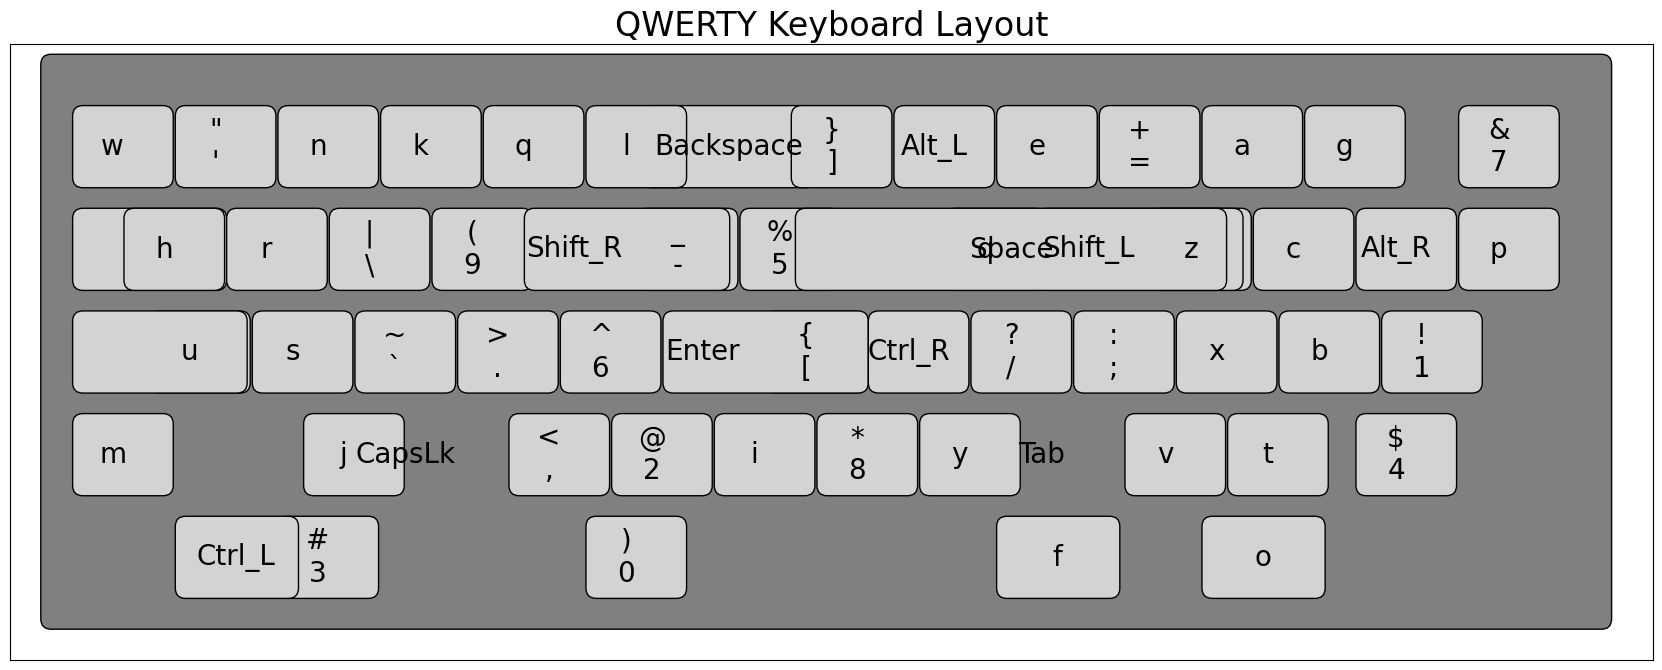

In [ ]:
# Key dimensions: these will help adjust the position of the patches around the keys
key_height = 0.6                      # Height of all keys
normal_key_width = 0.78               # Width of regular keys
space_key_width = 4                   # Custom width for the space key
back_space_key_width = 1.5            # Custom width of the backspace key


fig, ax = plt.subplots(figsize=(24, 8))      # Creaitng the figure and axis for plotting

# Adding a backgound in the shape of a rounded rectangle
background_rect = patches.FancyBboxPatch((-0.6, -0.6), 15.1, 5.4, boxstyle="round,pad=0.1", edgecolor="black", facecolor="grey")
ax.add_patch(background_rect)

# Iterate over each key in the layout and place it on the plot
for key, info in keys.items():
    x, y = info['pos']  # Extract the (x, y) position of the key, from the layout

    # consideering special keys for manual adjustment and alignment of Patches
    if key == 'Space':
        rect = patches.FancyBboxPatch((x - space_key_width / 2 + 1.25, y - 0.3), space_key_width, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")             # Place the leftbottom most corner of space bar at this loaction
        ax.add_patch(rect)
        ax.text(x + 1.25, y, key, ha='center', va='center', fontsize=20)                                               # Placing text at the centre of spacebar


    elif key == 'Backspace':
        rect = patches.FancyBboxPatch((x - back_space_key_width / 2 , y - 0.3), back_space_key_width, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")              # All the keys are plotted in light grey to distinguish from bg grey
        ax.add_patch(rect)
        ax.text(x, y, key, ha='center', va='center', fontsize=20)

    elif key == "Tab":
        rect = patches.FancyBboxPatch((-0.29, 2.7), back_space_key_width - 0.2, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
        ax.add_patch(rect)
        ax.text(x - 0.2 , y, key, ha='center', va='center', fontsize=20)

    elif key == "CapsLk" :
      rect = patches.FancyBboxPatch((-0.29, 1.7), back_space_key_width, key_height,
                                       boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
      ax.add_patch(rect)
      ax.text(x - 0.4 , y, key, ha='center', va='center', fontsize=20)

    elif key == "Enter":
      rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                            1.8, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
      ax.add_patch(rect)
      ax.text(x , y, key, ha='center', va='center', fontsize=20)

    elif key == "Shift_L" or key == "Shift_R":
      rect = patches.FancyBboxPatch((x - normal_key_width / 2 , y - key_height / 2),
                                            1.8, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
      ax.add_patch(rect)
      ax.text(x , y, key, ha='center', va='center', fontsize=20)

    # Considering all the remaining keys
    else:
        # Check for shift characters, t print both shift character and normal character in the same key
        if key in Shift_characters_simplified.keys():
            special = Shift_characters_simplified[key]
            rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1, y - key_height / 2),
                                           normal_key_width, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
            ax.add_patch(rect)
            ax.text(x, y, f"{special}\n{key}", ha='center', va='center', fontsize=20)           #Using format string for taking in the special and normal key at once

        else:
            # Drawing normal keys
            if y ==0 :   # to enssure proper alignment of the botom most row
              rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 + 1 , y - key_height / 2),
                                           1, key_height,
                                           boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
              ax.add_patch(rect)
              ax.text(x + 1.2, y, key, ha='center', va='center', fontsize=20)    # Doesn't impact distance measure as we won't be using these in paragraphs
            else:
              # Every other remaining row
              rect = patches.FancyBboxPatch((x - normal_key_width / 2 + 0.1 , y - key_height / 2),
                                            normal_key_width, key_height,
                                            boxstyle="round,pad=0.1", edgecolor="black", facecolor="lightgrey")
              ax.add_patch(rect)
              ax.text(x, y, key, ha='center', va='center', fontsize=20)




ax.set_aspect('equal')
# Formatting the plot to look like a keyboard
ax.set_xlim(-1, 15)
ax.set_ylim(-1, 5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("QWERTY Keyboard Layout", fontsize=24)

# Show the plot
plt.show()


## Distance Calculation : initially -

*   Calculates distances travelled by fingers while tying an input string, assumes space keys' start position is at 'f'



In [ ]:
def calculate_distance(text_input, keys, characters):

  ''' Calculates total distance by using the characters dictionary and for each element in value tuple,
  calculating distanes from corresponfing home row keys and adding them up, giving the total distance of a single
  character. Adding those up for all characters yields total distance'''

  total = 0       # initialising total  = 0 for a string
  total_1 = 0     # initialising total = 0 for each character in string
  for c in text_input:
      total_1 = 0
      chars = characters[c] # is a tuple, now calulating total distance:
      for i in chars:
          details = keys[i]                      # extracting details like position and start, of elements in the chars (/value) tuple from the keys dictionary
          pos1 = details['pos']
          start_char = details['start']
          start_pt_details = keys[start_char]    # extarcting details for the start (home row) key as well
          pos2 = start_pt_details['pos']
          dis = (((pos1[0]- pos2[0])**2) + ((pos1[1]- pos2[1])**2))**(0.5)    # Using distance formula
          total_1 += dis
      total += total_1
  return total

# Considering, space key to have start from f


# Optimizing the keyboard:


In [146]:
#Redefining the keyboard layout, such that the position of th ehome row keys is taken into account instead of the character as the characters can be moved.
keys = {
    # Number row
    '`': {'pos': (0, 4), 'start': (1.75, 2)}, '1': {'pos': (1, 4), 'start': (1.75, 2)}, '2': {'pos': (2, 4), 'start': (1.75, 2)},  # instead of 'start' :'a', I put 'start': (1.75, 2) (initial pos of a)
    '3': {'pos': (3, 4), 'start': (2.75, 2)}, '4': {'pos': (4, 4), 'start': (3.75, 2)}, '5': {'pos': (5, 4), 'start': (4.75, 2)},
    '6': {'pos': (6, 4), 'start': (7.75, 2)}, '7': {'pos': (7, 4), 'start': (7.75, 2)}, '8': {'pos': (8, 4), 'start': (8.75, 2)},
    '9': {'pos': (9, 4), 'start': (9.75, 2)}, '0': {'pos': (10, 4), 'start': (10.75, 2)}, '-': {'pos': (11, 4), 'start': (10.75, 2)},
    '=': {'pos': (12, 4), 'start': (10.75, 2)}, 'Backspace': {'pos': (13.5, 4), 'start': (10.75, 2)},

    # Top letter row
    'Tab': {'pos': (0.5, 3), 'start': (1.75, 2)},
    'q': {'pos': (1.5, 3), 'start': (1.75, 2)}, 'w': {'pos': (2.5, 3), 'start': (2.75, 2)}, 'e': {'pos': (3.5, 3), 'start': (3.75, 2)},
    'r': {'pos': (4.5, 3), 'start': (4.75, 2)}, 't': {'pos': (5.5, 3), 'start': (4.75, 2)}, 'y': {'pos': (6.5, 3), 'start': (7.75, 2)},
    'u': {'pos': (7.5, 3), 'start': (7.75, 2)}, 'i': {'pos': (8.5, 3), 'start': (8.75, 2)}, 'o': {'pos': (9.5, 3), 'start': (9.75, 2)},
    'p': {'pos': (10.5, 3), 'start': (10.75, 2)}, '[': {'pos': (11.5, 3), 'start': (10.75, 2)}, ']': {'pos': (12.5, 3), 'start': (10.75, 2)},
    '\\': {'pos': (13.5, 3), 'start': (10.75, 2)},

    # Home row
    'CapsLk': {'pos': (0.75, 2), 'start': (1.75, 2)},
    'a': {'pos': (1.75, 2), 'start': (1.75, 2)}, 's': {'pos': (2.75, 2), 'start': (2.75, 2)}, 'd': {'pos': (3.75, 2), 'start': (3.75, 2)},
    'f': {'pos': (4.75, 2), 'start': (4.75, 2)}, 'g': {'pos': (5.75, 2), 'start': (4.75, 2)}, 'h': {'pos': (6.75, 2), 'start': (7.75, 2)},
    'j': {'pos': (7.75, 2), 'start': (7.75, 2)}, 'k': {'pos': (8.75, 2), 'start': (8.75, 2)}, 'l': {'pos': (9.75, 2), 'start': (9.75, 2)},
    ';': {'pos': (10.75, 2), 'start': (10.75, 2)}, "'": {'pos': (11.75, 2), 'start': (10.75, 2)}, "Enter": {'pos': (12.75, 2), 'start': (10.75, 2)},

    # Bottom letter row
    'z': {'pos': (2.25, 1), 'start': (1.75, 2)}, 'x': {'pos': (3.25, 1), 'start': (2.75, 2)}, 'c': {'pos': (4.25, 1), 'start': (3.75, 2)},
    'v': {'pos': (5.25, 1), 'start': (4.75, 2)}, 'b': {'pos': (6.25, 1), 'start': (4.75, 2)}, 'n': {'pos': (7.25, 1), 'start': (7.75, 2)},
    'm': {'pos': (8.25, 1), 'start': (7.75, 2)}, ',': {'pos': (9.25, 1), 'start': (8.75, 2)}, '.': {'pos': (10.25, 1), 'start': (9.75, 2)},
    '/': {'pos': (11.25, 1), 'start': (10.75, 2)},

    # Special keys
    'Shift_L': {'pos': (0, 1), 'start': (1.75, 2)}, 'Shift_R': {'pos': (12.5, 1), 'start': (10.75, 2)},
    'Ctrl_L': {'pos': (0, 0), 'start': (1.75, 2)}, 'Alt_L': {'pos': (2, 0), 'start': (1.75, 2)},
    'Space': {'pos': (5, 0), 'start': (4.75, 2)}, 'Alt_R': {'pos': (8, 0), 'start': (7.75, 2)}, 'Ctrl_R': {'pos': (10, 0), 'start': (10.75, 2)},
}


## Not changing any of these combinations, hence assuming these are our combinations what can the minimum distance layout be is the goal. Adding the Enter character to handle multiline strings.
characters = {
    # Lowercase letters (unchanged)
    'a': ('a',), 'b': ('b',), 'c': ('c',), 'd': ('d',), 'e': ('e',),
    'f': ('f',), 'g': ('g',), 'h': ('h',), 'i': ('i',), 'j': ('j',),
    'k': ('k',), 'l': ('l',), 'm': ('m',), 'n': ('n',), 'o': ('o',),
    'p': ('p',), 'q': ('q',), 'r': ('r',), 's': ('s',), 't': ('t',),
    'u': ('u',), 'v': ('v',), 'w': ('w',), 'x': ('x',), 'y': ('y',),
    'z': ('z',),

    # Uppercase letters (updated)
    'A': ('Shift_R', 'a'), 'B': ('Shift_R', 'b'), 'C': ('Shift_R', 'c'),
    'D': ('Shift_R', 'd'), 'E': ('Shift_R', 'e'), 'F': ('Shift_R', 'f'),
    'G': ('Shift_R', 'g'), 'H': ('Shift_L', 'h'), 'I': ('Shift_L', 'i'),
    'J': ('Shift_L', 'j'), 'K': ('Shift_L', 'k'), 'L': ('Shift_L', 'l'),
    'M': ('Shift_L', 'm'), 'N': ('Shift_L', 'n'), 'O': ('Shift_L', 'o'),
    'P': ('Shift_L', 'p'), 'Q': ('Shift_R', 'q'), 'R': ('Shift_R', 'r'),
    'S': ('Shift_R', 's'), 'T': ('Shift_R', 't'), 'U': ('Shift_L', 'u'),
    'V': ('Shift_R', 'v'), 'W': ('Shift_R', 'w'), 'X': ('Shift_R', 'x'),
    'Y': ('Shift_L', 'y'), 'Z': ('Shift_R', 'z'),

    # Numbers and their shifted symbols (updated)
    '1': ('1',), '!': ('Shift_R', '1'),
    '2': ('2',), '@': ('Shift_R', '2'),
    '3': ('3',), '#': ('Shift_R', '3'),
    '4': ('4',), '$': ('Shift_R', '4'),
    '5': ('5',), '%': ('Shift_R', '5'),
    '6': ('6',), '^': ('Shift_L', '6'),
    '7': ('7',), '&': ('Shift_L', '7'),
    '8': ('8',), '*': ('Shift_L', '8'),
    '9': ('9',), '(': ('Shift_L', '9'),
    '0': ('0',), ')': ('Shift_L', '0'),

    # Other symbols (updated)
    '`': ('`',), '~': ('Shift_R', '`'),    # modified this from '' to '`'
    '-': ('-',), '_': ('Shift_L', '-'),
    '=': ('=',), '+': ('Shift_L', '='),
    '[': ('[',), '{': ('Shift_L', '['),
    ']': (']',), '}': ('Shift_L', ']'),
    '\\': ('\\',), '|': ('Shift_L', '\\'),
    ';': (';',), ':': ('Shift_L', ';'),
    "'": ("'",), '"': ('Shift_L', "'"),
    ',': (',',), '<': ('Shift_L', ','),
    '.': ('.',), '>': ('Shift_L', '.'),
    '/': ('/',), '?': ('Shift_L', '/'),

    # Space (unchanged)
    ' ': ('Space',), "\n": ('Enter',)
}


def calculate_distance_2(text_input, keys, characters):

  ''' Calculates total distance by using the characters dictionary and for each element in value tuple,
  calculating distanes from corresponfing home row keys and adding them up, giving the total distance of a single
  character. Adding those up for all characters yields total distance'''

  total = 0       # initialising total  = 0 for a string
  total_1 = 0     # initialising total = 0 for each character in string
  for c in text_input:
      total_1 = 0
      chars = characters[c] # is a tuple, now calulating total distance:
      for i in chars:
          if i == "\n":   # newline implies Enter key is pressed
              details = keys['Enter']
          else:
              details = keys[i]                      # extracting details like position and start, of elements in the chars (/value) tuple from the keys dictionary
          pos1 = details['pos']
          pos2 = details['start']   # extarcting details for the start (home row) keys as well simply from the details itself
          dis = (((pos1[0]- pos2[0])**2) + ((pos1[1]- pos2[1])**2))**(0.5)    # Using distance formula
          total_1 += dis
      total += total_1
  return total

# For any key postition the home row key position doesn't change. Home row keys are where we position our fingers while resting, fixed locations, so we calculate distance from there.



In [147]:
# Function to generate a new layout by swapping two random keys
def swapper(layout):

    """Function to generate a new layout by randomly swapping two keys in the keyboard layout."""

    new_layout = layout.copy()      # Copying to prevent in place modifications
    key1, key2 = random.sample(new_layout.keys(), 2)  #picking two keys
    new_layout[key1], new_layout[key2] = new_layout[key2], new_layout[key1]  # Swap two keys
    return new_layout

# Simulated Annealing function for optimizing the keyboard layout
def simulated_annealing(text_input, keys, characters, initial_temp, cooling_rate, num_iterations, random_seed = 42):
    """
    This function performs the simulated annealing algorithm to optimize keyboard layouts based on the distance traveled by fingers for a given text input.

    Parameters:
        text_input (str): The text we are optimizing the layout for.
        keys (dict): Dictionary representing the current keyboard layout (e.g., QWERTY).
        characters (dict): Dictionary representing the frequency or usage of characters in the text input.
        initial_temp (float): The starting temperature for simulated annealing.
        cooling_rate (float): The rate at which the temperature decreases in each iteration.
        num_iterations (int): Number of iterations for the simulated annealing algorithm.
        random_seed (int, optional): Seed to ensure reproducibility of results. Default is 42.

    Returns:
        best_layouts (list): List of keyboard layouts at each step.
        best_distances (list): List of the best distances achieved at each step.
        distances (list): List of distances for the current layout at each step.
    """
    # setting random seeds to generate same results eerytime we run the code (reproducibility)
    random.seed(random_seed)
    np.random.seed(random_seed)

    # Start with the current layout (initially can be QWERTY or random, we choose QWERTY)
    current_layout = keys.copy()
    current_distance = calculate_distance_2(text_input, current_layout, characters)  # initial distance calculation

    print("With the initial layout, the distance is", current_distance)

    # Initialising best_layout and best_distance as current_layout and current_distance
    best_layout = current_layout.copy()
    best_distance = current_distance

    temp = initial_temp  # Set the initial temperature for simulated annealing.

    distances = [current_distance]       # List of current distances after each iteration.
    best_layouts = [best_layout.copy()]  # List of best layouts after each iteration
    best_distances = [best_distance]     # List of best distances after each iteration.

    # For each iteration, generate a neighboring layout by swapping keys. Calculate its distance and compare it with the current layout.
    # Accept the neighboring layout if it's better, or with a certain probability even if it's worse (to escape local minima).
    # Update the best layout and best distance if a better layout is found.
    # Gradually cool down the temperature to reduce random moves over time. Track the current and best distances/layouts.

    for i in range(num_iterations):
        new_layout = swapper(current_layout)
        new_distance = calculate_distance_2(text_input, new_layout, characters)

        # Accept the new layout if it's better or based on probability
        p = np.exp((current_distance - new_distance) / temp)
        if new_distance < current_distance or random.random() < p:
            current_layout = new_layout
            current_distance = new_distance

            if current_distance < best_distance:
                best_layout = current_layout.copy()
                best_distance = current_distance

        temp *= cooling_rate
        distances.append(current_distance)
        best_layouts.append(best_layout.copy())
        best_distances.append(best_distance)

    return best_layouts, best_distances, distances



In [148]:
def plot_keyboard(final_layout, ax):
  """
    Plots a visual representation of a keyboard layout.
    Parameters:
    final_layout (dict):  Keyboard layout that will be plotted
    ax (matplotlib.axes._subplots.AxesSubplot, optional)  : If provided, the layout will be plotted on this axis.
  """
  if ax == None:
      fig, ax = plt.subplots(figsize=(15, 6))

  else:
    ax.clear()

  background_rect = patches.FancyBboxPatch((-0.6, -0.6), 15.1, 5.4, boxstyle="round,pad=0.1", edgecolor="black", facecolor="grey")
  ax.add_patch(background_rect)

  # Loop over each key in the final layout dictionary and draw each key.
  for key, data in final_layout.items():
      x, y = data['pos']
      rect = patches.Rectangle((x-0.4, y-0.4), 0.8, 0.8, facecolor = 'w', edgecolor = 'black')
      ax.add_patch(rect)
      ax.text(x, y, key, ha='center', va='center', fontsize=12)

  ax.set_xlim(-1, 15)
  ax.set_ylim(-1, 5)
  ax.set_aspect('equal', adjustable='box')  # Ensuring the x and y axes are scaled equally to maintain the correct aspect ratio.
  ax.axis('off')
  plt.title('QWERTY Keyboard Layout')  # Title
  plt.tight_layout()
  plt.show()



**Plot of distance and Final keyboard layout:  -**

In [149]:
import matplotlib.pyplot as plt

def plotter(text_input, keys, characters, initial_temp, cooling_rate, num_iterations):
    """
    This function runs the simulated annealing algorithm and plots the final layout and distance plots.

    Parameters:
    - text_input: the text input used for evaluating the keyboard layouts.
    - keys: the initial keyboard layout dictionary.
    - characters: a dictionary of characters to be typed.
    - initial_temp: the initial temperature for simulated annealing.
    - cooling_rate: the rate at which the temperature decreases.
    - num_iterations: the number of iterations for the simulated annealing algorithm.
    """

    # Run the simulated annealing algorithm
    best_layouts, best_distances, distances = simulated_annealing(
        text_input, keys, characters, initial_temp, cooling_rate, num_iterations
    )


    # Plot the final keyboard layout
    plot_keyboard(best_layouts[-1], None)  # Draw the final layout on ax1
    # Output results
    print("Best Total Distance:", best_distances[-1])

    # Plot the results of the optimization
    plt.plot(distances, label="Current Distance")
    plt.plot(best_distances, label="Best Distance")
    plt.title('Simulated Annealing for Keyboard Layout Optimization')
    plt.xlabel('Iteration')
    plt.ylabel('Total Distance')
    plt.legend()
    plt.grid(True)
    plt.show()




# Animation of the plot :

Plotting both keyboard best layouts and distance plots during the iterations


**Note: This code takes approximately 7 minutes to run**



In [162]:
# This function is to animate the best keyboard layouts and distances side by side

def animate_keyboard_and_distances(frame, best_layouts, distances, best_distances, ax1, ax2):
    """
    This function updates both the best keyboard layout and distance plot for each frame of the animation.

    Parameters it takes:
    - frame: the current frame number of the animation.
    - best_layouts: a list of keyboard layouts at each iteration.
    - distances: a list of distances at each iteration (current layout distance).
    - best_distances: a list of the best distances found at each iteration.
    - ax1: the axes on which to plot the keyboard layout.
    - ax2: the axes on which to plot the distances.
    """
    # Update the keyboard layout plot (left plot)
    ax1.clear()  # Clearing the prev iteration
    plot_keyboard(best_layouts[frame], ax1)  # Drawing the layout

    # Update the distance plot (right plot)
    ax2.clear()  # Clear the previous plot before redrawing
    # Plot the distances up to the current frame
    ax2.plot(range(frame + 1), distances[:frame + 1], label="Current Distance", color='blue')
    ax2.plot(range(frame + 1), best_distances[:frame + 1], label="Best Distance", color='red')
    ax2.set_title("Current and Best Distances")  # Set the title of the plot
    ax2.set_xlabel("Iteration")  # Set the x-axis label
    ax2.set_ylabel("Distance")  # Set the y-axis label
    ax2.legend()  # Add a legend to the plot ( to show current and best distances)

# The function for setting up and running the animation of the simulated annealing process
def animate_allsimulated_annealing(text_input, keys, characters, initial_temp, cooling_rate, num_iterations):
    """
    This function sets up the simulated annealing animation and runs the animation for both best
    keyboard layouts and distance plots.

    Parameters:
    - text_input: the text input used for evaluating the keyboard layouts.
    - keys: the initial keyboard layout dictionary.
    - characters: a dictionary of characters to be typed.
    - initial_temp: the initial temperature for simulated annealing.
    - cooling_rate: the rate at which the temperature decreases.
    - num_iterations: the number of iterations for the simulated annealing algorithm.
    """

    # Set up a figure with two subplots (one for the keyboard and one for the distances)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))  # Creates two side-by-side plots

    # Runs the simulated annealing algorithm to get the optimized layouts and distances
    best_layouts, best_distances, distances = simulated_annealing(
        text_input, keys, characters, initial_temp, cooling_rate, num_iterations
    )

    # Create the animation for both the keyboard layout and the distance plot simultaneously
    anim = FuncAnimation(
        fig, animate_keyboard_and_distances,  # The function to call for each frame of the animation
        frames=len(best_layouts),  # Number of frames (i.e., the number of layouts to animate)
        fargs=(best_layouts, distances, best_distances, ax1, ax2),  # Arguments passed to the function
        interval=50,  # Delay between frames (in milliseconds)
        repeat=False  # Do not repeat the animation after it finishes
    )

    plt.tight_layout()  # Adjust subplots to ensure no overlap
    plt.show()  # Display the animation

    return anim  # Return the animation object



 ## **For only distance plotting animation -**

In [163]:
# Function to plot the current and best distances
def animate_distances(frame, distances, best_distances, ax):
    ax.clear()
    ax.plot(range(frame + 1), distances[:frame + 1], label="Current Distance", color='blue')
    ax.plot(range(frame + 1), best_distances[:frame + 1], label="Best Distance", color='red')
    ax.set_title("Current and Best Distances")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Distance")
    ax.legend()

# Setting up the figure for the animation
def animate_simulated_annealing(text_input, keys, characters, initial_temp, cooling_rate, num_iterations):
    fig, ax2 = plt.subplots(figsize=(15, 6))

    # Run the simulated annealing algorithm
    best_layouts, best_distances, distances = simulated_annealing(
        text_input, keys, characters, initial_temp, cooling_rate, num_iterations
    )

    # Create the distance plot animation
    distance_anim = FuncAnimation(
        fig, animate_distances, frames=num_iterations, fargs=(distances, best_distances, ax2),
        interval=50, repeat=False
    )

    return  distance_anim






The above code takes 2 miutes to run

# EXAMPLES:

## Example 1:

With the initial layout, the distance is 8.169446469096714
Best Total Distance: 3.179586801558725


<ipython-input-147-12833aa8d986>:7: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  key1, key2 = random.sample(new_layout.keys(), 2)  #picking two keys


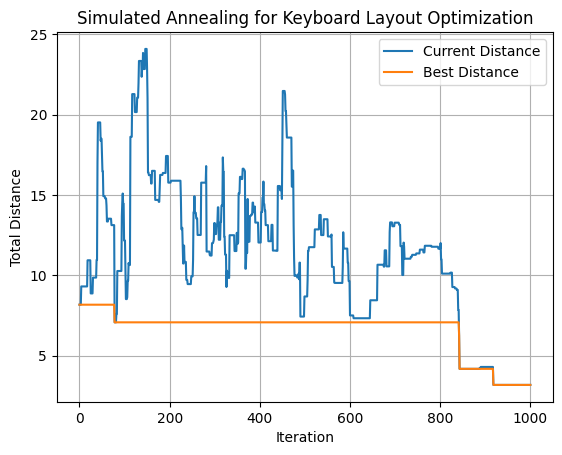

Final Total Distance (Optimized Layout): 3.179586801558725


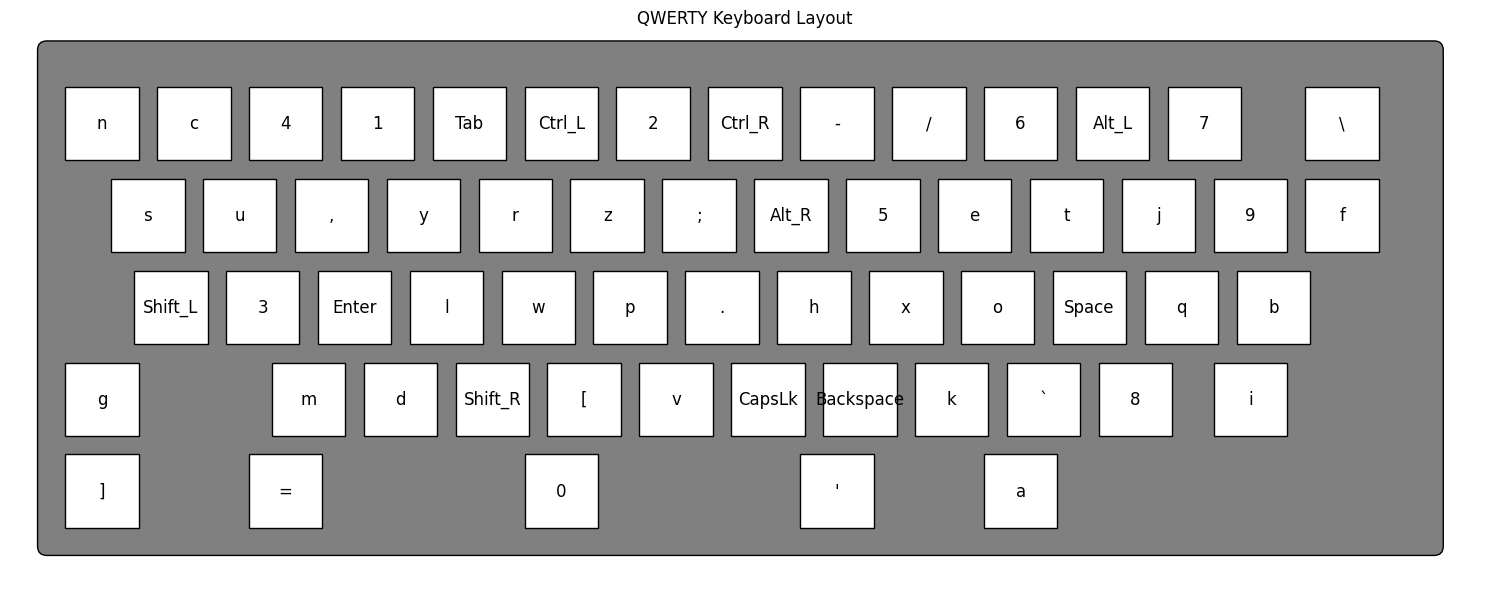

In [150]:
# Example 1
text_input = "hello world"  # Input text for which we want to minimize total distance
initial_temp = 1000 # Starting temperature
cooling_rate = 0.99 # Cooling rate
num_iterations = 1000  # Number of iterations

# Run simulated annealing to optimize the layout
best_layouts, best_distances, distances = simulated_annealing(text_input, keys, characters, initial_temp, cooling_rate, num_iterations)

# Output results
print("Best Total Distance:", best_distances[-1])

# Plot the results of the optimization
plt.plot(distances, label="Current Distance")
plt.plot(best_distances, label="Best Distance")
plt.title('Simulated Annealing for Keyboard Layout Optimization')
plt.xlabel('Iteration')
plt.ylabel('Total Distance')
plt.legend()
plt.grid(True)
plt.show()

final_layout = best_layouts[-1]
final_total_distance = calculate_distance_2("hello world", final_layout, characters)
print(f"Final Total Distance (Optimized Layout): {final_total_distance}")

plot_keyboard(final_layout, ax = None)


With the initial layout, the distance is 8.169446469096714


<ipython-input-147-12833aa8d986>:7: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  key1, key2 = random.sample(new_layout.keys(), 2)  #picking two keys


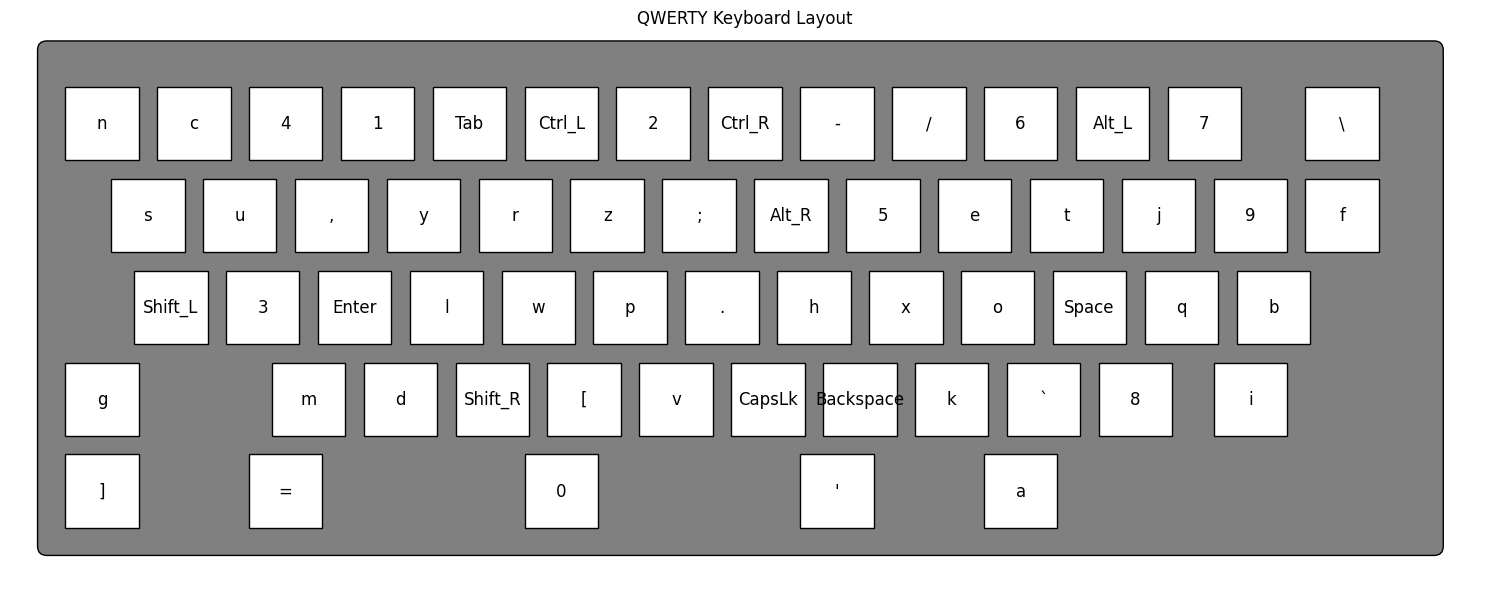

Best Total Distance: 3.179586801558725


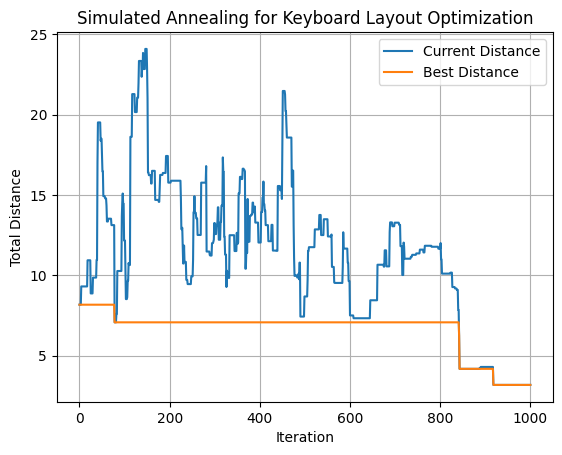

In [151]:
plotter(text_input, keys, characters, initial_temp, cooling_rate, num_iterations)

The distance went from 8.17 to 3.18 in the new layout !!

**ANIMATIONS:**

This animation takes 2 mins and the below one can take upto 7 minutes

In [ ]:
## Running and saving the distance animation function
distance_anim = animate_simulated_annealing(text_input, keys, characters, initial_temp=100, cooling_rate=0.995, num_iterations=500)
distance_anim.save('dis_animation_text_input.mp4', writer='ffmpeg')

In [ ]:
# Run the animation function
anim = animate_allsimulated_annealing(
    text_input, keys, characters, initial_temp=100, cooling_rate=0.995, num_iterations=500
)

# Saving the animation to a video file
anim.save('simultaneous_animation.mp4', writer='ffmpeg')

## Example 2 :

With the initial layout, the distance is 444.4360805461635


<ipython-input-147-12833aa8d986>:7: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  key1, key2 = random.sample(new_layout.keys(), 2)  #picking two keys


Best Total Distance: 232.34491311982313


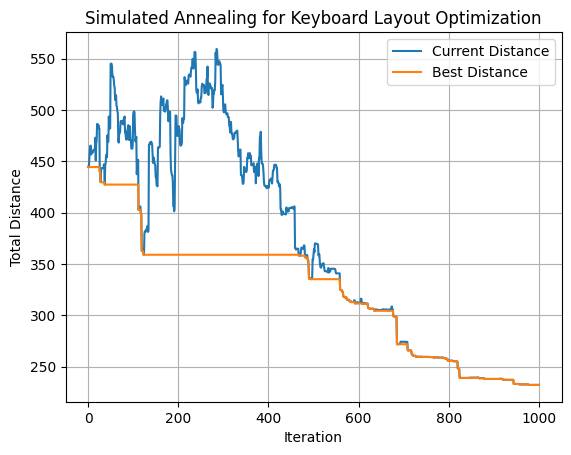

Final Total Distance (Optimized Layout): 7.210363207963141


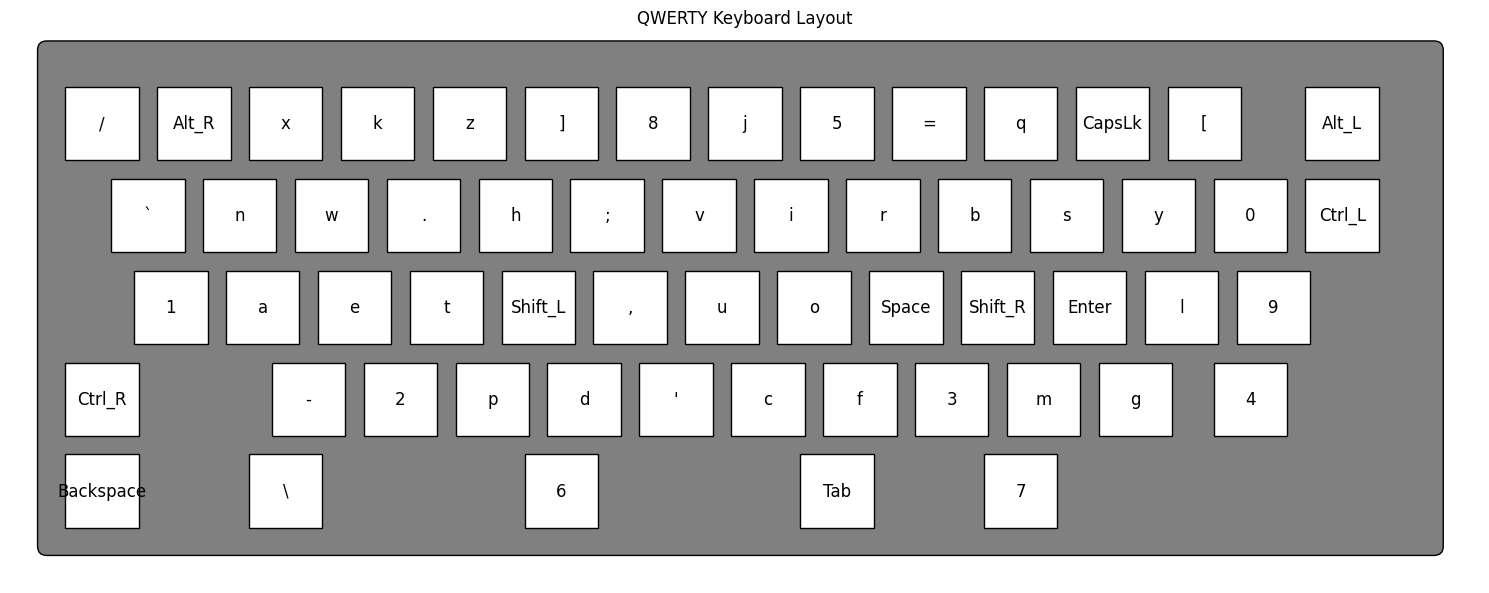

In [164]:
# Example 2
text_input = '''Hello World!
1234, ~!@#$%^&*()_+
This is a test of the keyboard layout optimizer.
Line #1: Quick brown fox jumps over the lazy dog.
Line #2: Testing: numbers, symbols, and more...
[Example] -- <HTML> -- (Version 2.0)
"Quotes", 'single quotes', and `backticks`
Newlines, tabs and spaces are here!
End of test.
'''
initial_temp = 1000 # Starting temperature
cooling_rate = 0.99 # Cooling rate
num_iterations = 1000  # Number of iterations

# Run simulated annealing to optimize the layout
best_layouts, best_distances, distances = simulated_annealing(text_input, keys, characters, initial_temp, cooling_rate, num_iterations)

# Output results
print("Best Total Distance:", best_distances[-1])

# Plot the results of the optimization
plt.plot(distances, label="Current Distance")
plt.plot(best_distances, label="Best Distance")
plt.title('Simulated Annealing for Keyboard Layout Optimization')
plt.xlabel('Iteration')
plt.ylabel('Total Distance')
plt.legend()
plt.grid(True)
plt.show()

final_layout = best_layouts[-1]
final_total_distance = calculate_distance_2("hello world", final_layout, characters)
print(f"Final Total Distance (Optimized Layout): {final_total_distance}")

plot_keyboard(final_layout, ax = None)


With the initial layout, the distance is 444.4360805461635


<ipython-input-147-12833aa8d986>:7: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  key1, key2 = random.sample(new_layout.keys(), 2)  #picking two keys


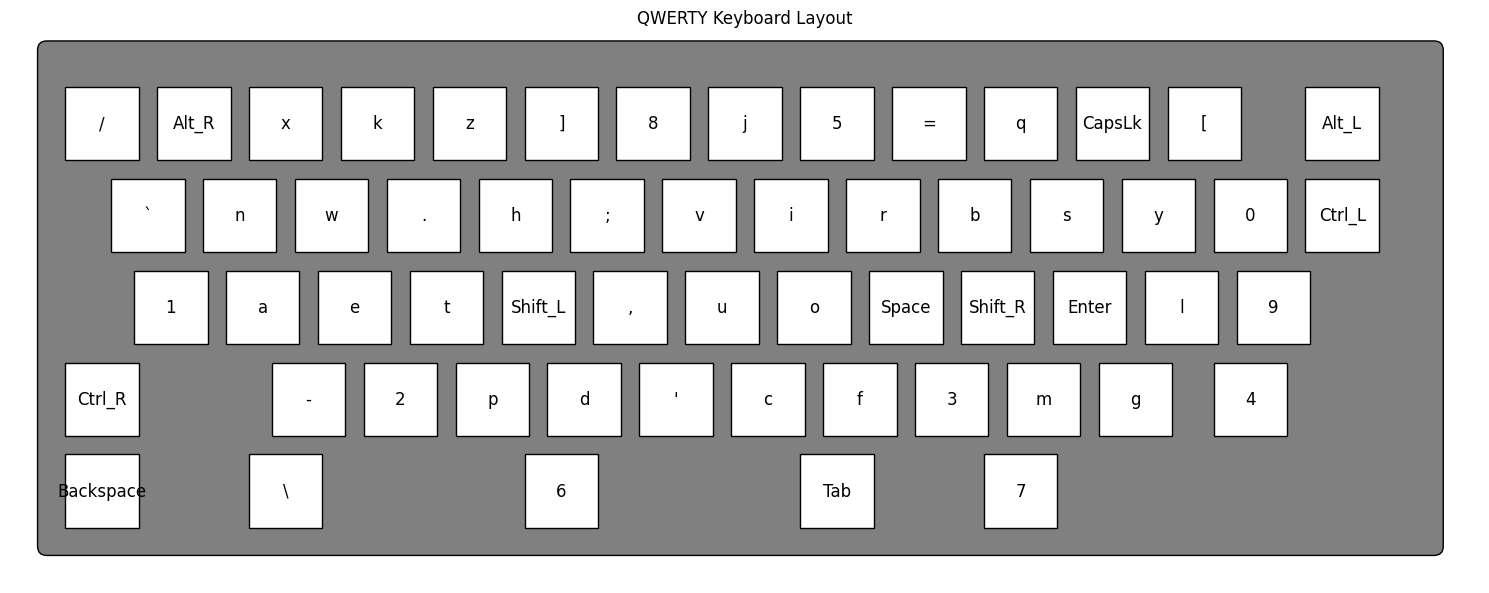

Best Total Distance: 232.34491311982313


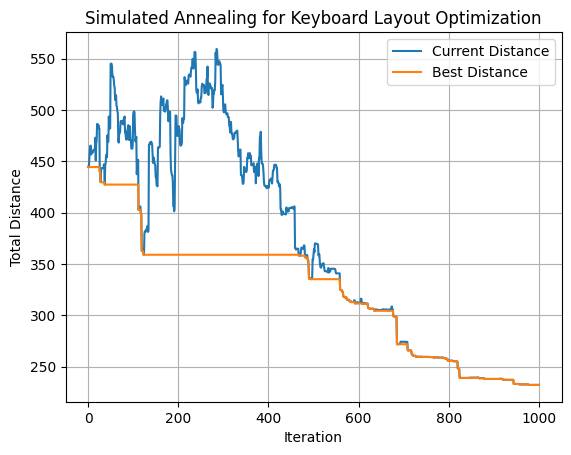

In [165]:
plotter(text_input, keys, characters, initial_temp, cooling_rate, num_iterations)

**ANIMATIONS:**

With the initial layout, the distance is 444.4360805461635


<ipython-input-147-12833aa8d986>:7: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  key1, key2 = random.sample(new_layout.keys(), 2)  #picking two keys


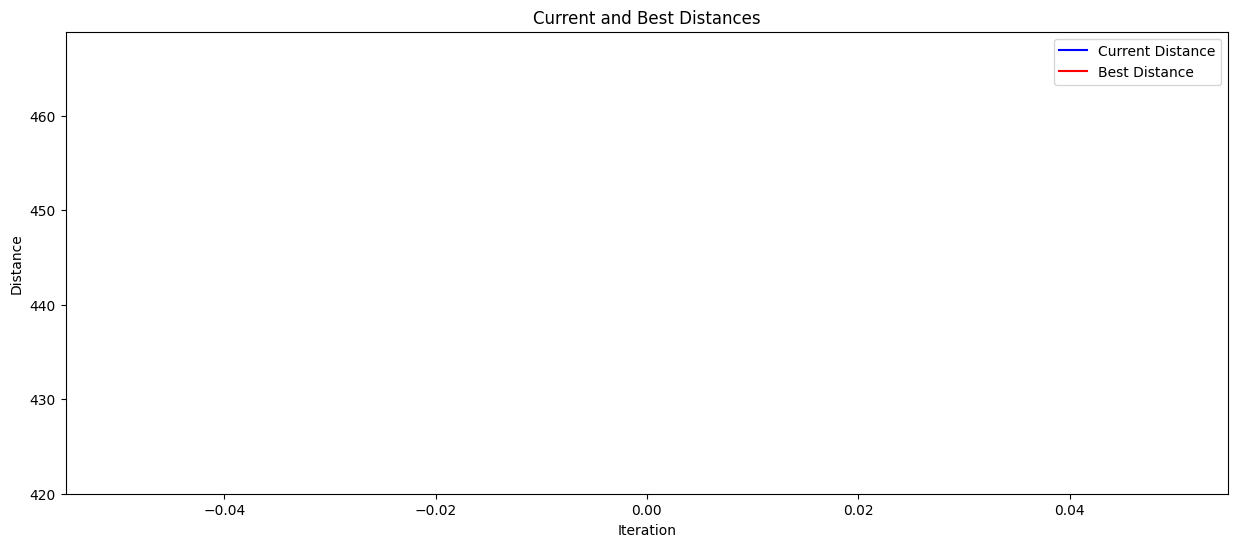

In [166]:
## Running and saving the distance animation function
distance_anim = animate_simulated_annealing(text_input, keys, characters, initial_temp=100, cooling_rate=0.995, num_iterations=500)
distance_anim.save('dis_animation_text_input2.mp4', writer='ffmpeg')

With the initial layout, the distance is 444.4360805461635


<ipython-input-147-12833aa8d986>:7: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  key1, key2 = random.sample(new_layout.keys(), 2)  #picking two keys


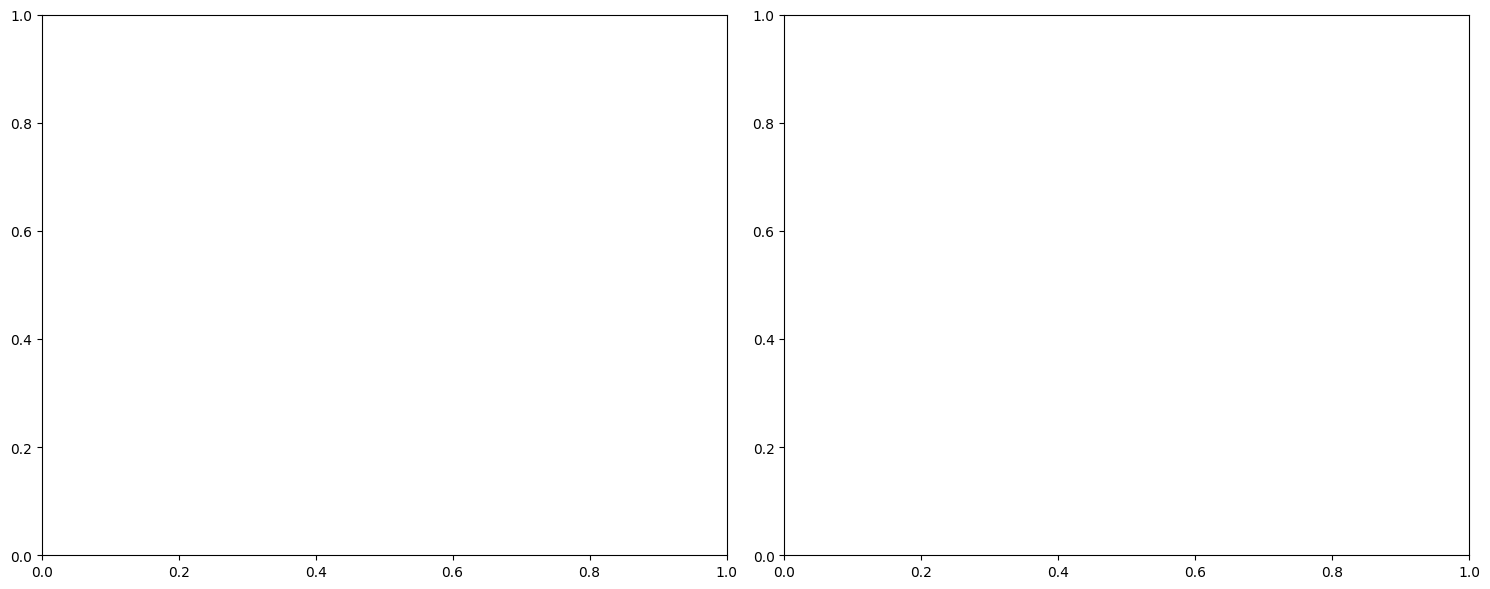

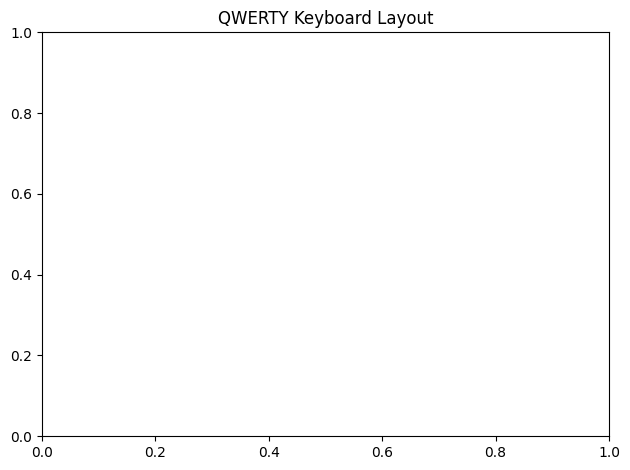

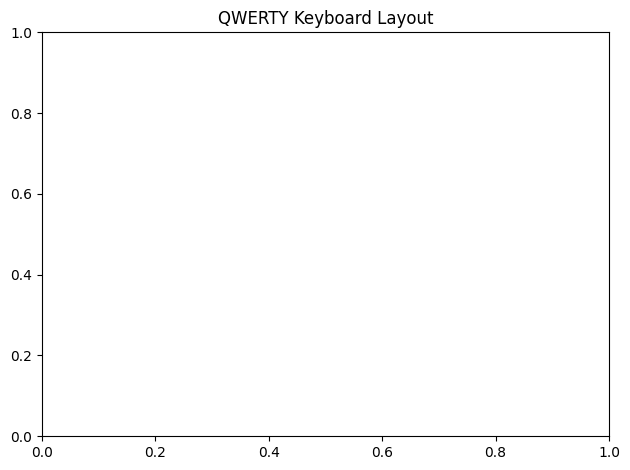

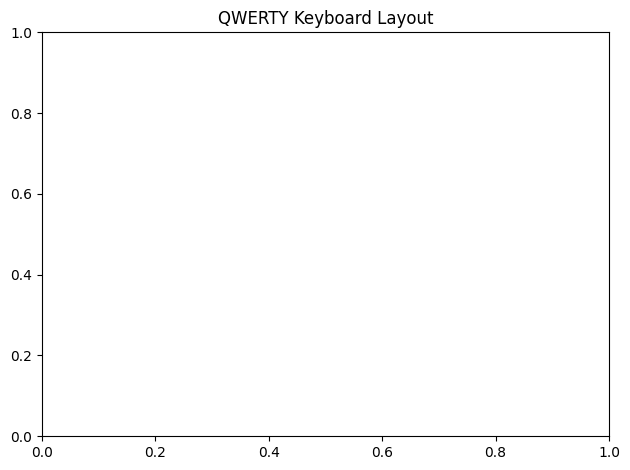

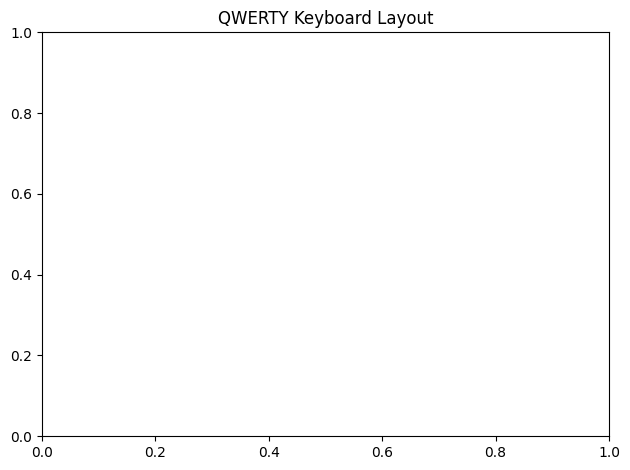

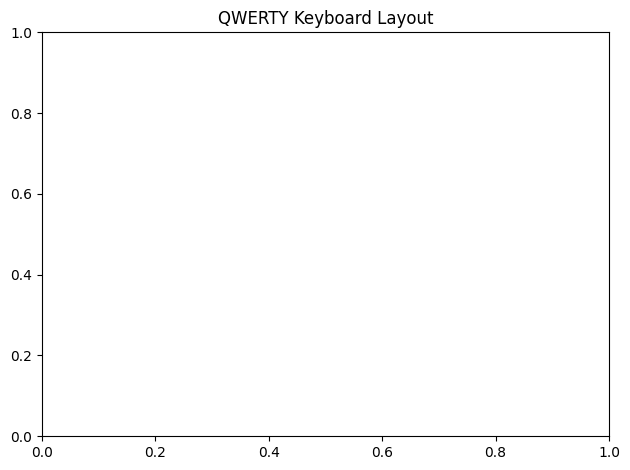

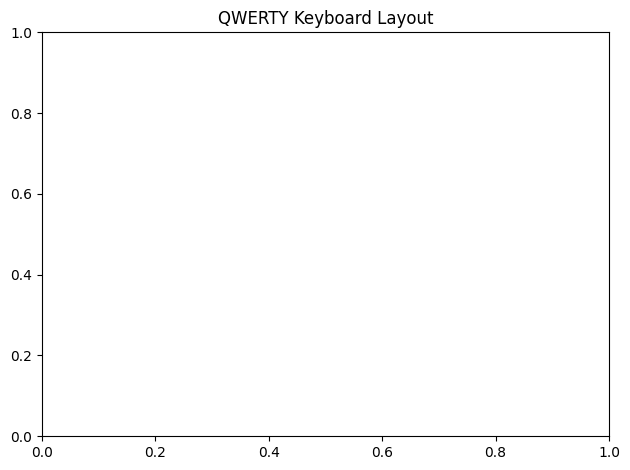

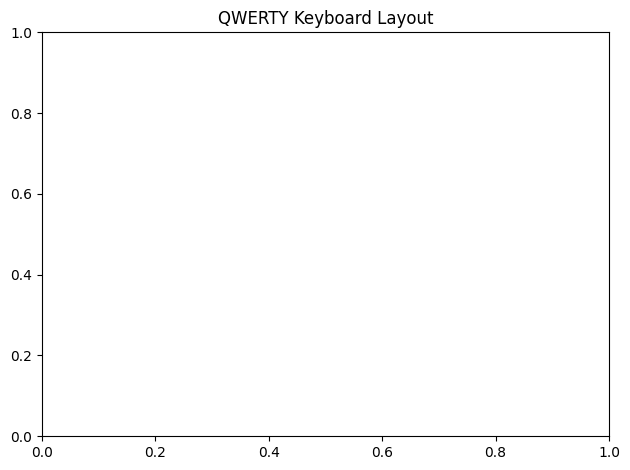

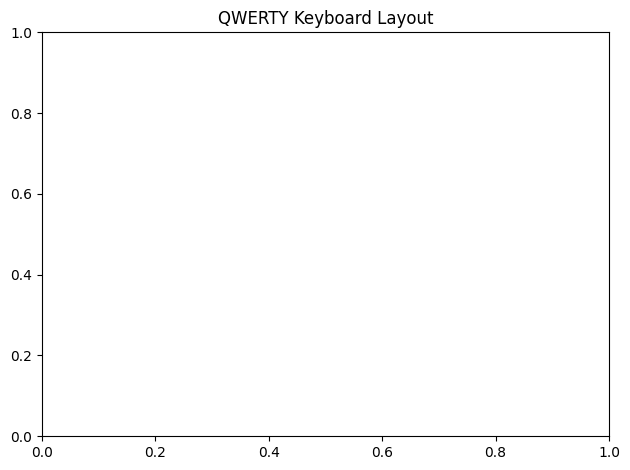

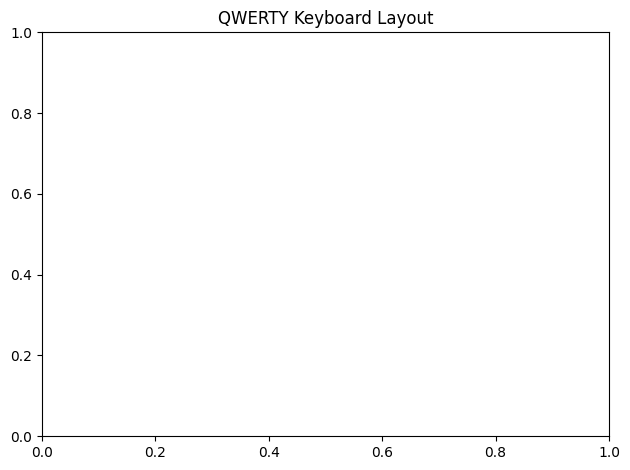

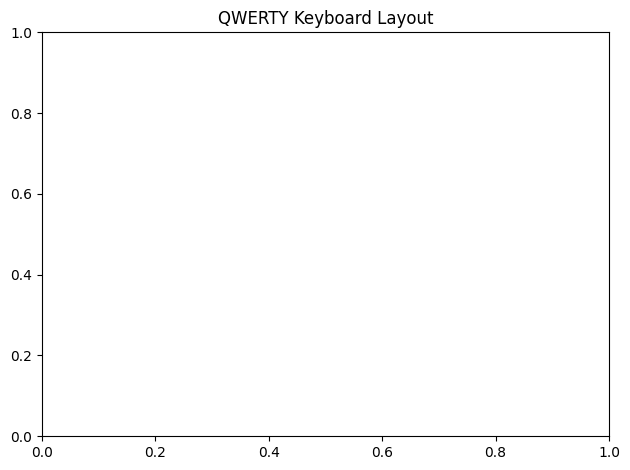

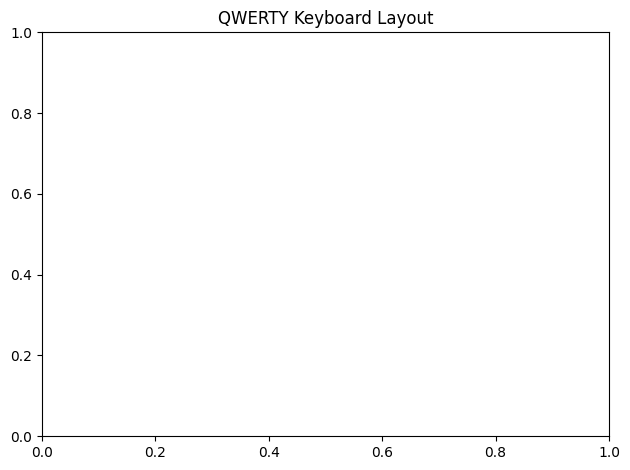

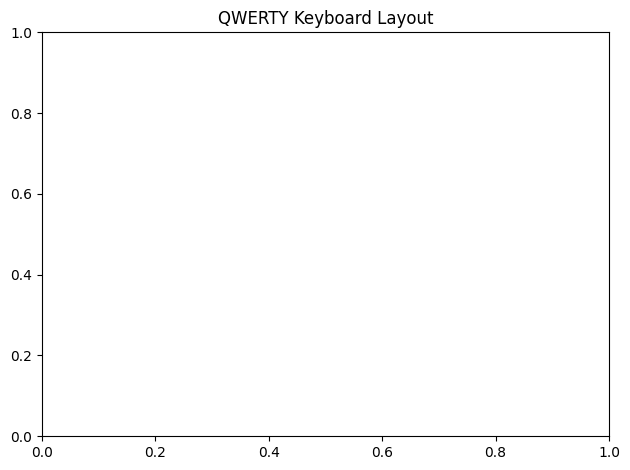

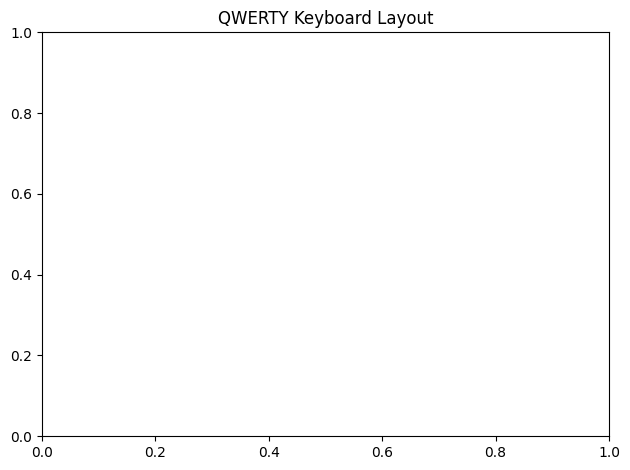

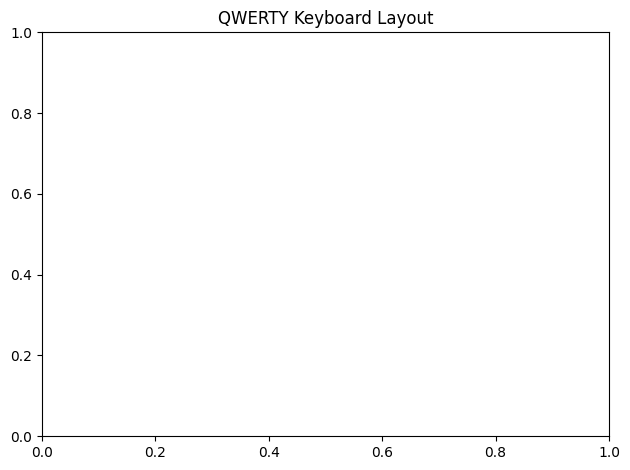

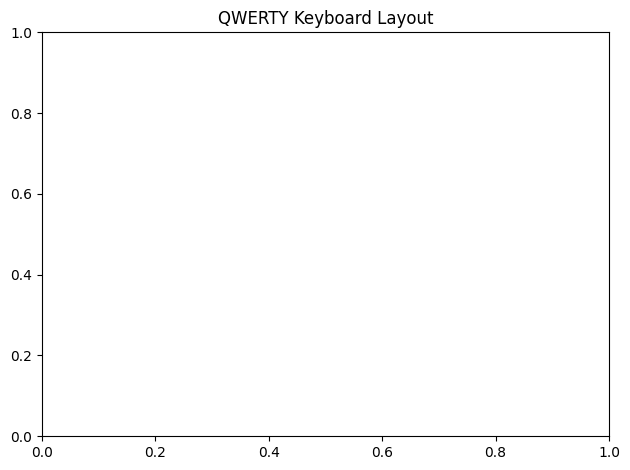

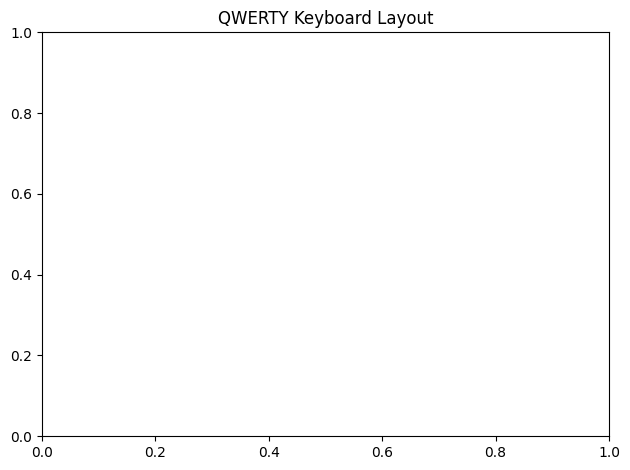

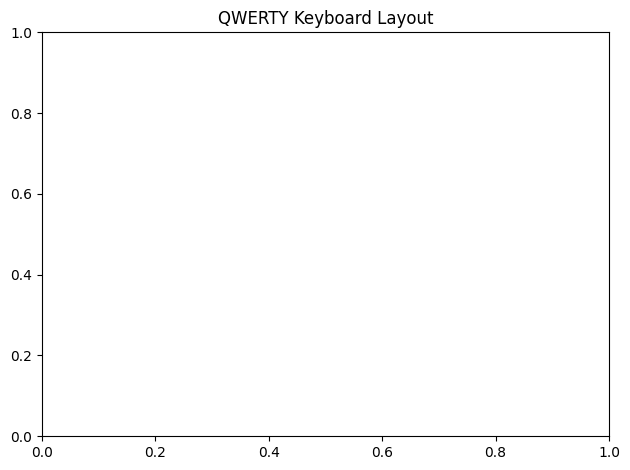

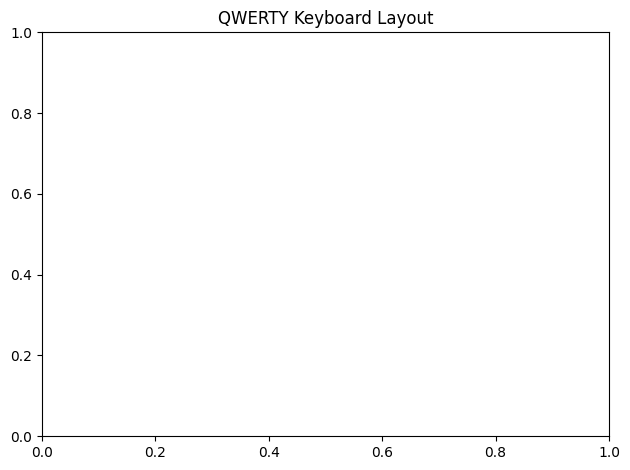

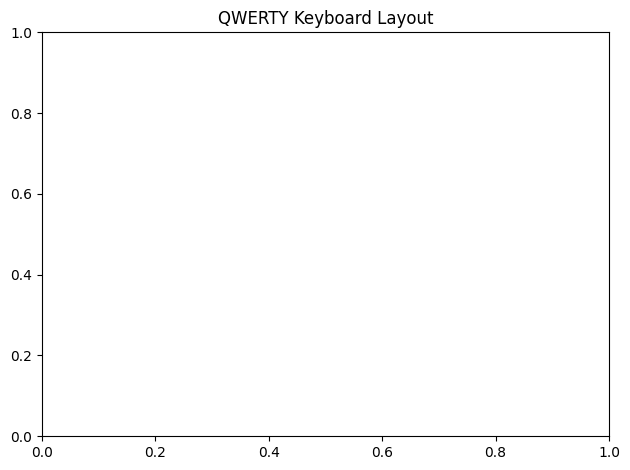

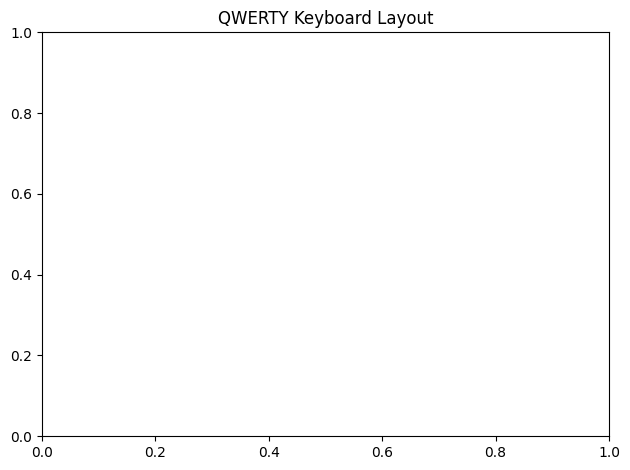

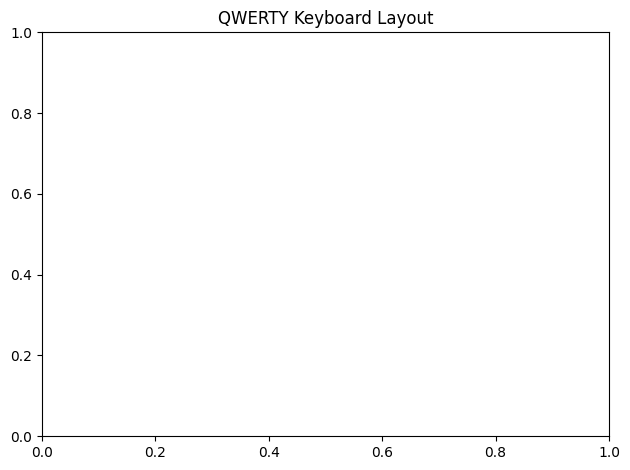

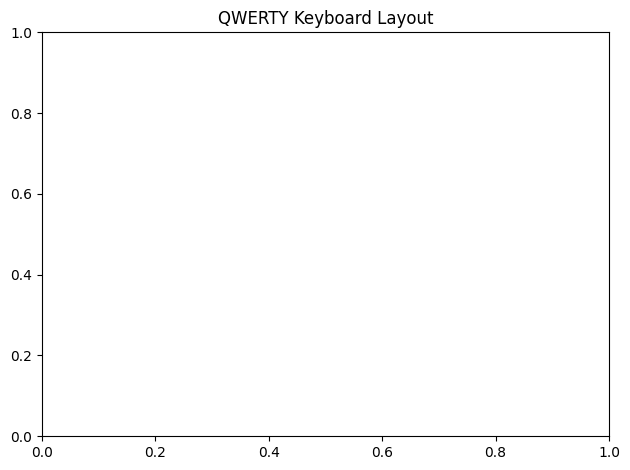

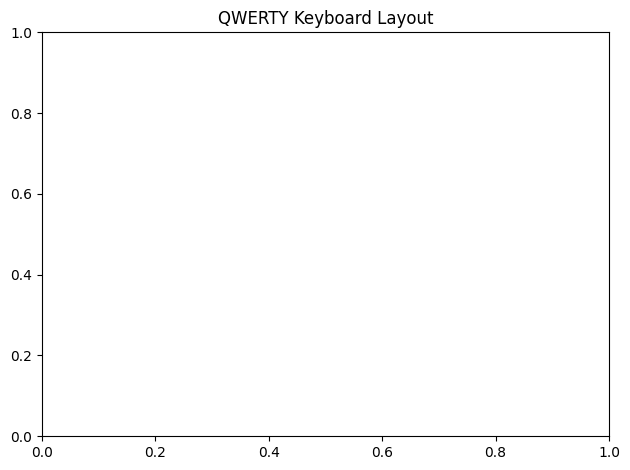

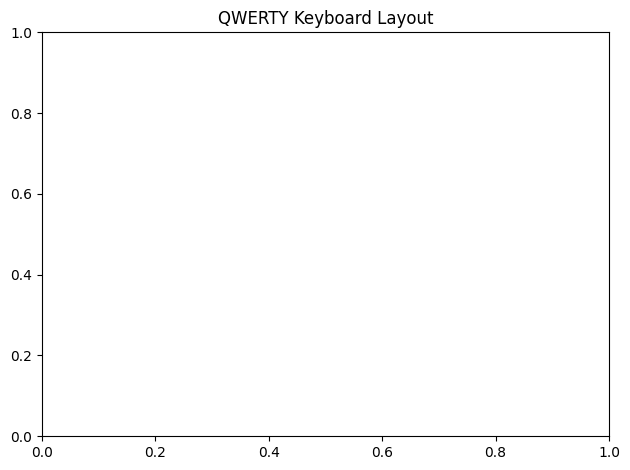

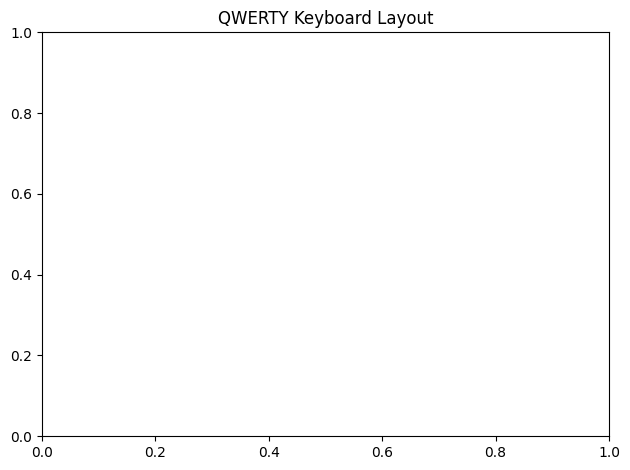

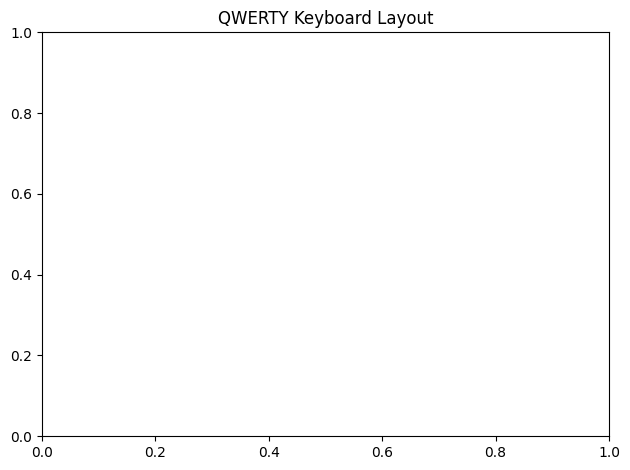

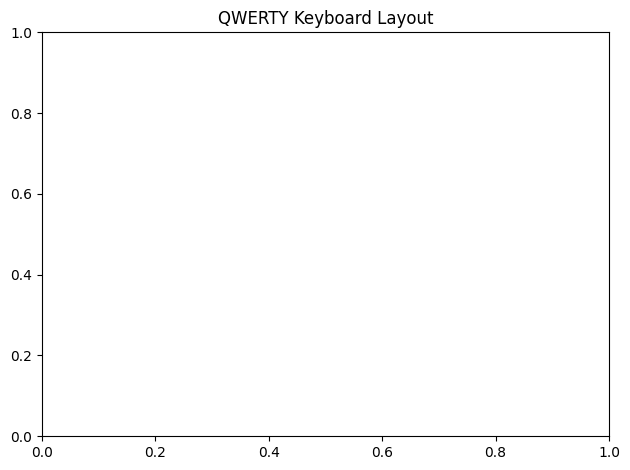

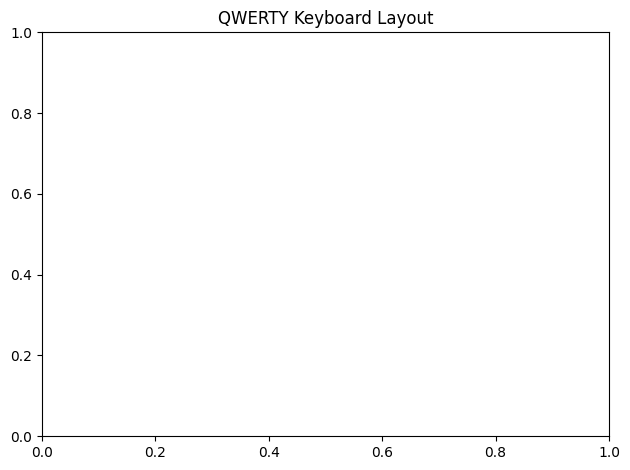

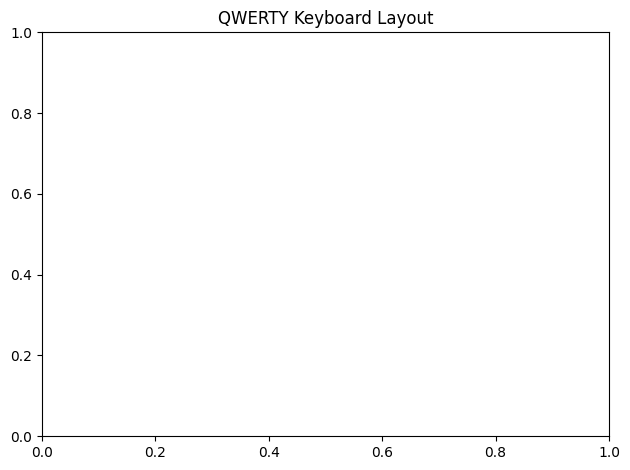

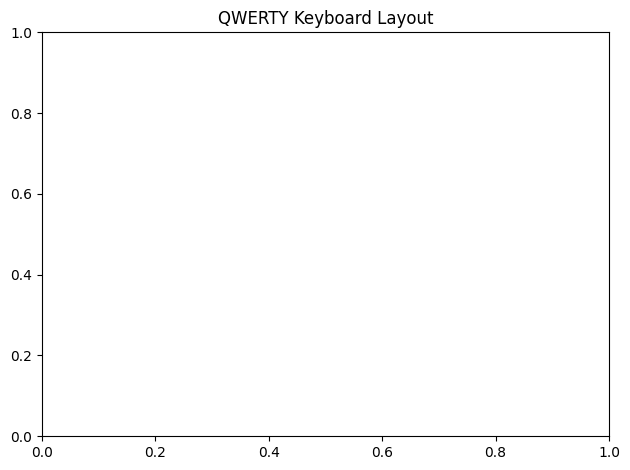

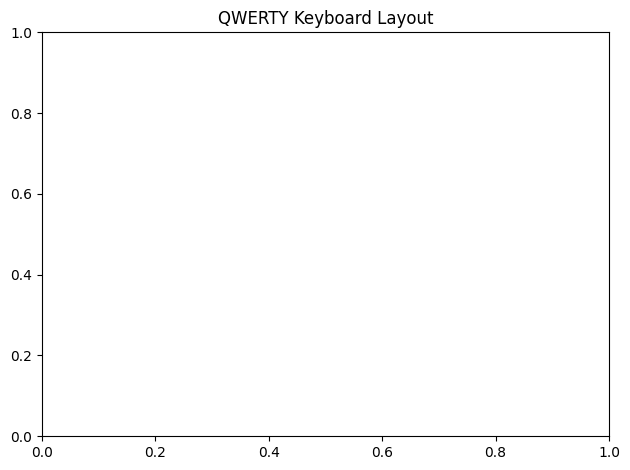

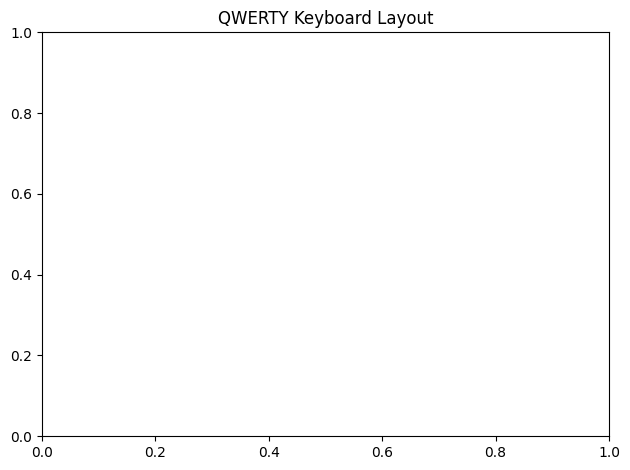

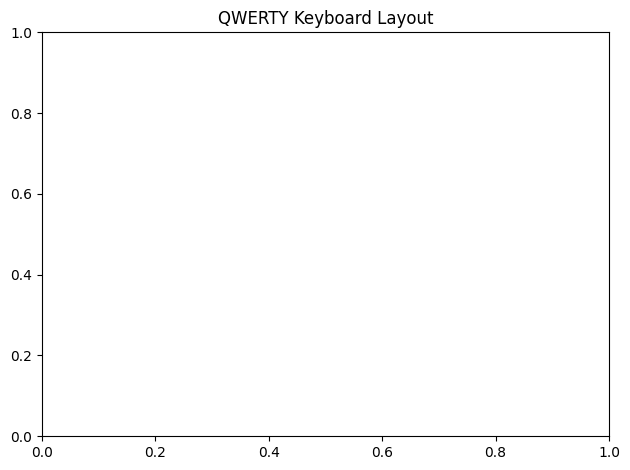

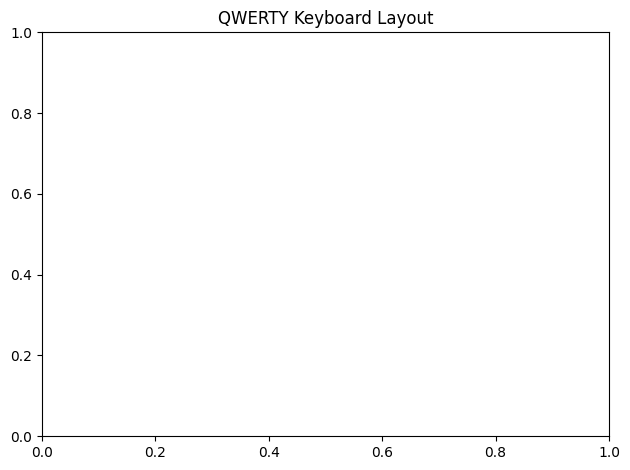

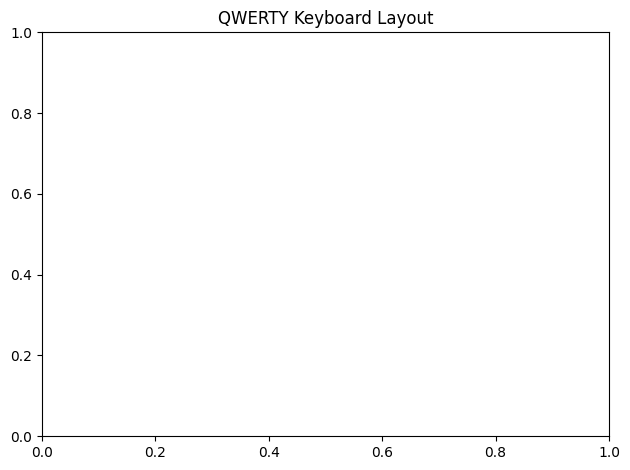

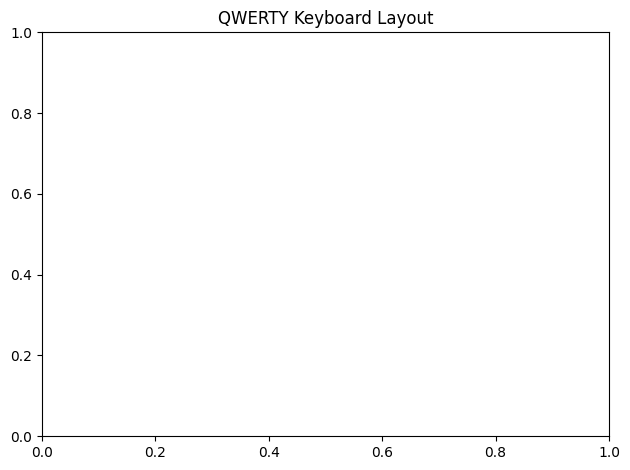

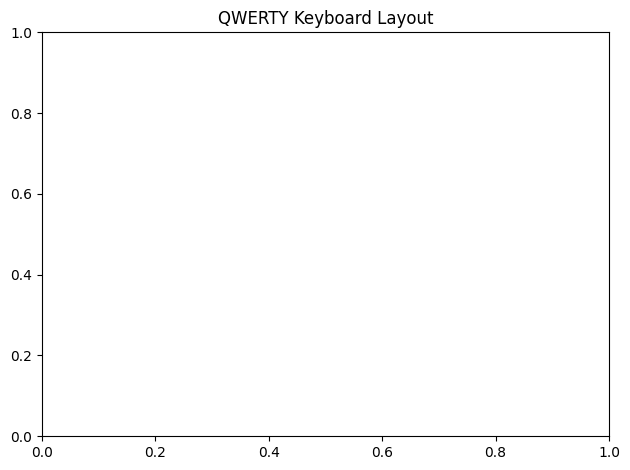

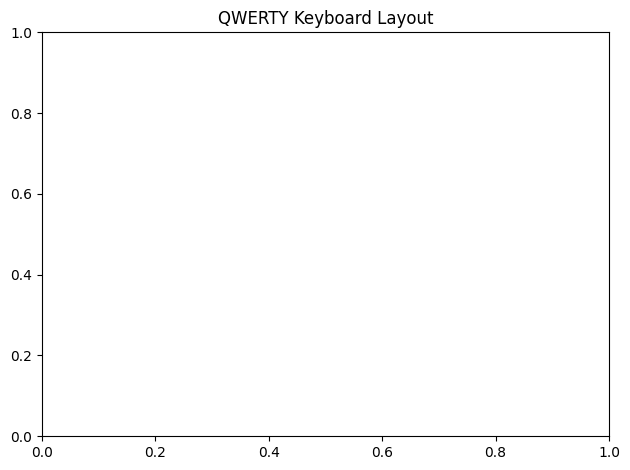

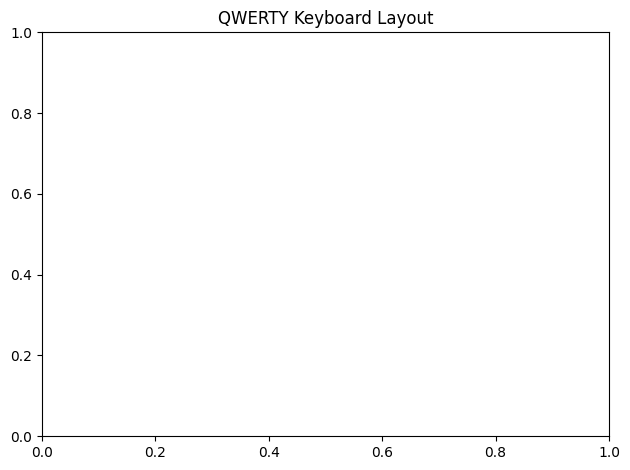

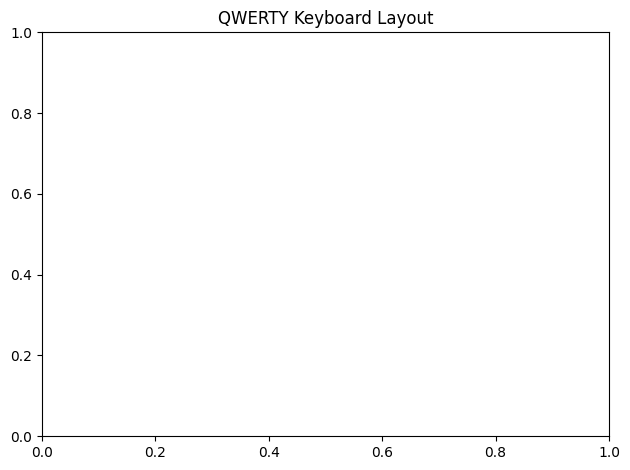

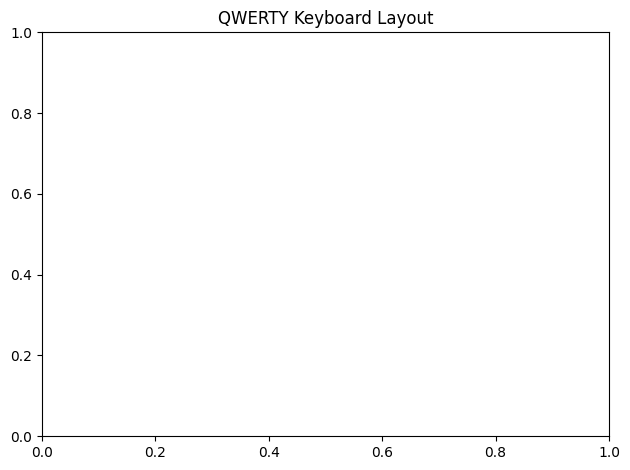

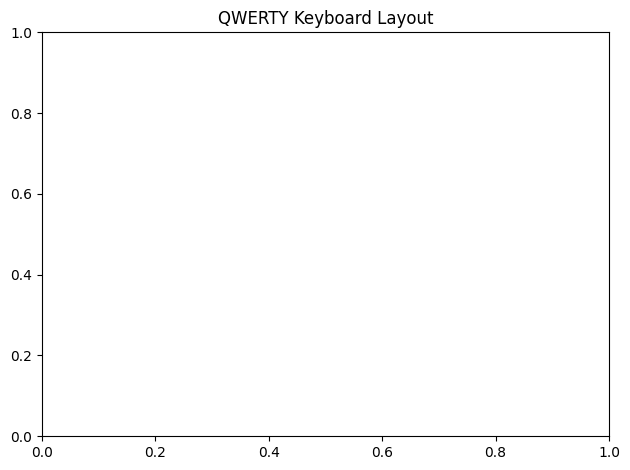

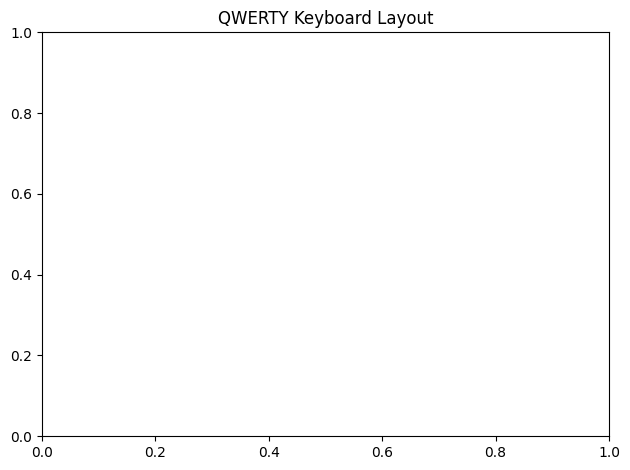

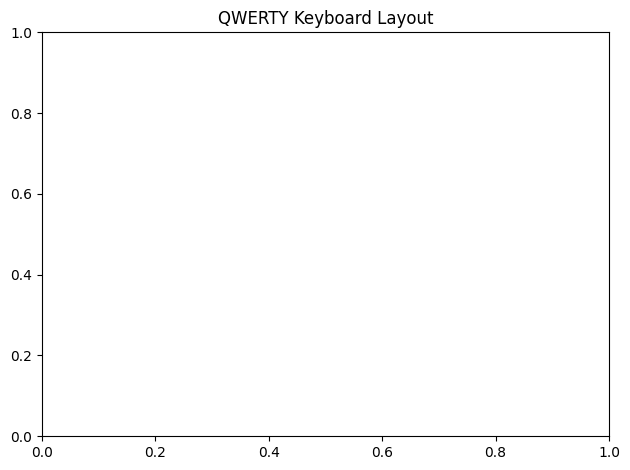

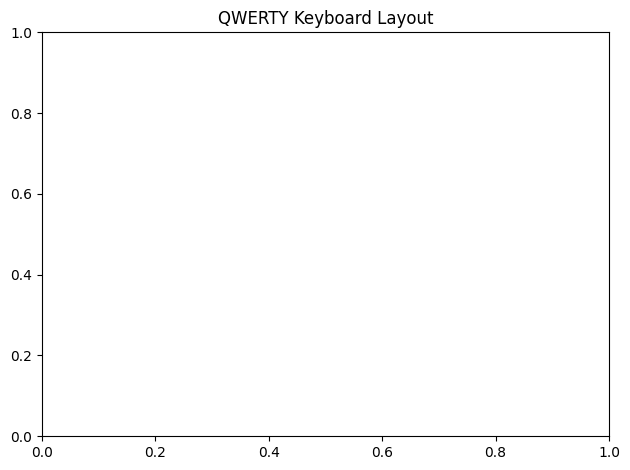

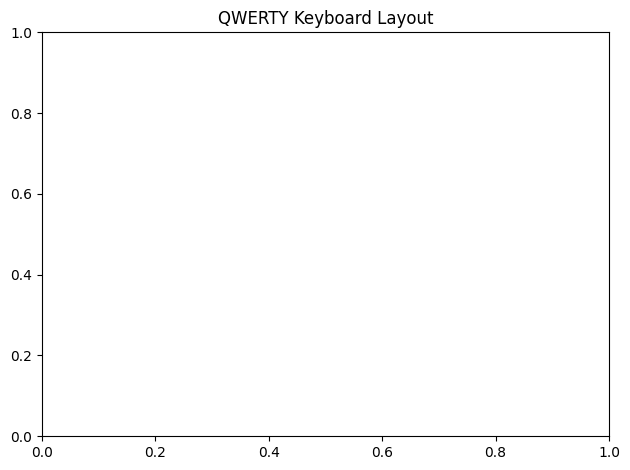

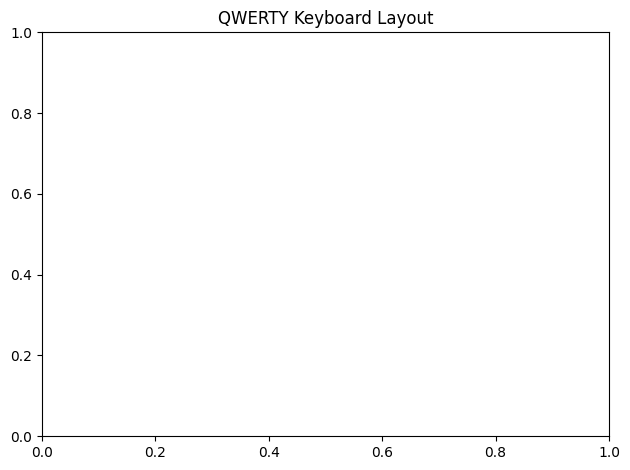

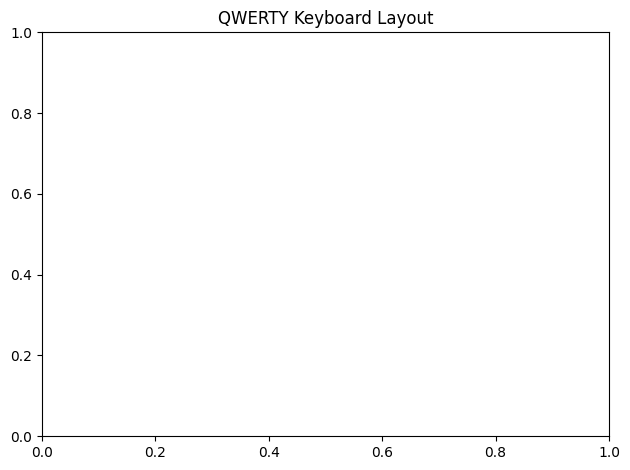

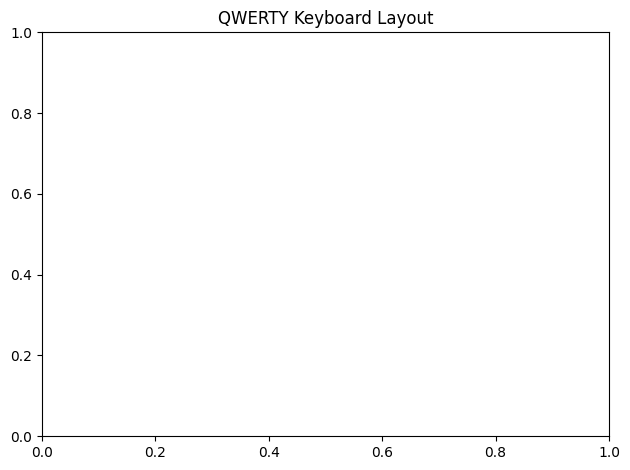

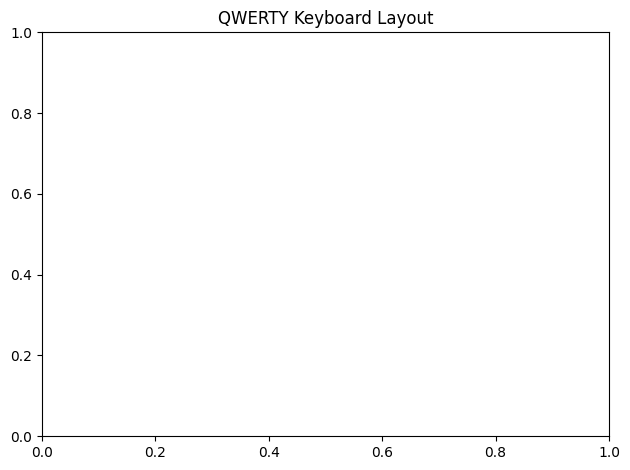

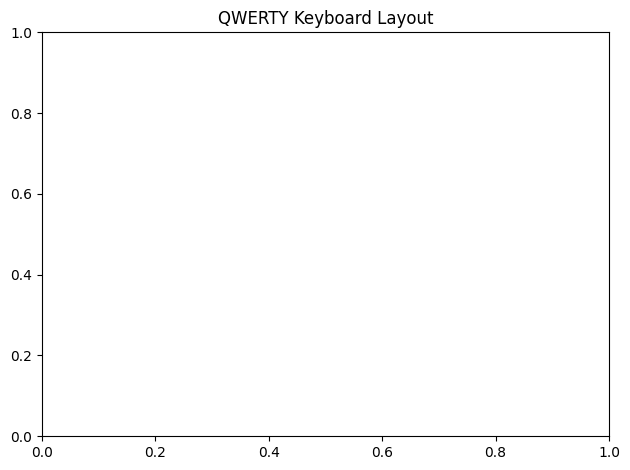

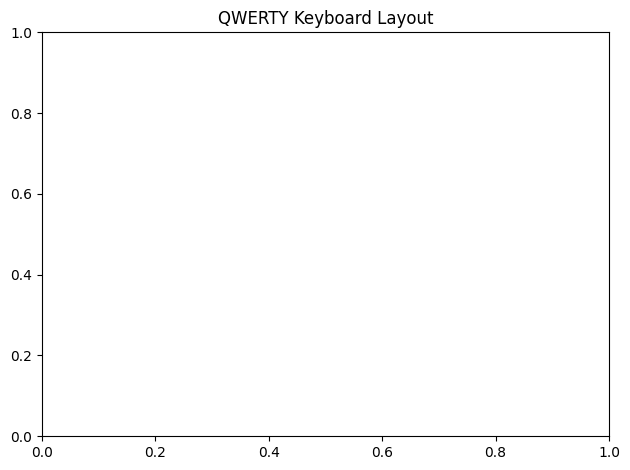

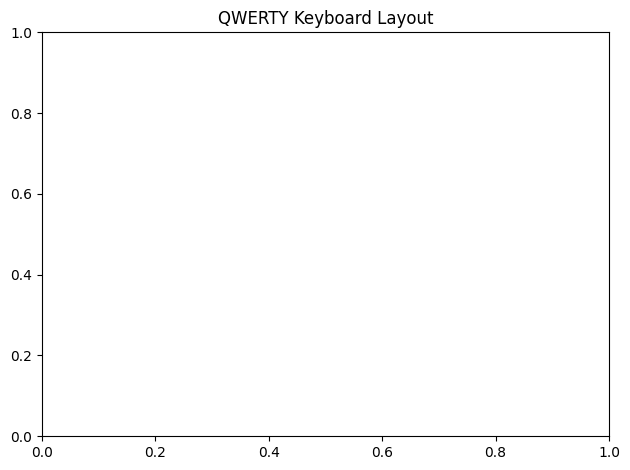

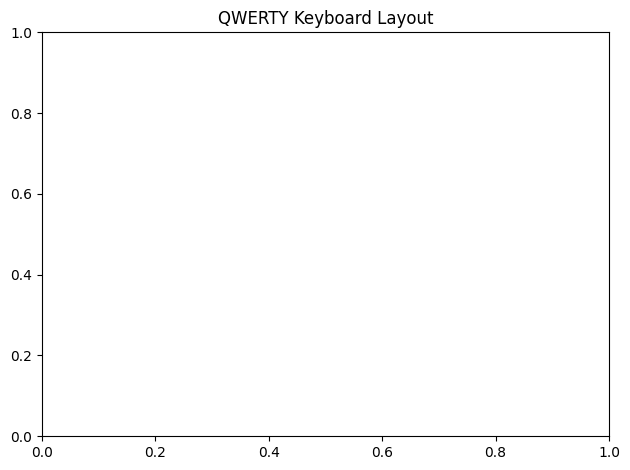

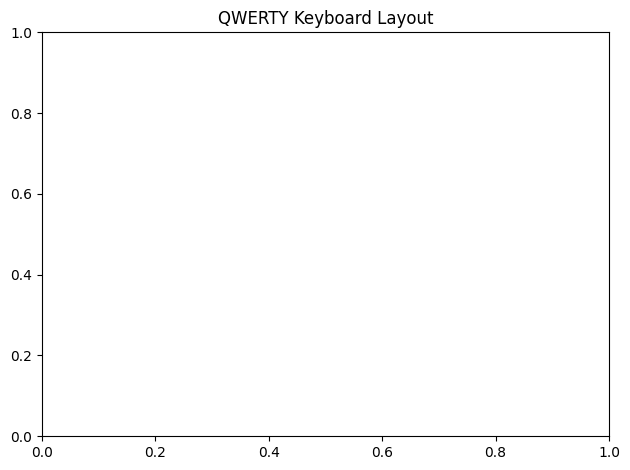

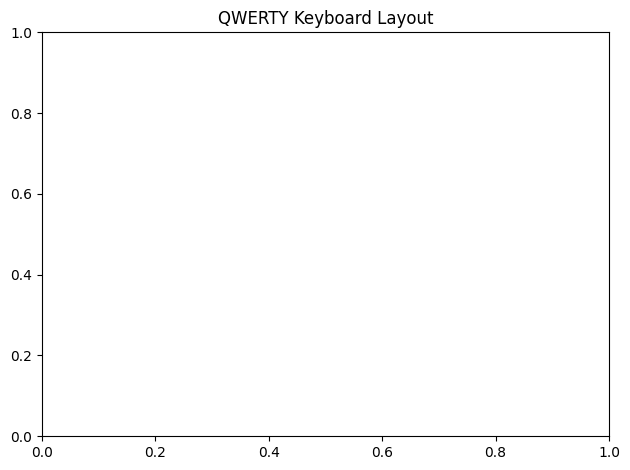

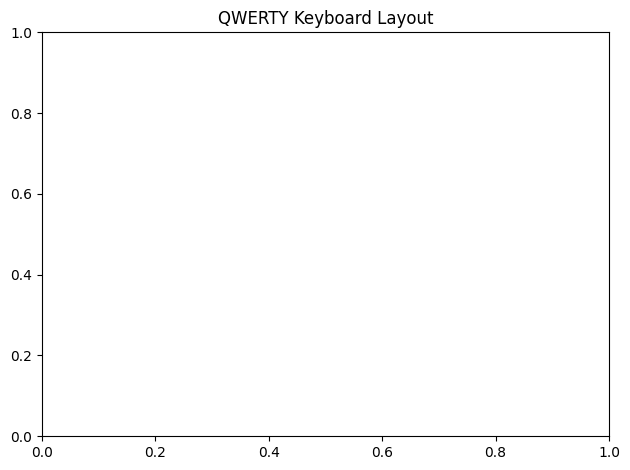

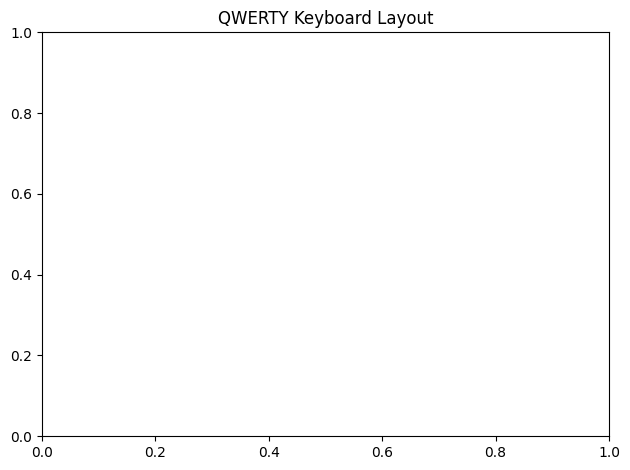

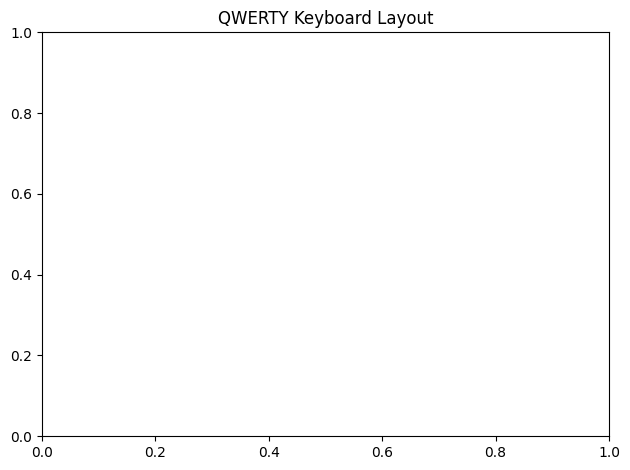

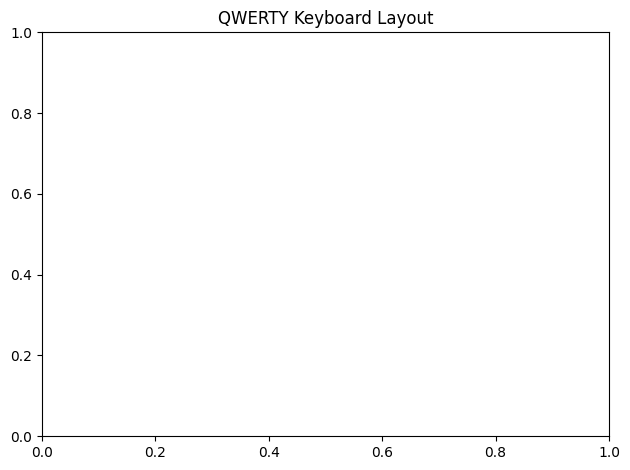

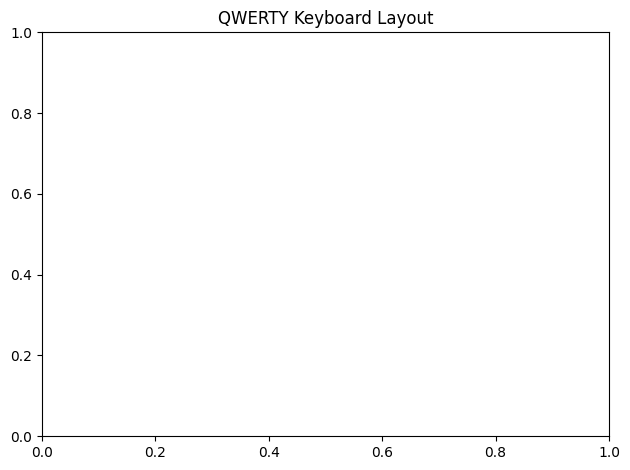

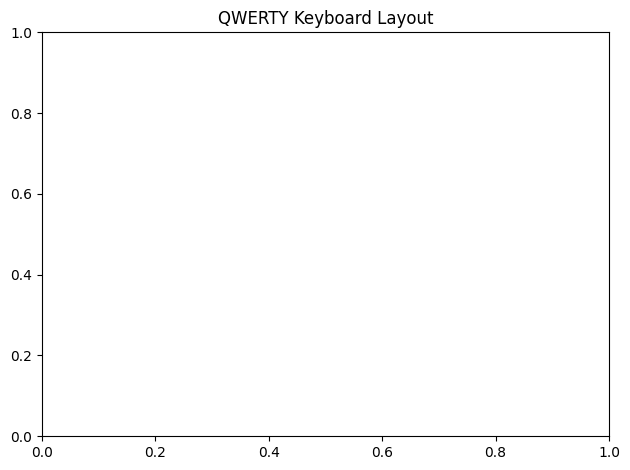

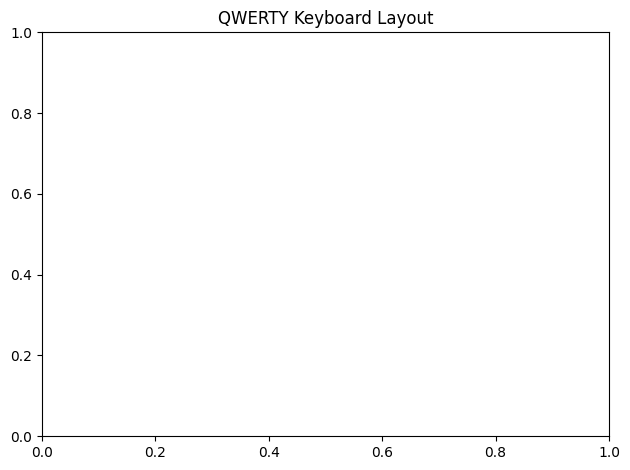

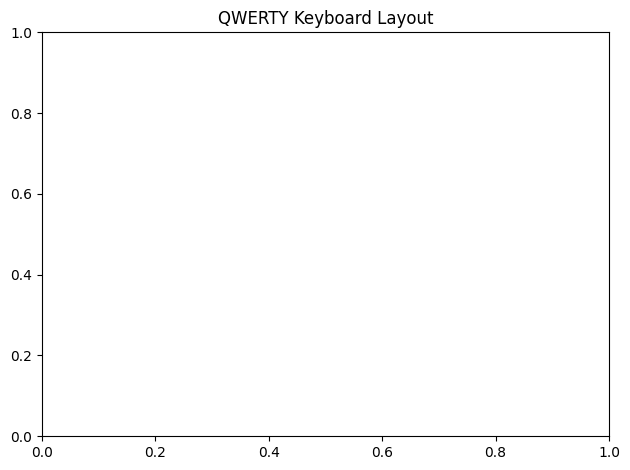

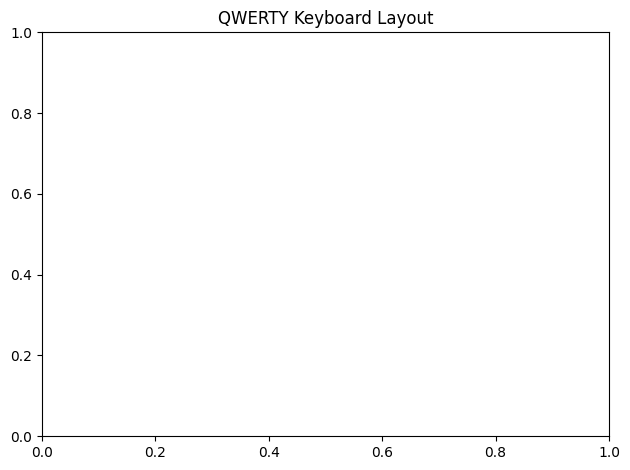

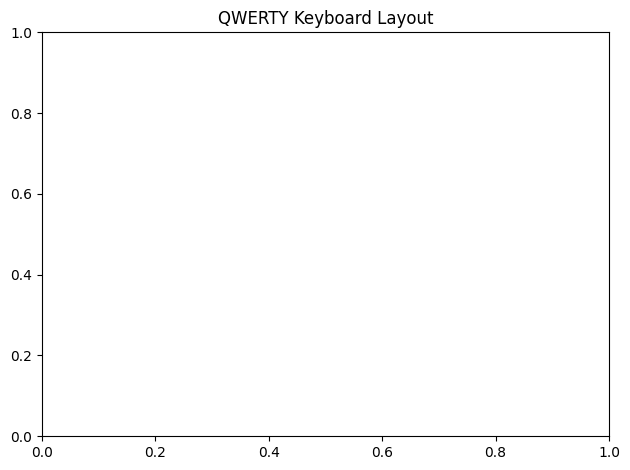

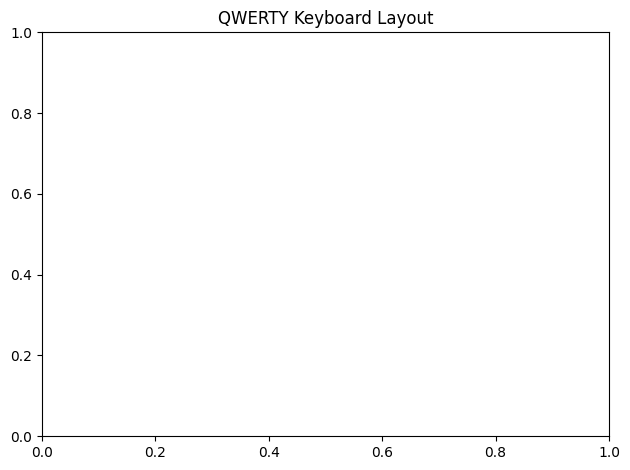

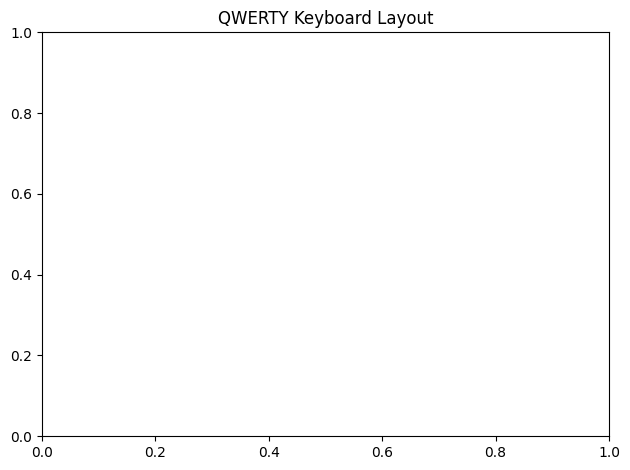

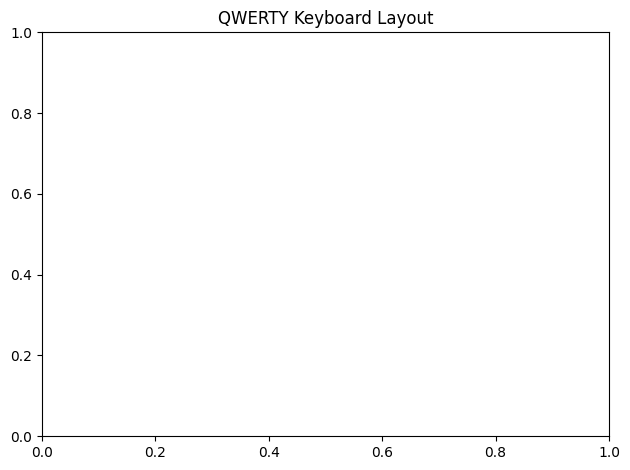

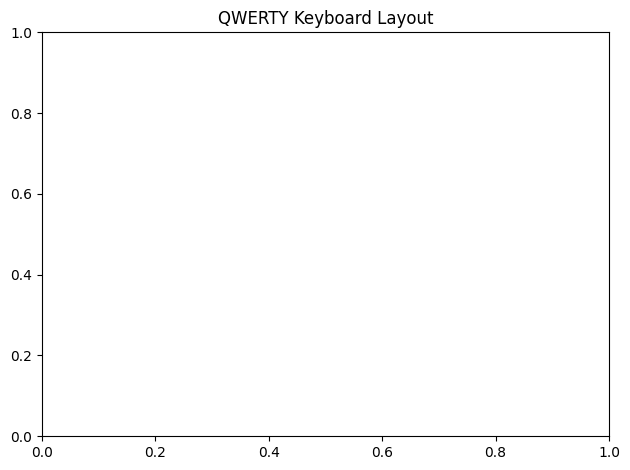

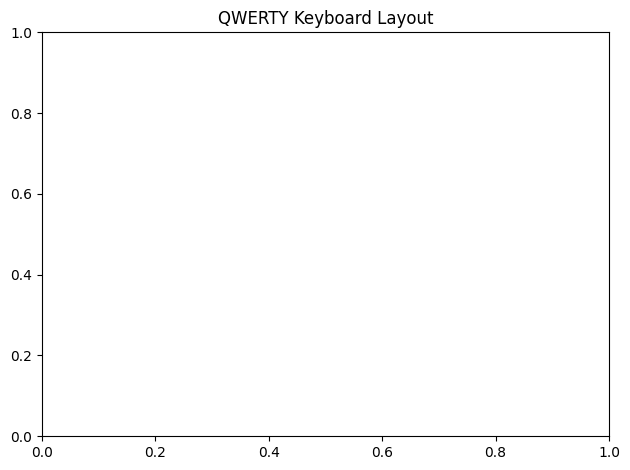

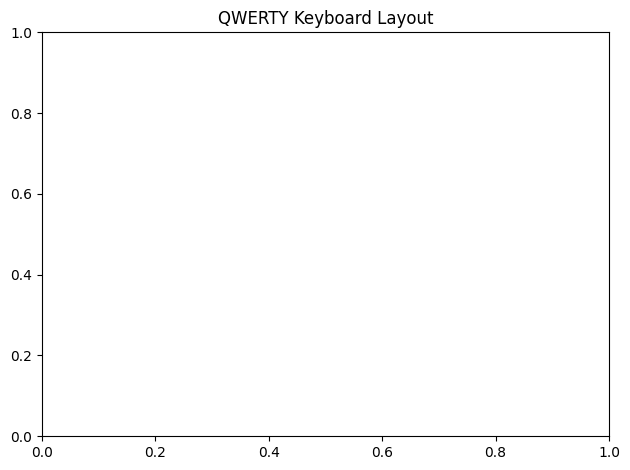

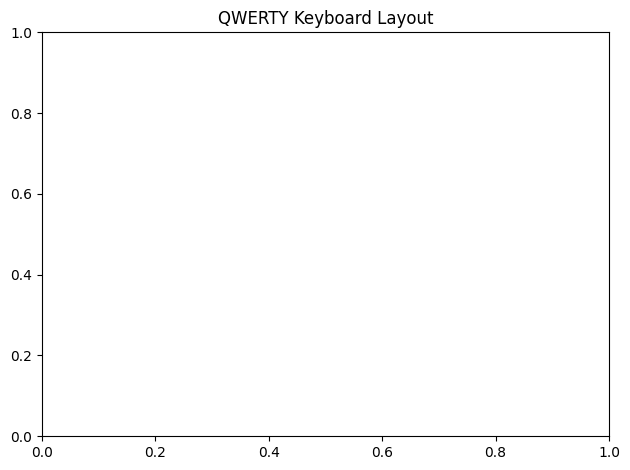

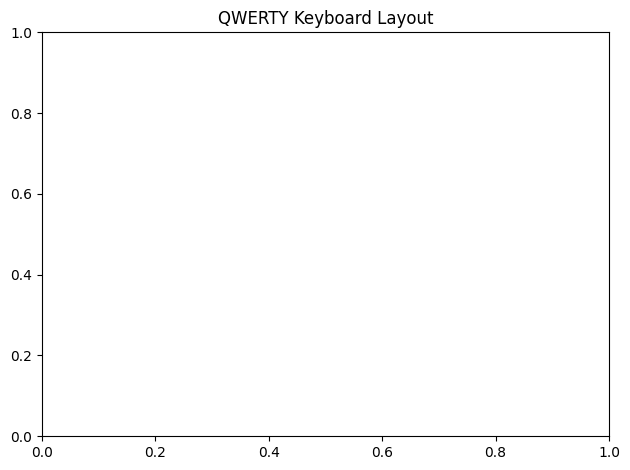

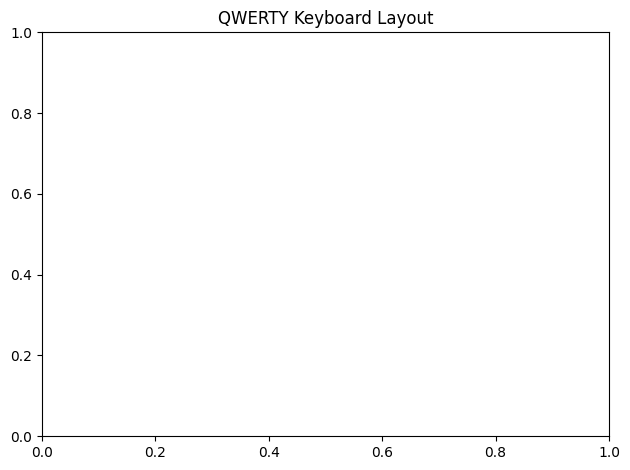

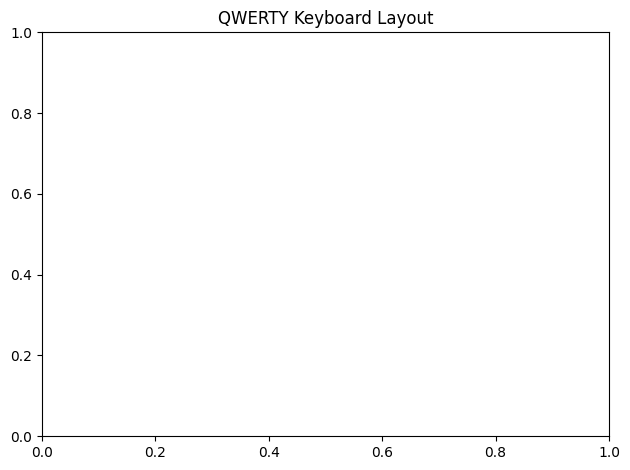

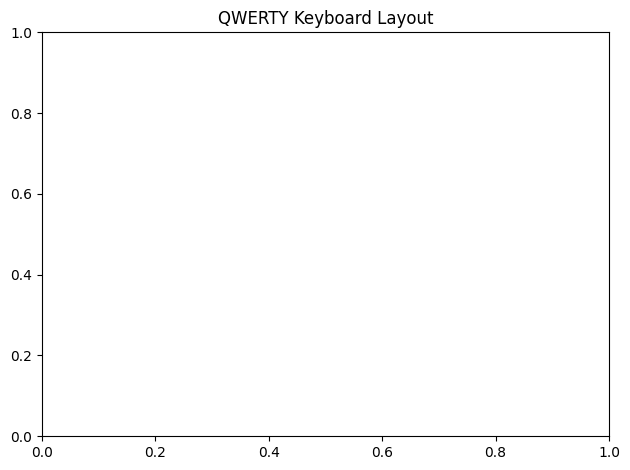

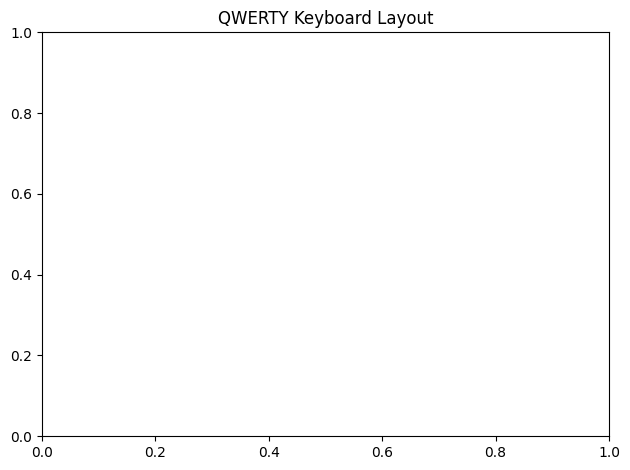

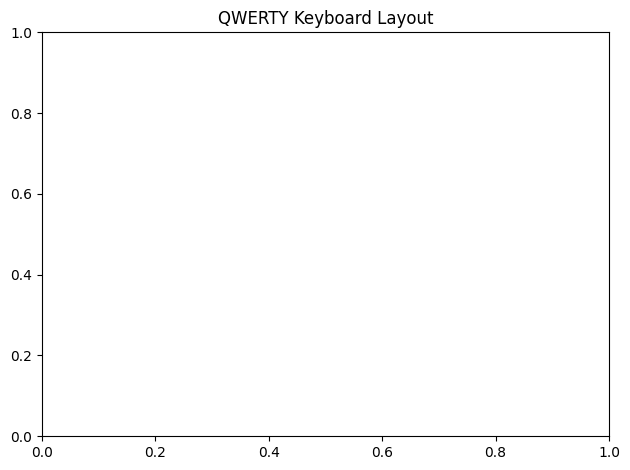

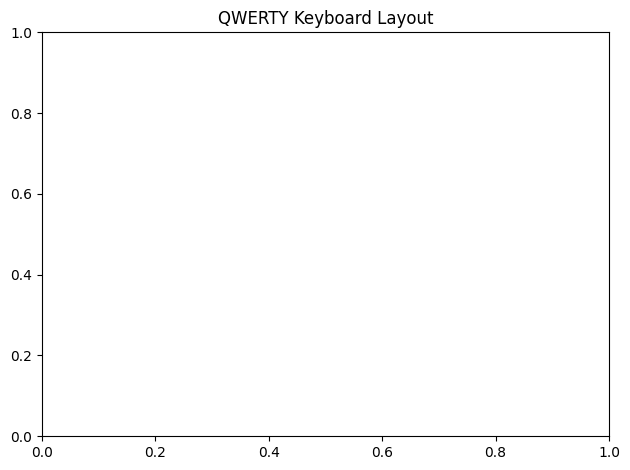

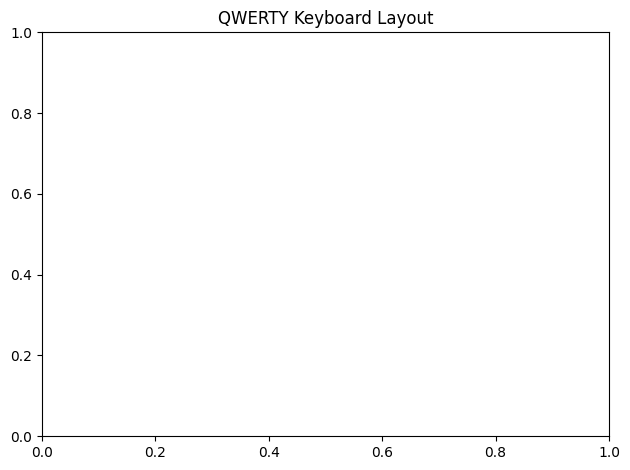

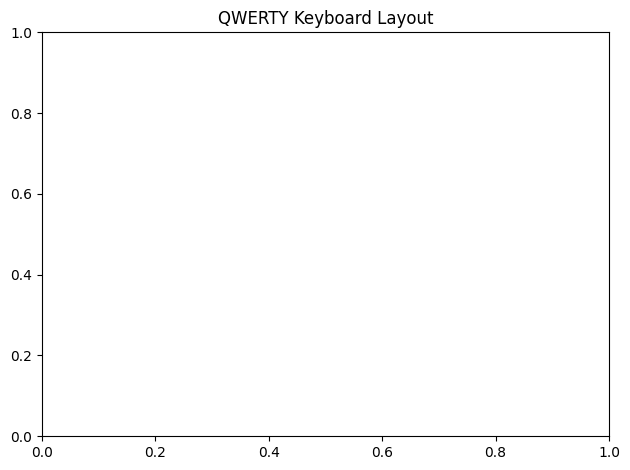

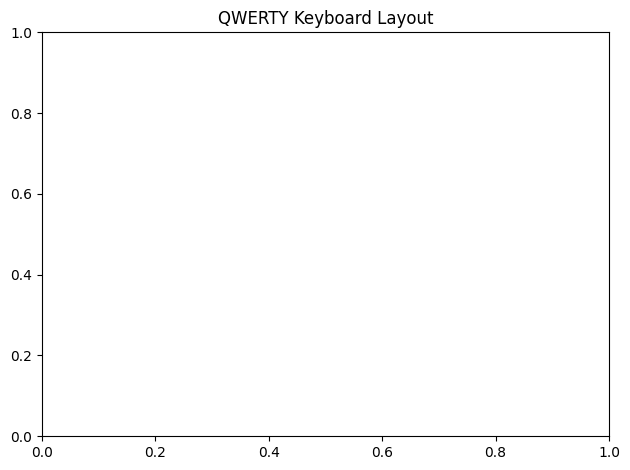

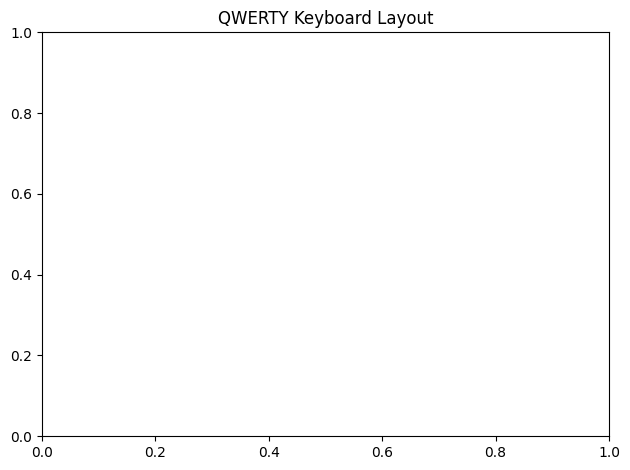

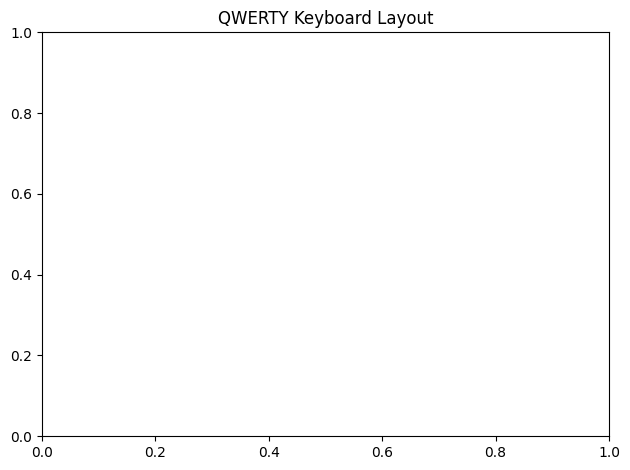

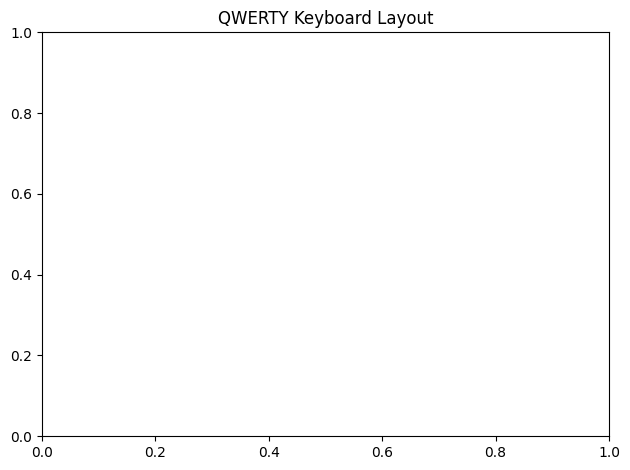

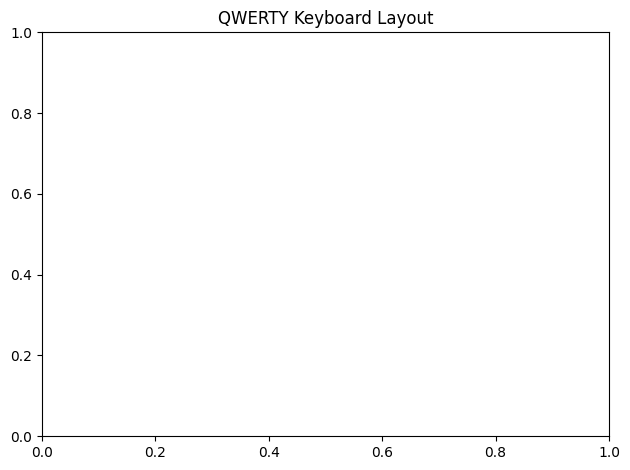

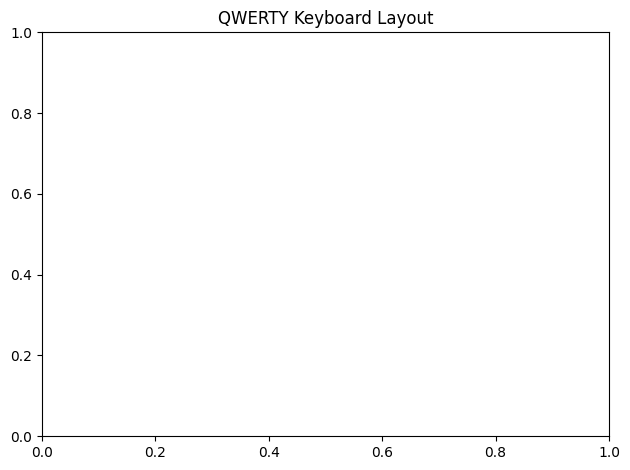

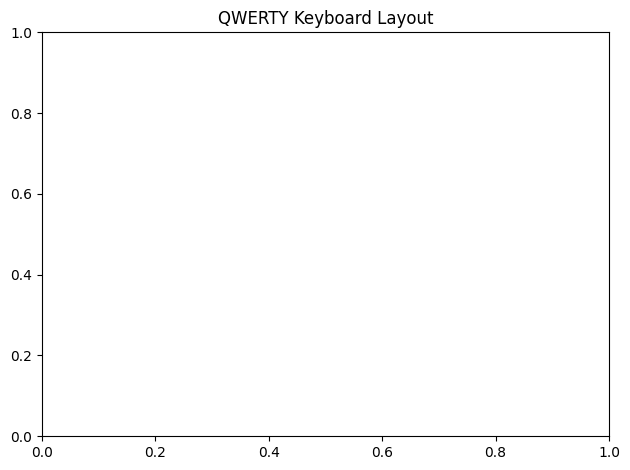

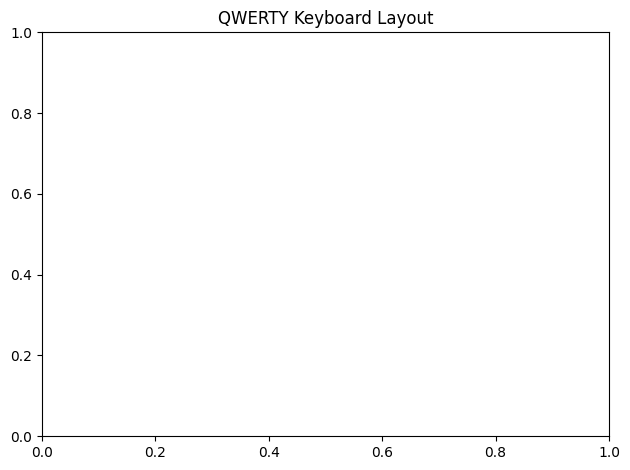

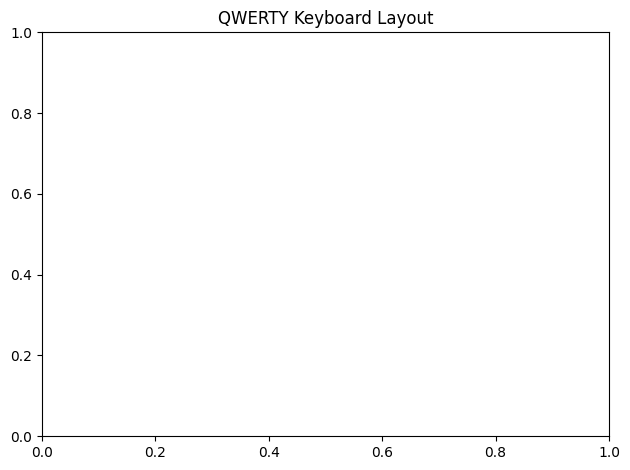

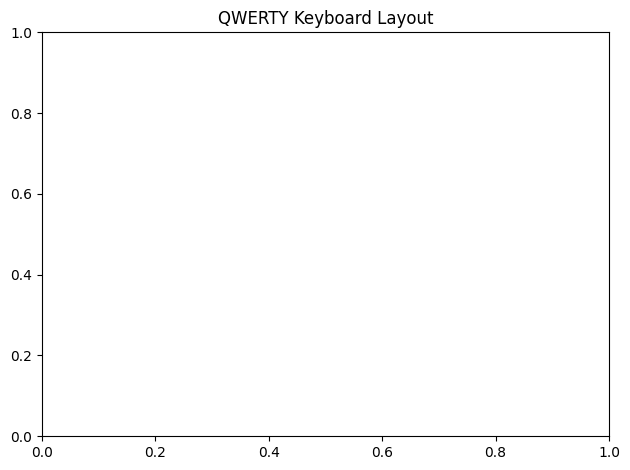

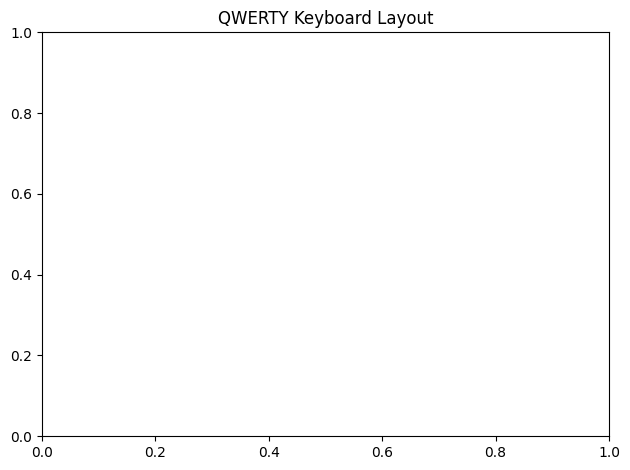

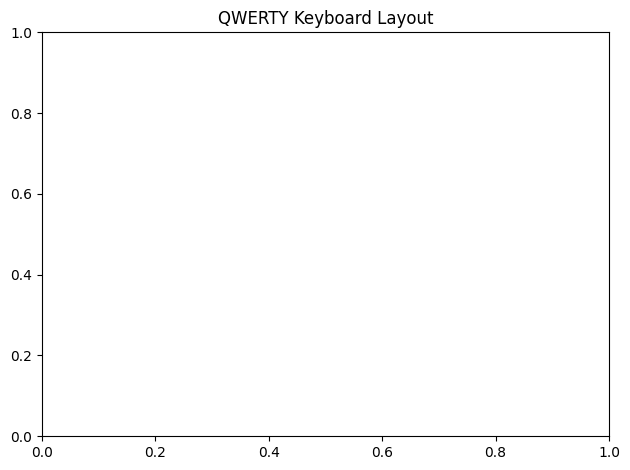

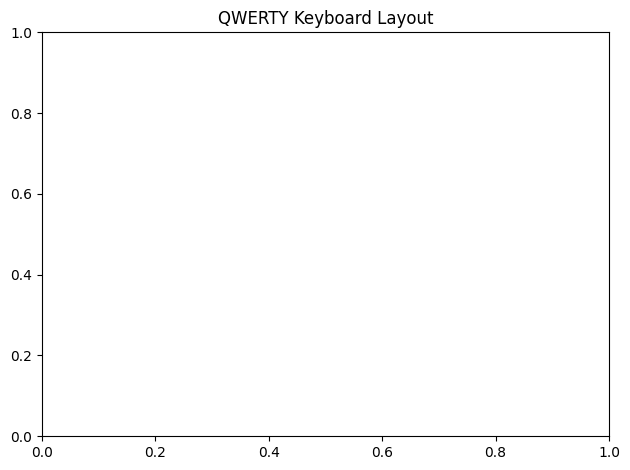

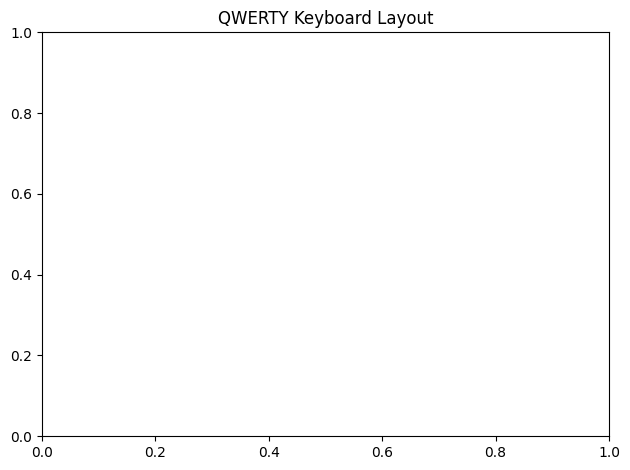

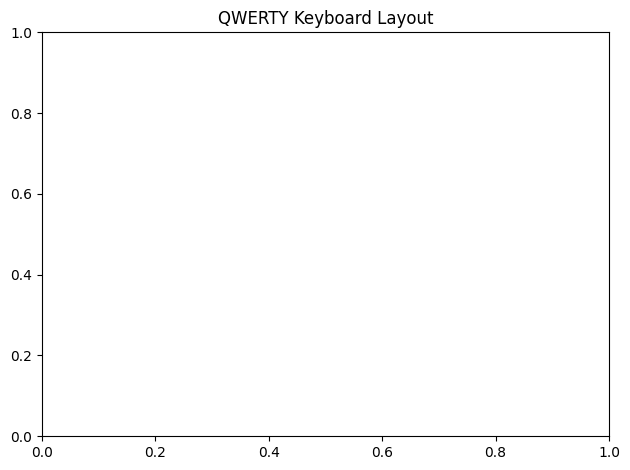

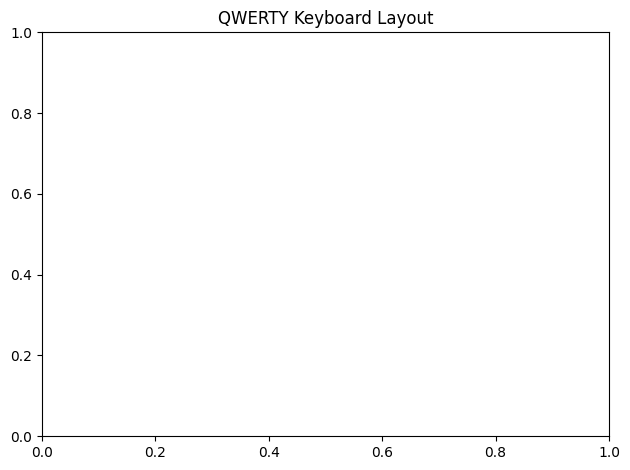

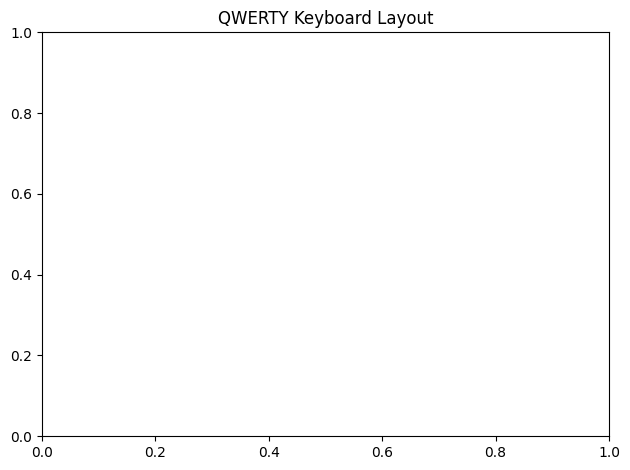

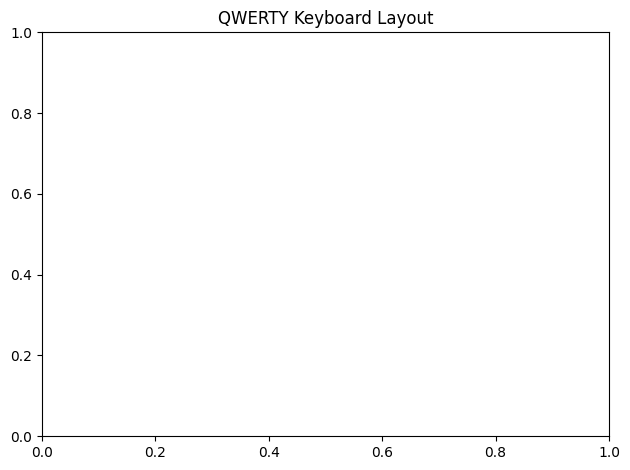

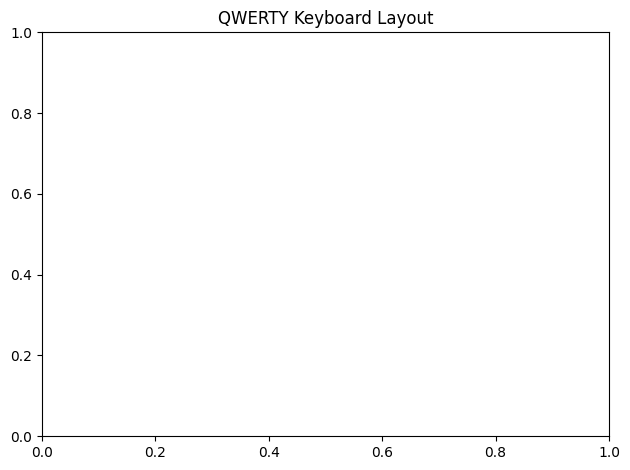

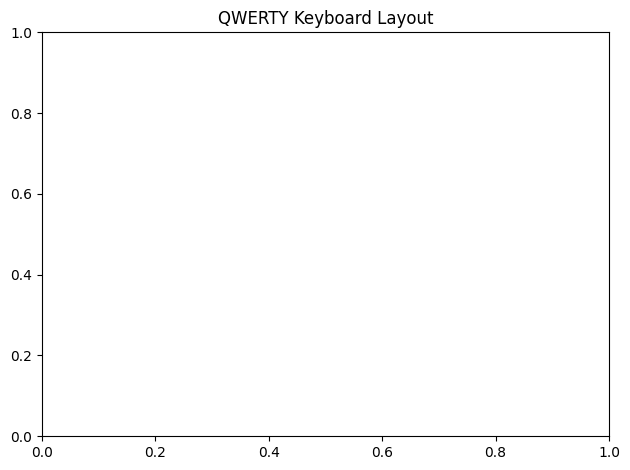

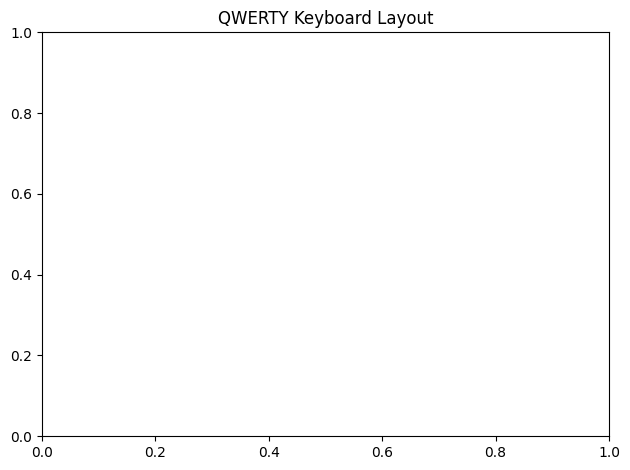

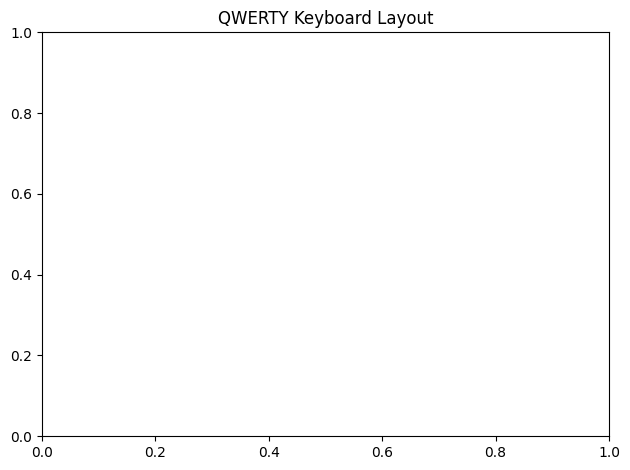

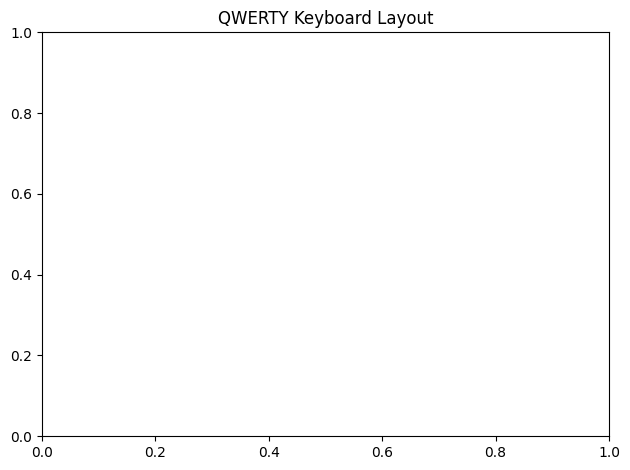

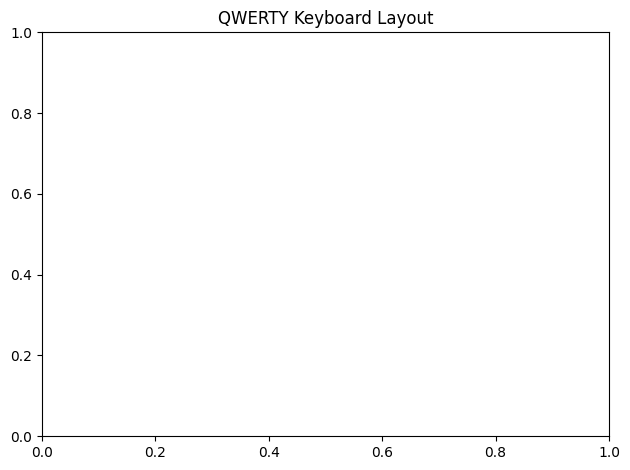

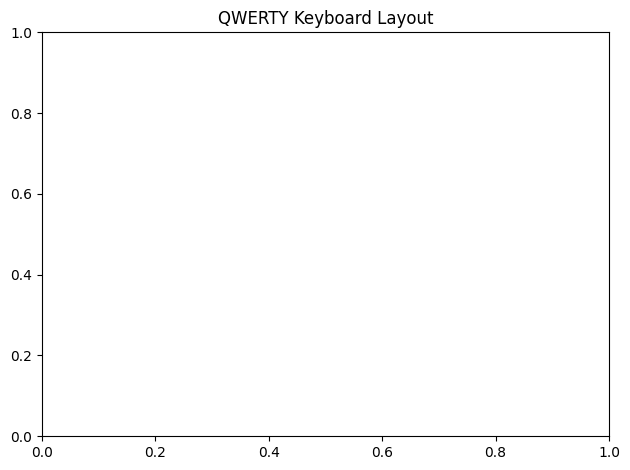

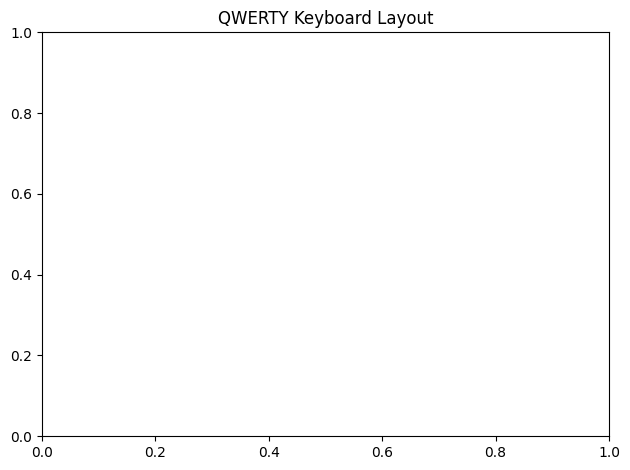

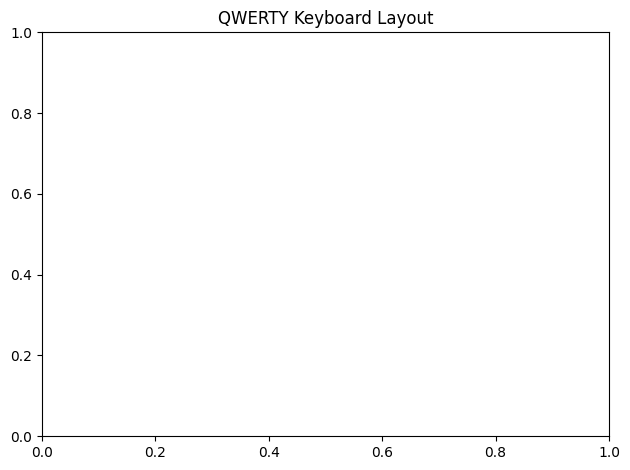

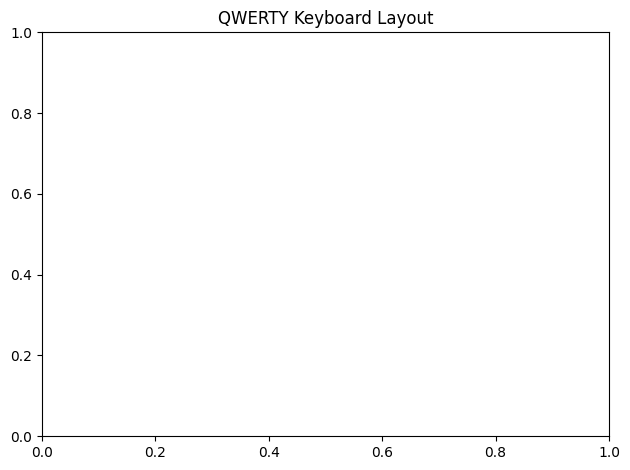

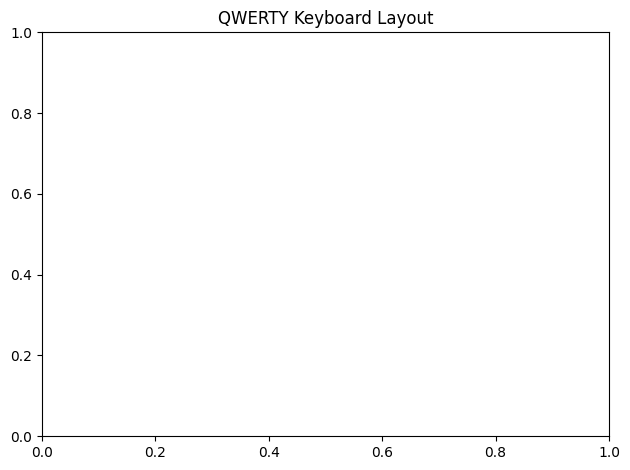

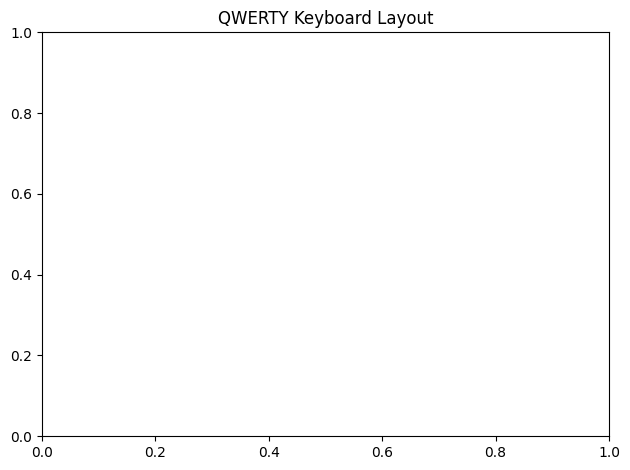

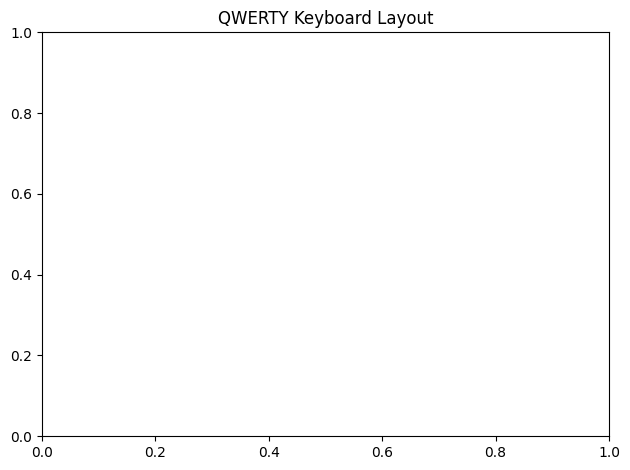

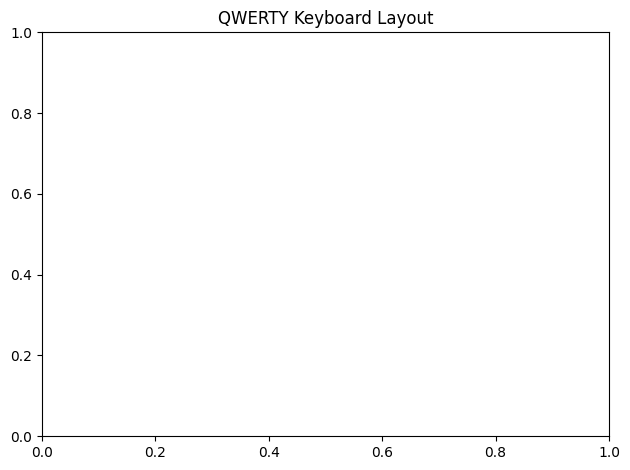

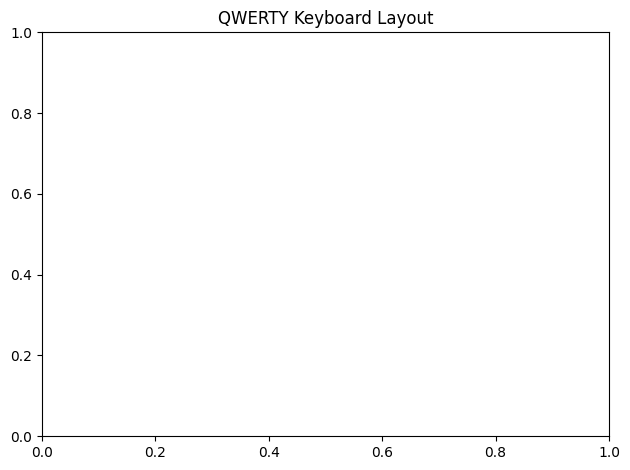

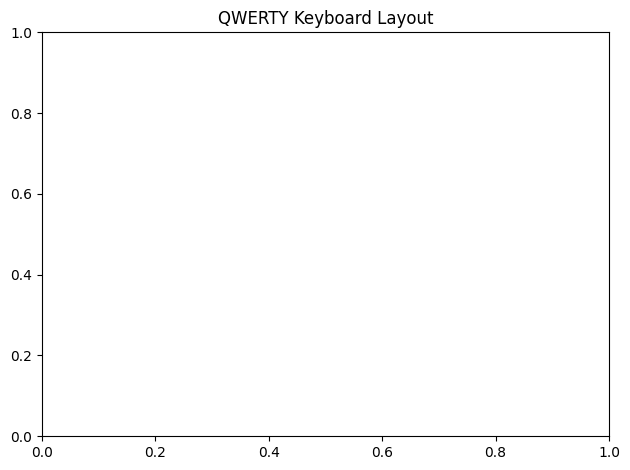

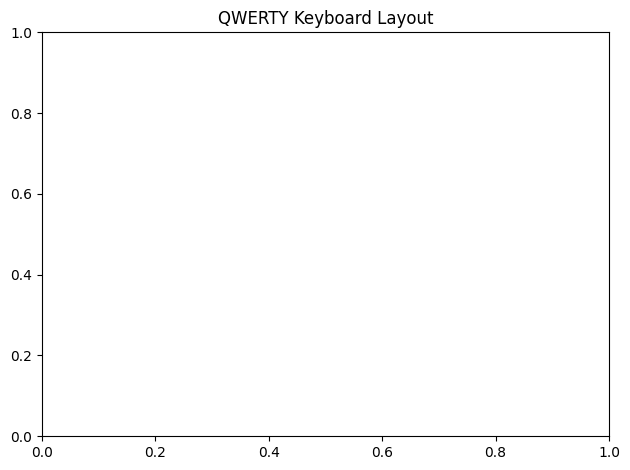

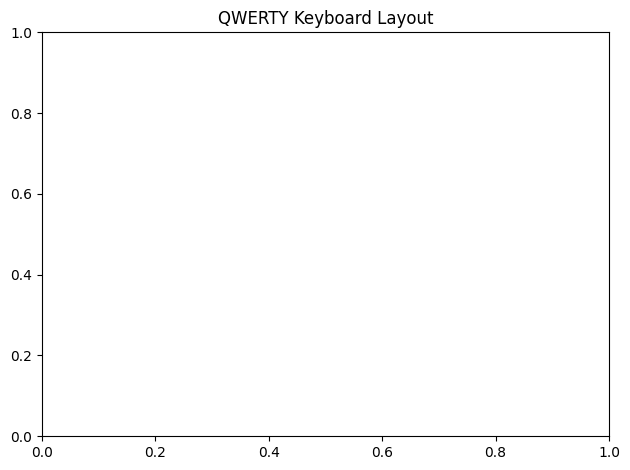

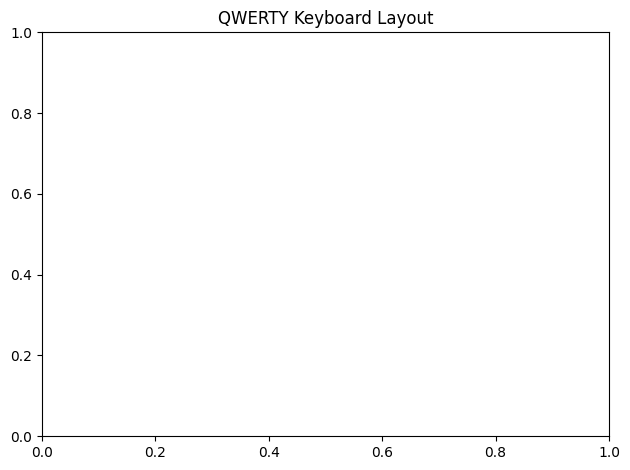

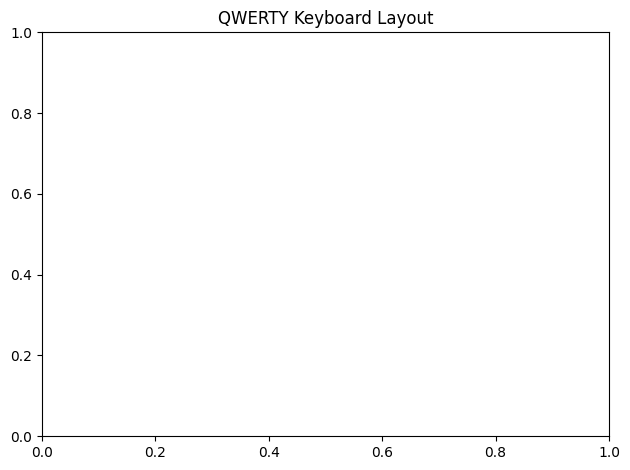

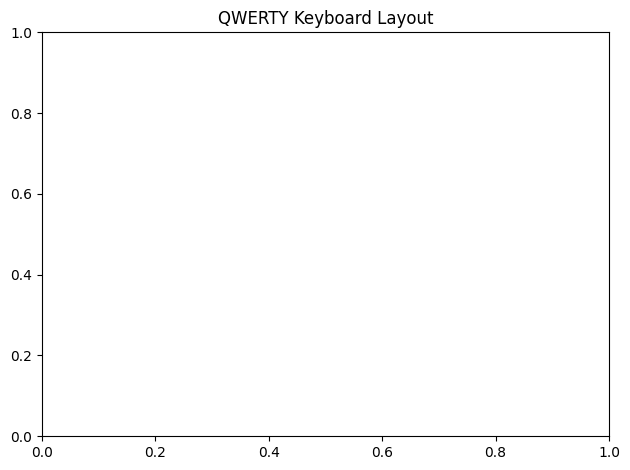

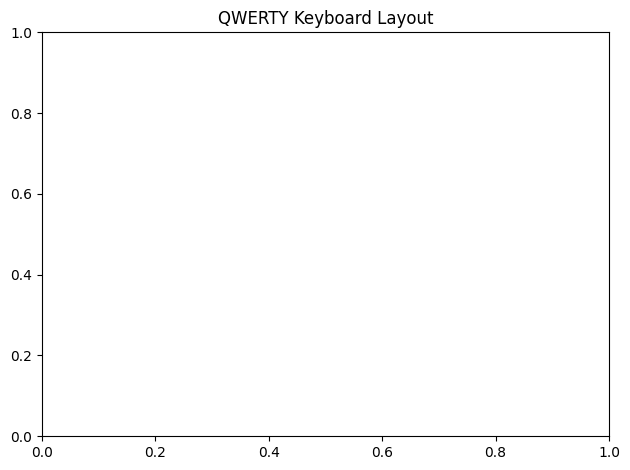

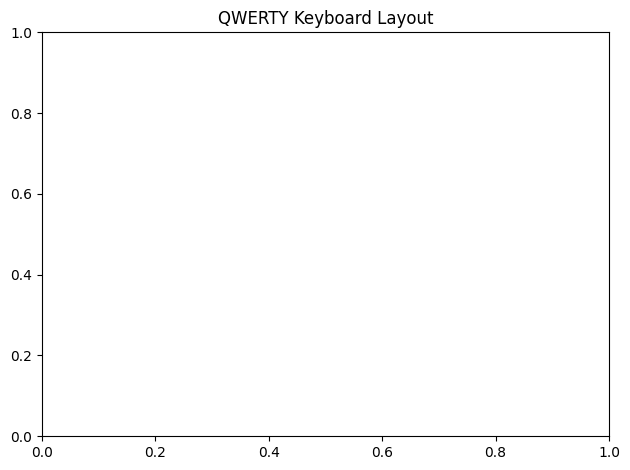

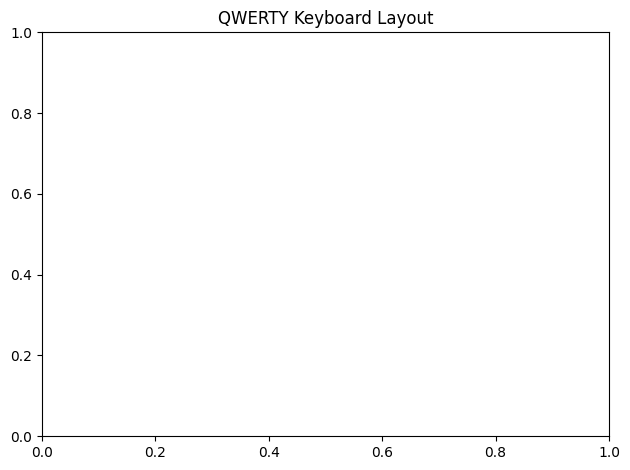

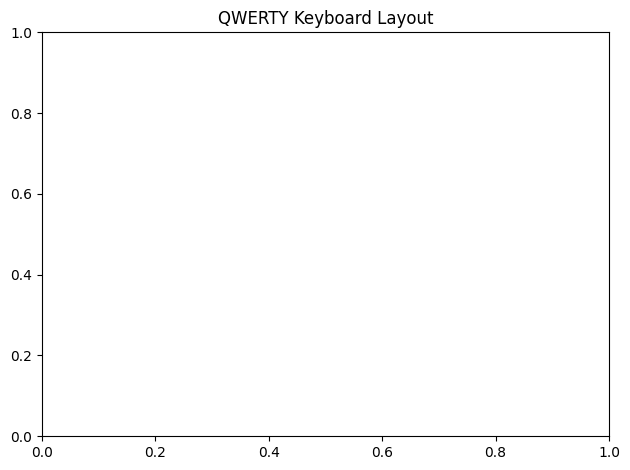

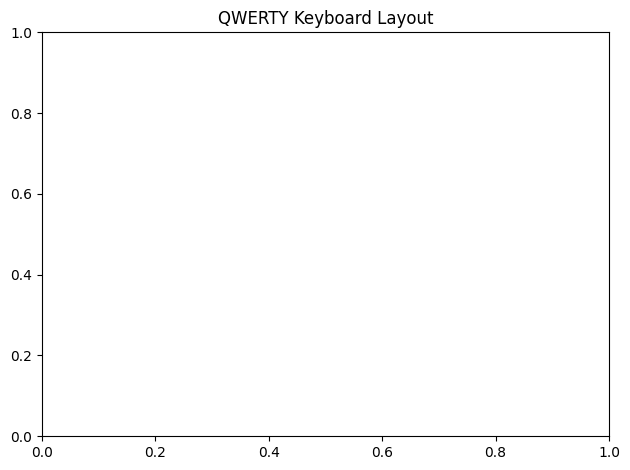

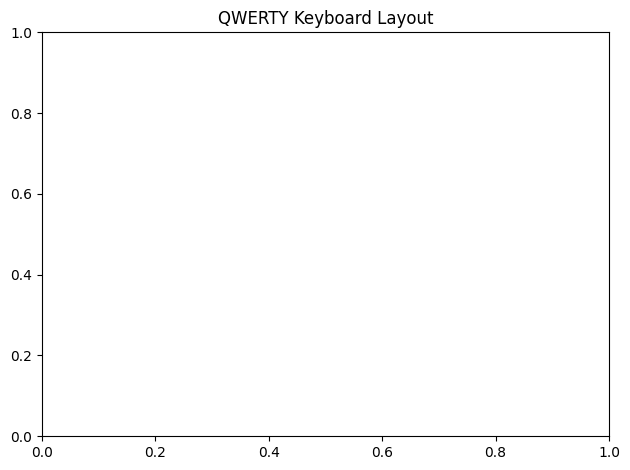

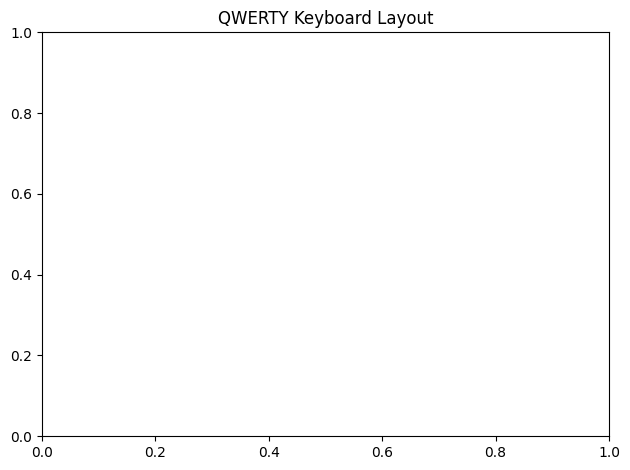

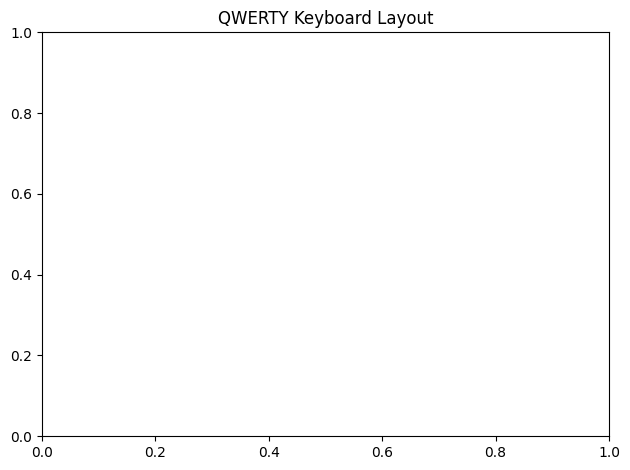

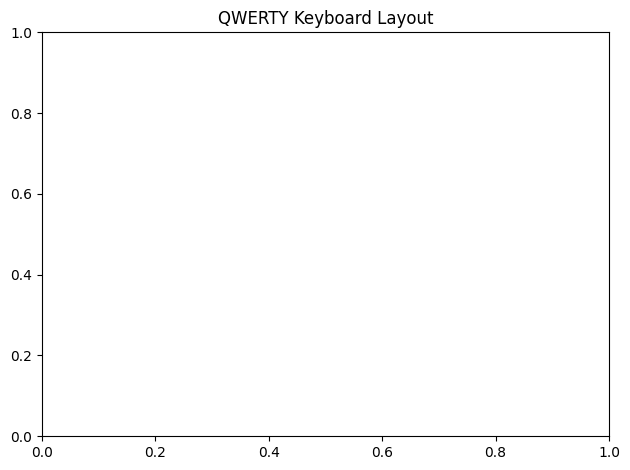

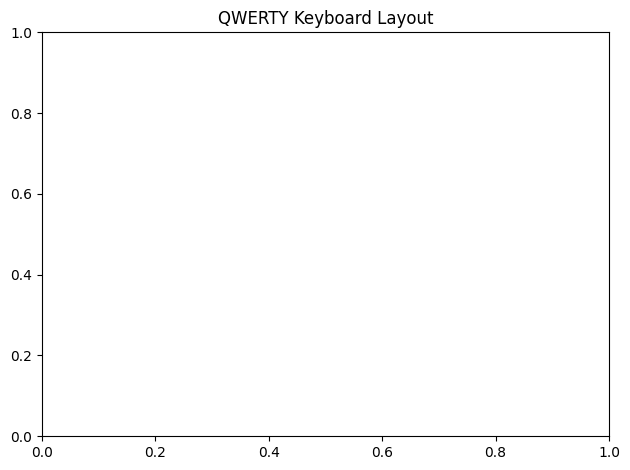

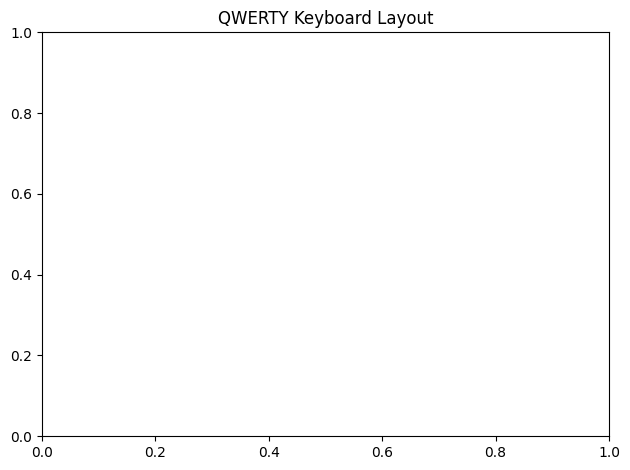

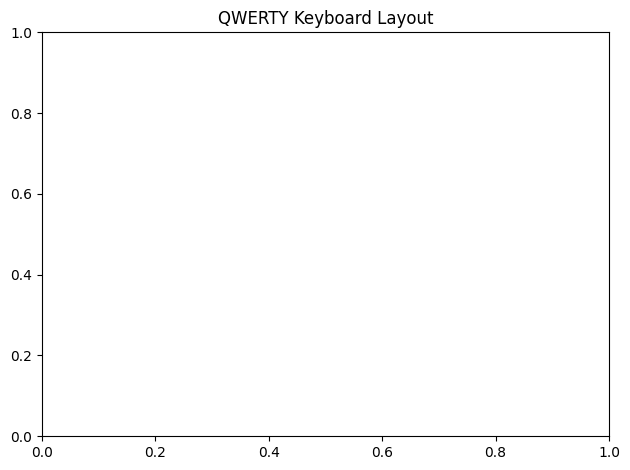

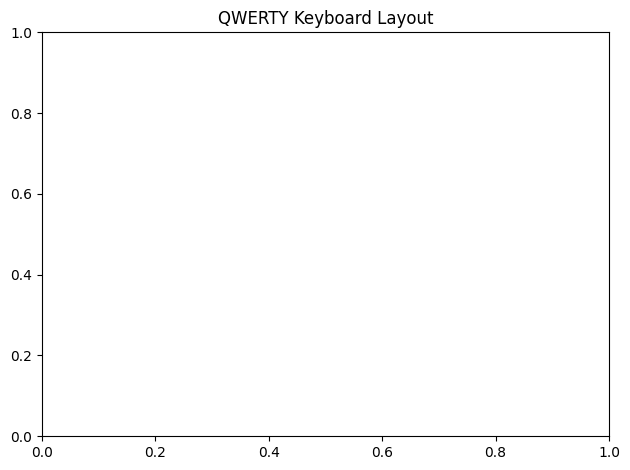

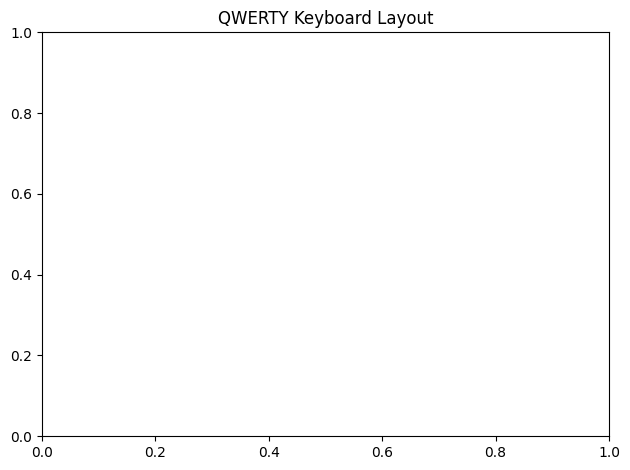

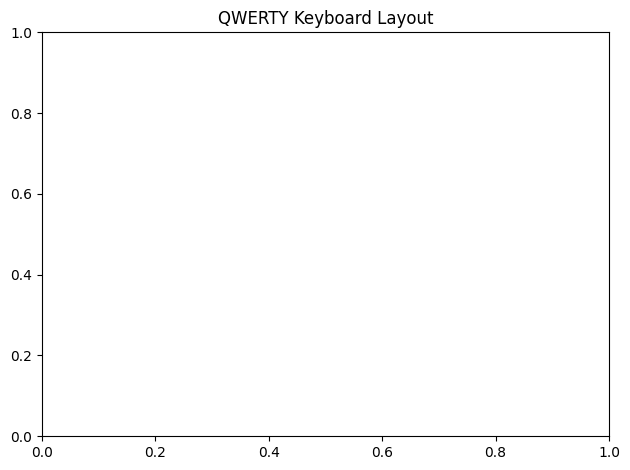

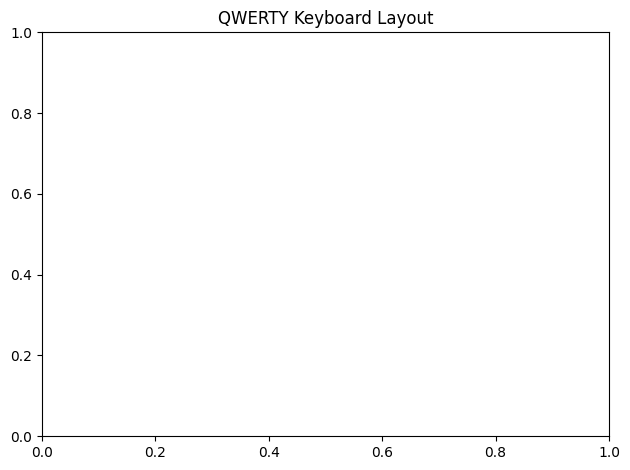

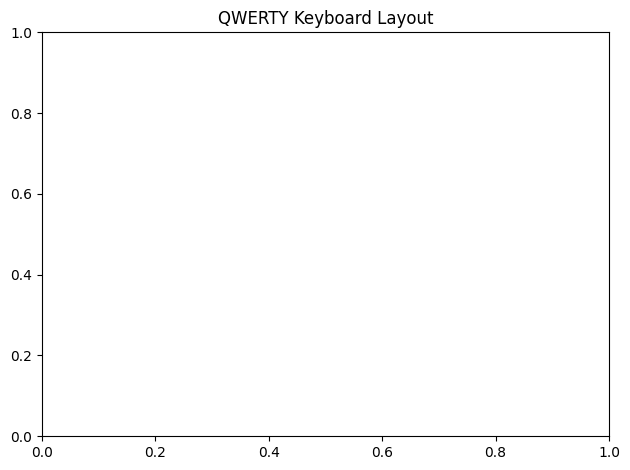

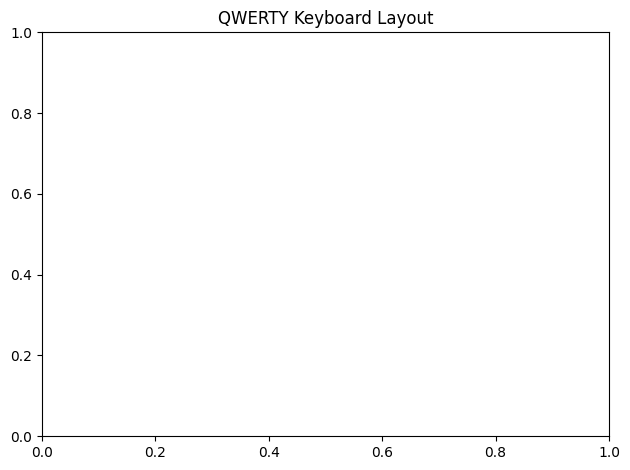

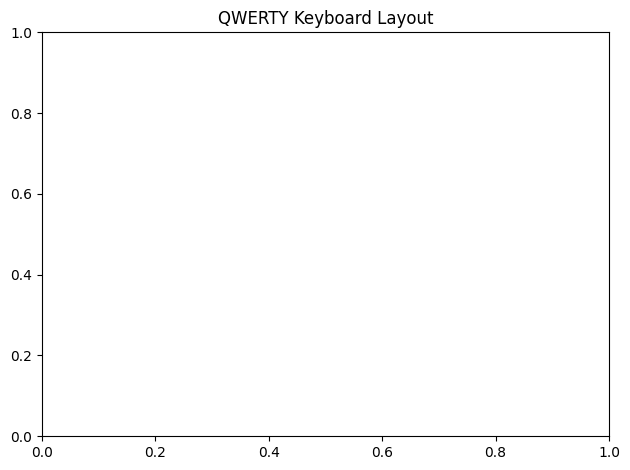

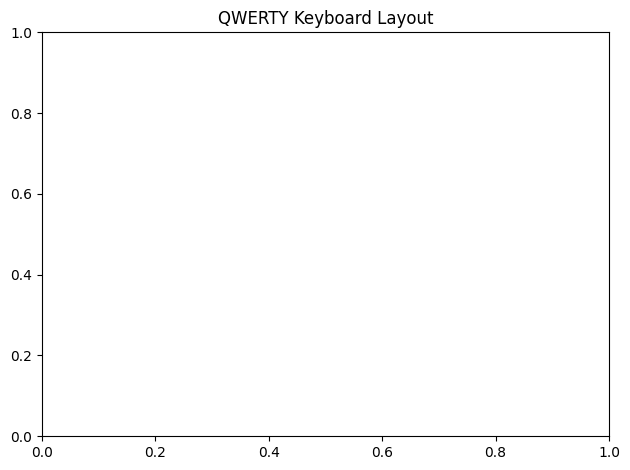

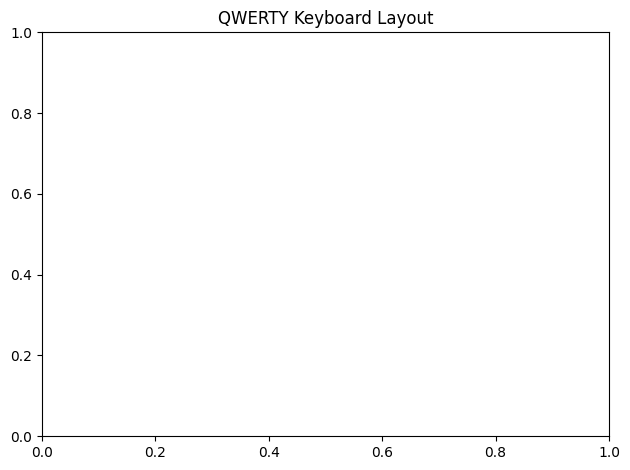

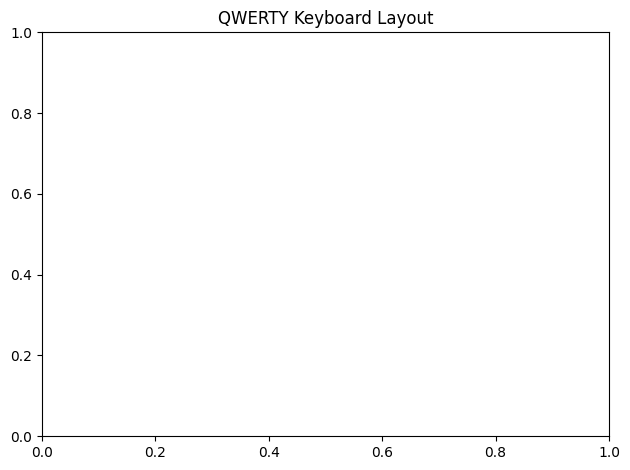

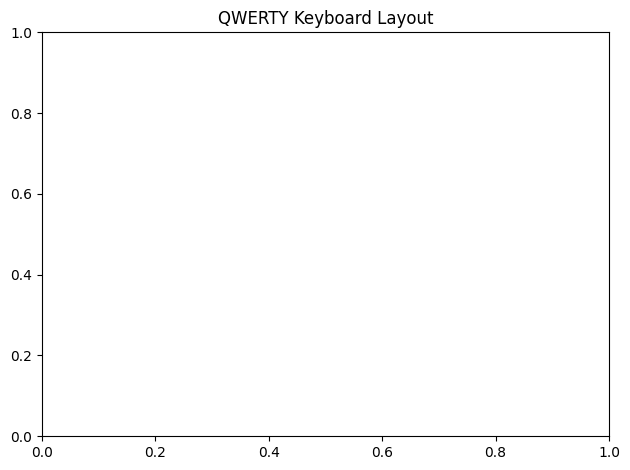

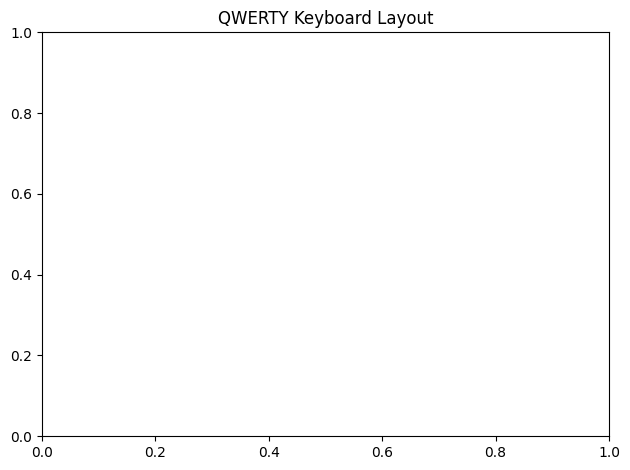

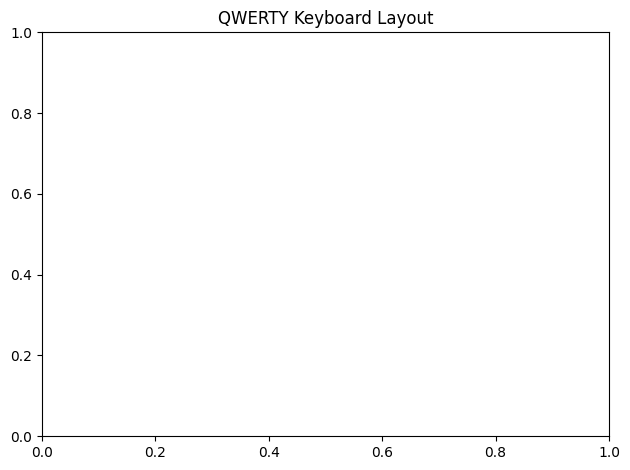

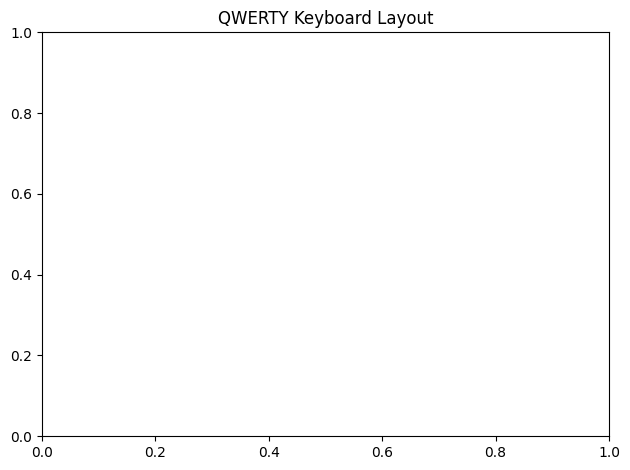

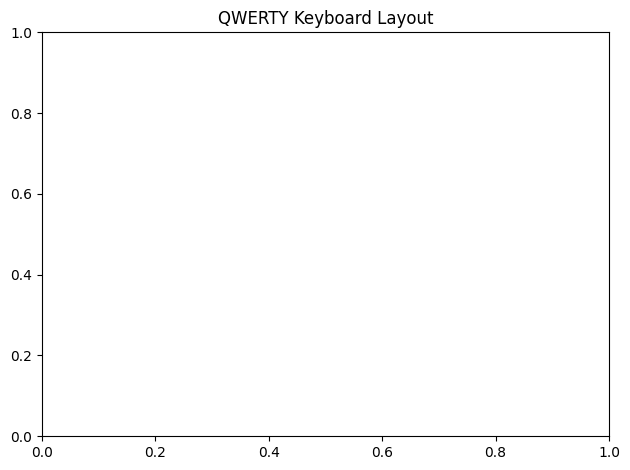

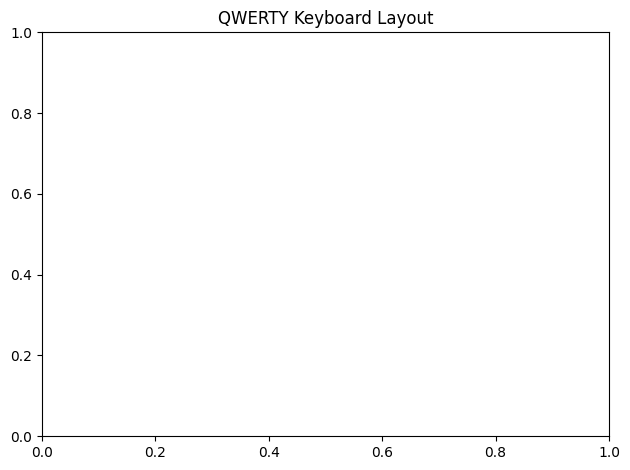

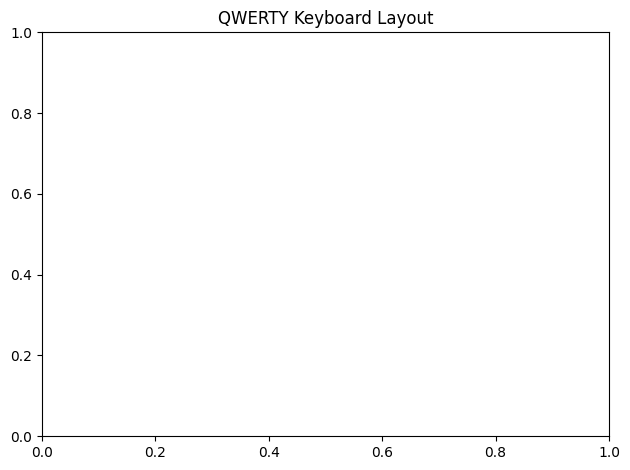

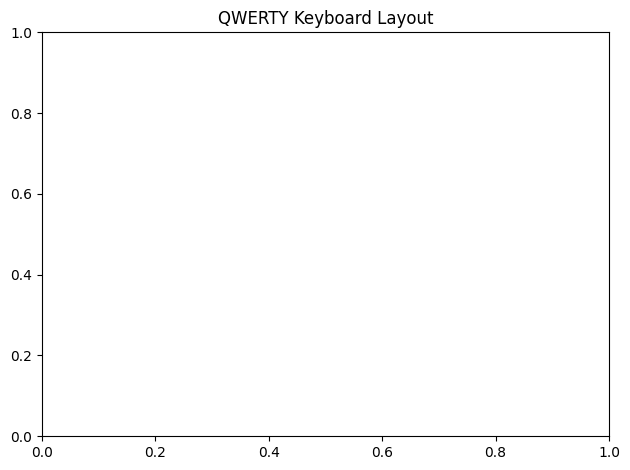

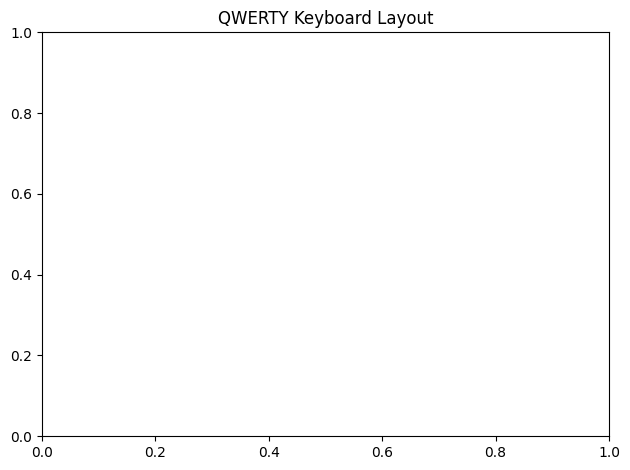

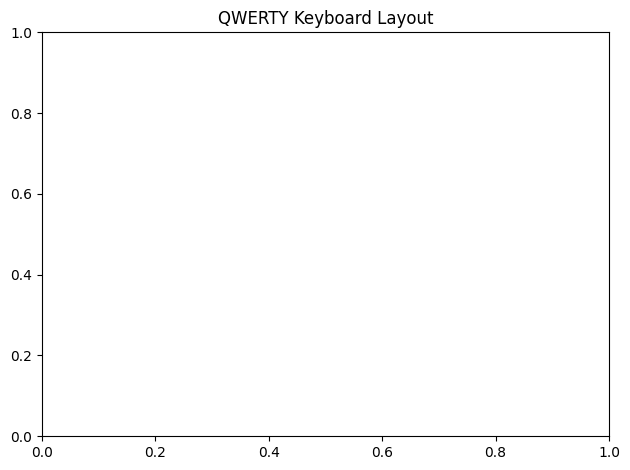

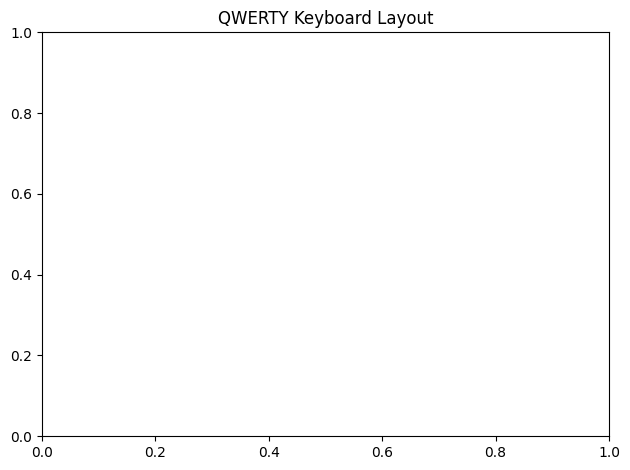

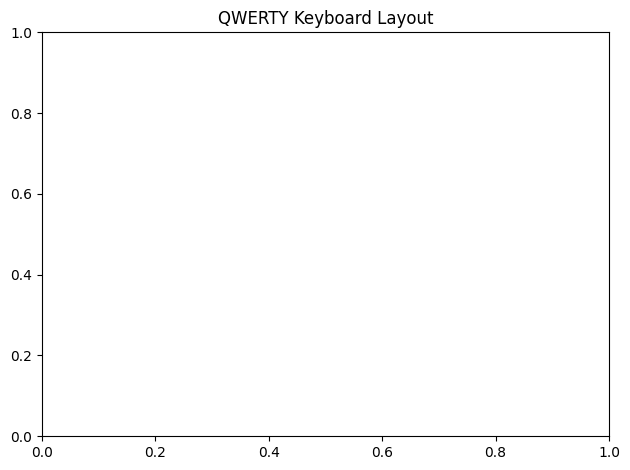

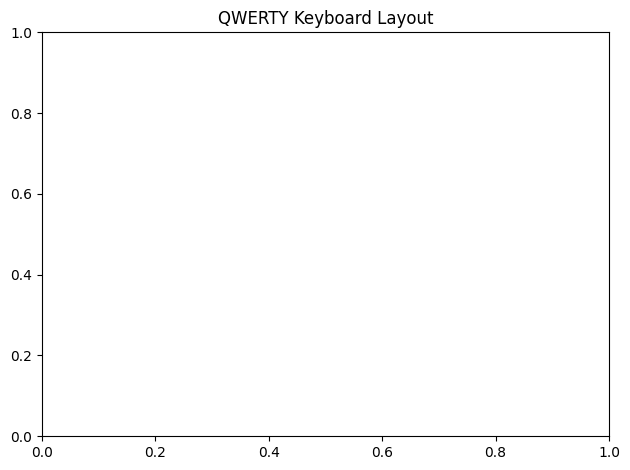

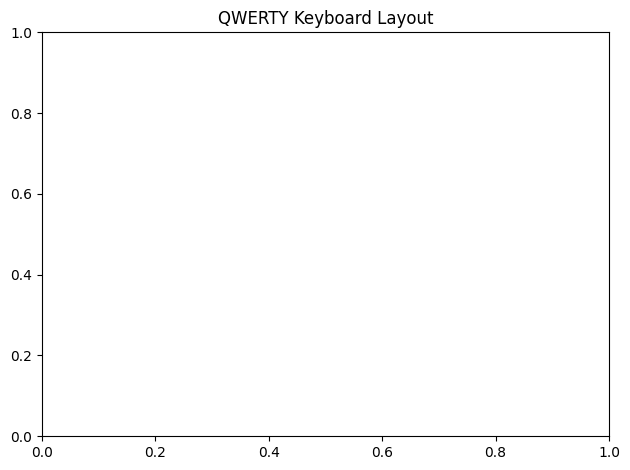

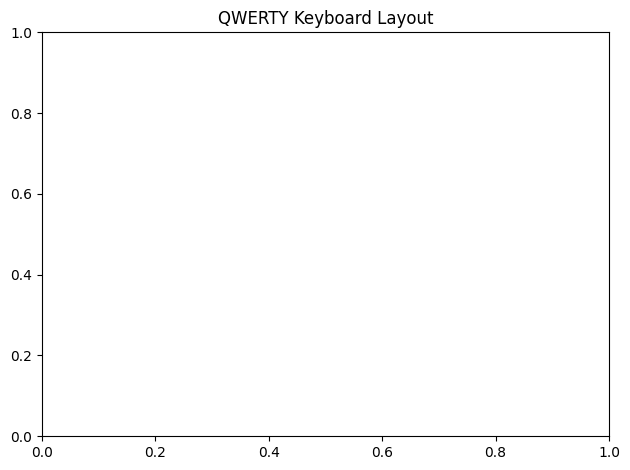

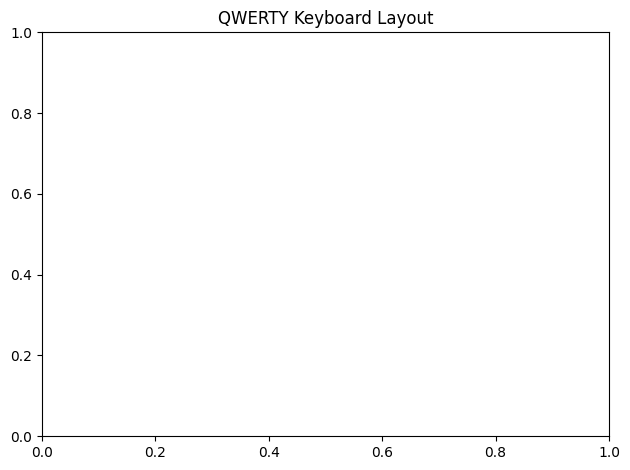

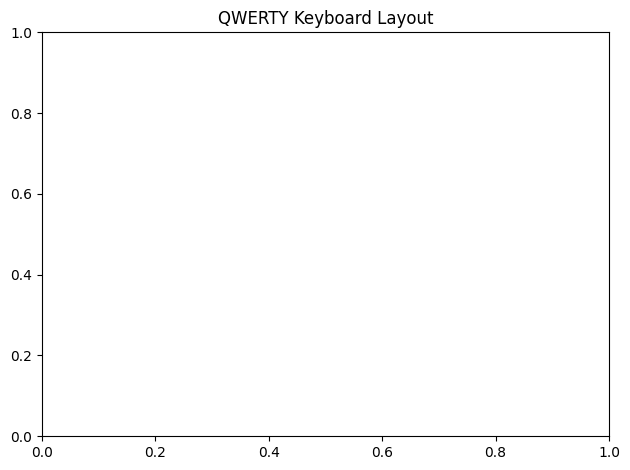

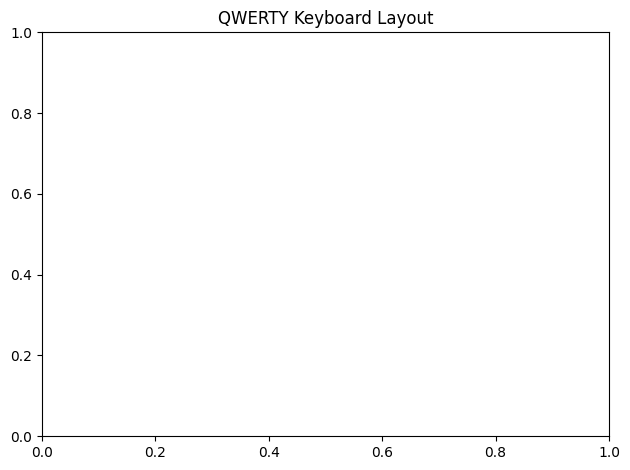

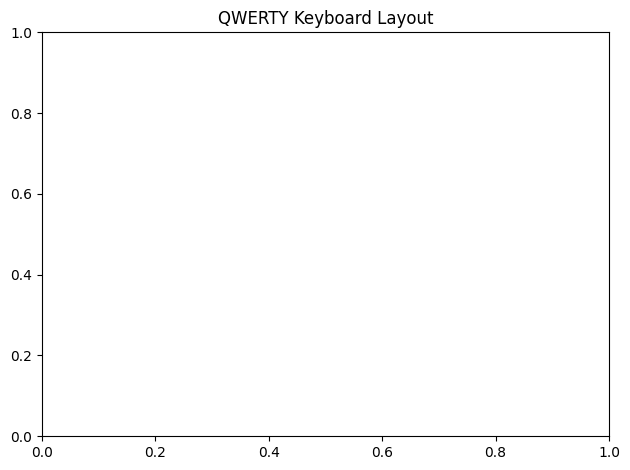

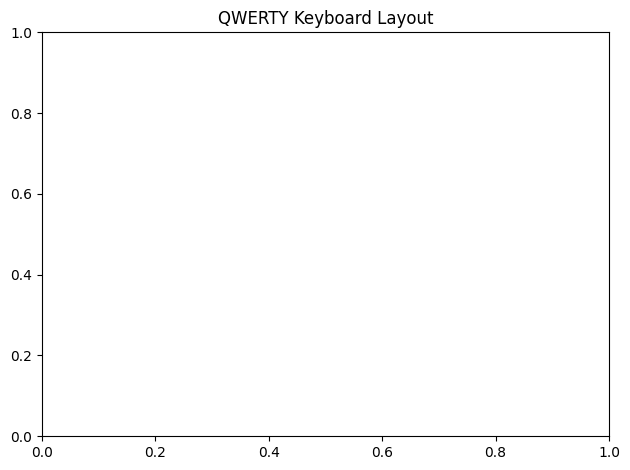

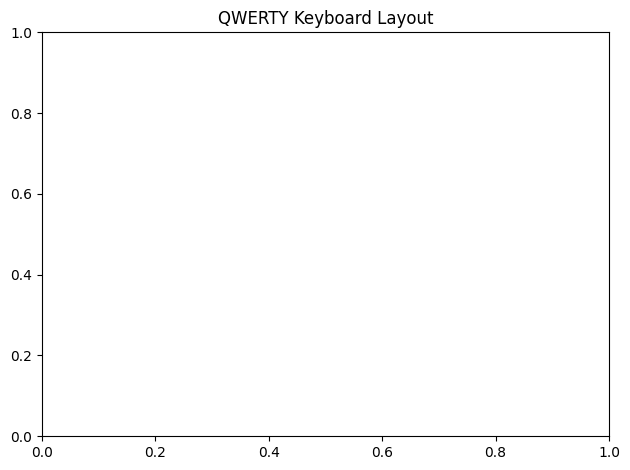

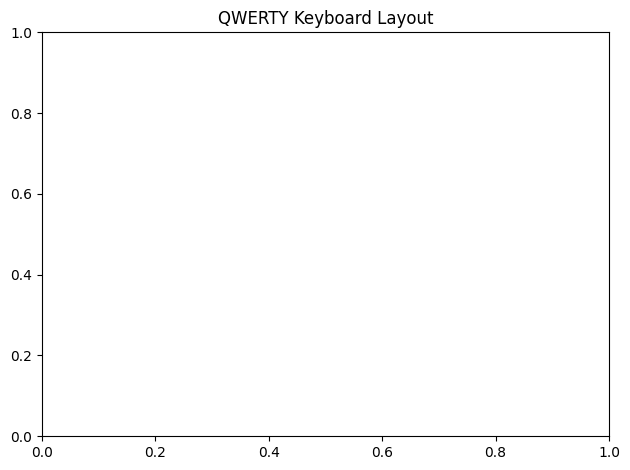

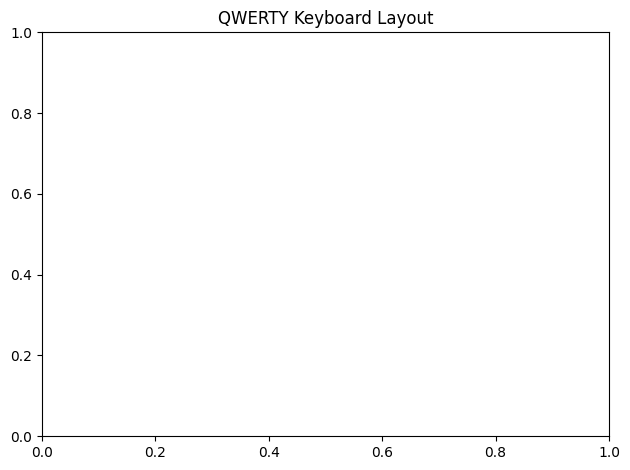

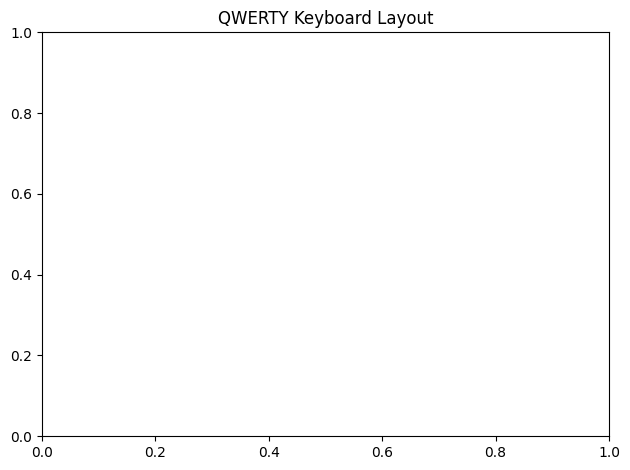

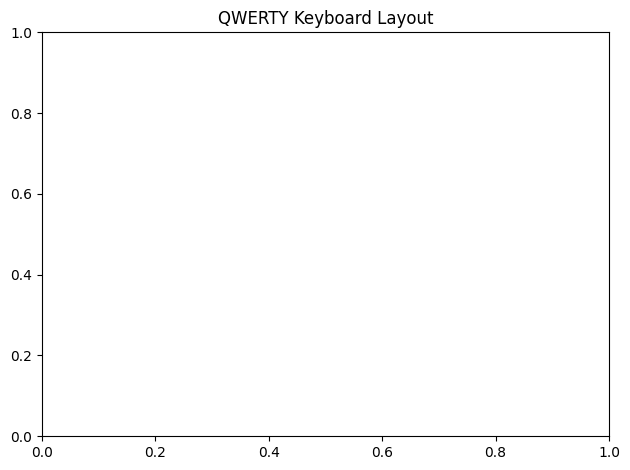

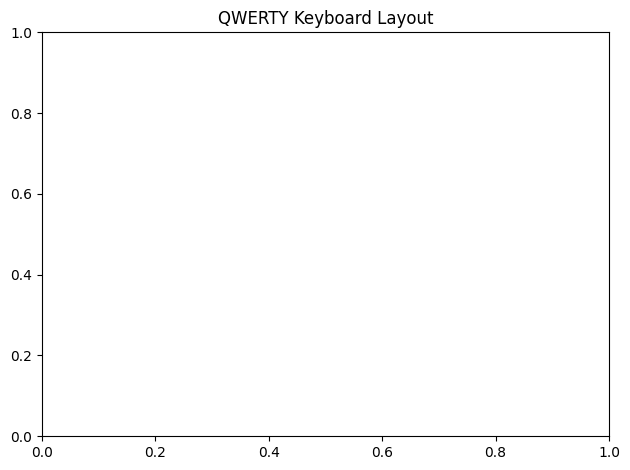

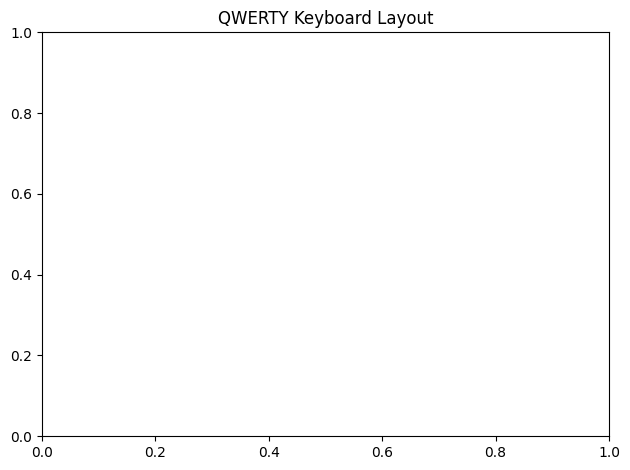

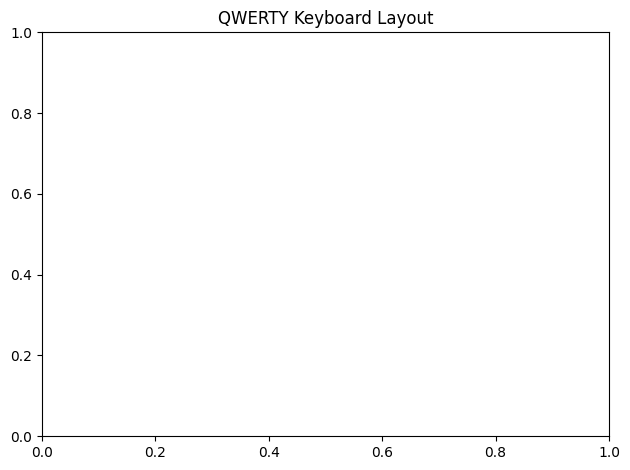

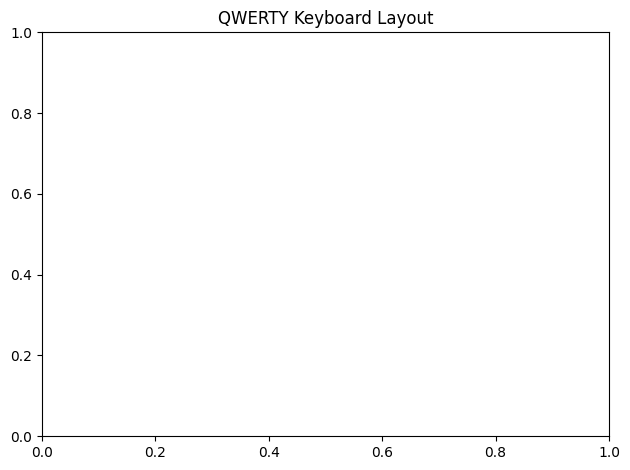

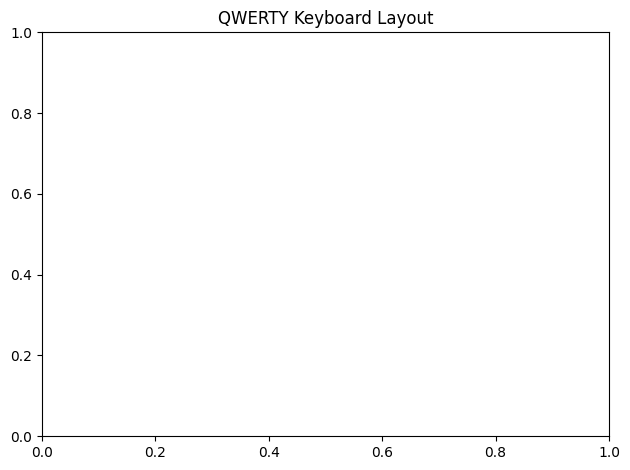

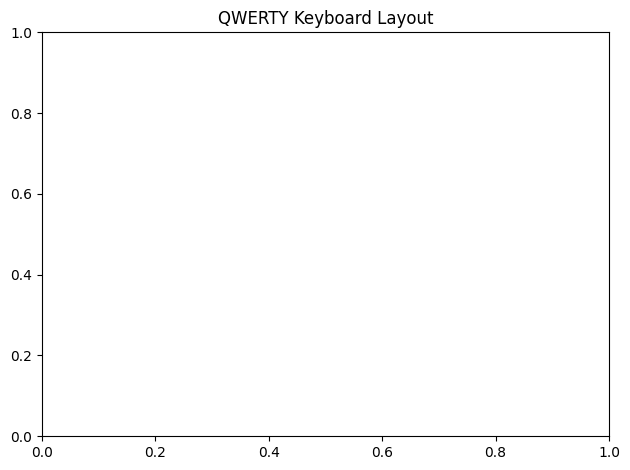

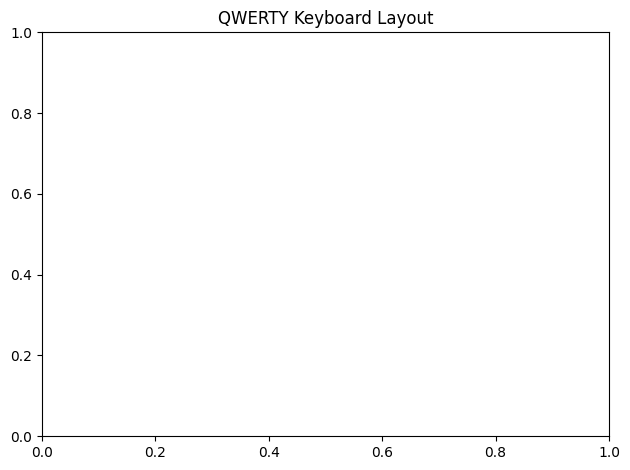

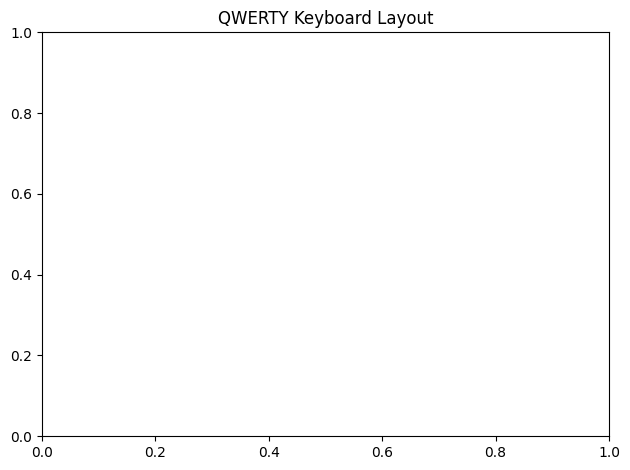

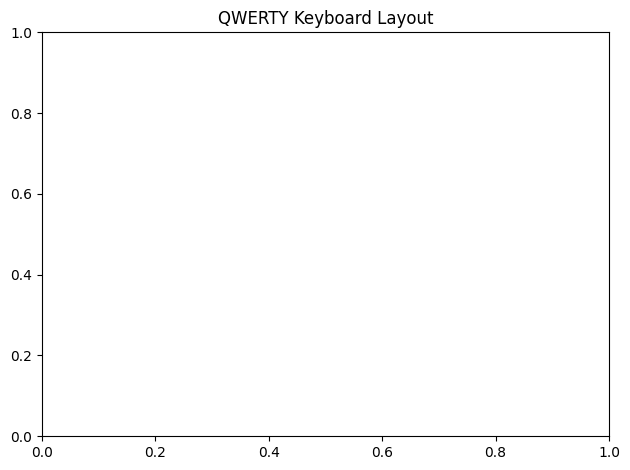

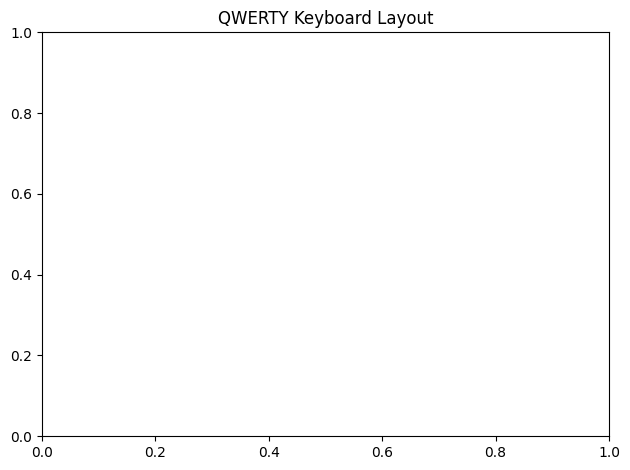

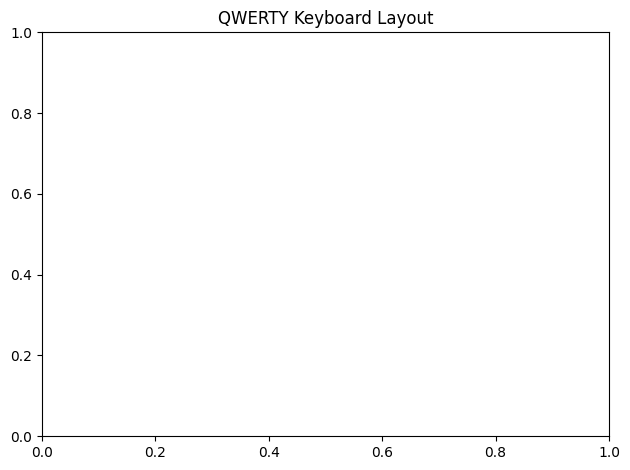

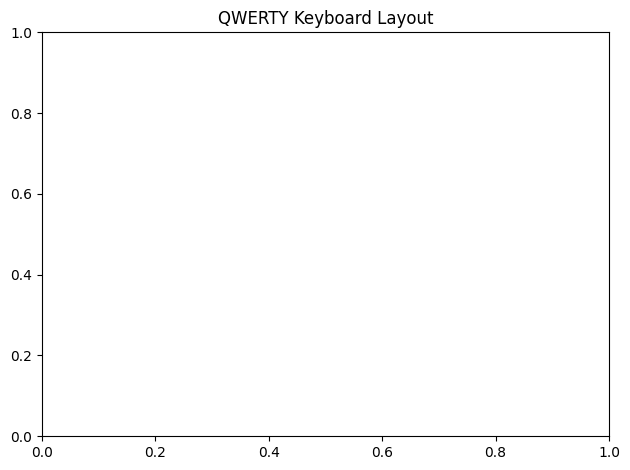

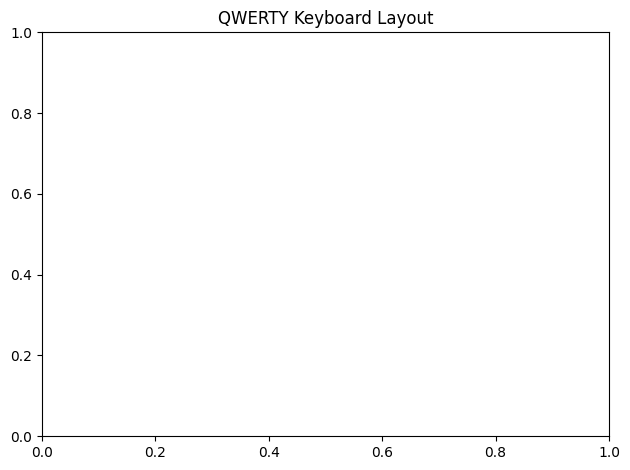

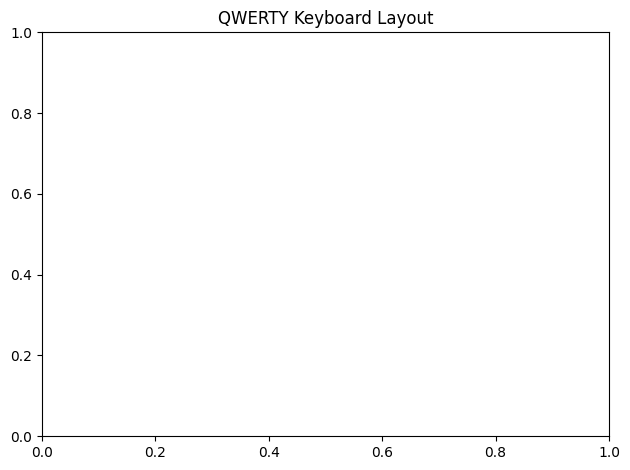

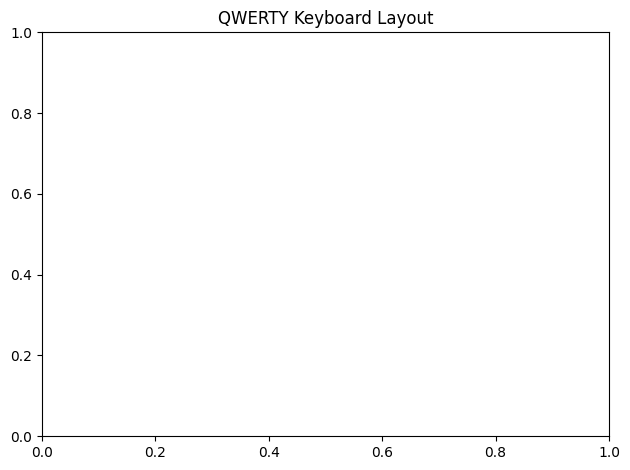

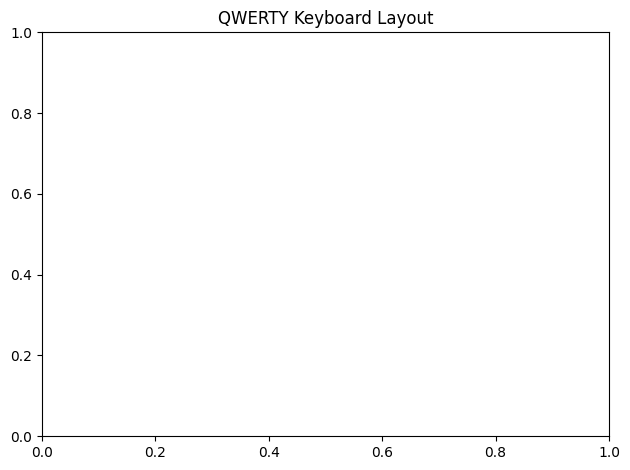

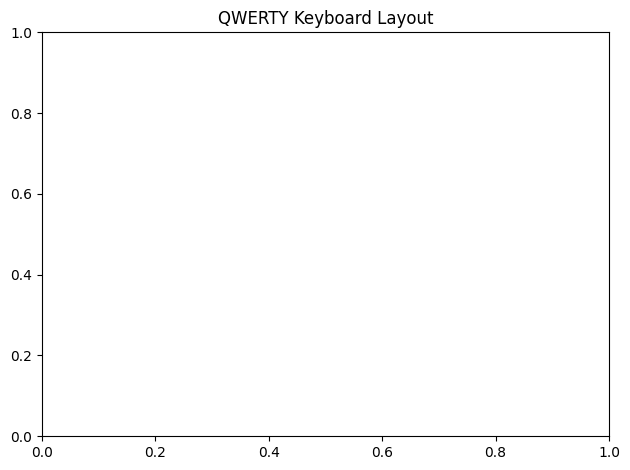

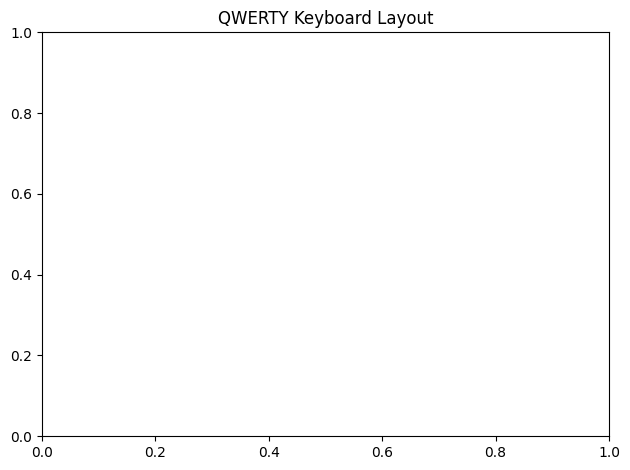

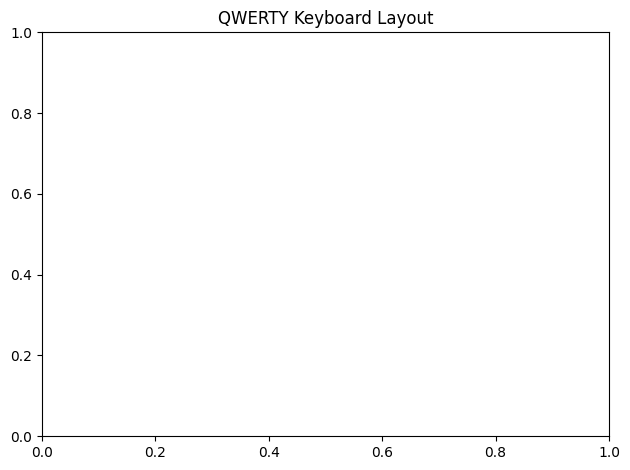

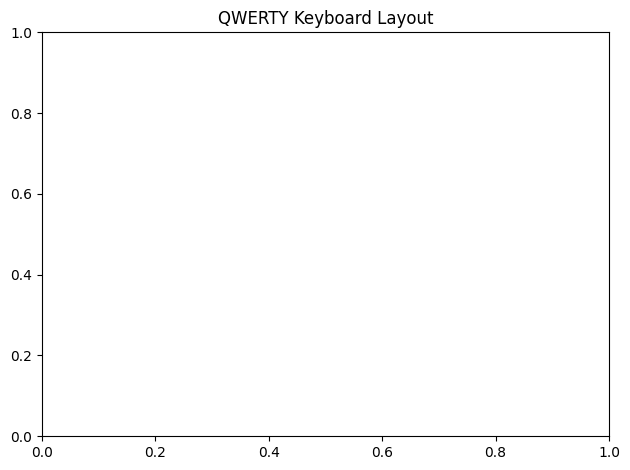

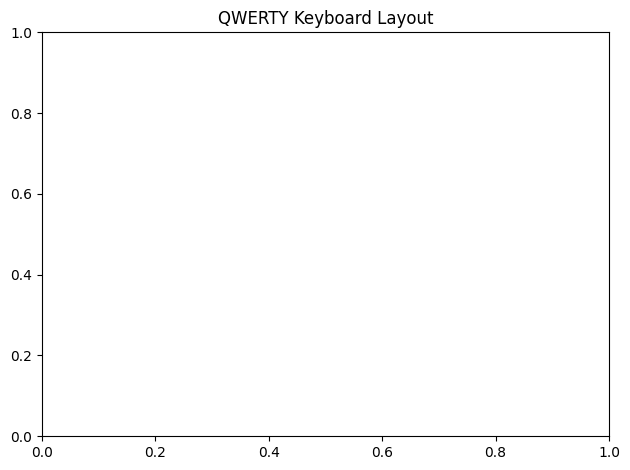

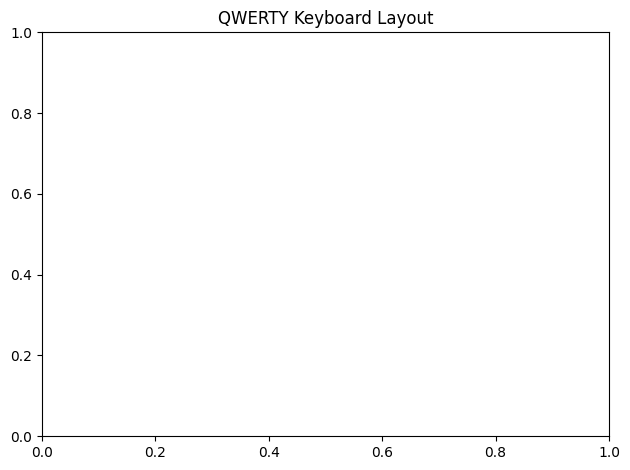

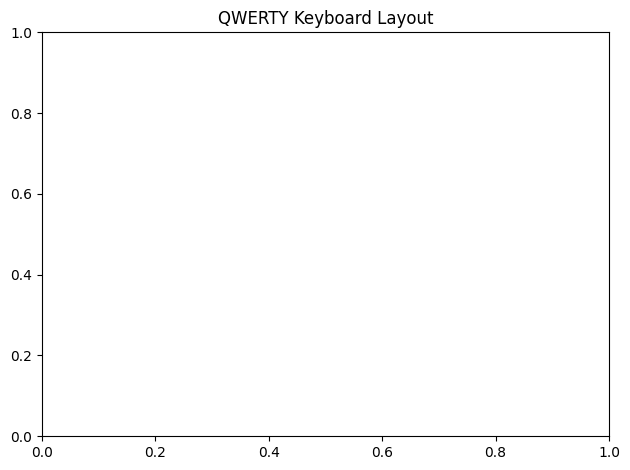

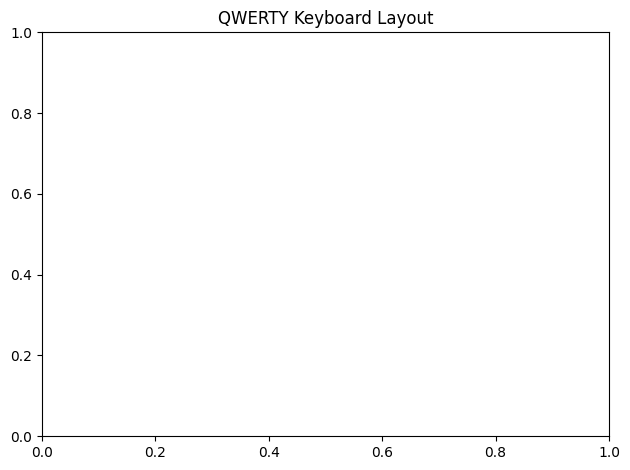

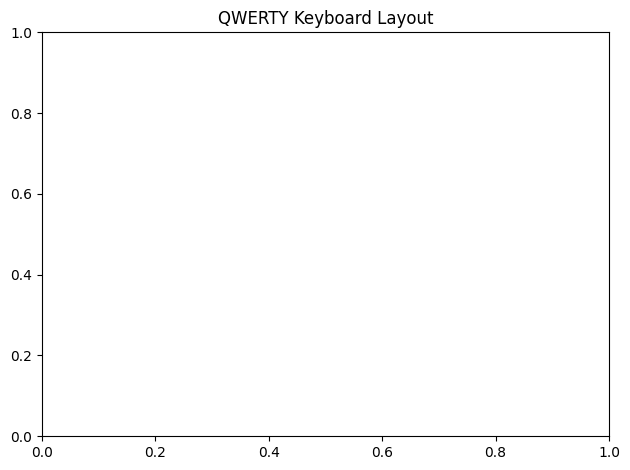

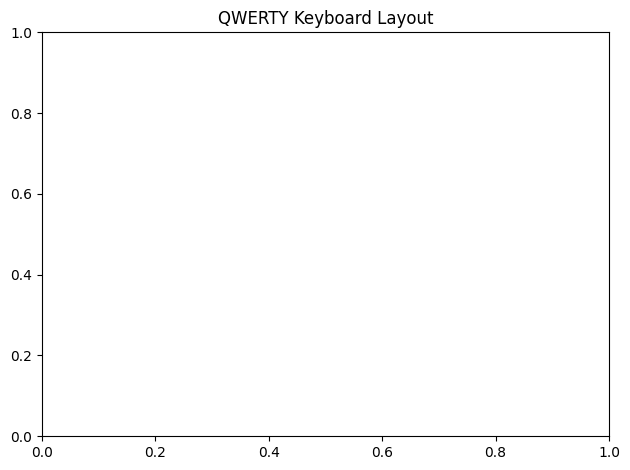

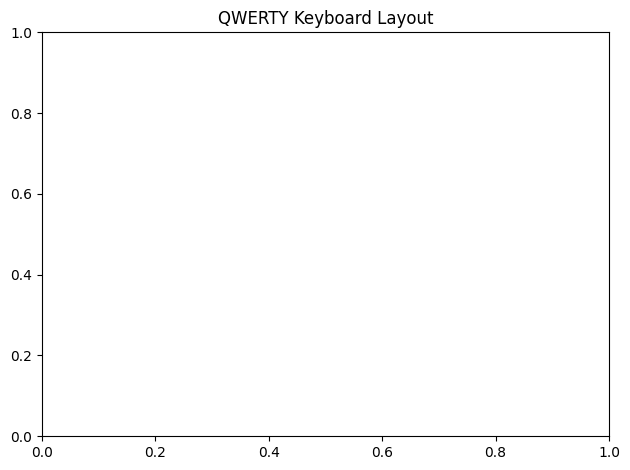

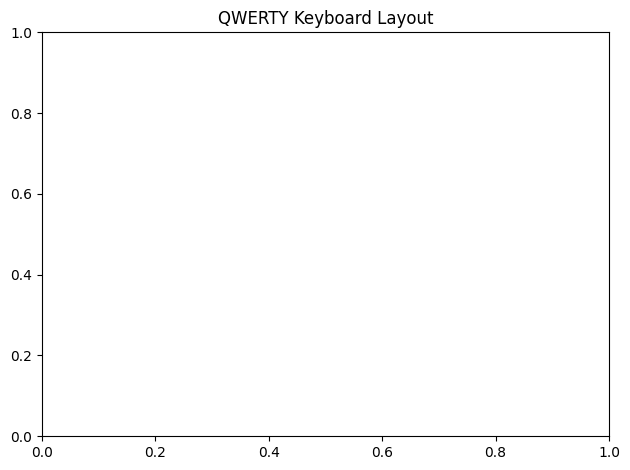

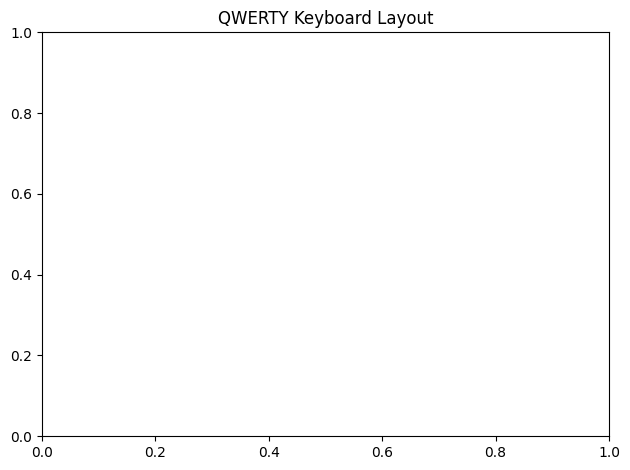

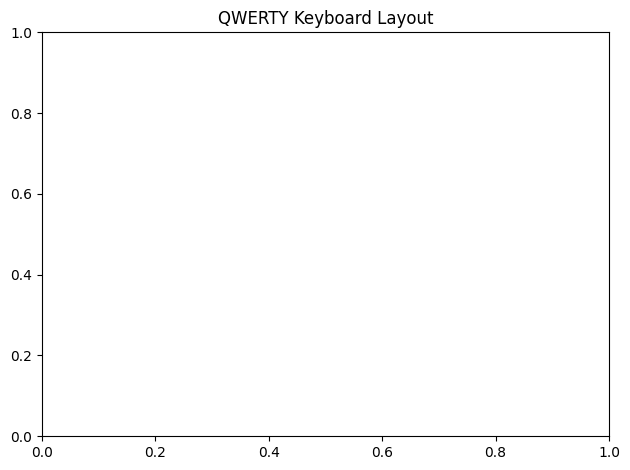

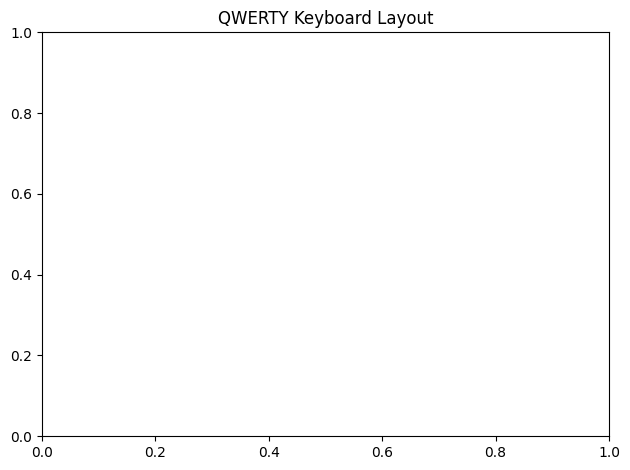

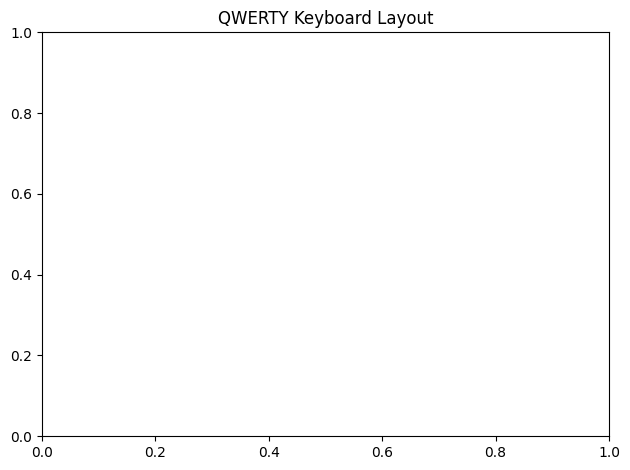

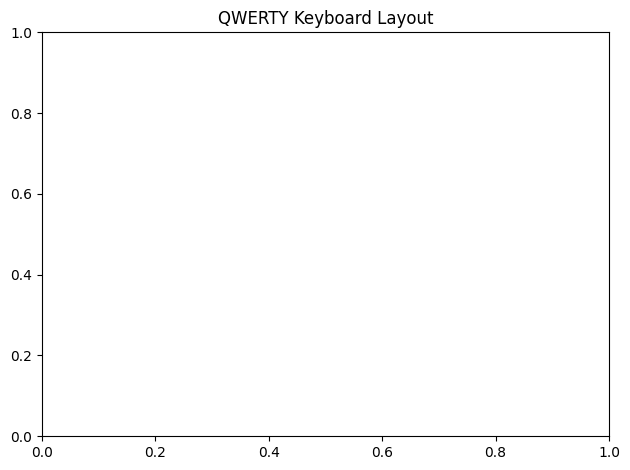

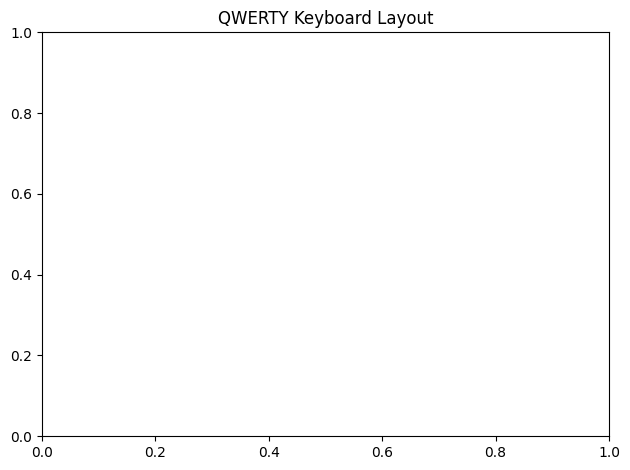

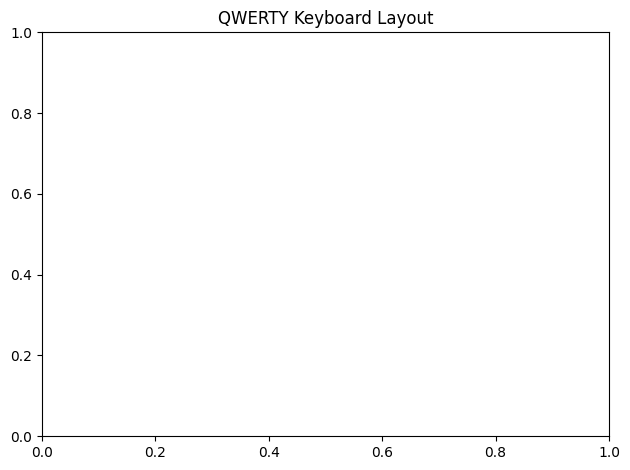

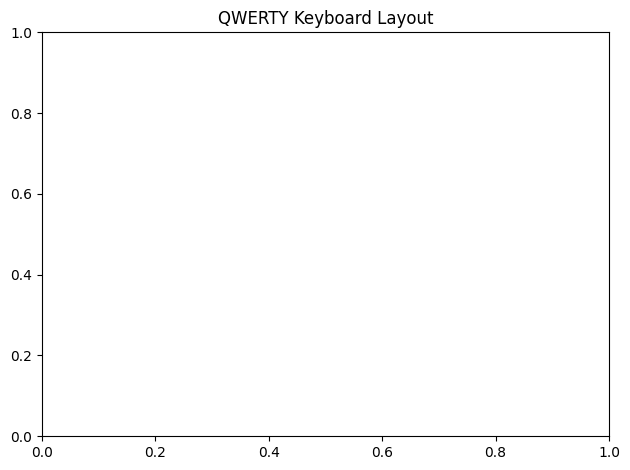

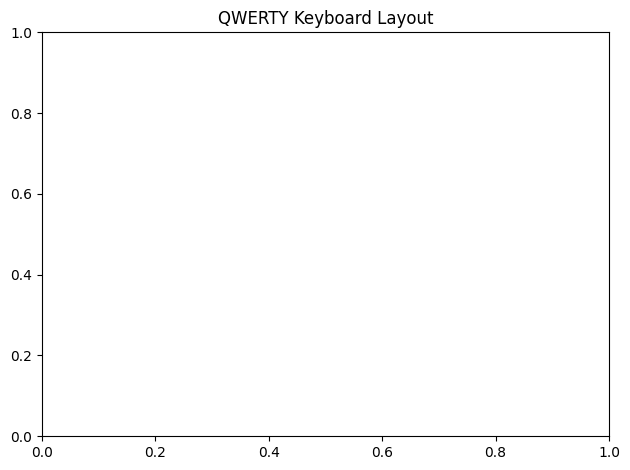

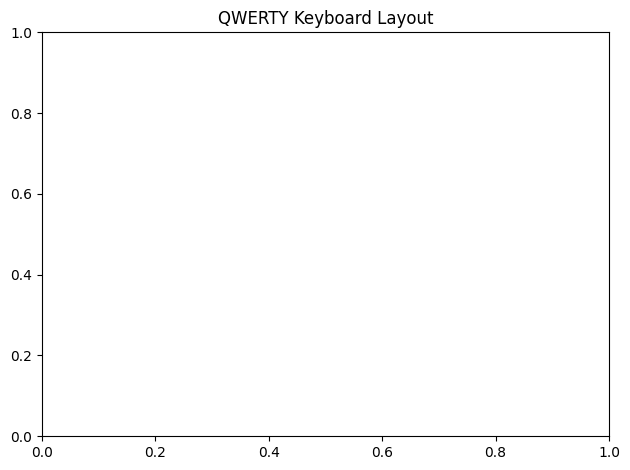

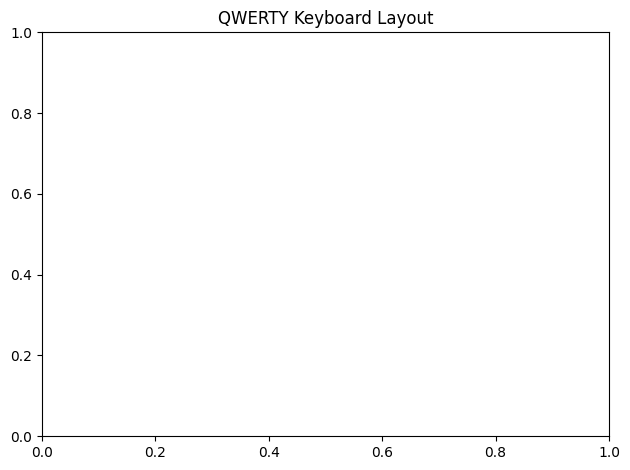

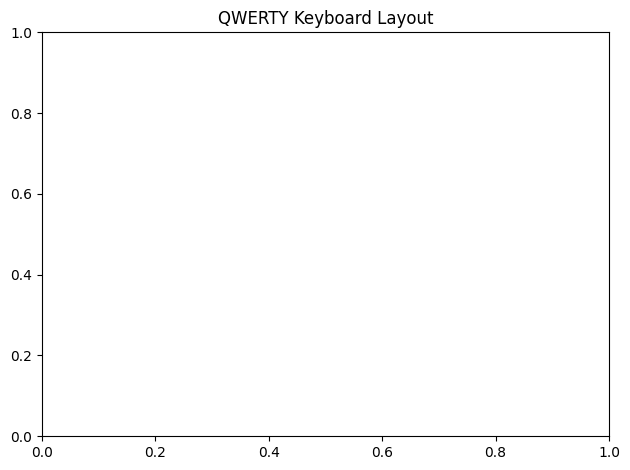

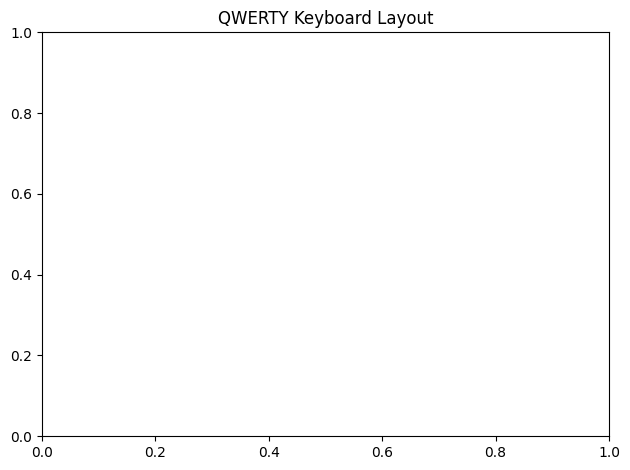

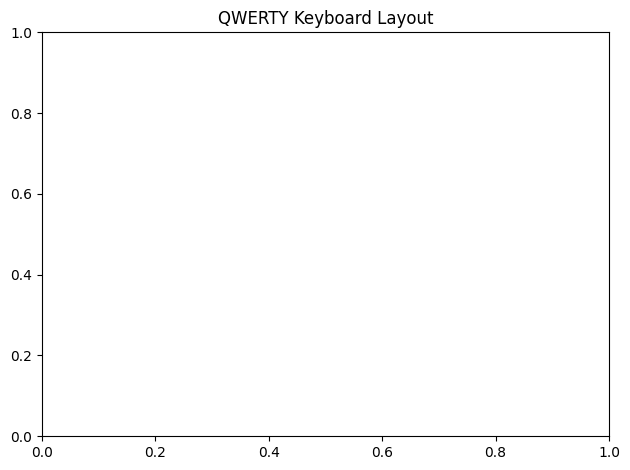

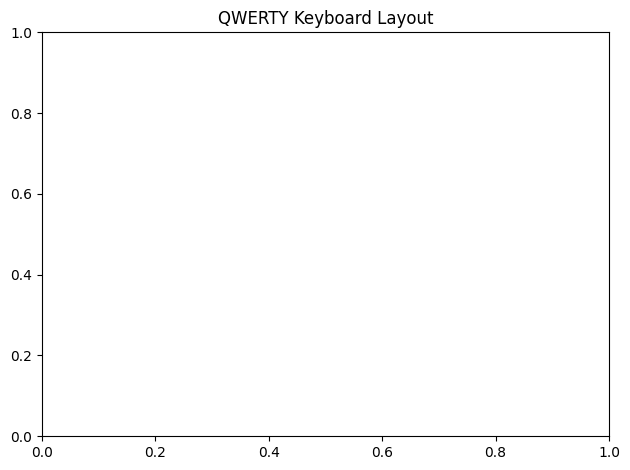

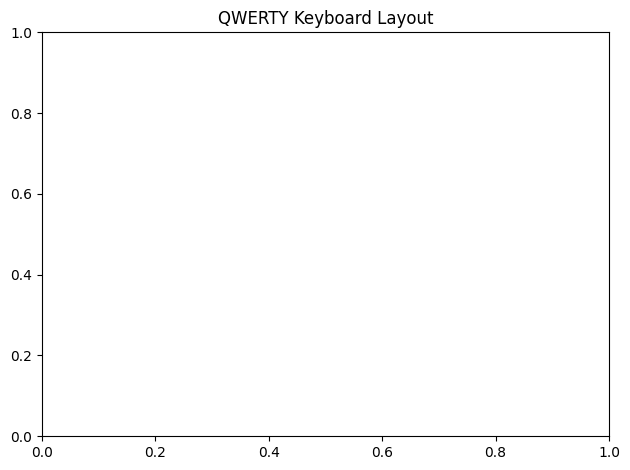

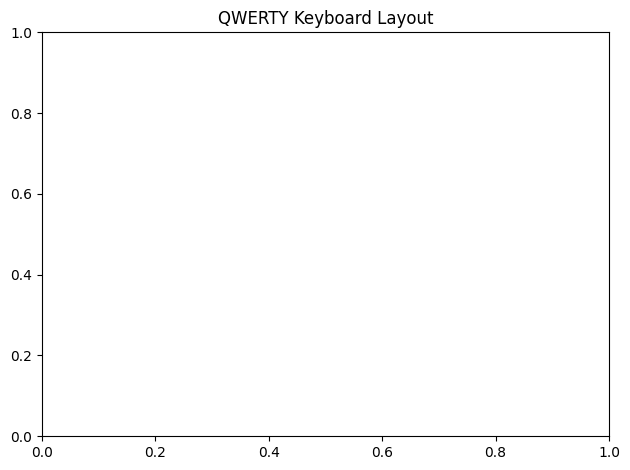

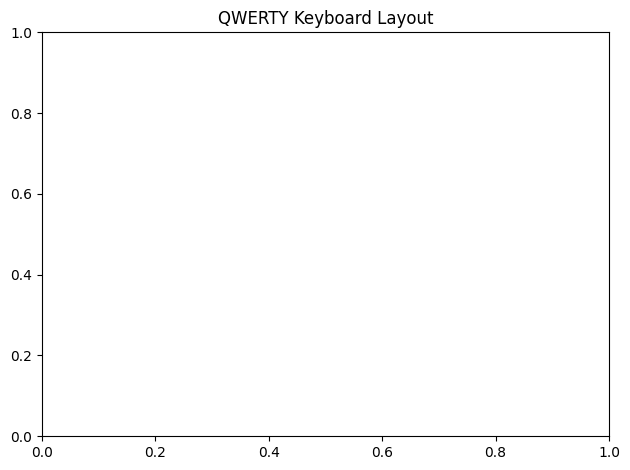

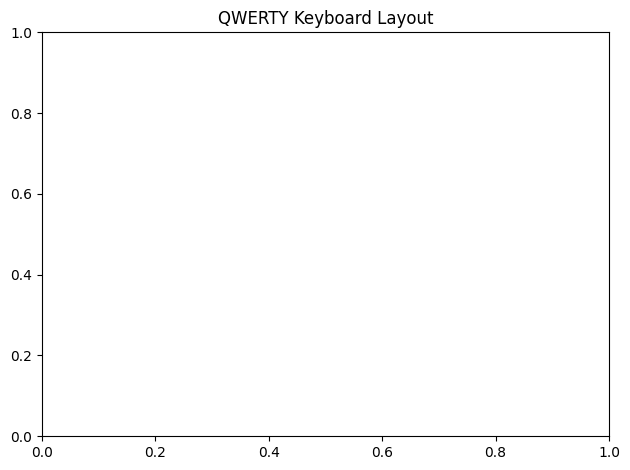

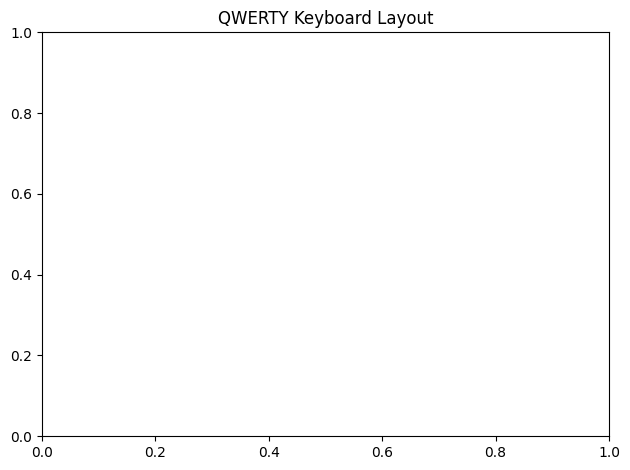

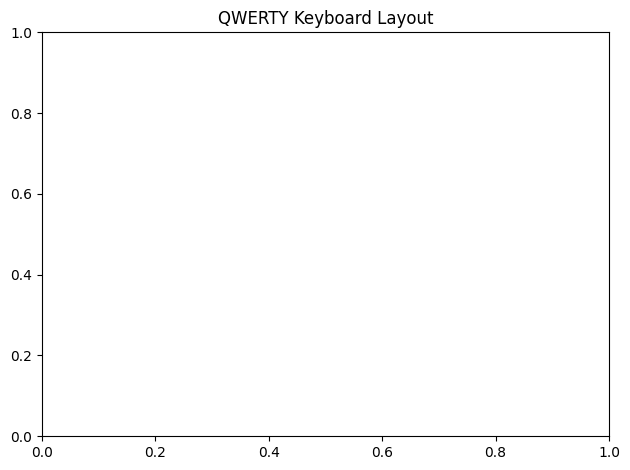

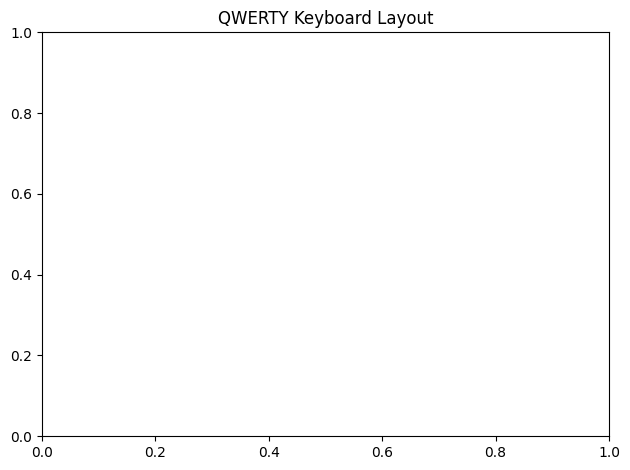

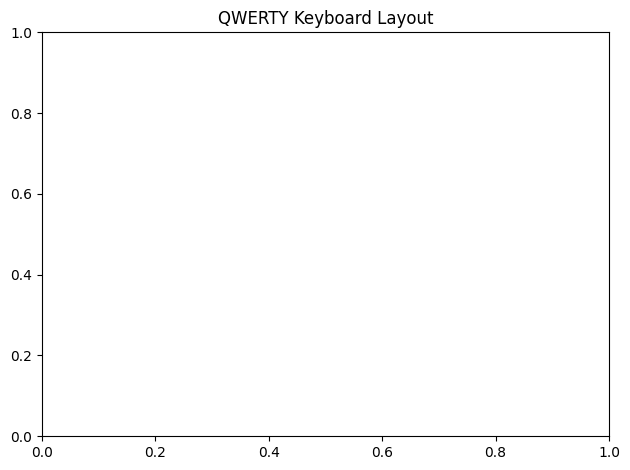

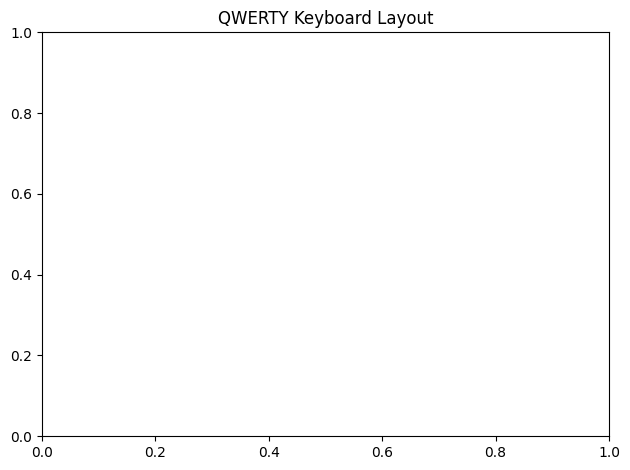

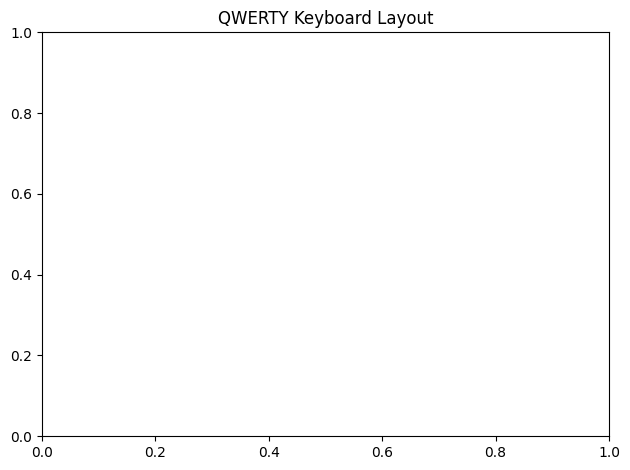

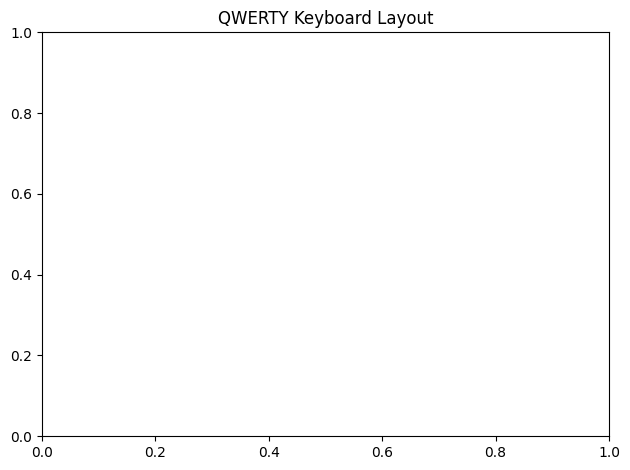

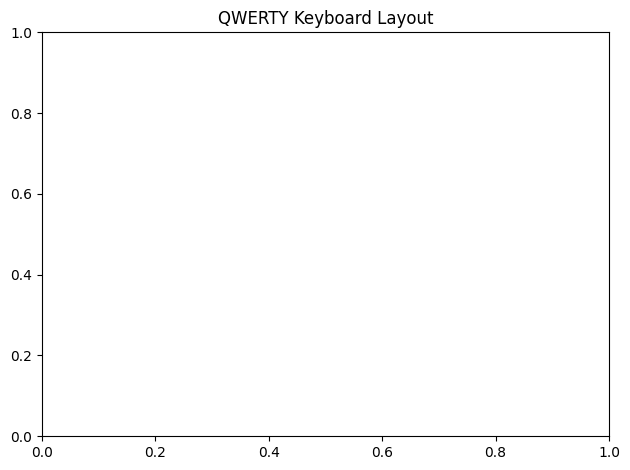

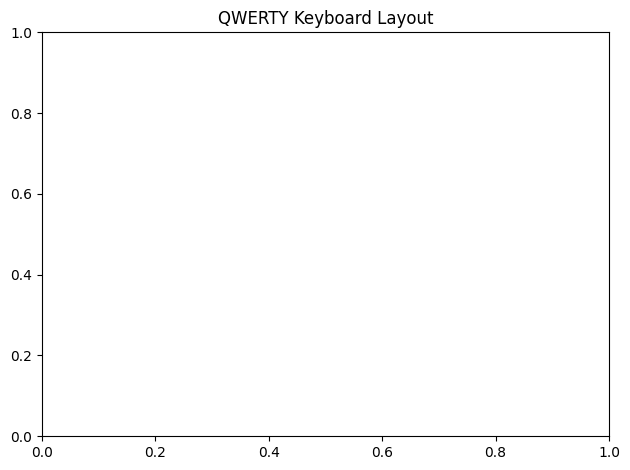

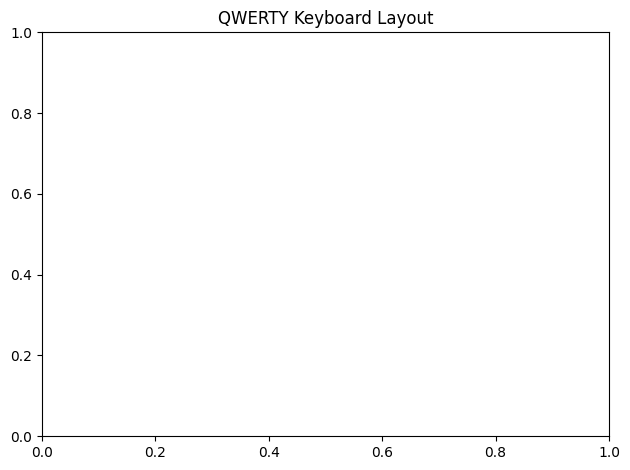

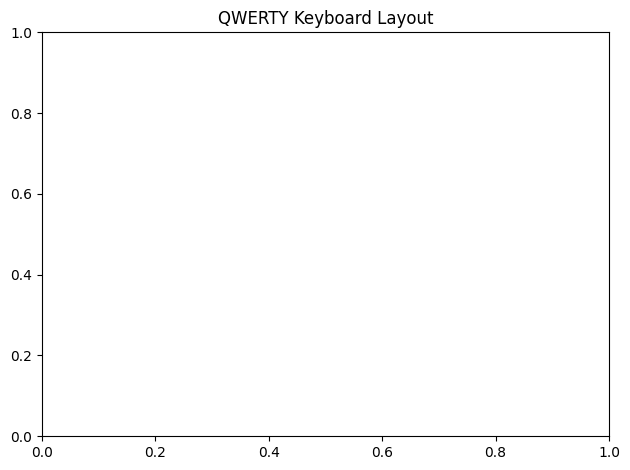

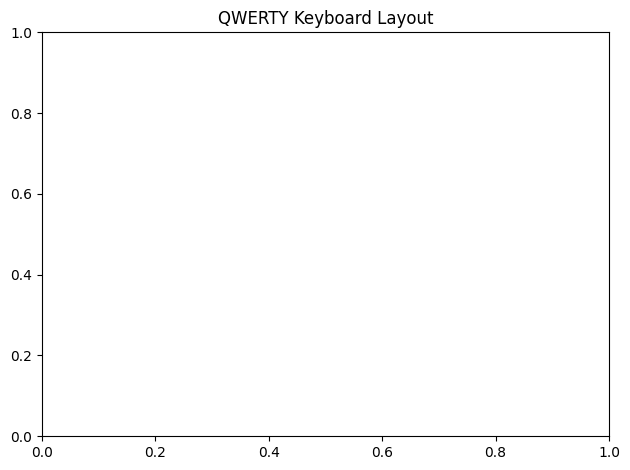

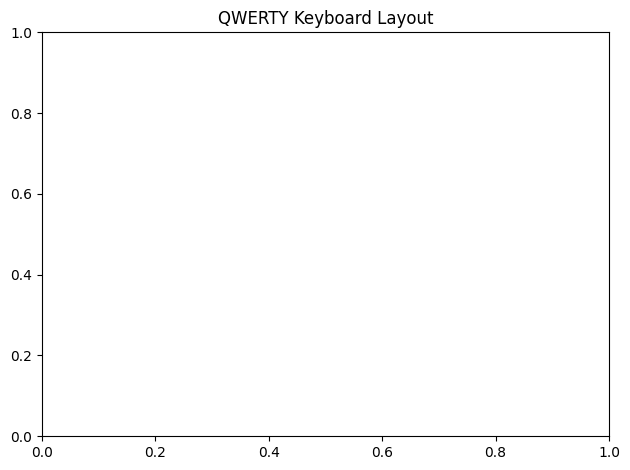

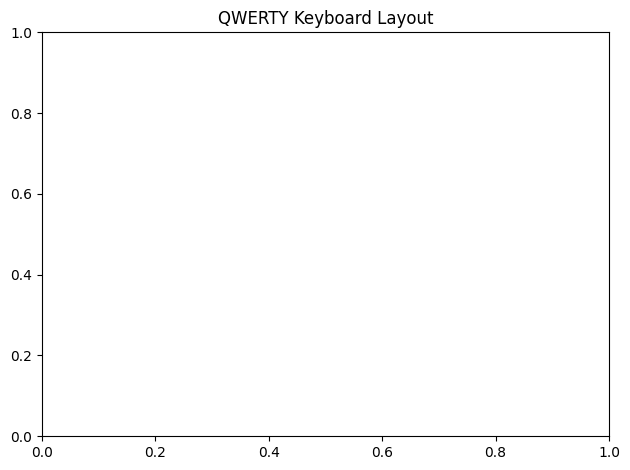

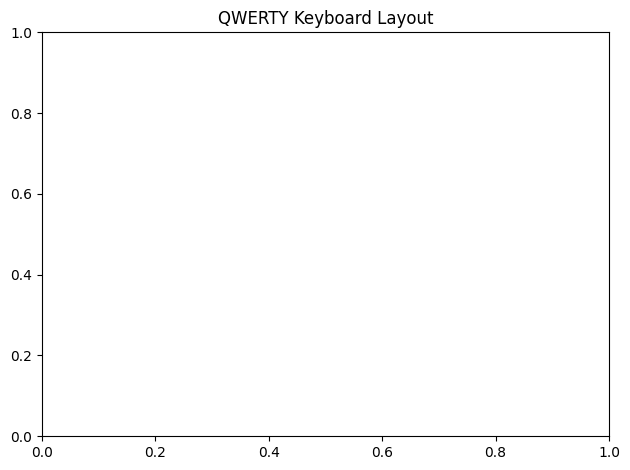

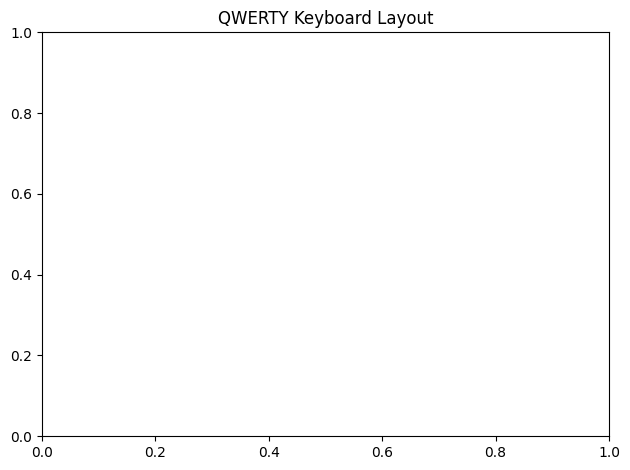

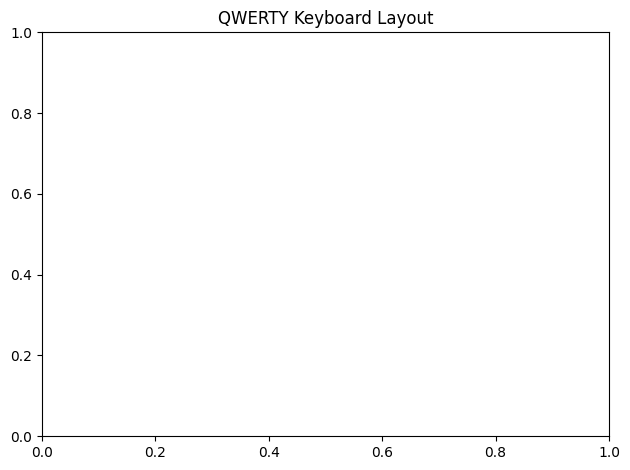

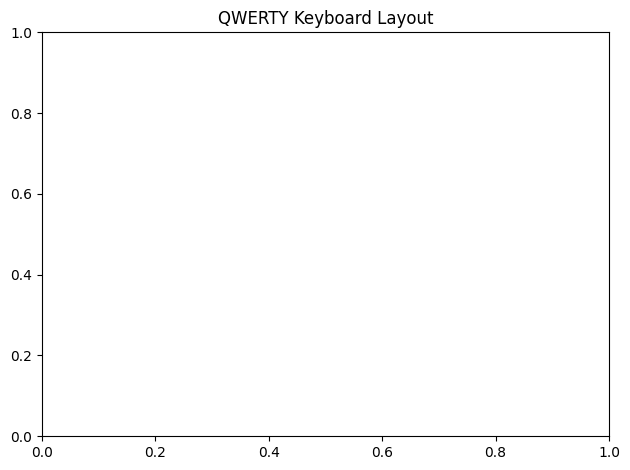

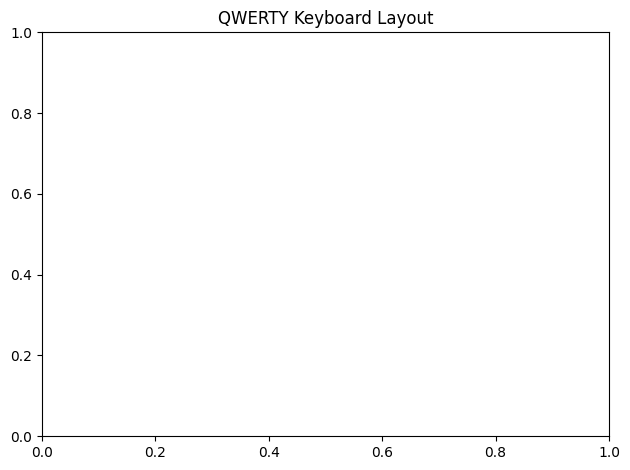

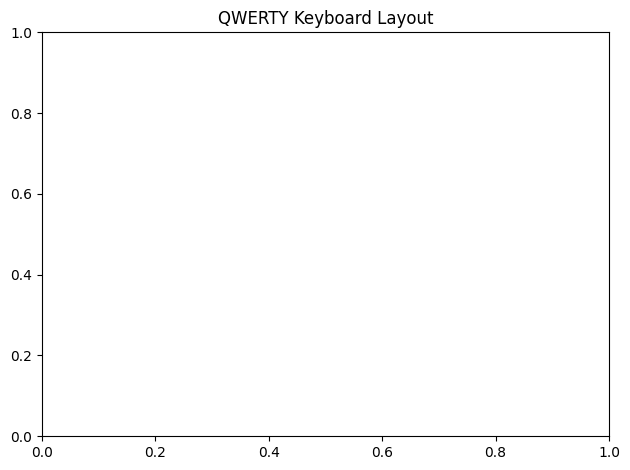

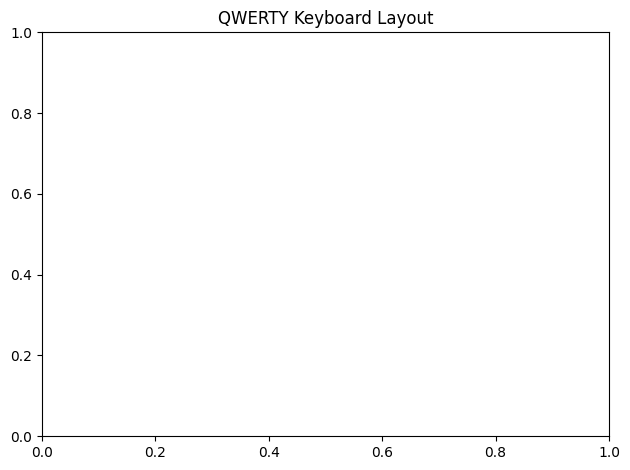

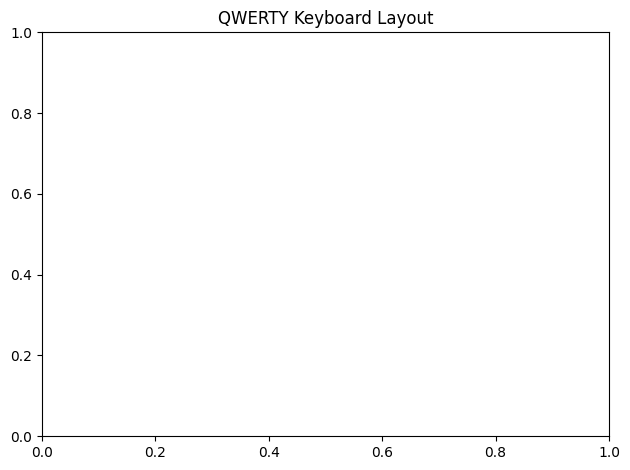

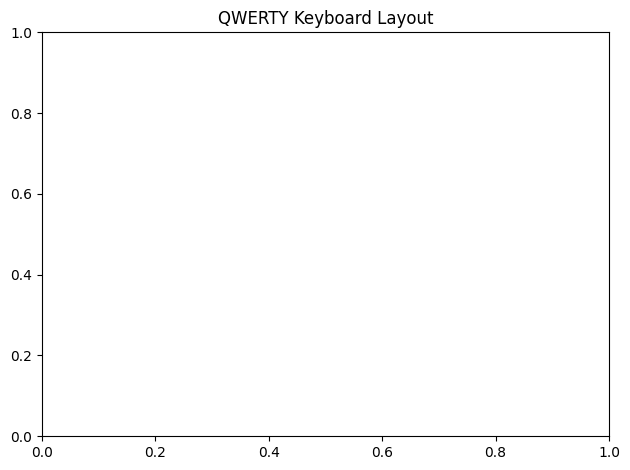

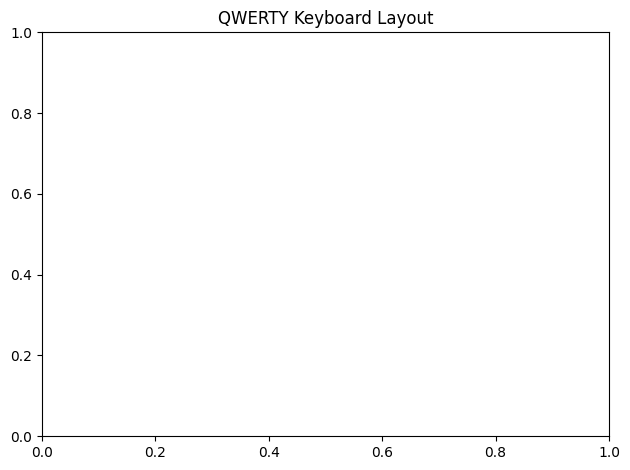

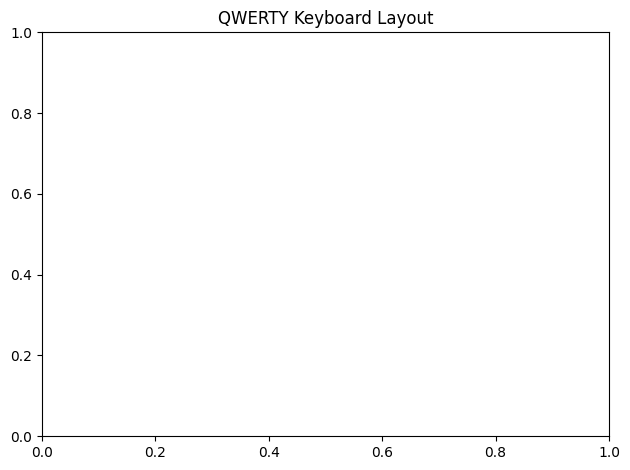

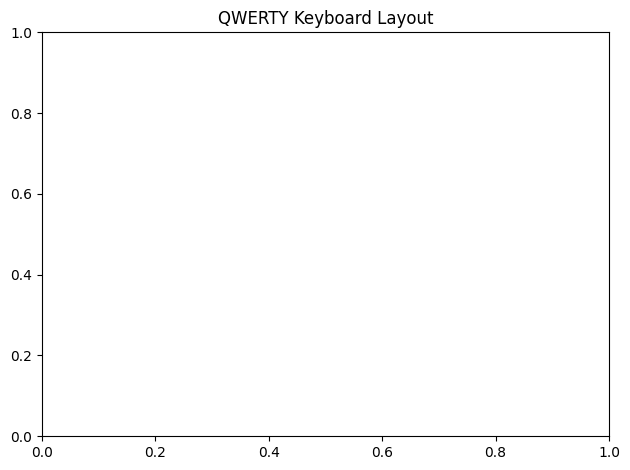

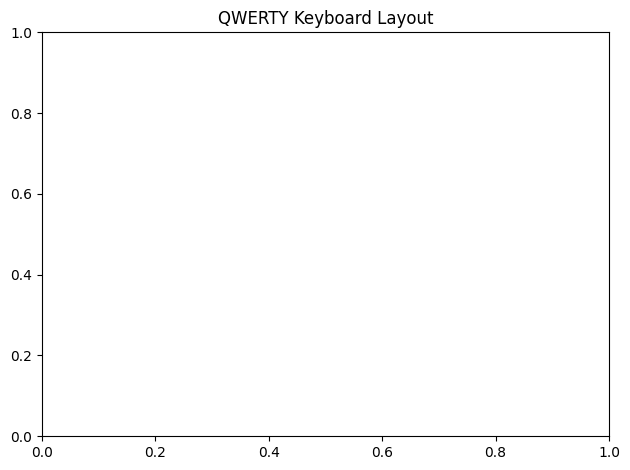

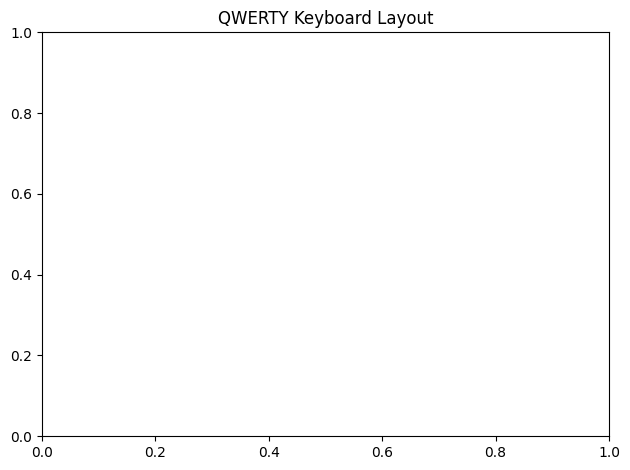

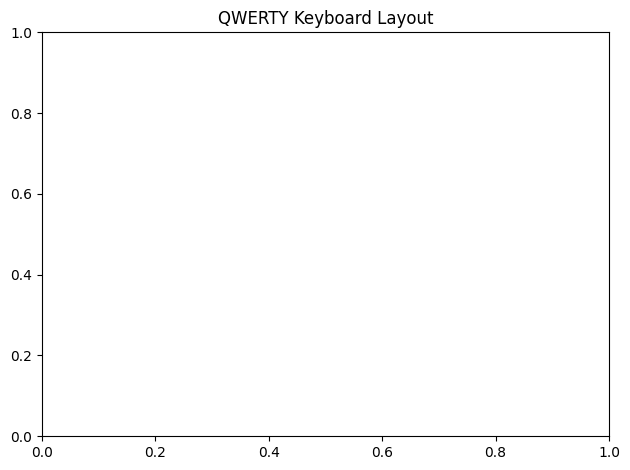

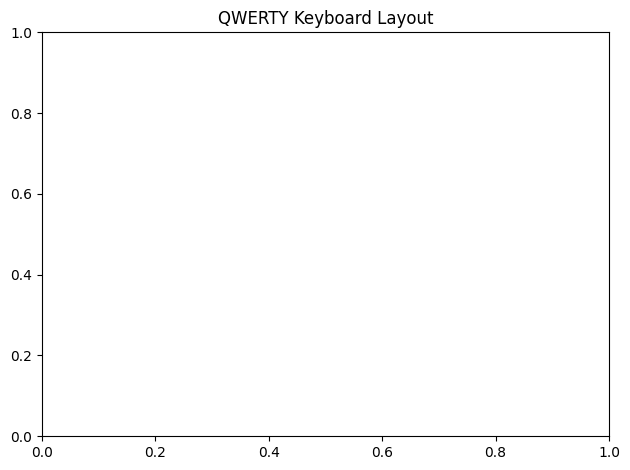

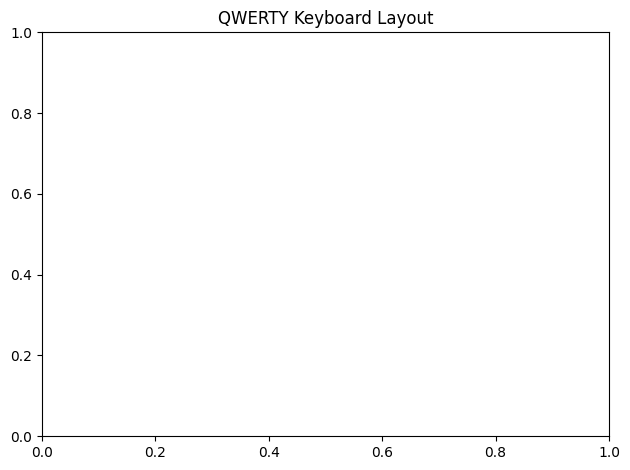

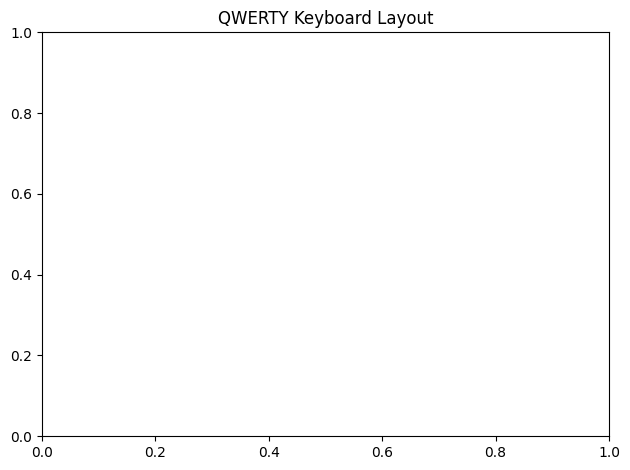

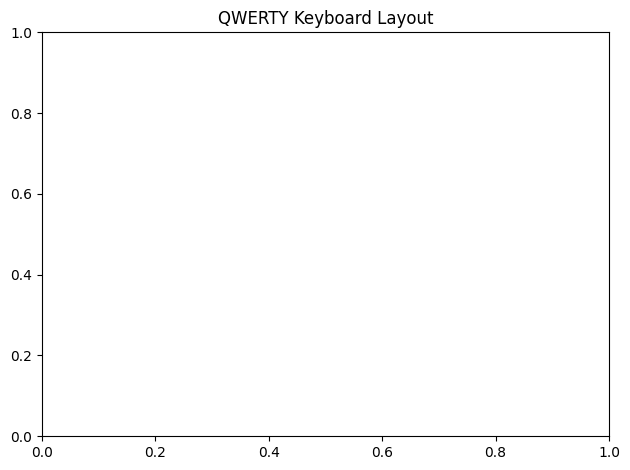

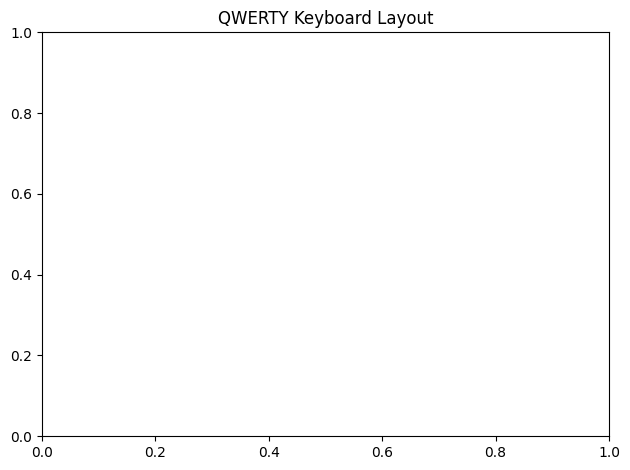

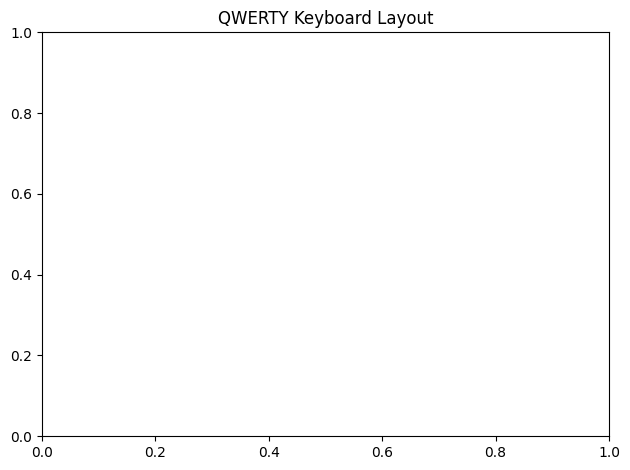

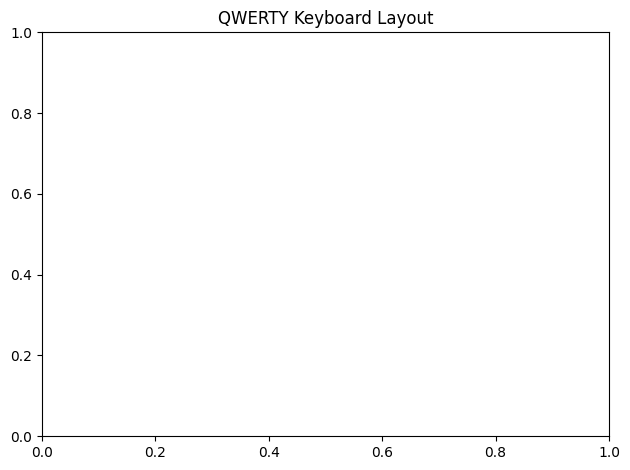

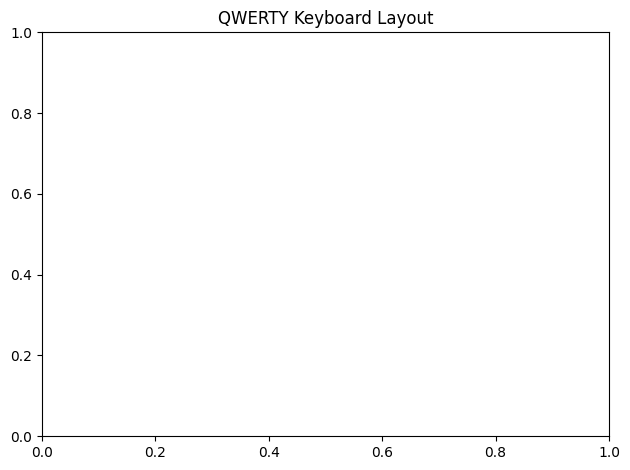

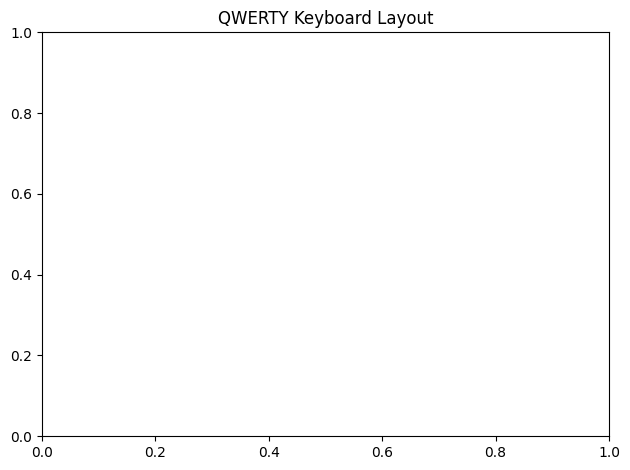

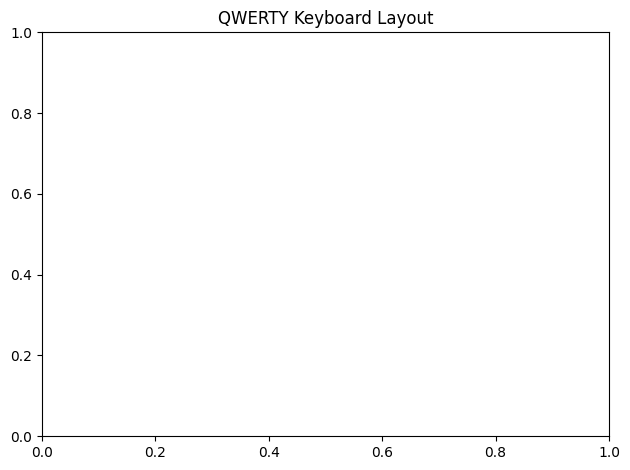

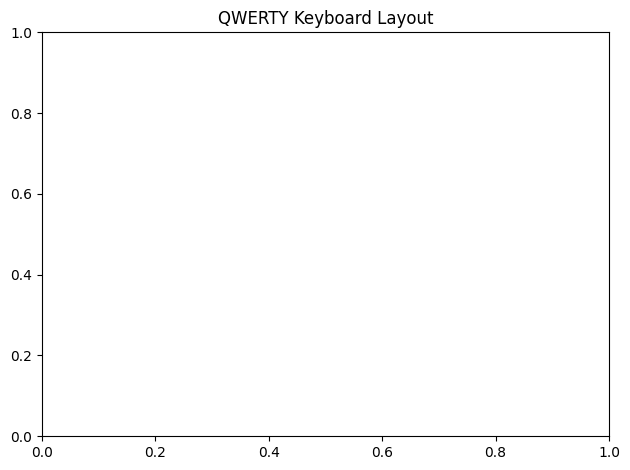

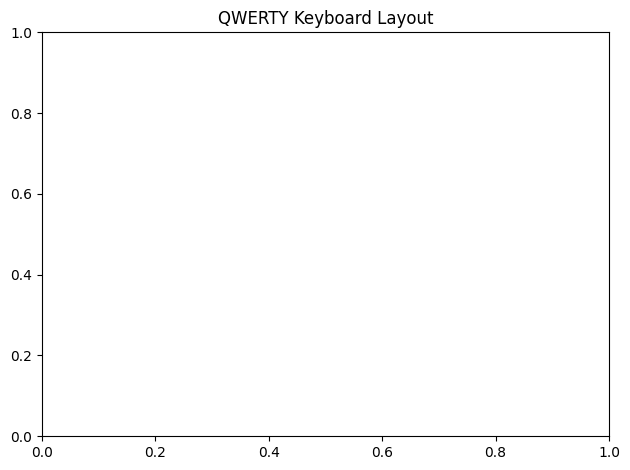

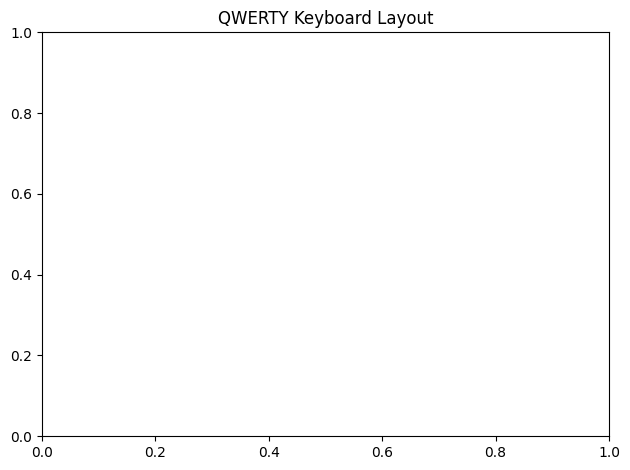

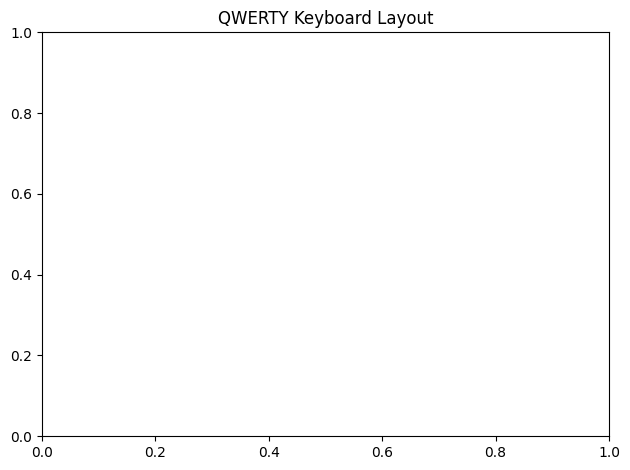

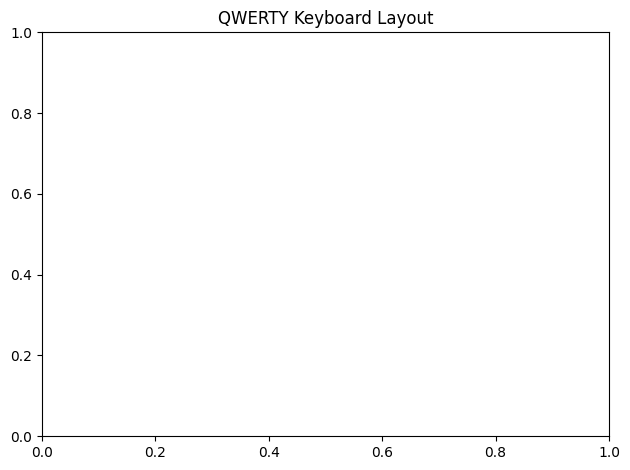

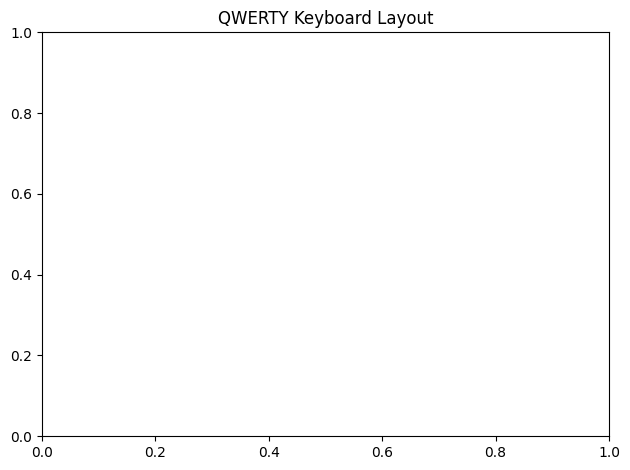

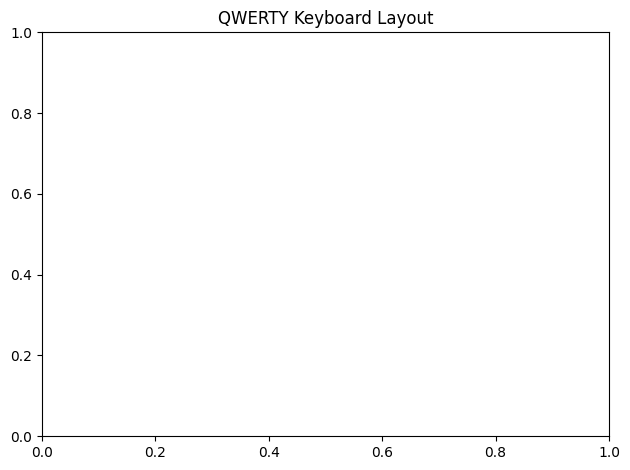

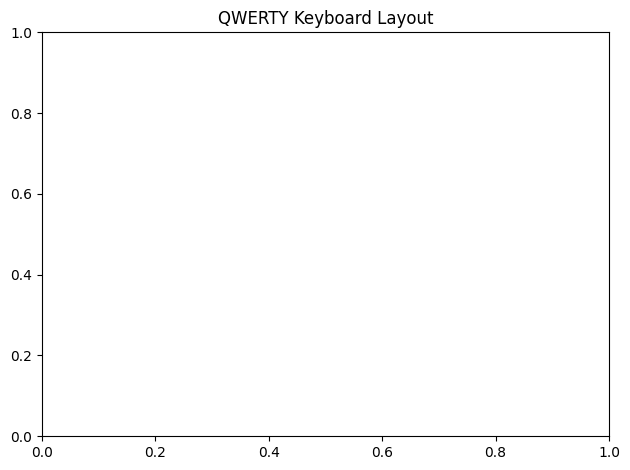

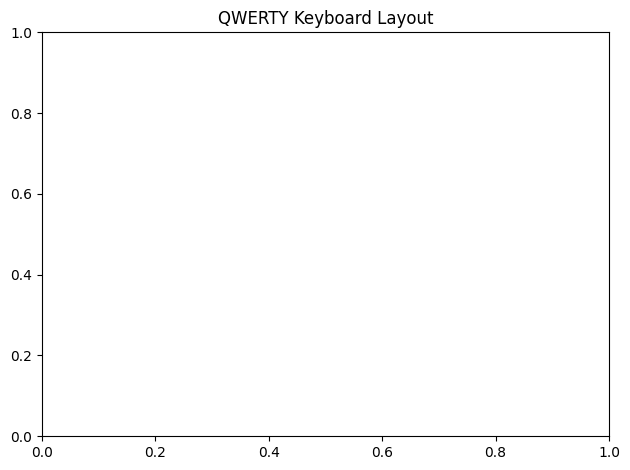

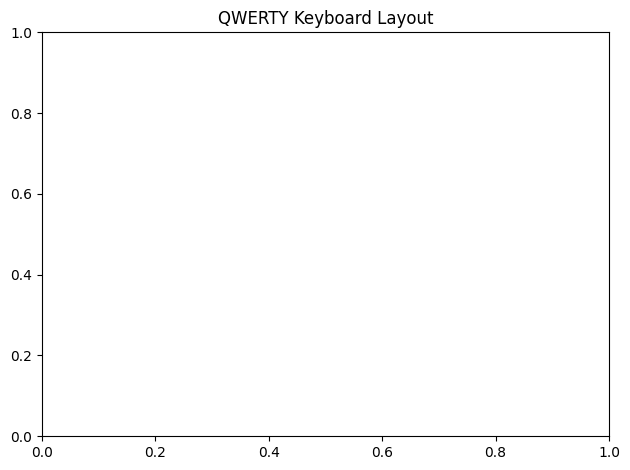

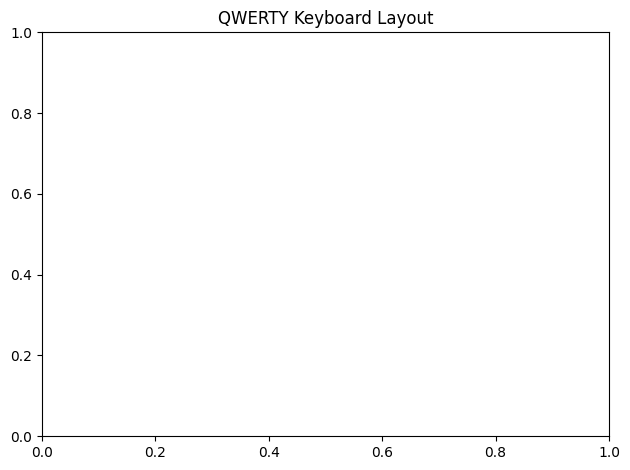

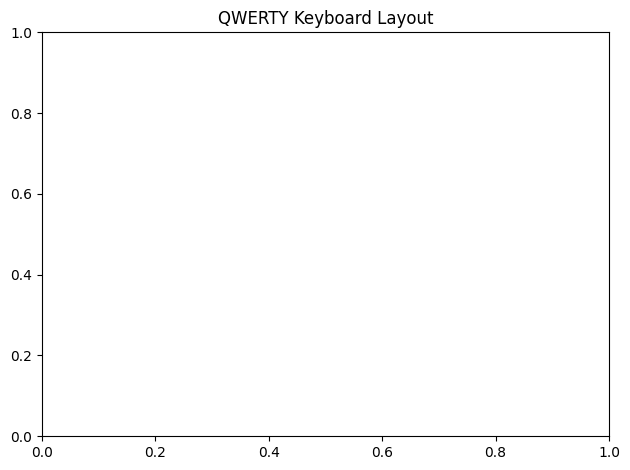

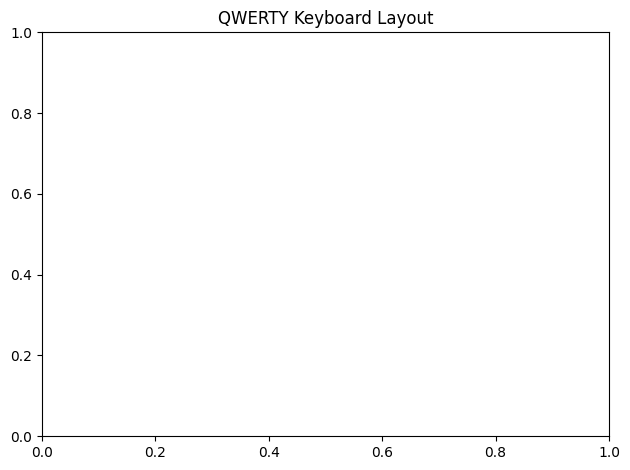

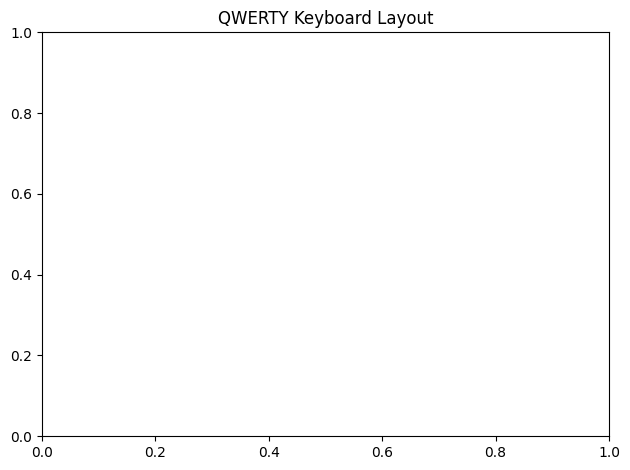

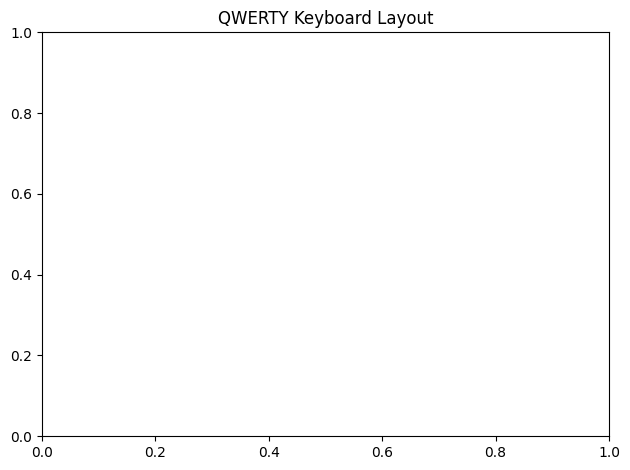

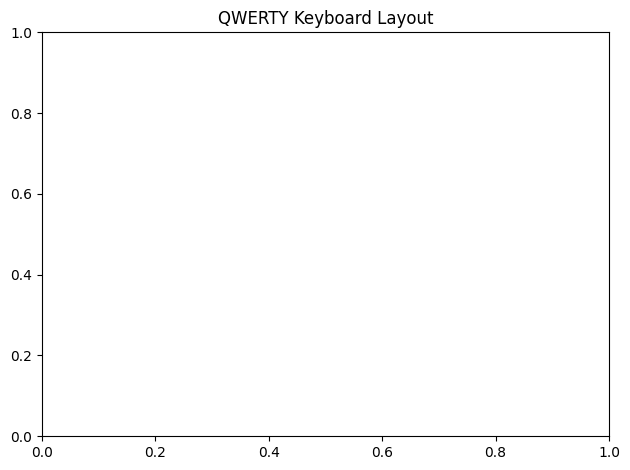

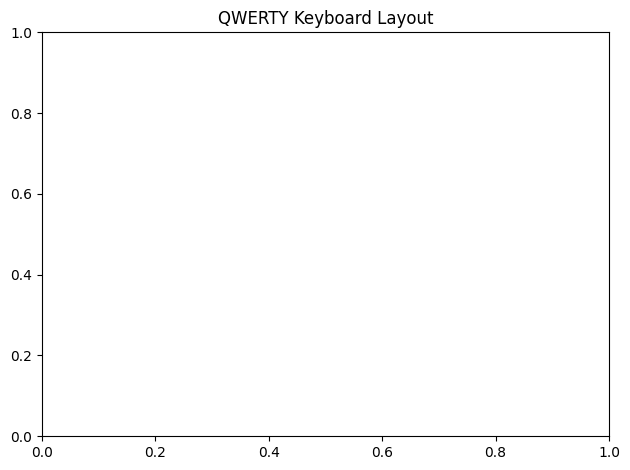

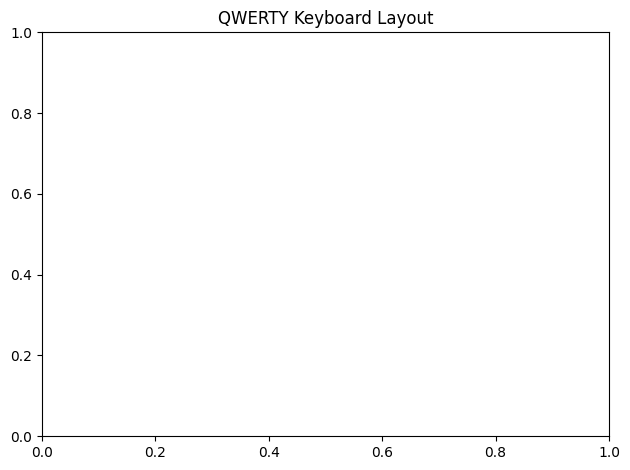

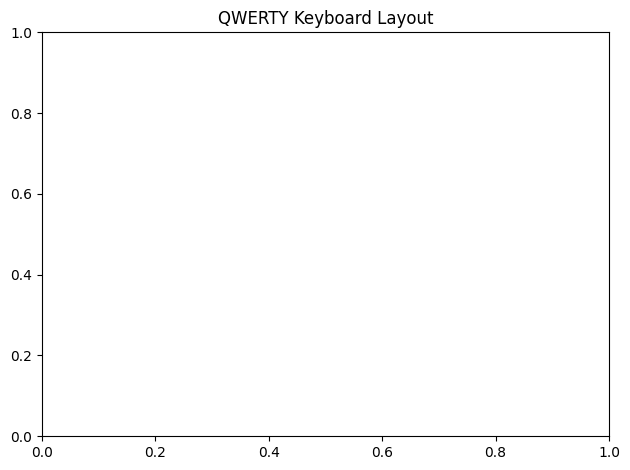

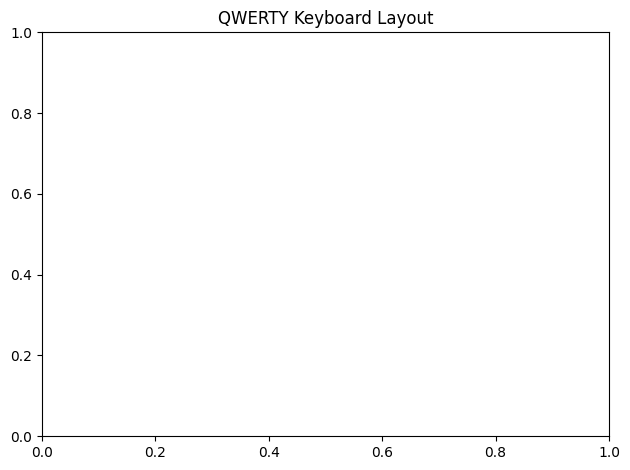

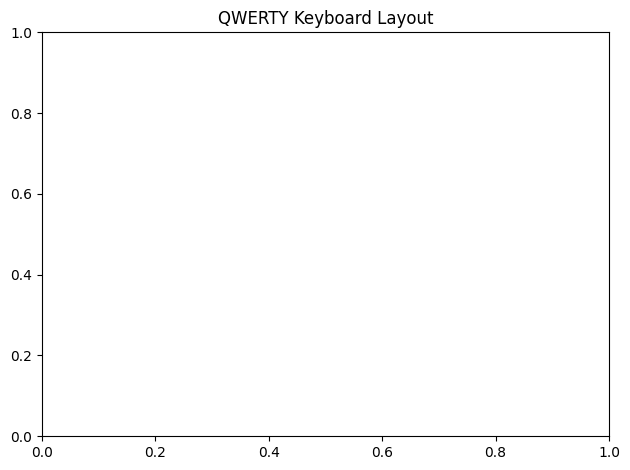

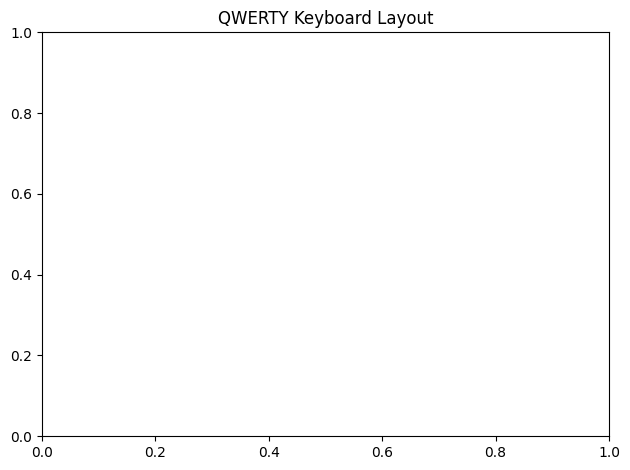

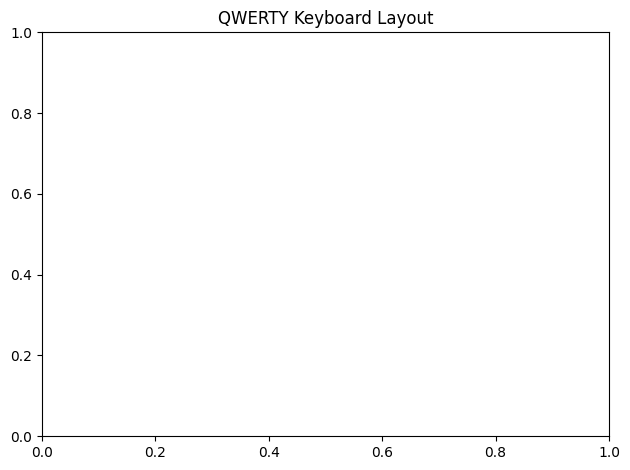

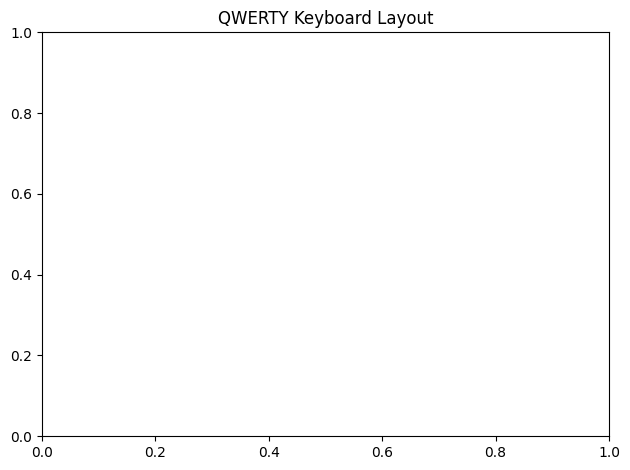

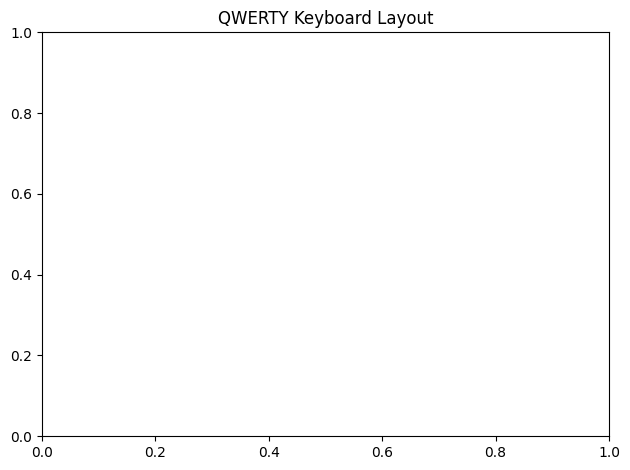

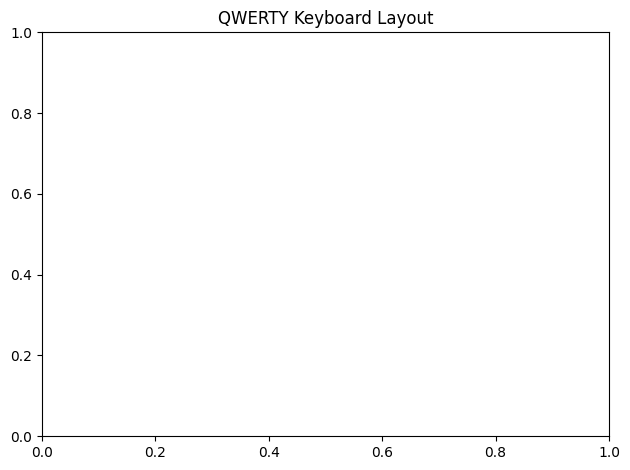

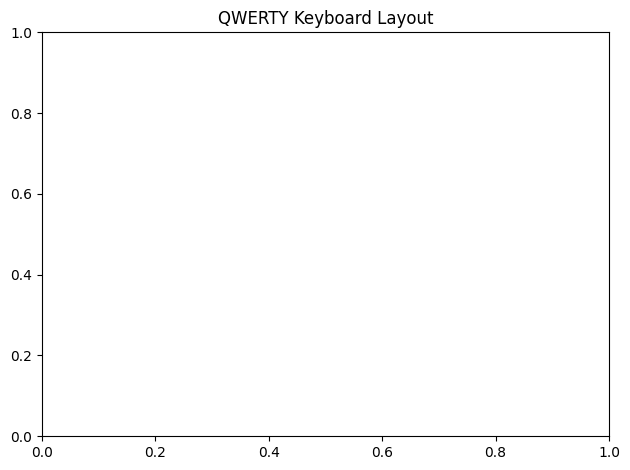

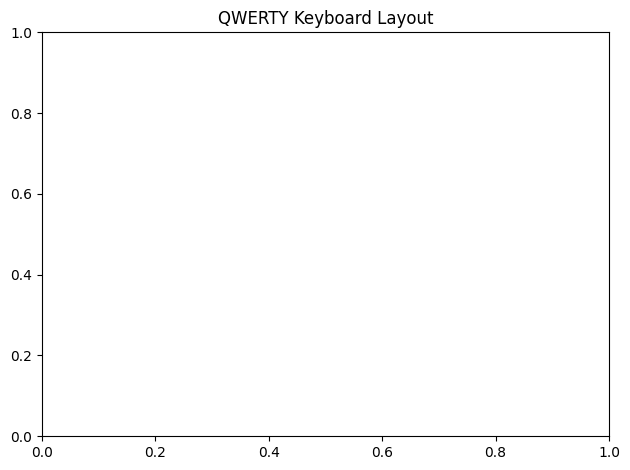

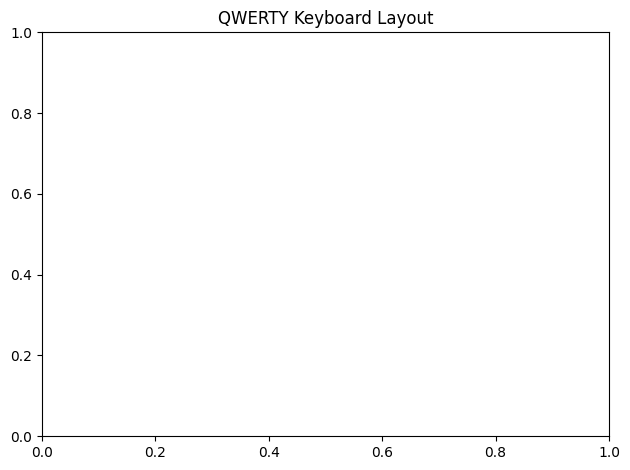

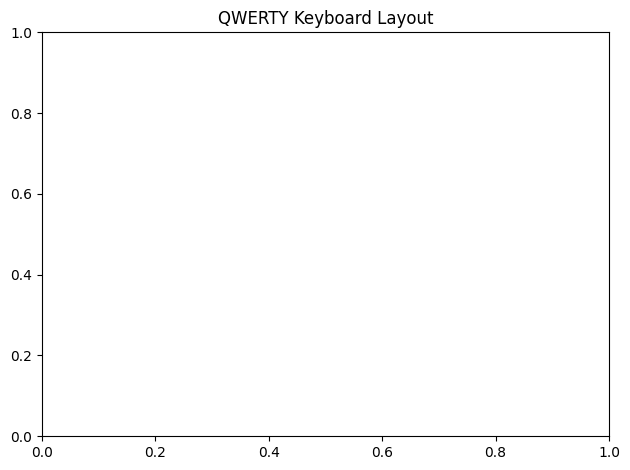

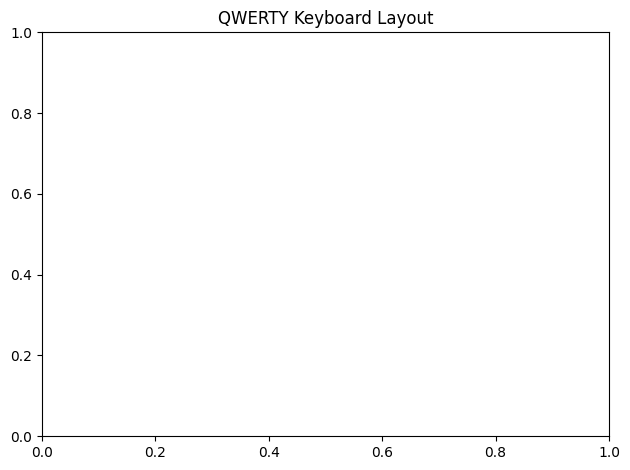

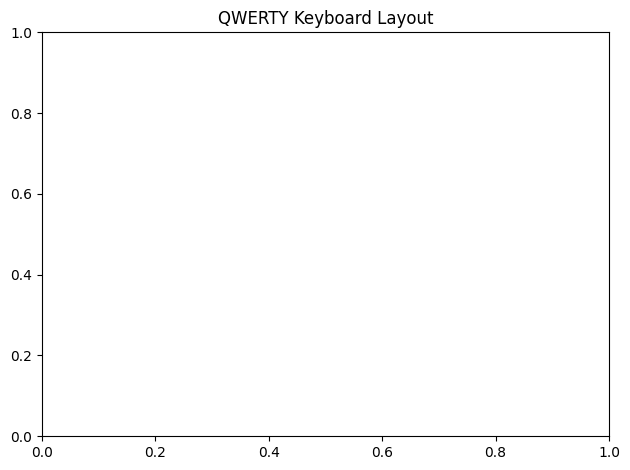

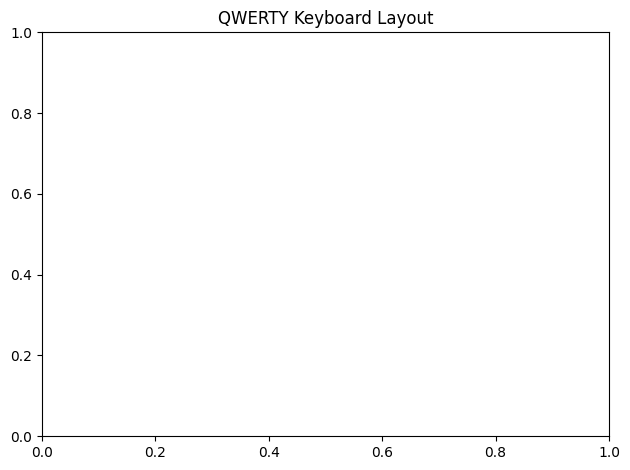

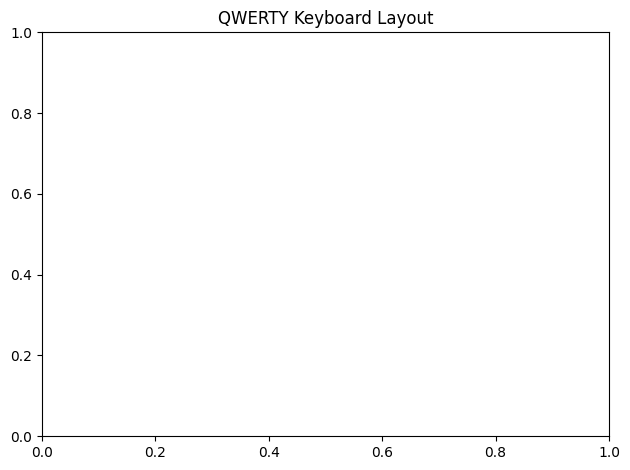

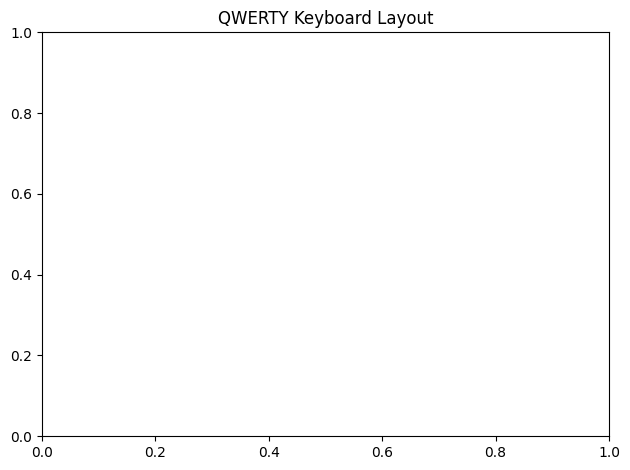

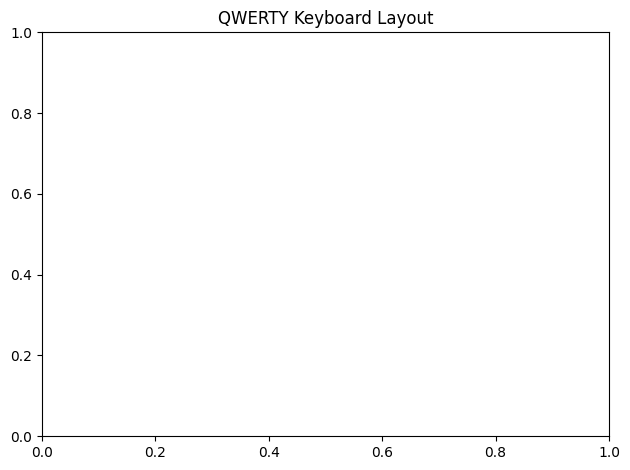

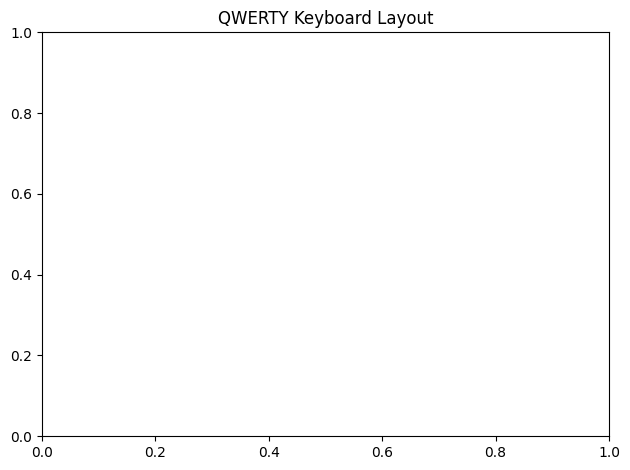

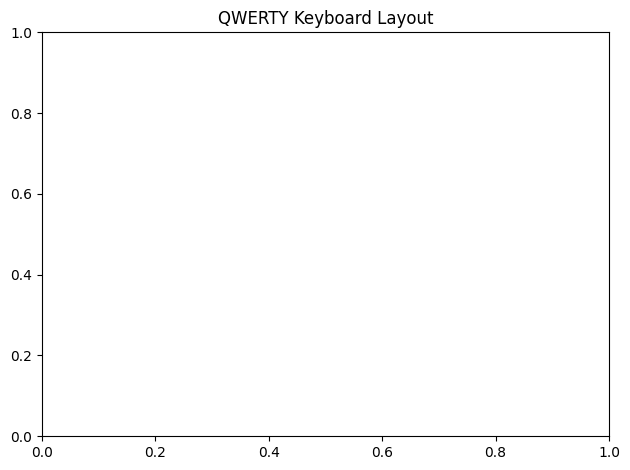

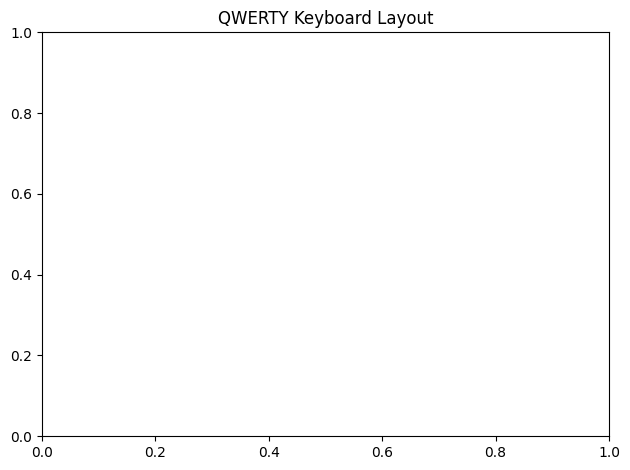

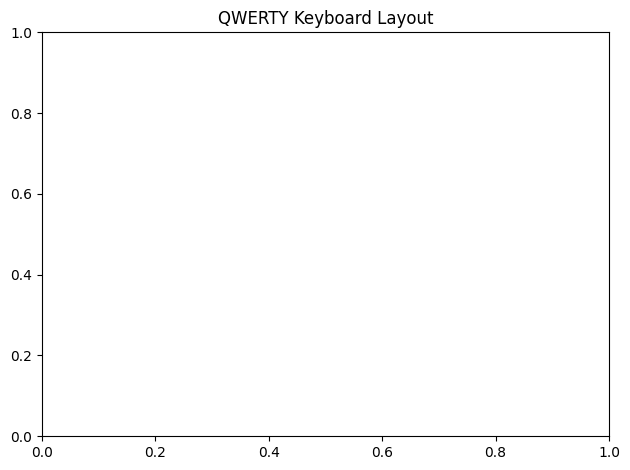

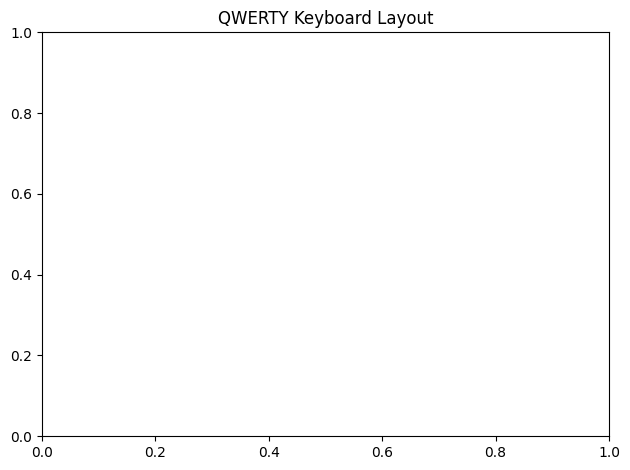

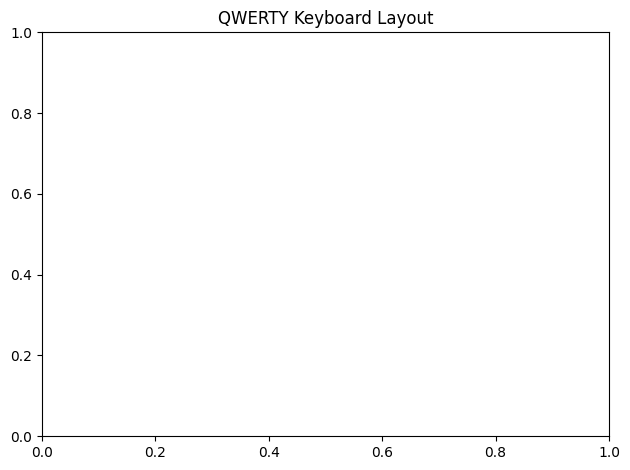

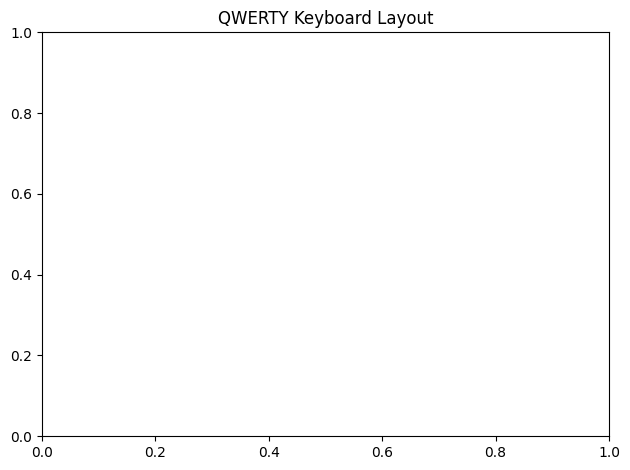

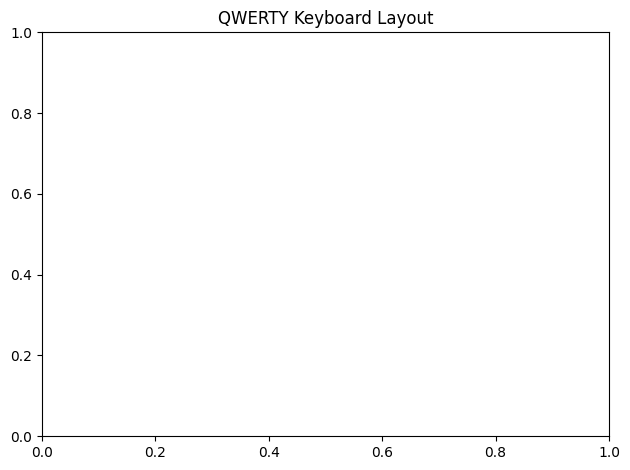

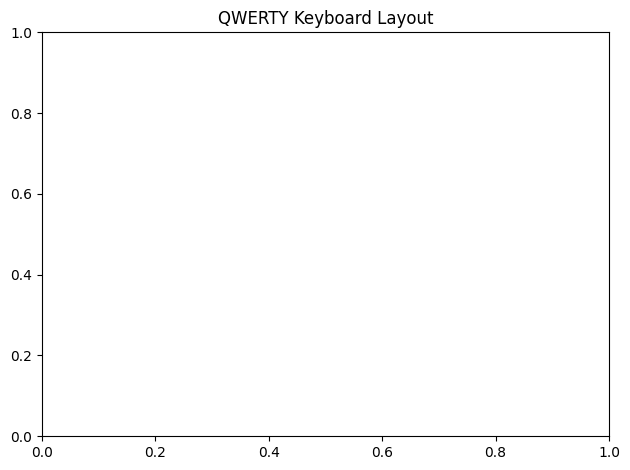

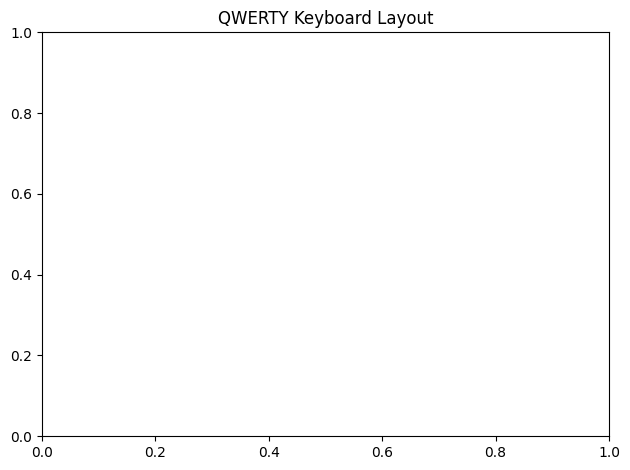

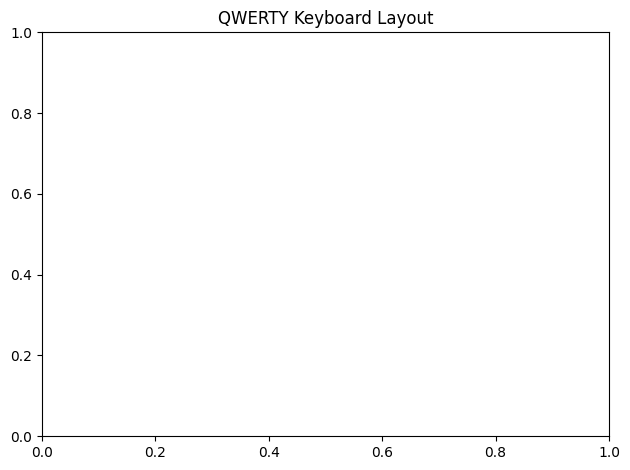

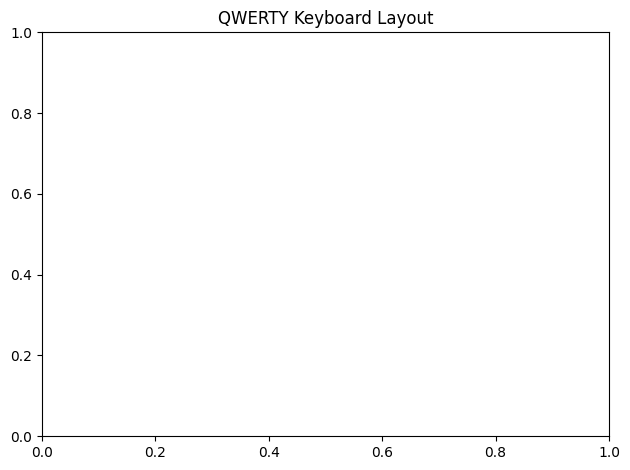

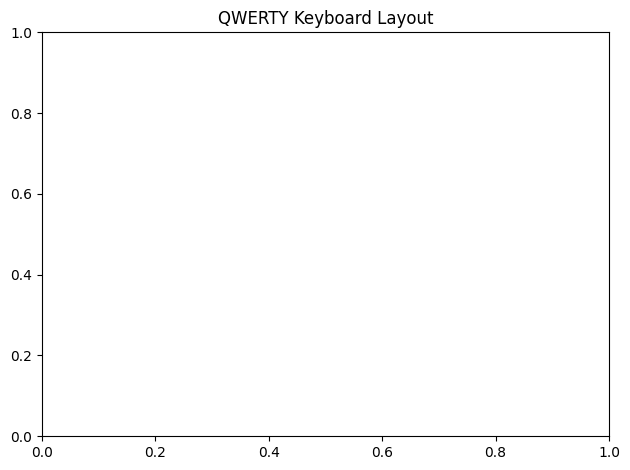

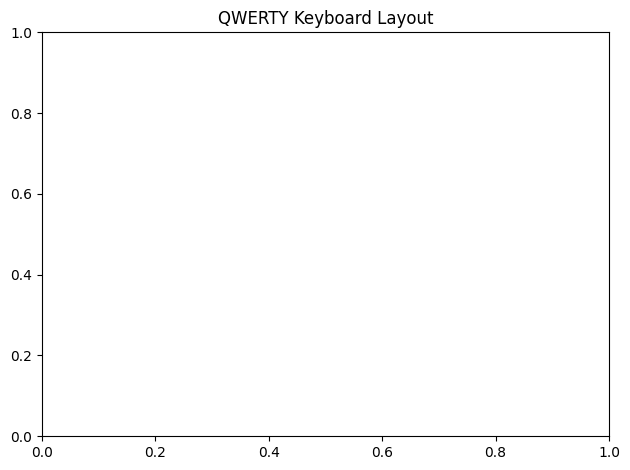

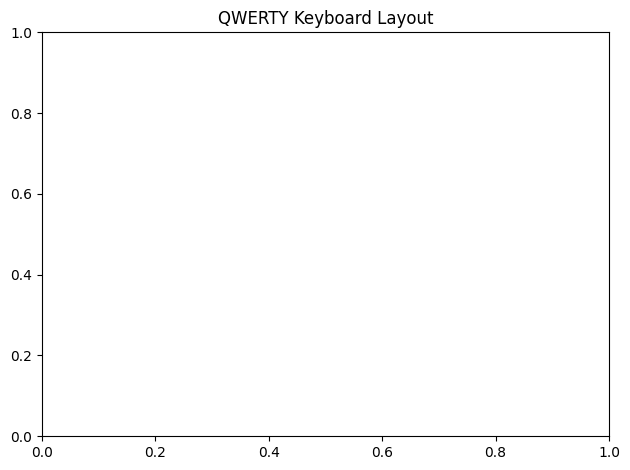

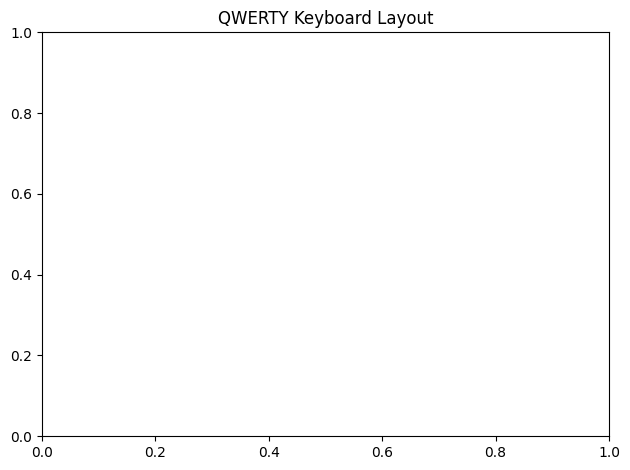

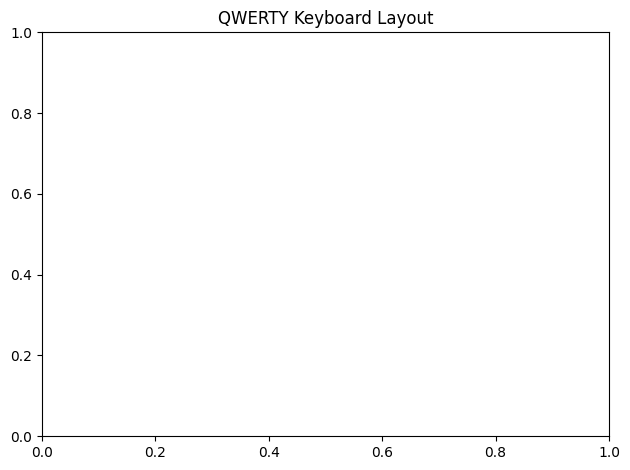

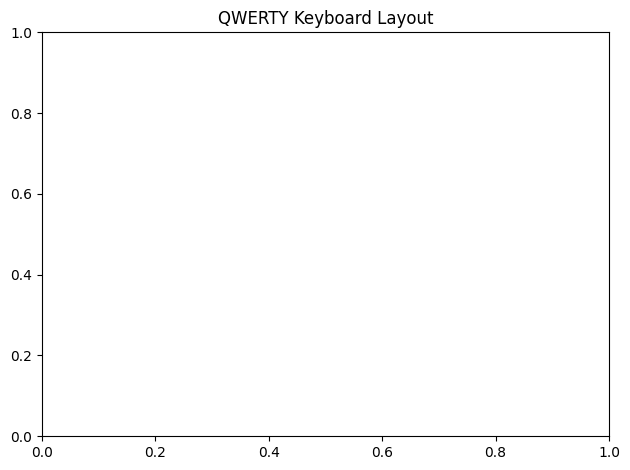

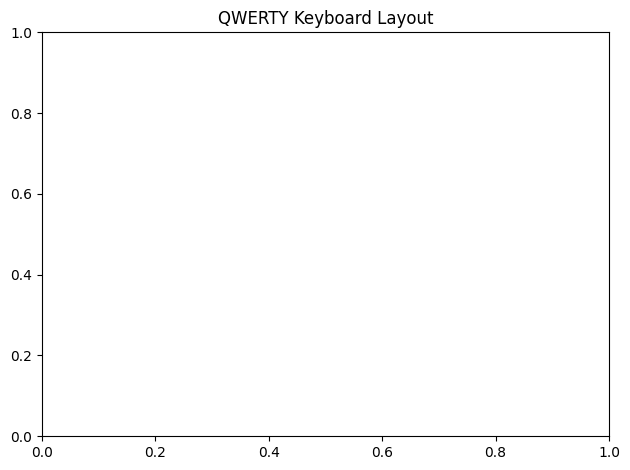

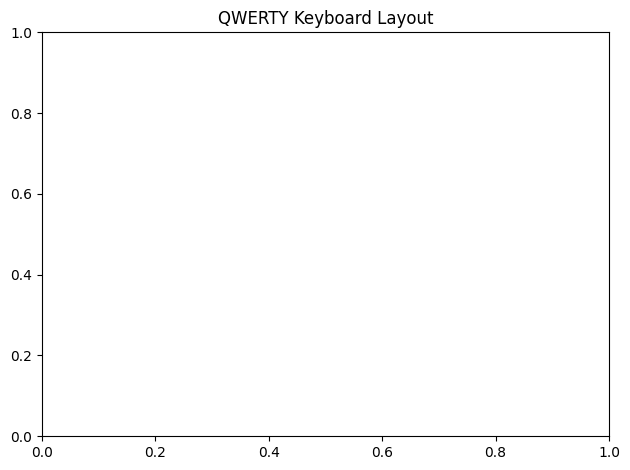

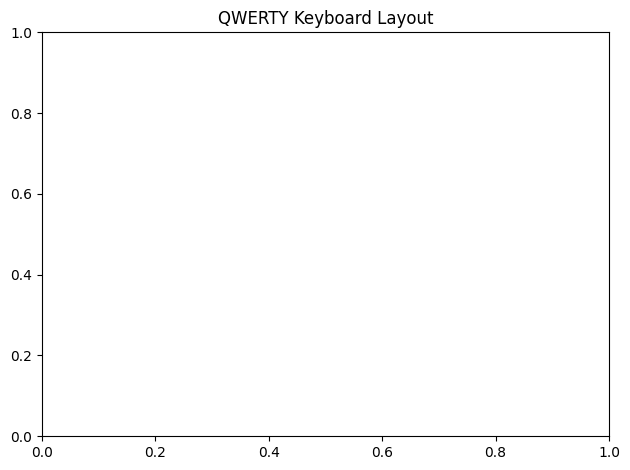

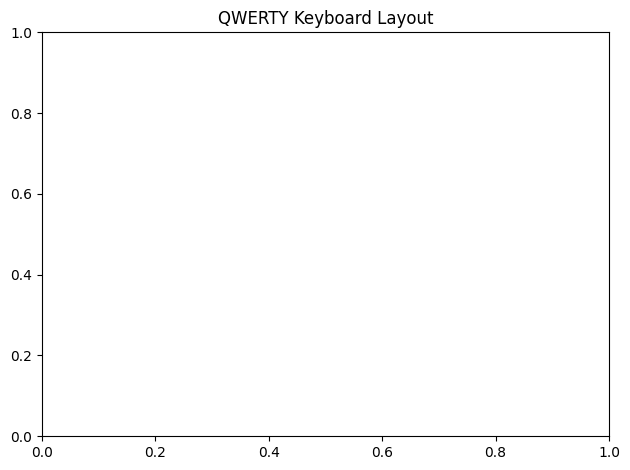

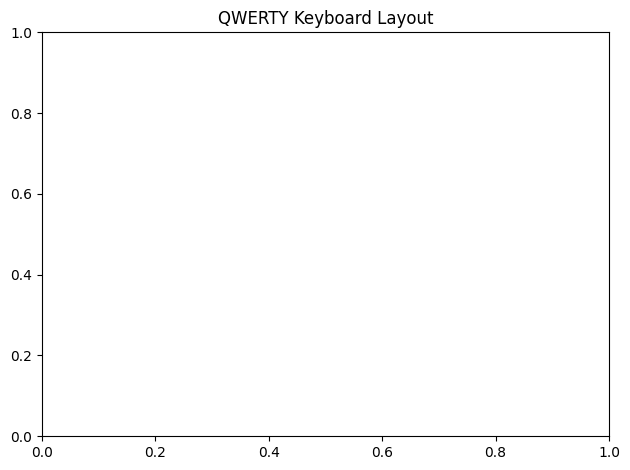

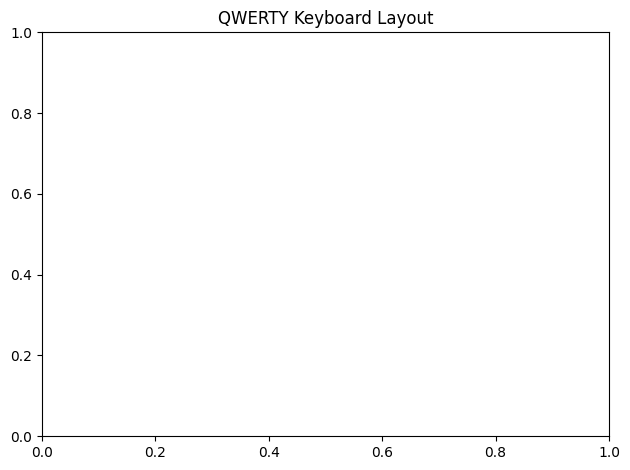

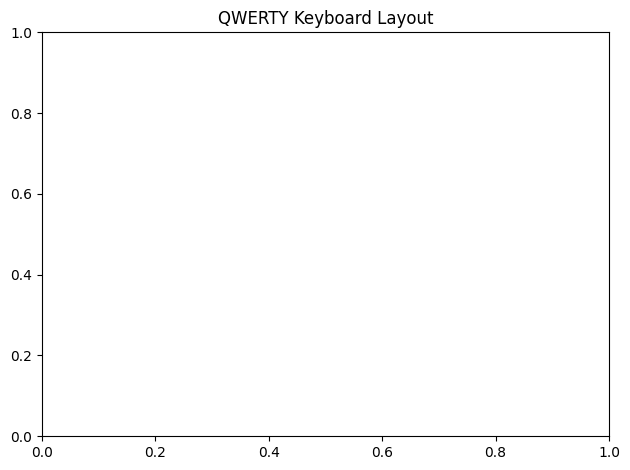

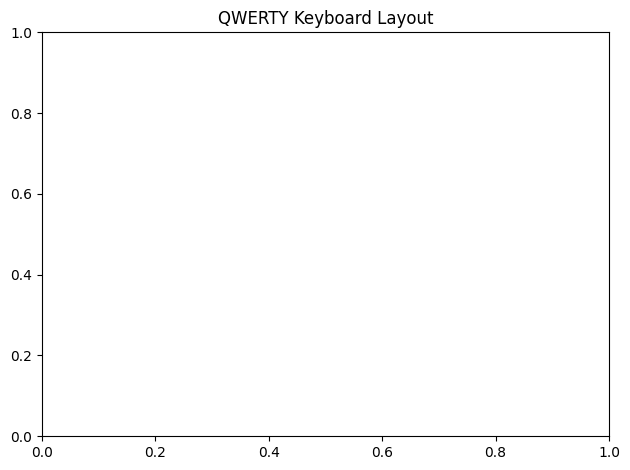

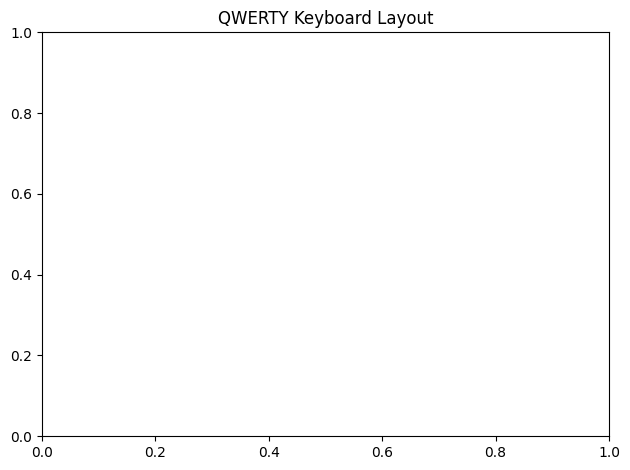

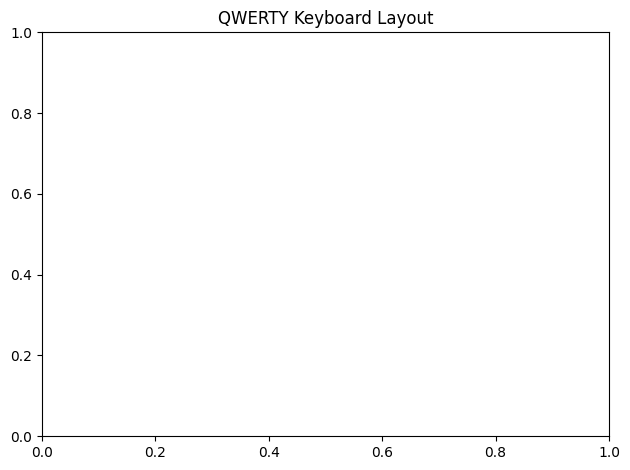

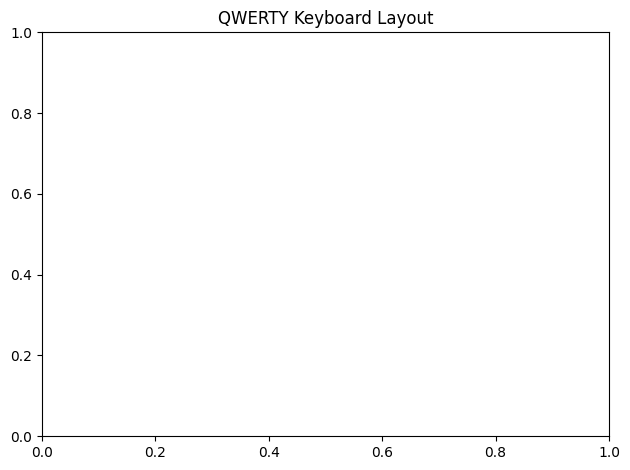

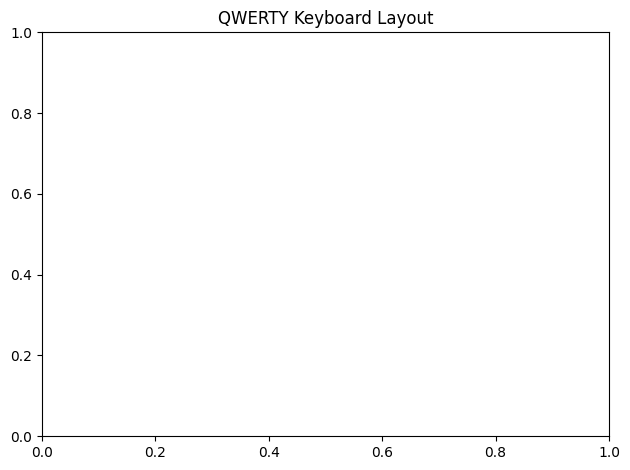

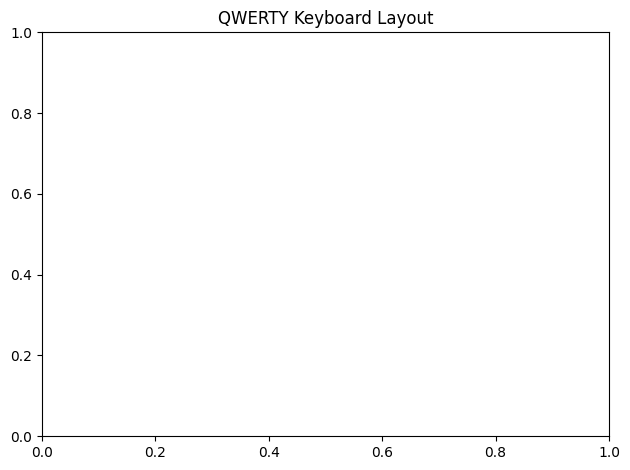

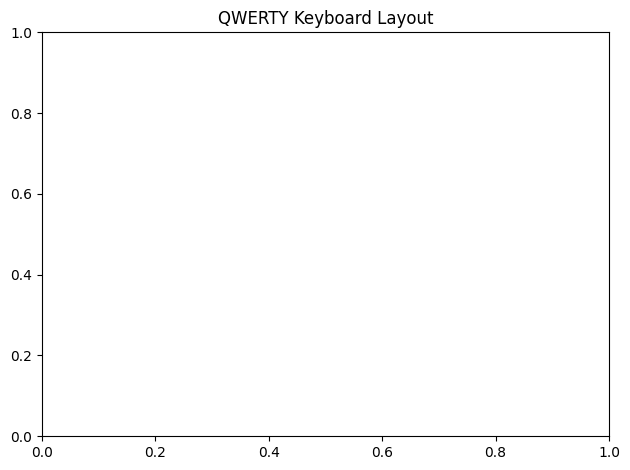

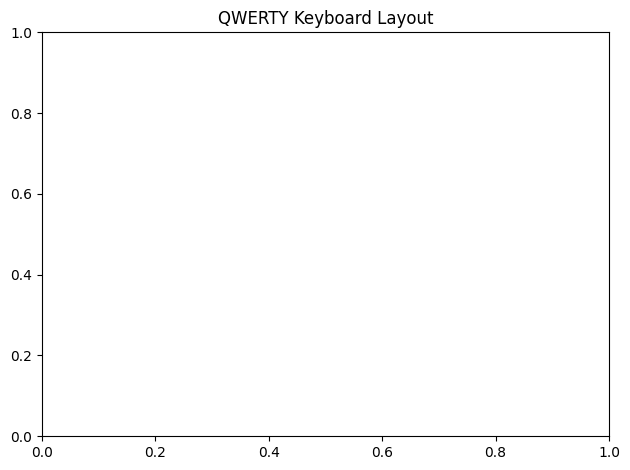

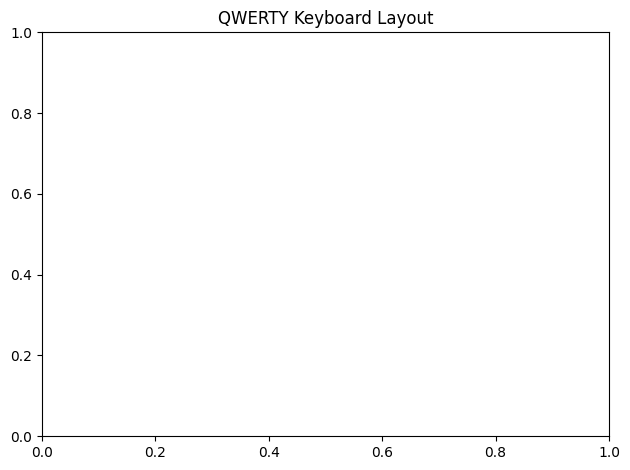

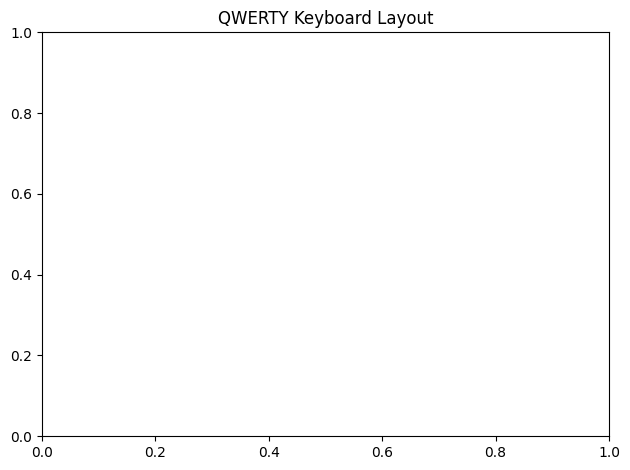

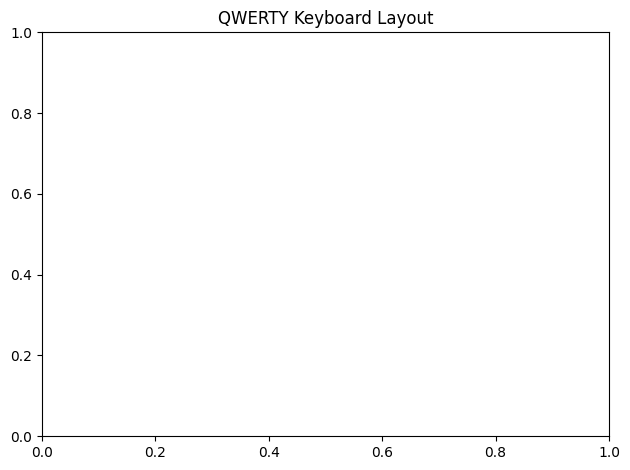

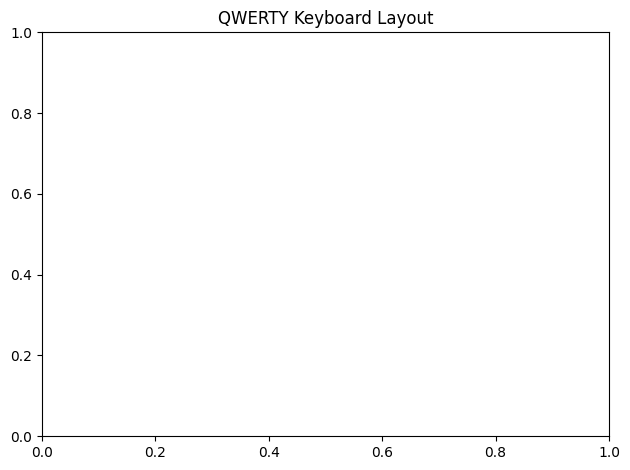

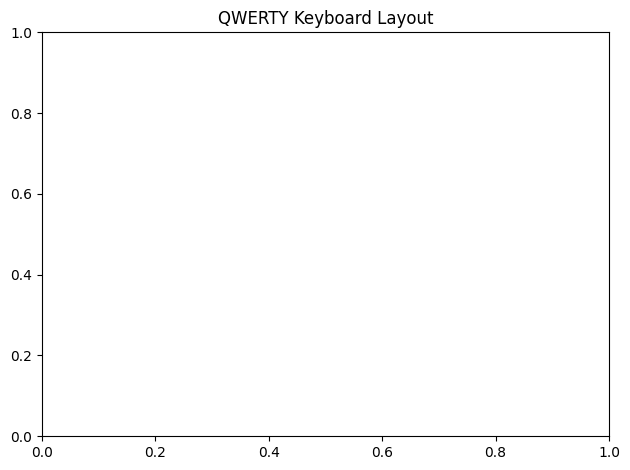

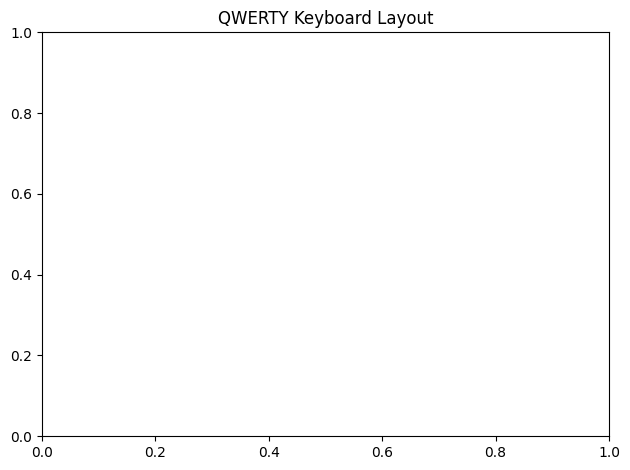

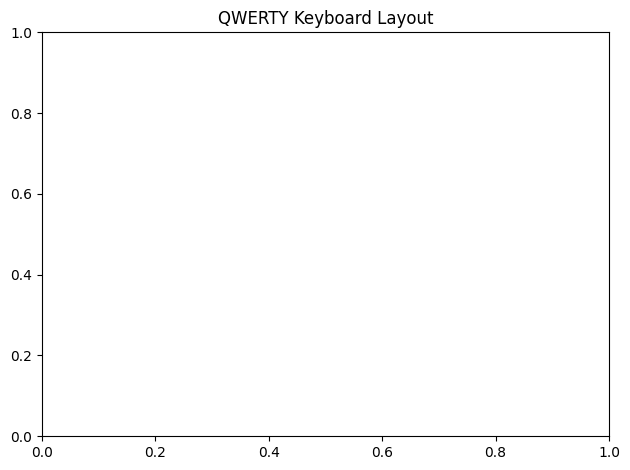

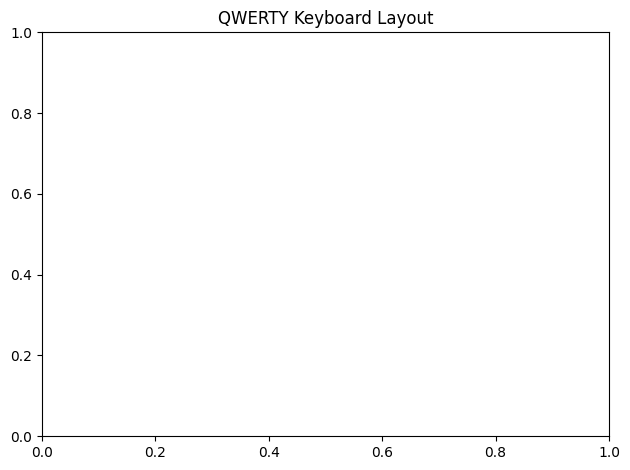

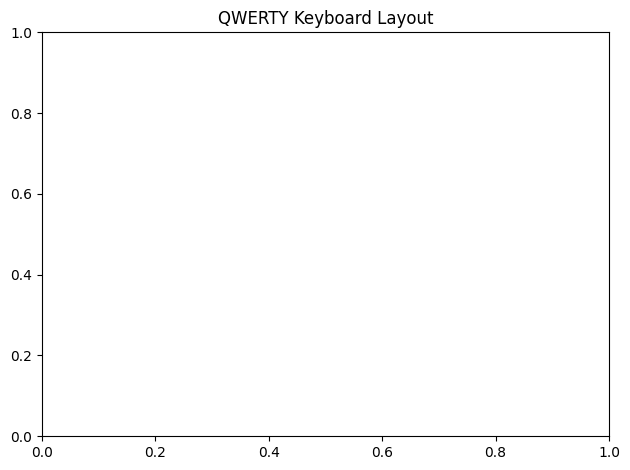

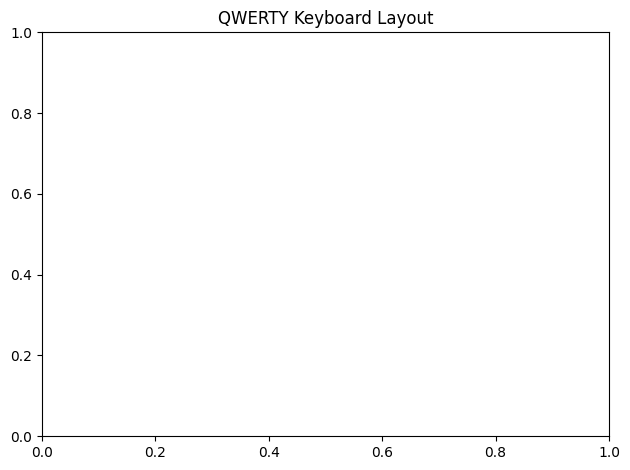

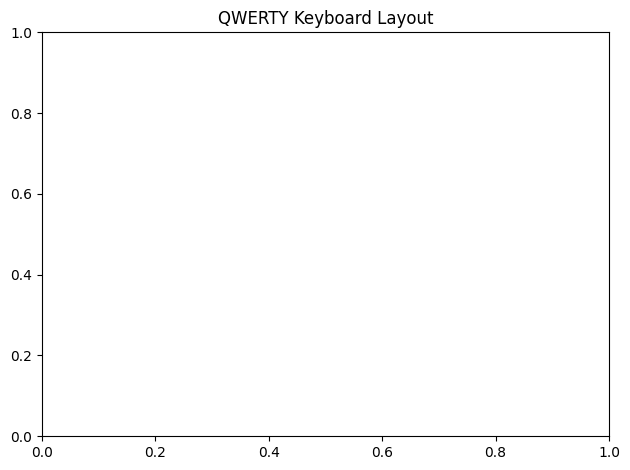

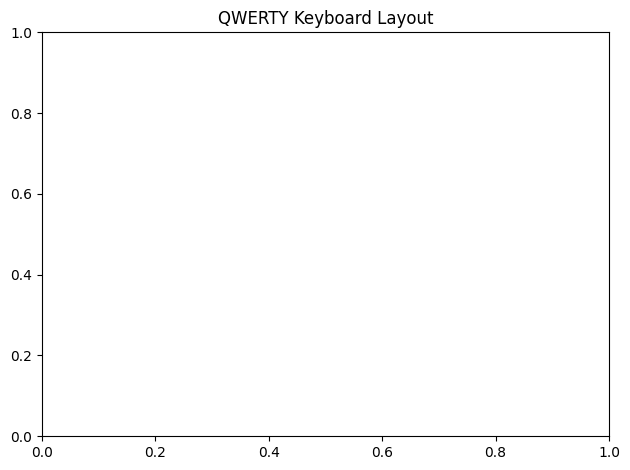

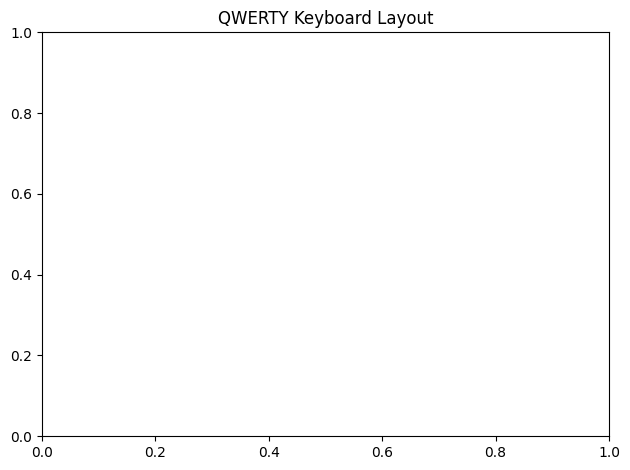

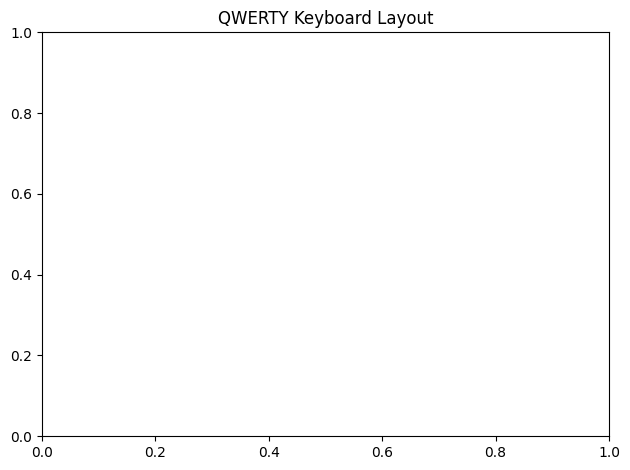

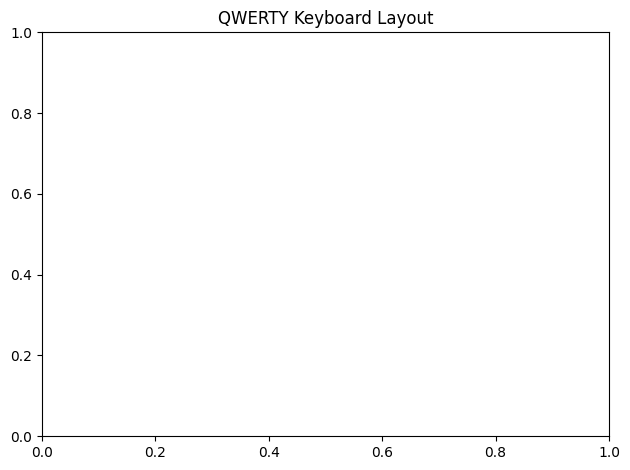

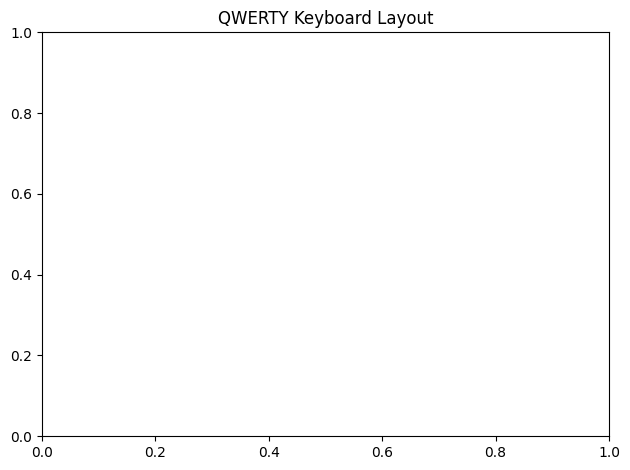

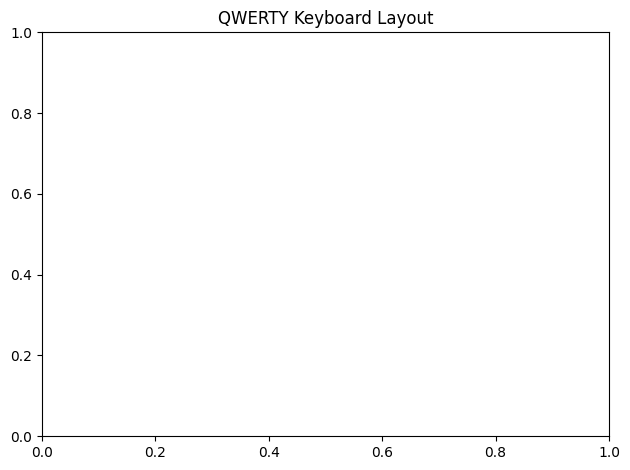

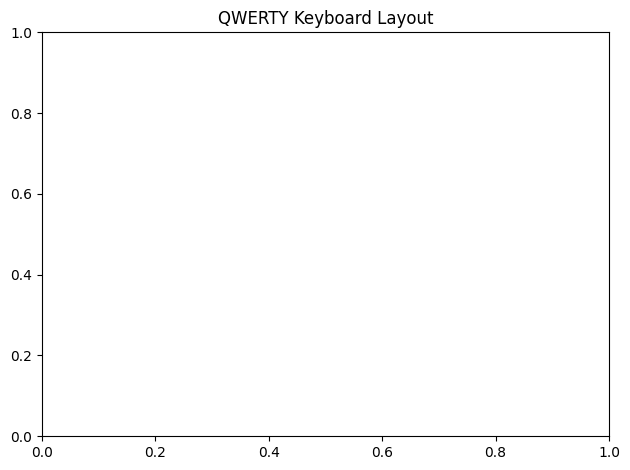

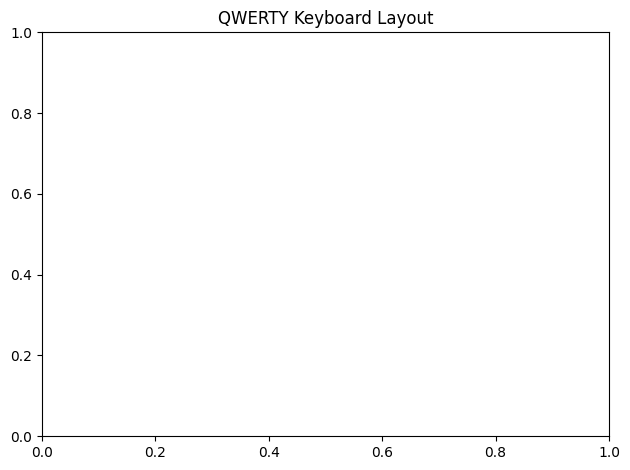

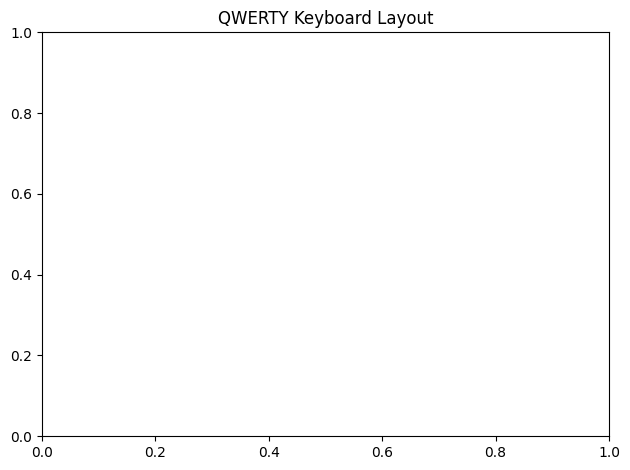

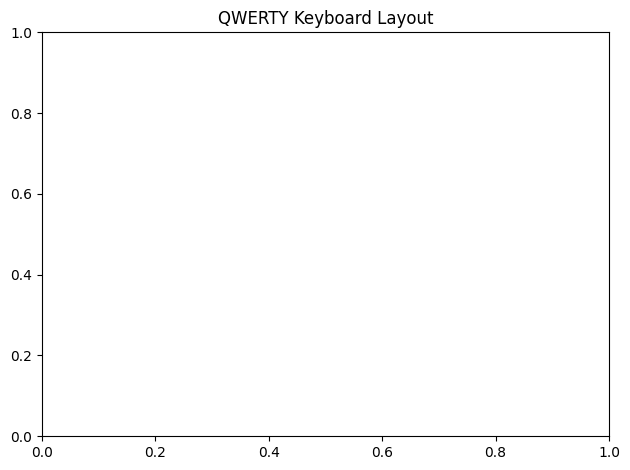

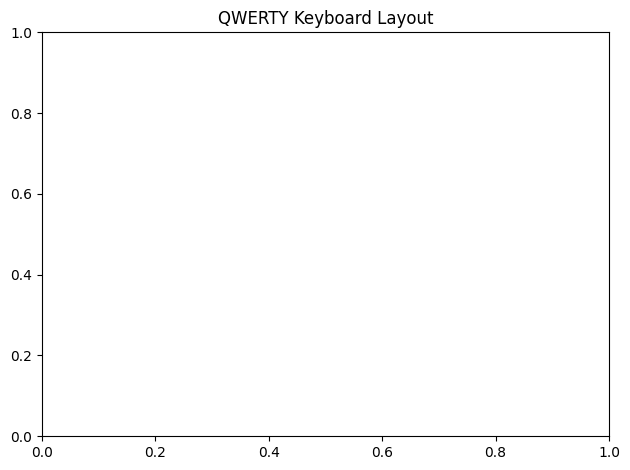

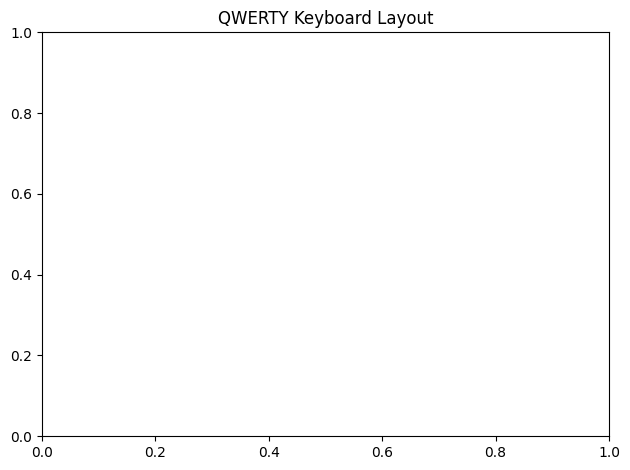

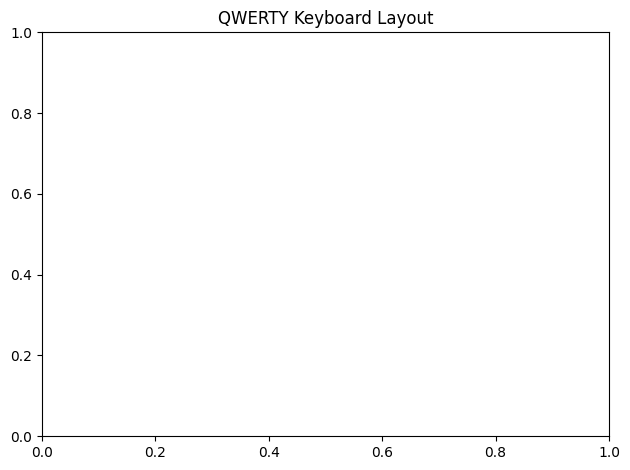

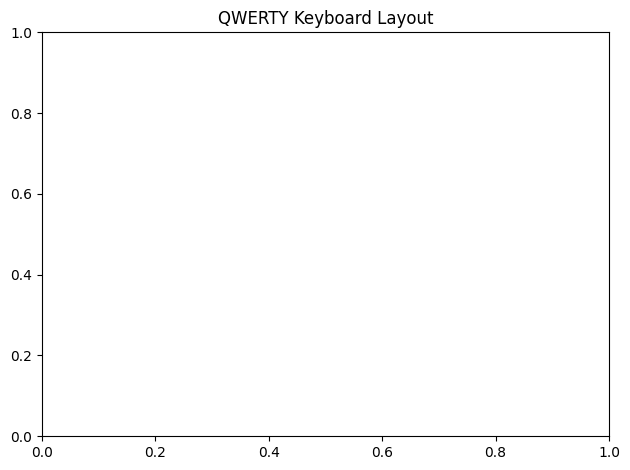

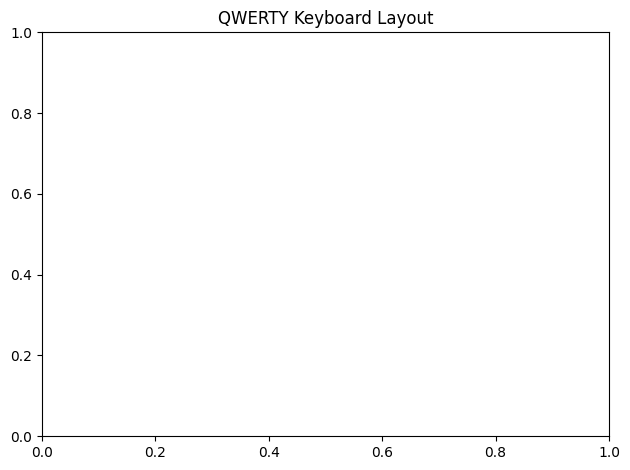

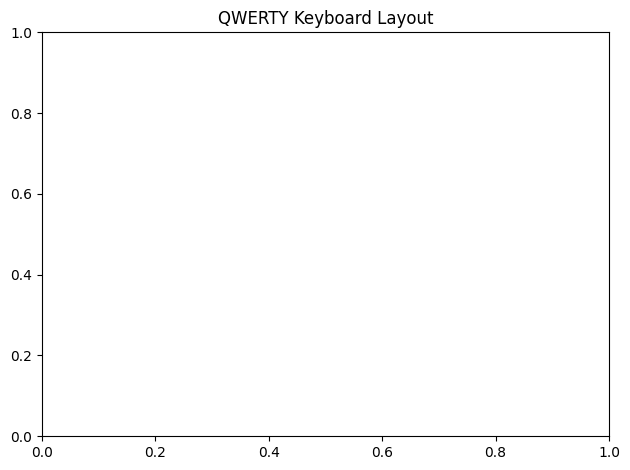

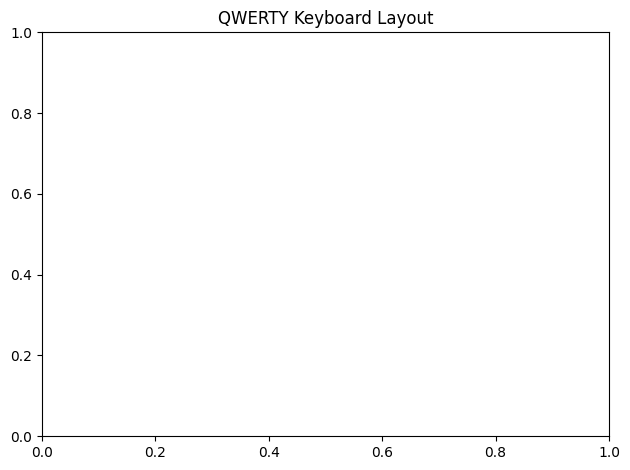

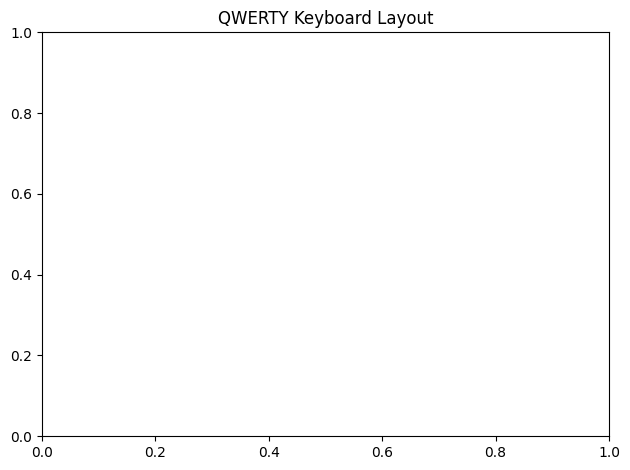

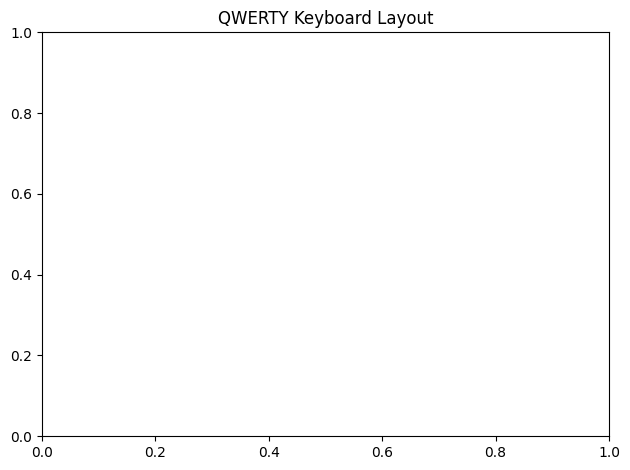

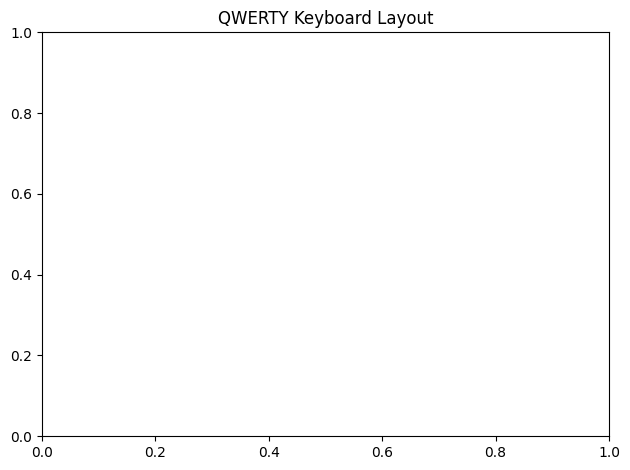

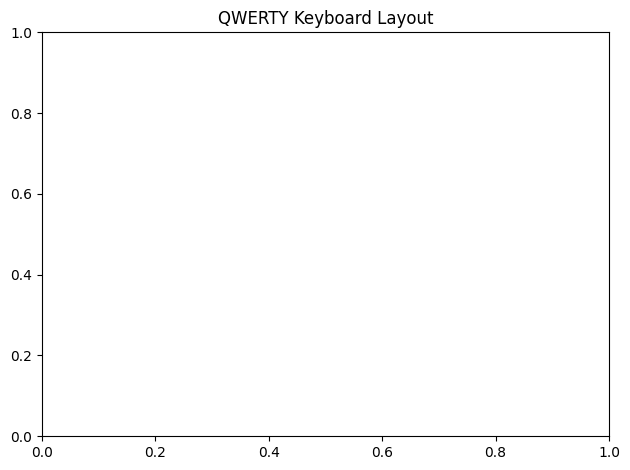

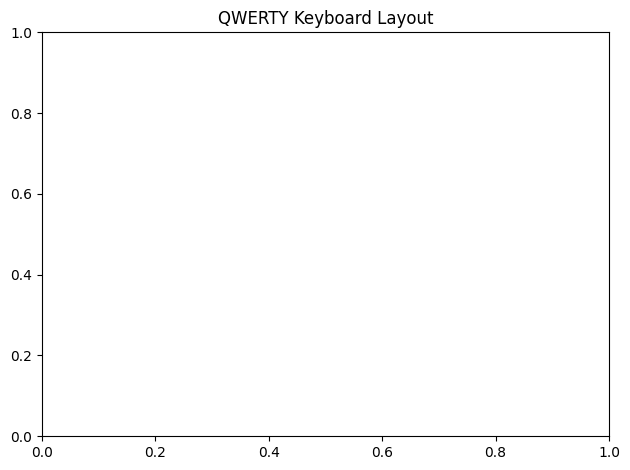

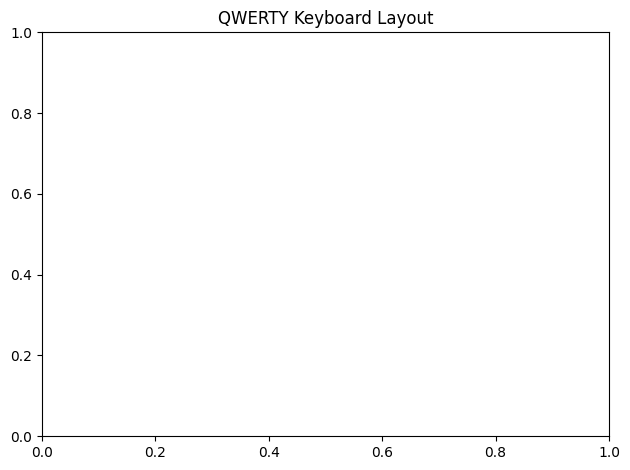

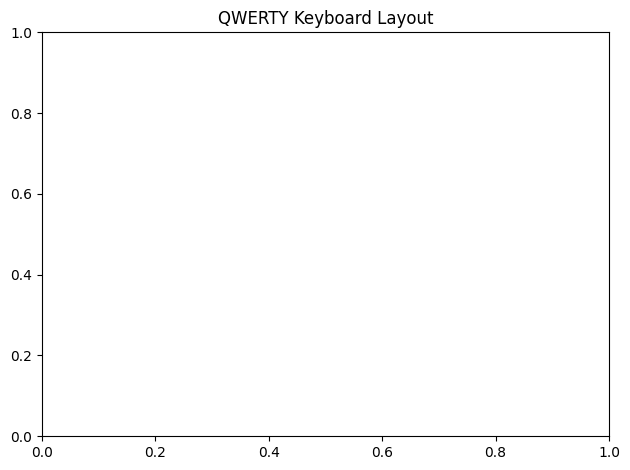

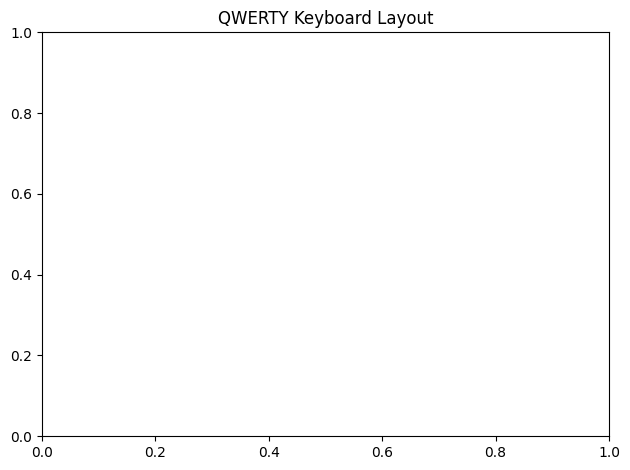

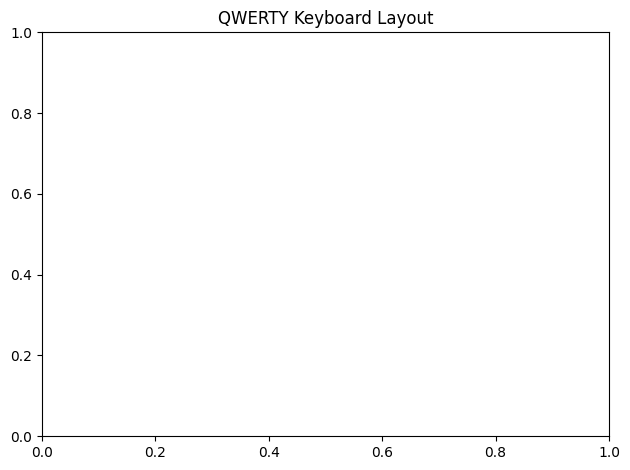

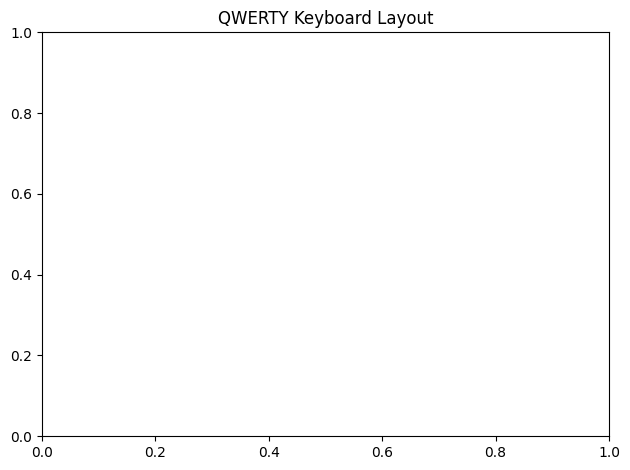

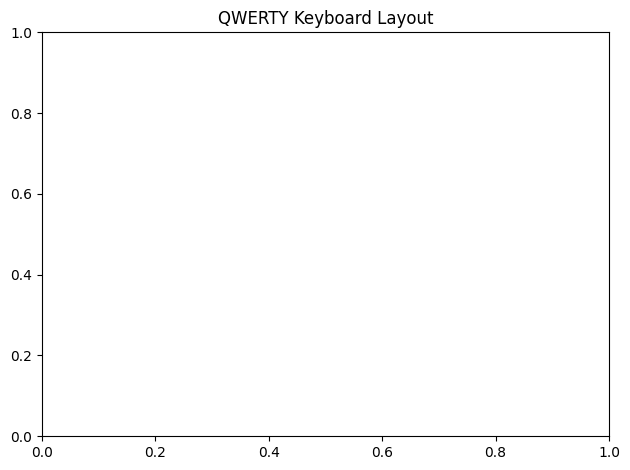

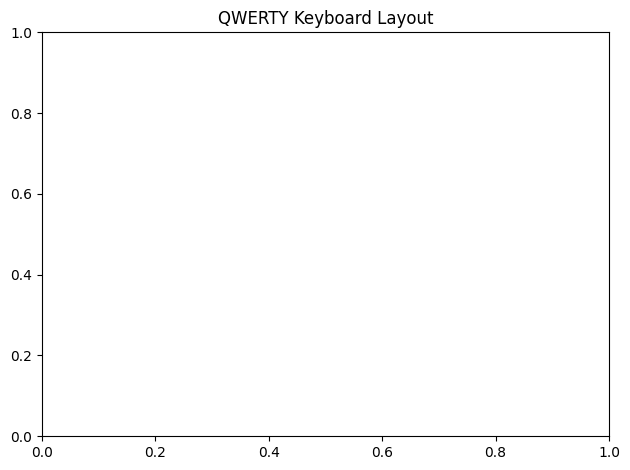

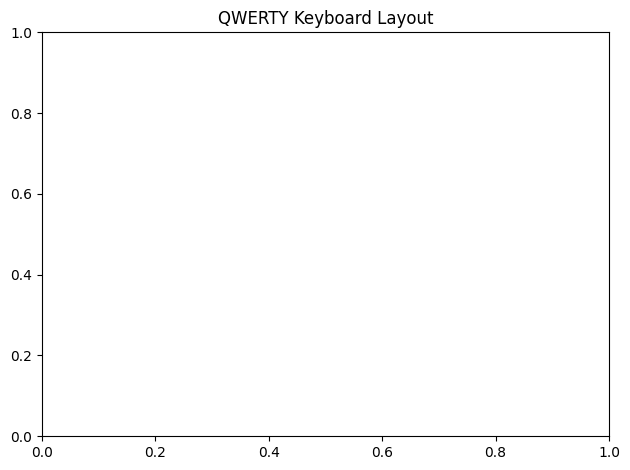

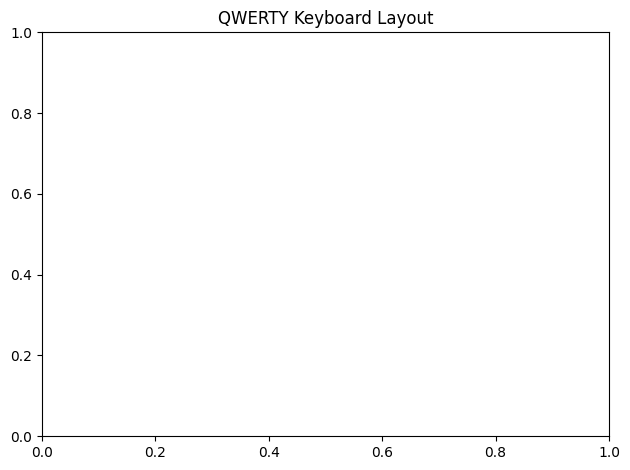

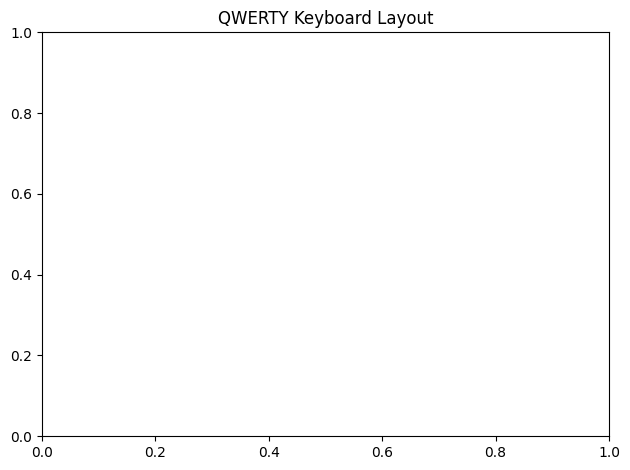

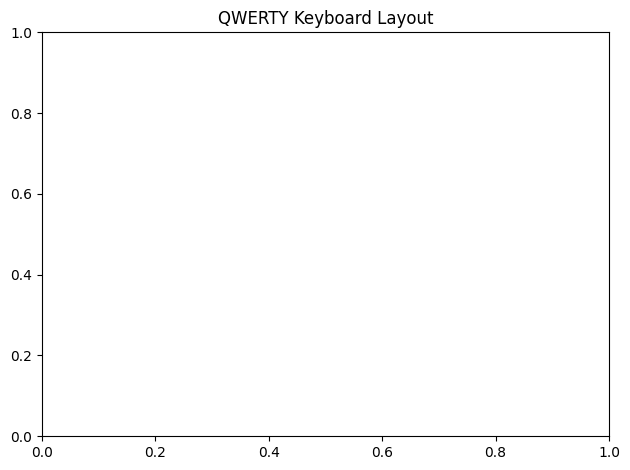

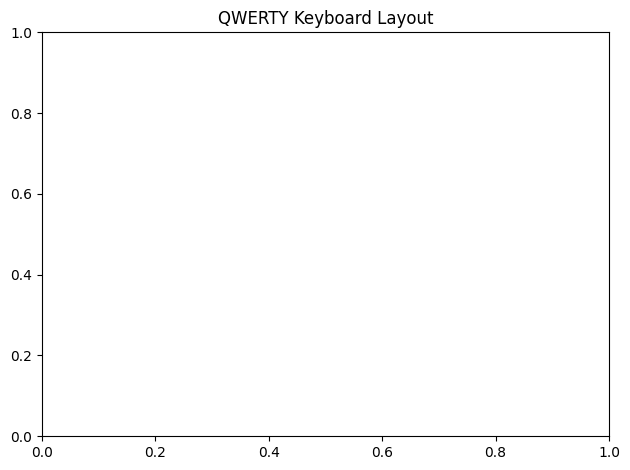

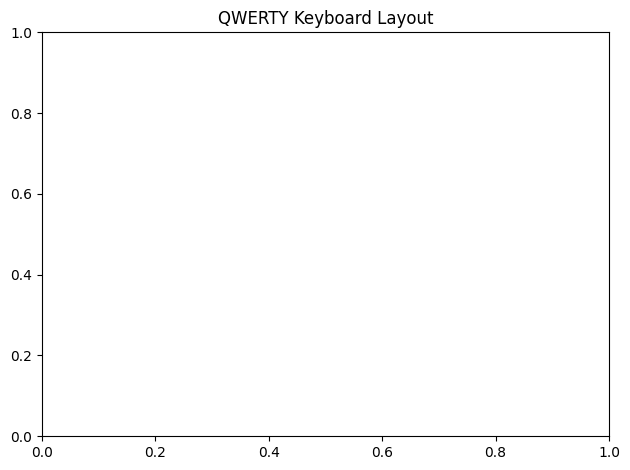

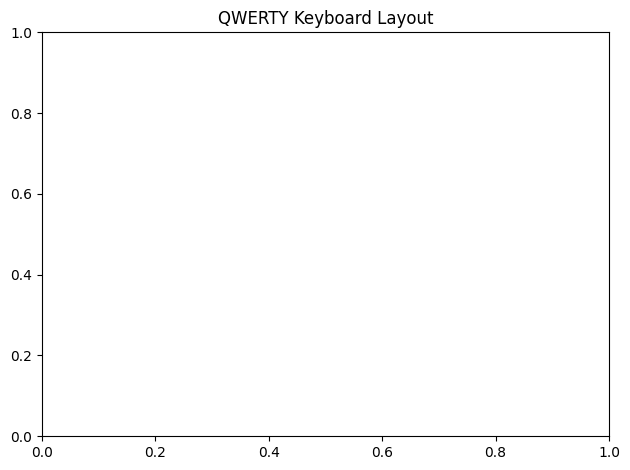

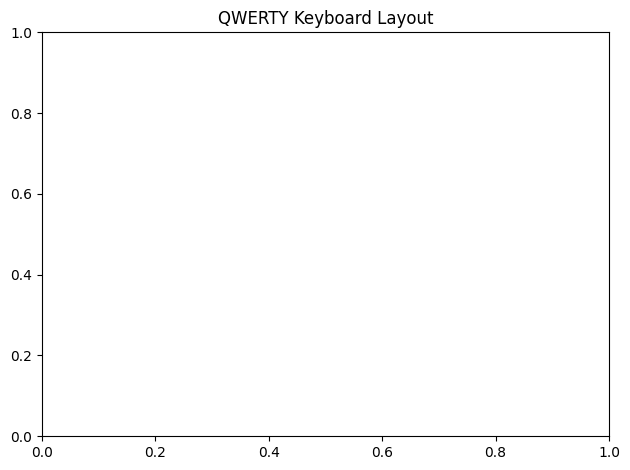

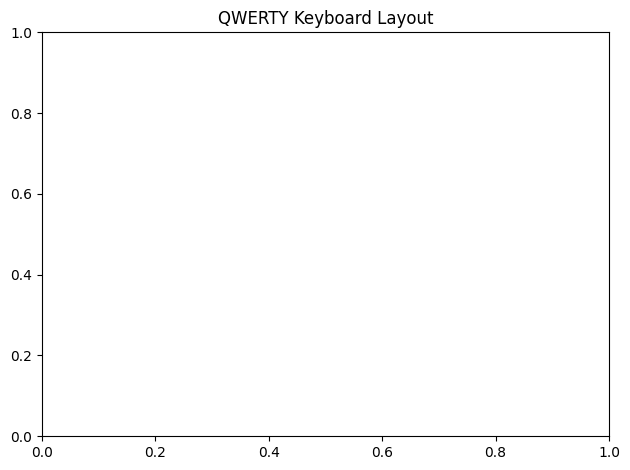

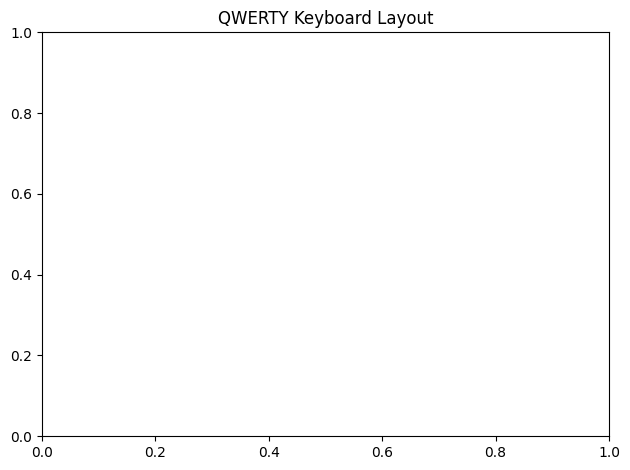

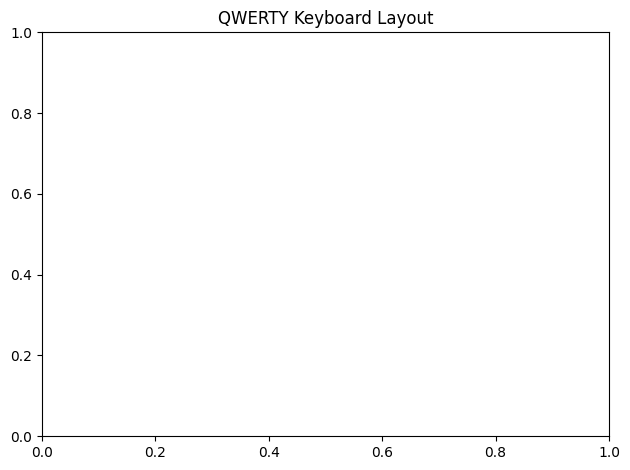

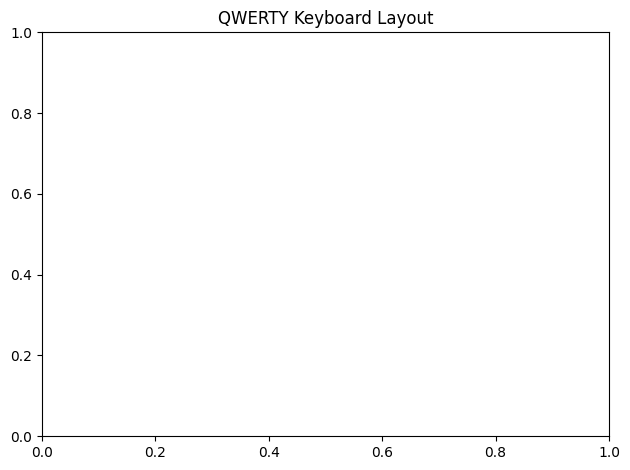

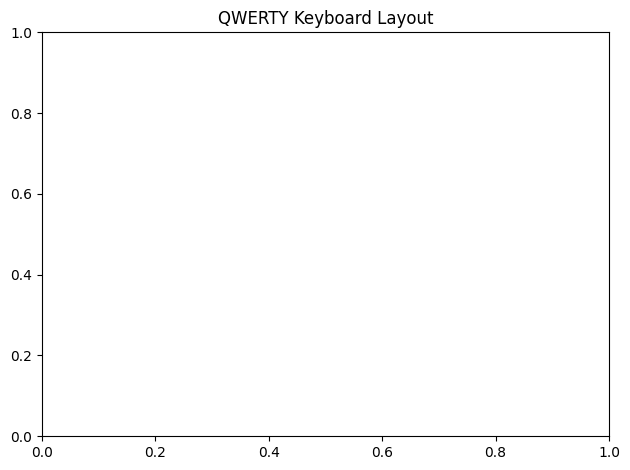

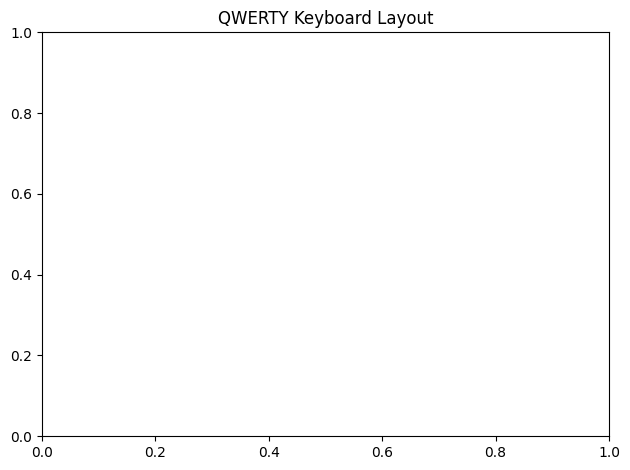

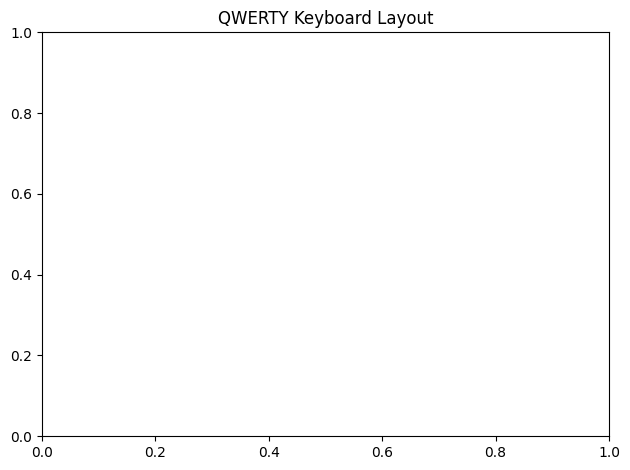

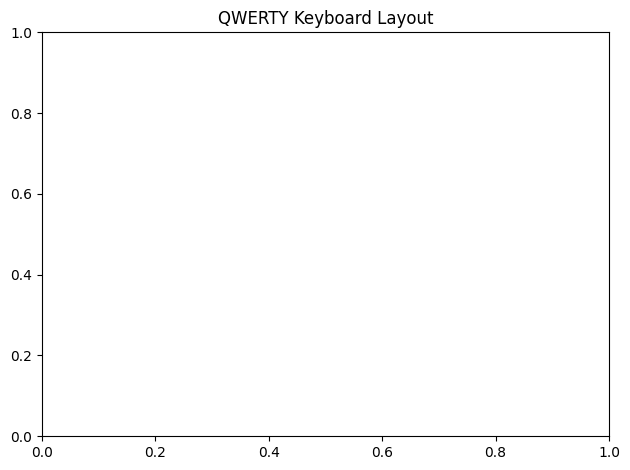

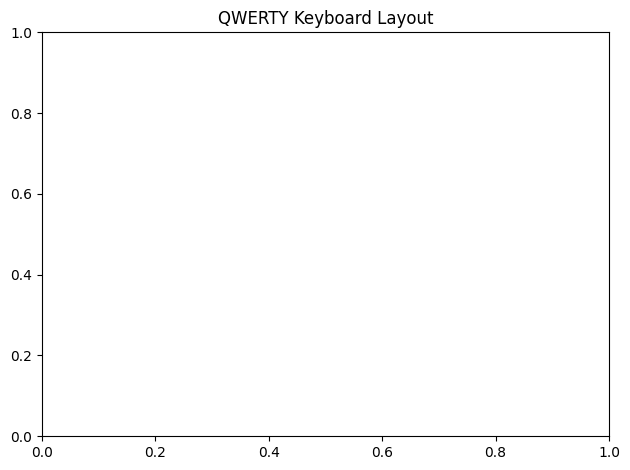

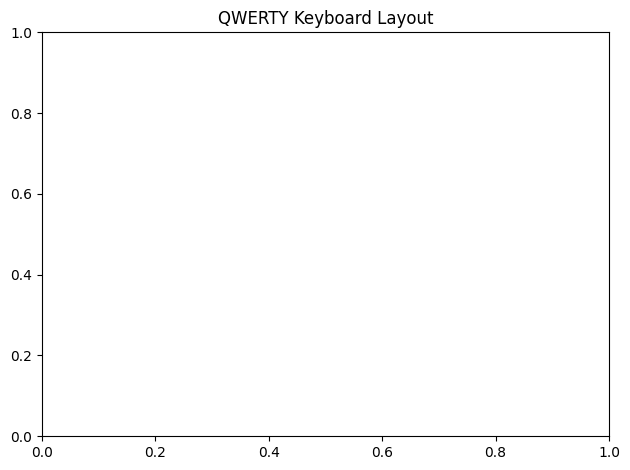

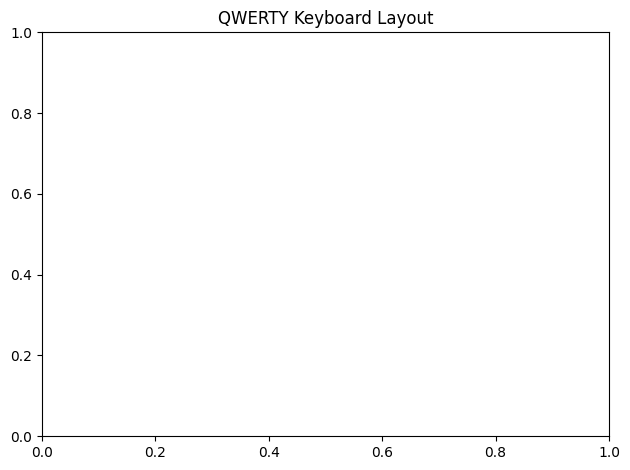

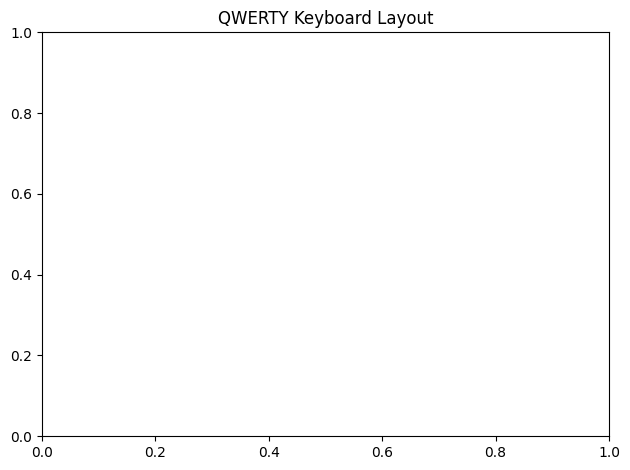

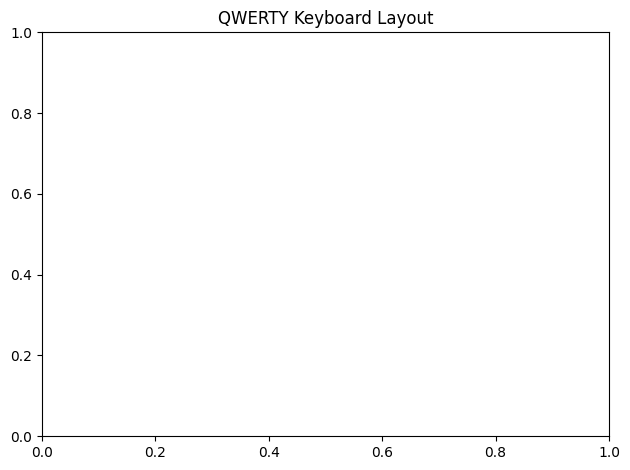

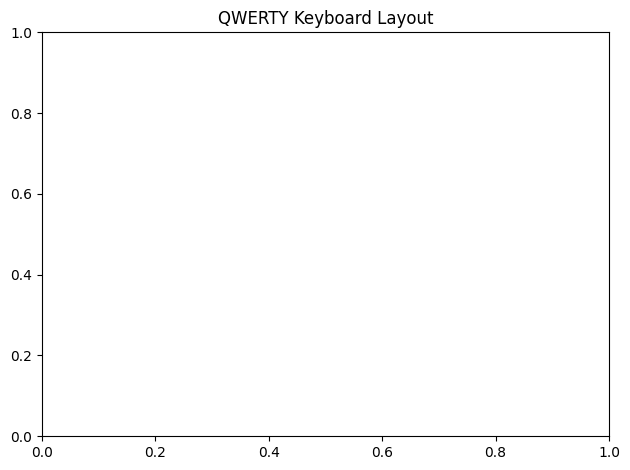

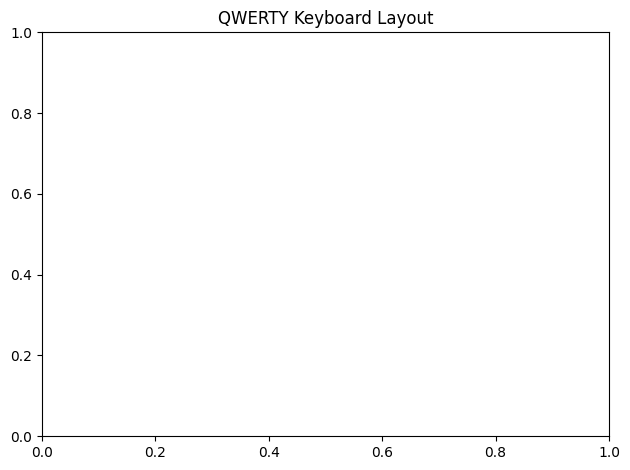

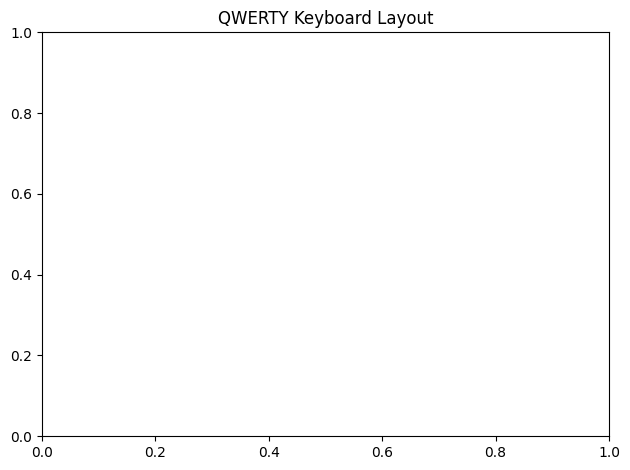

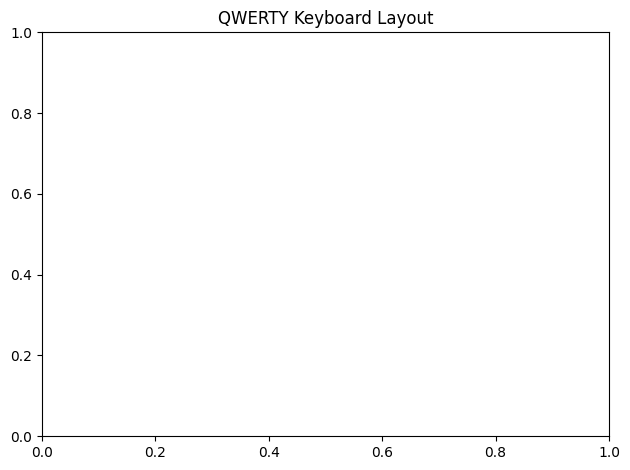

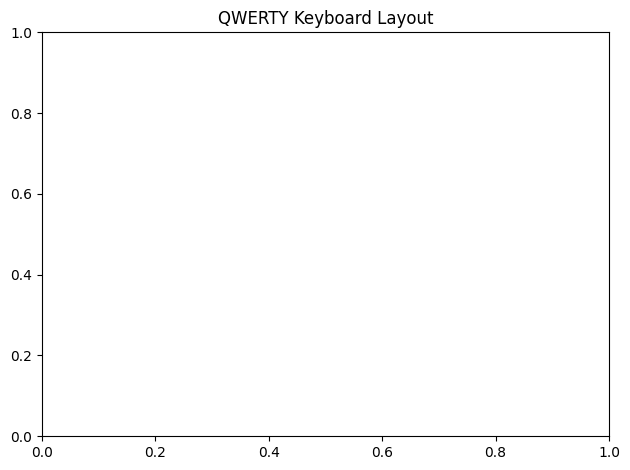

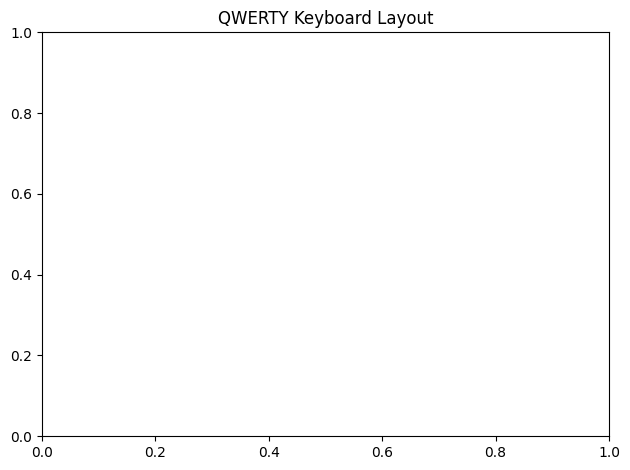

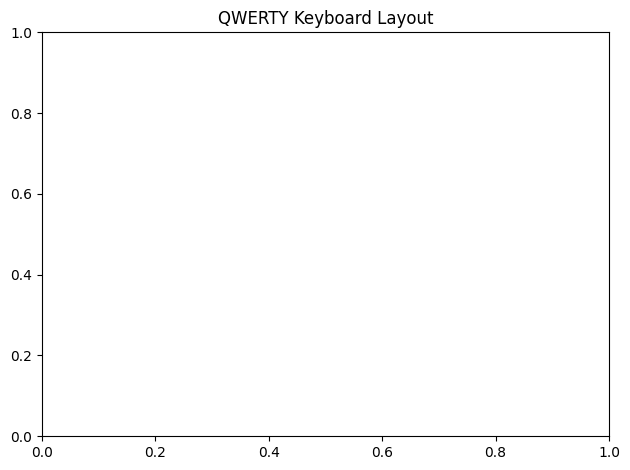

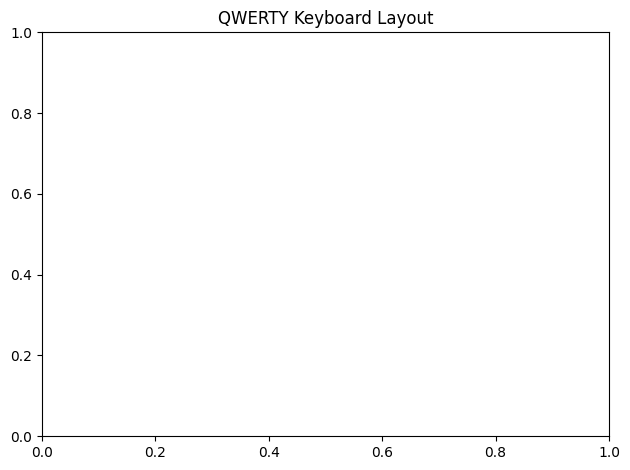

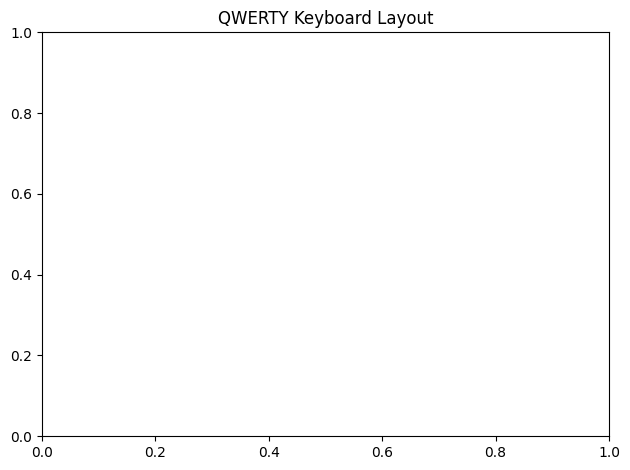

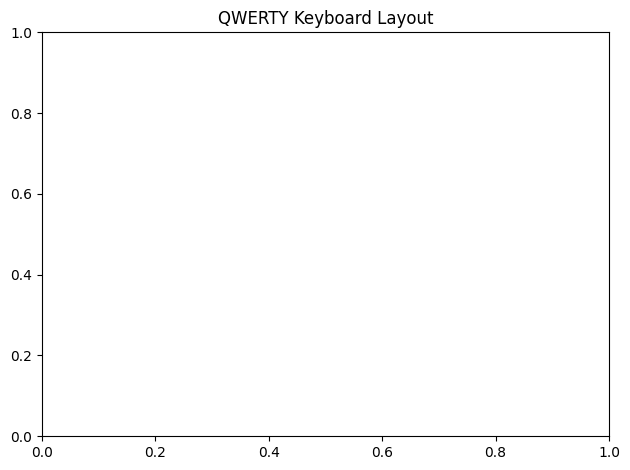

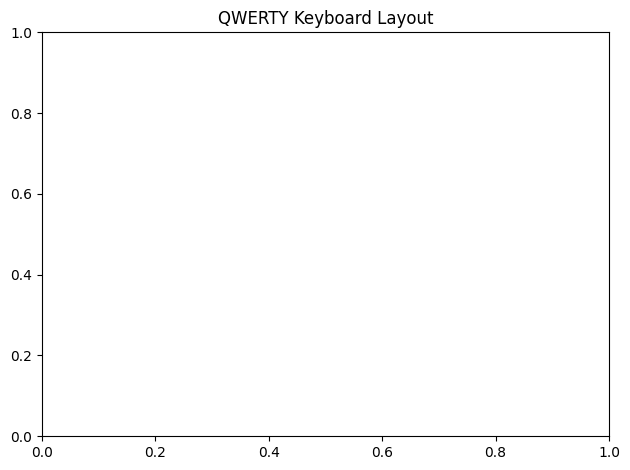

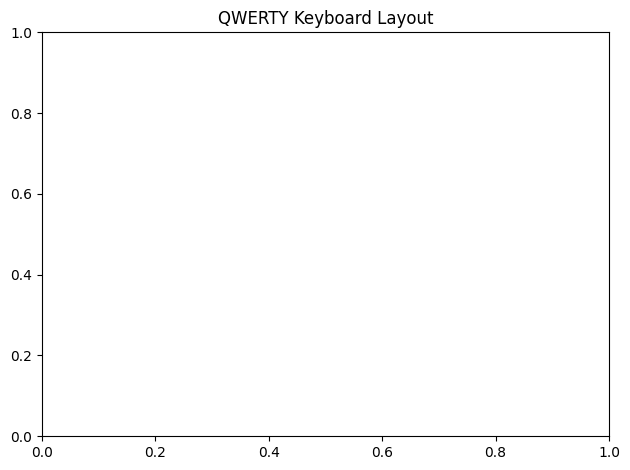

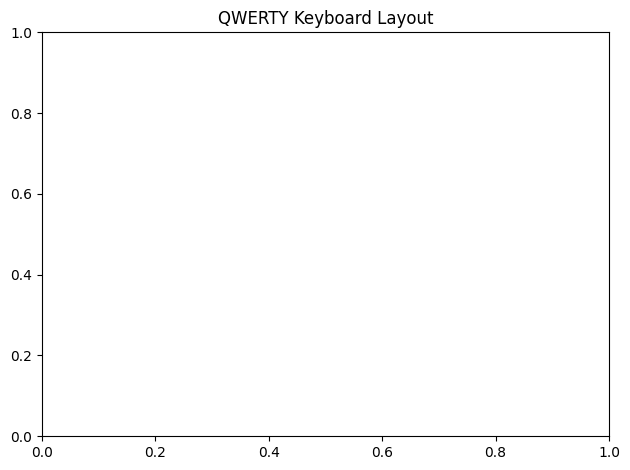

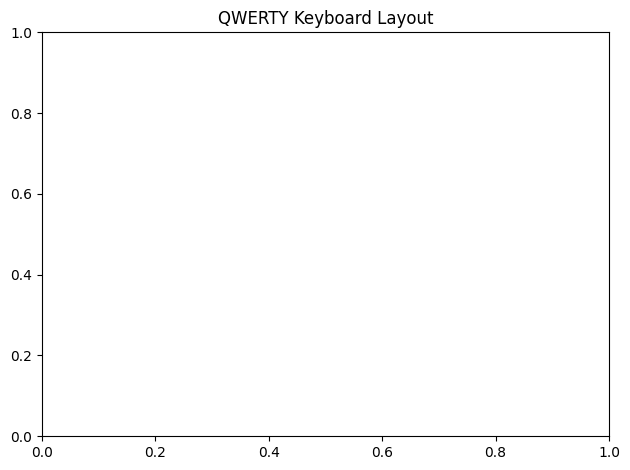

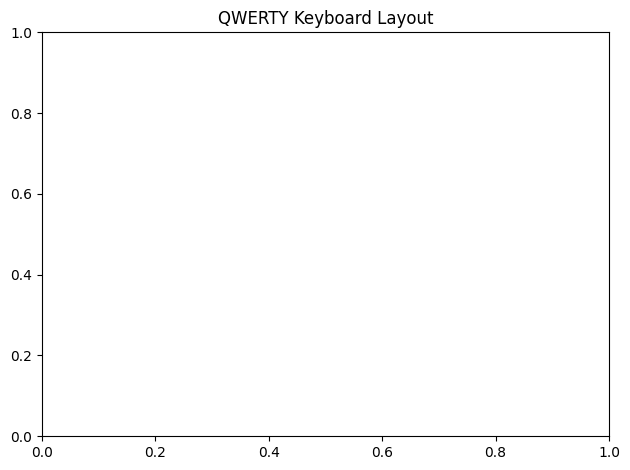

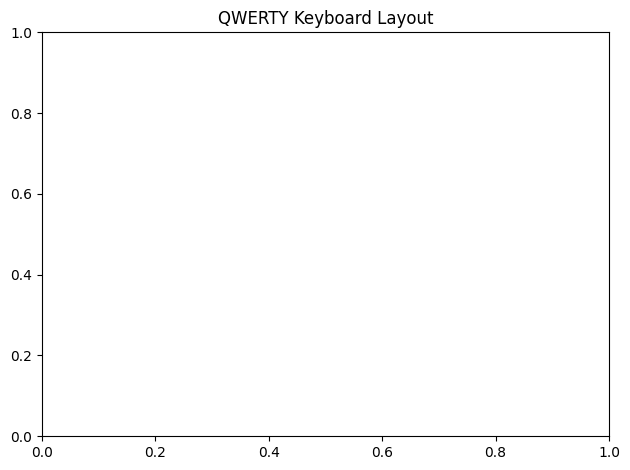

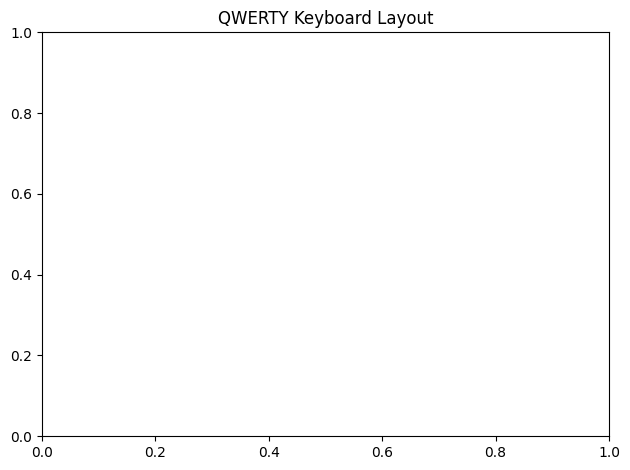

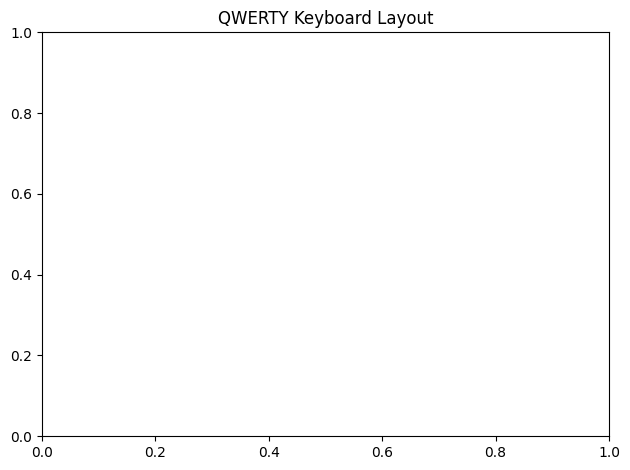

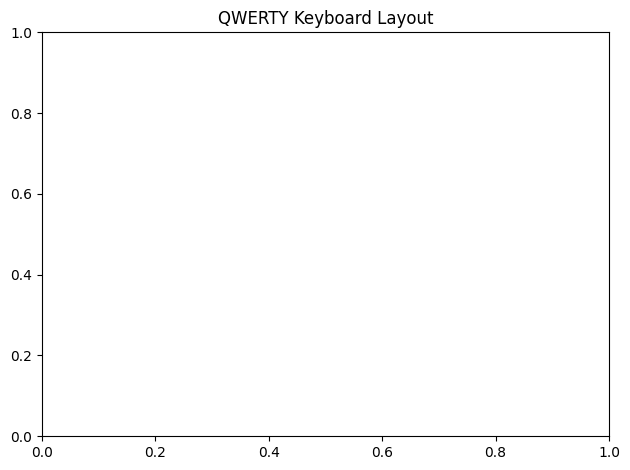

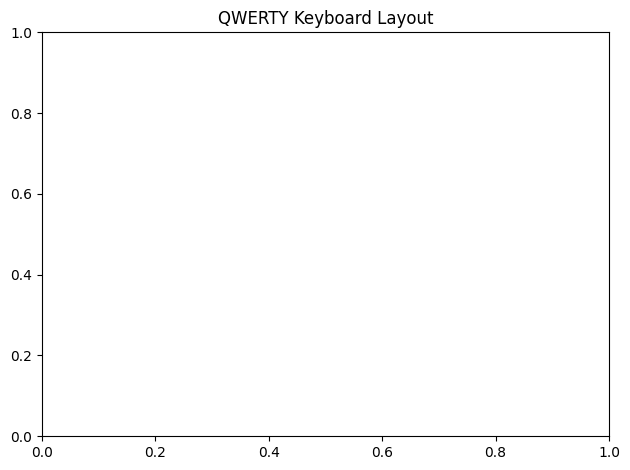

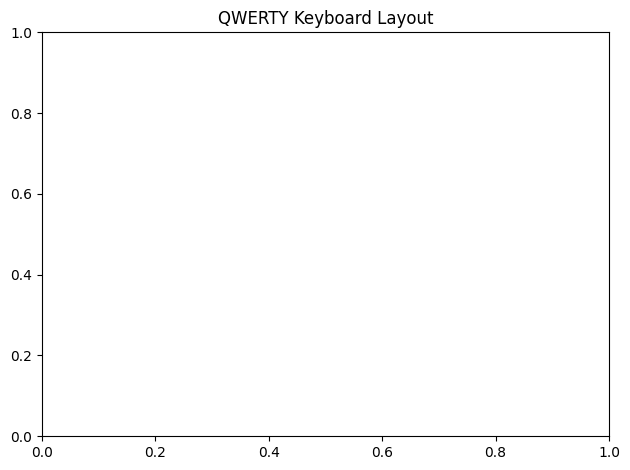

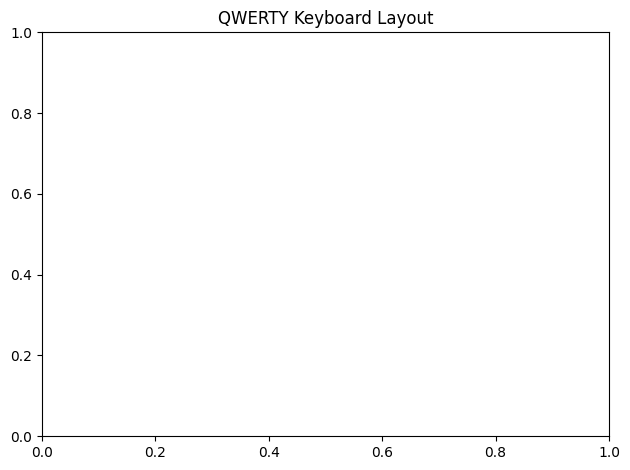

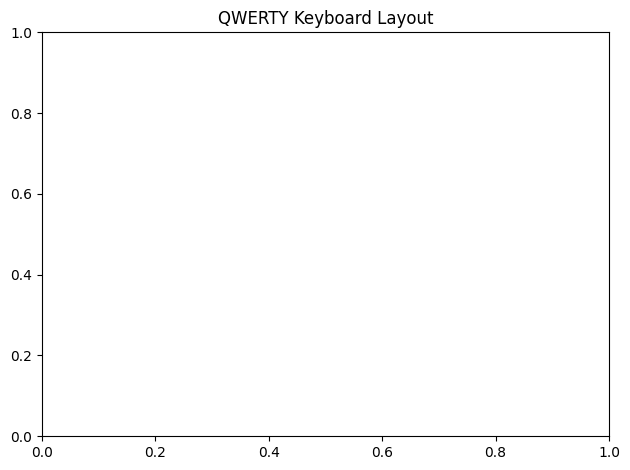

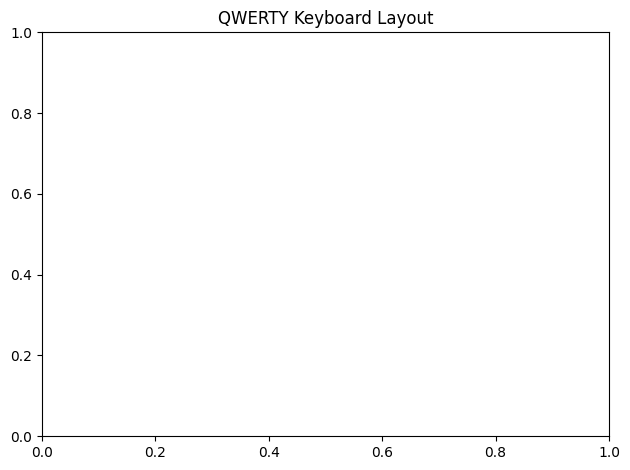

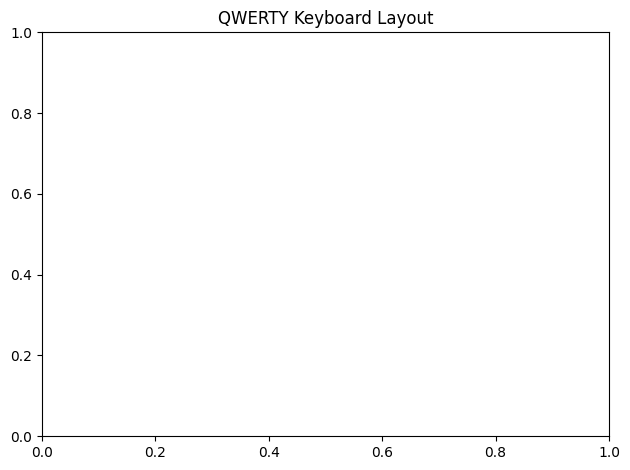

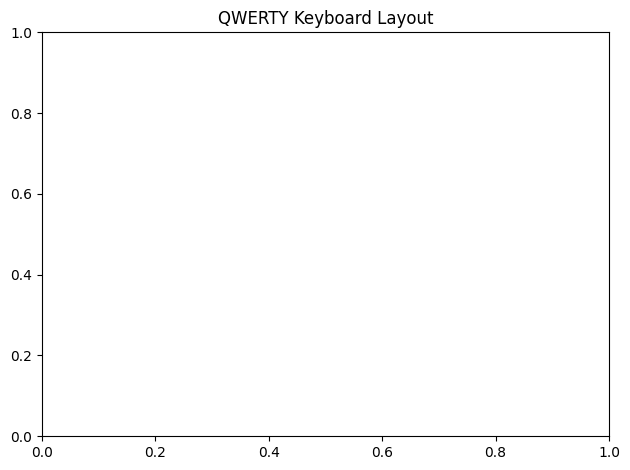

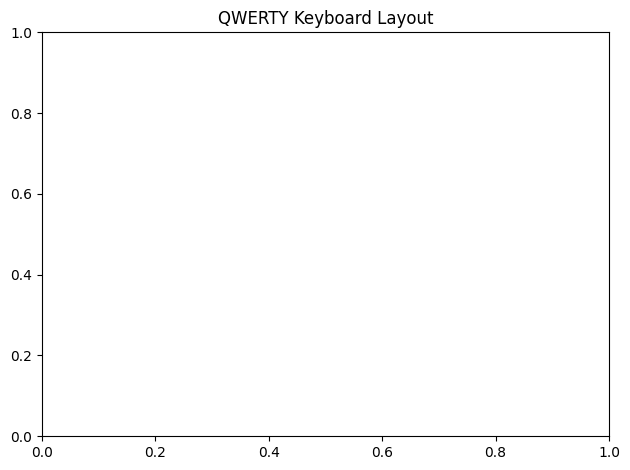

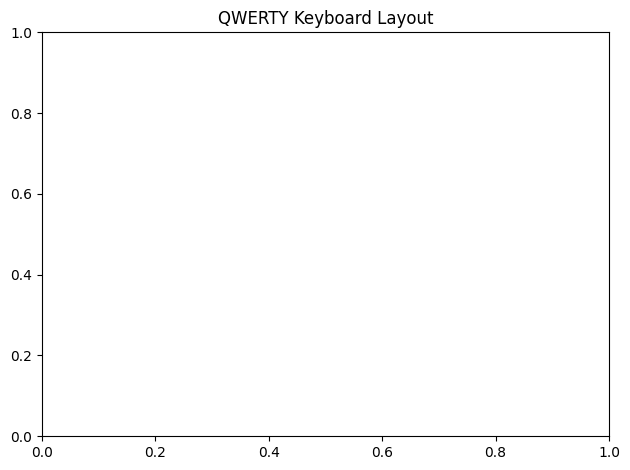

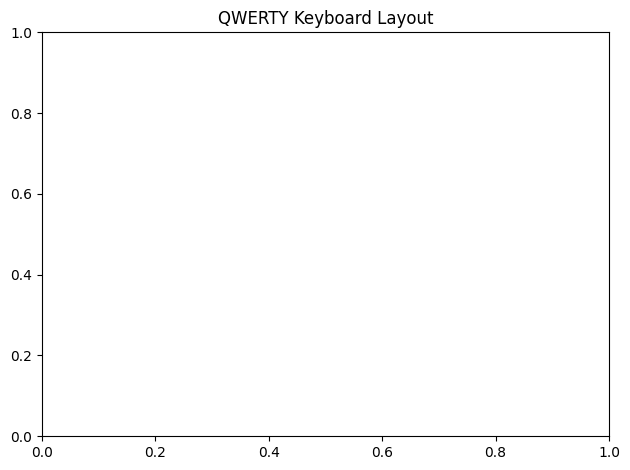

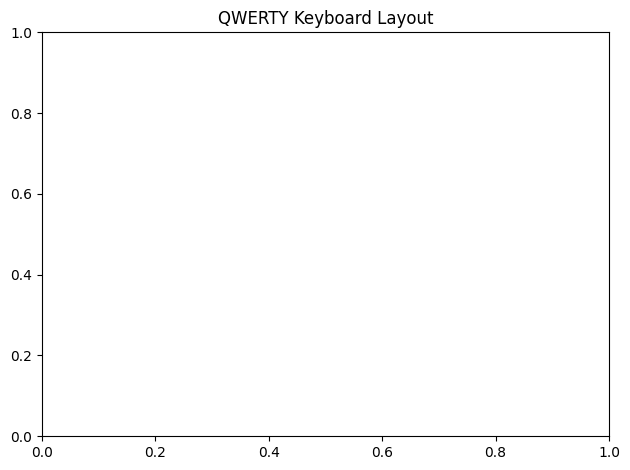

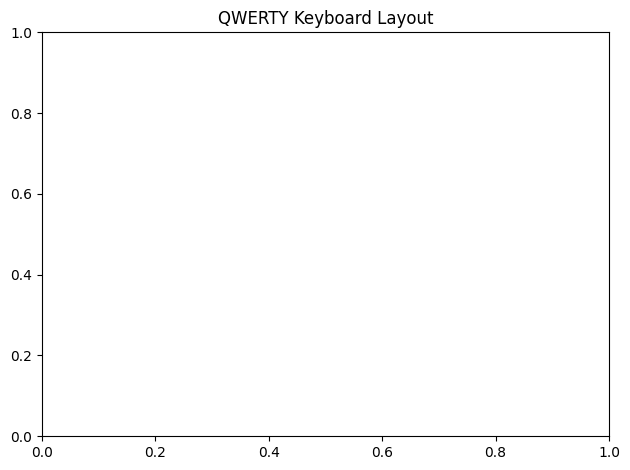

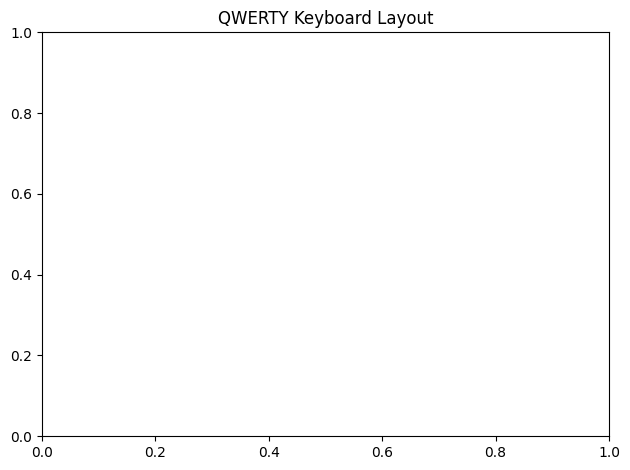

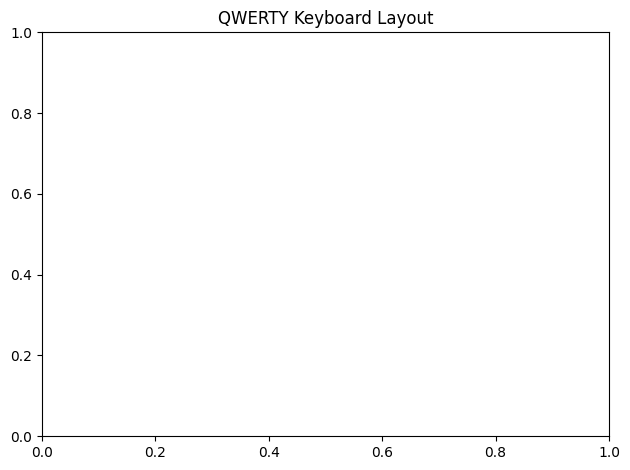

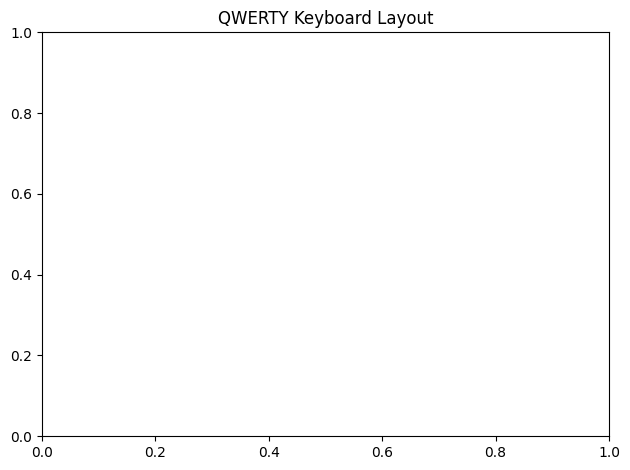

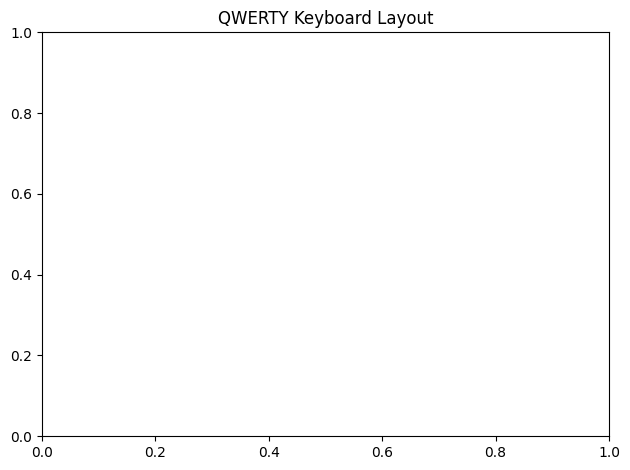

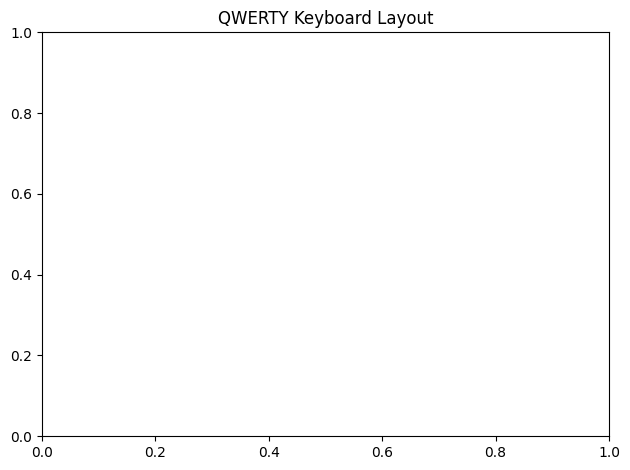

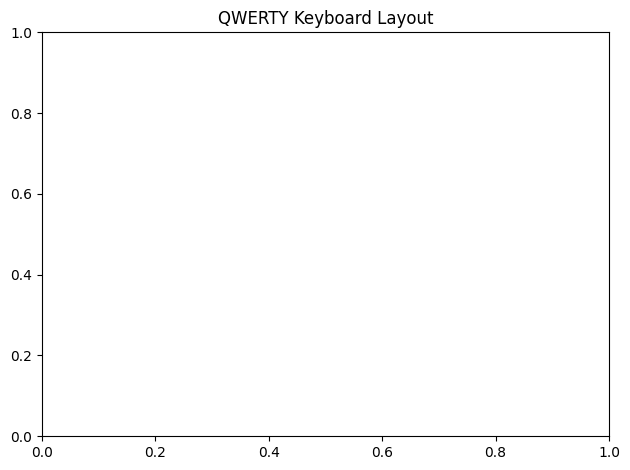

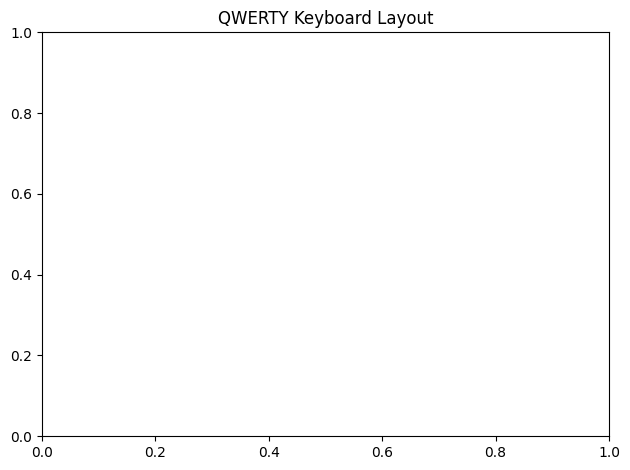

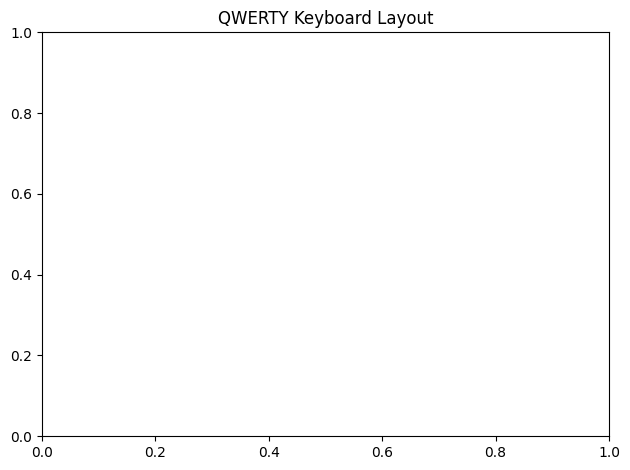

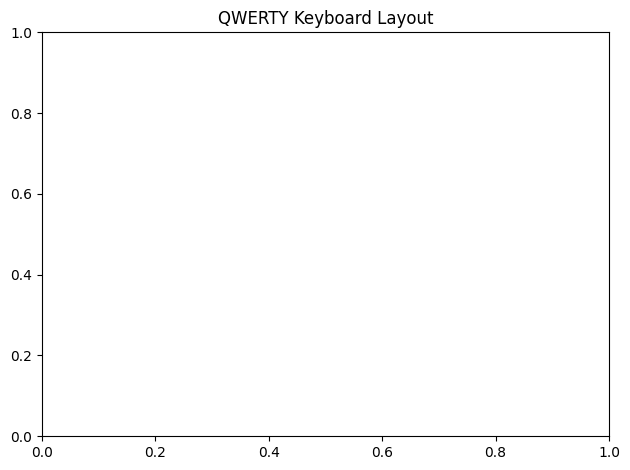

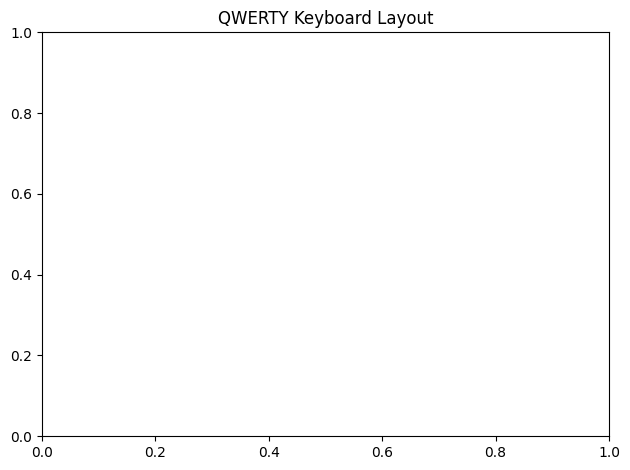

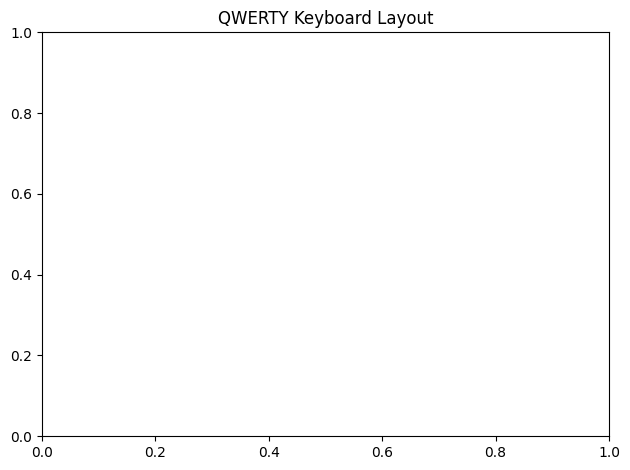

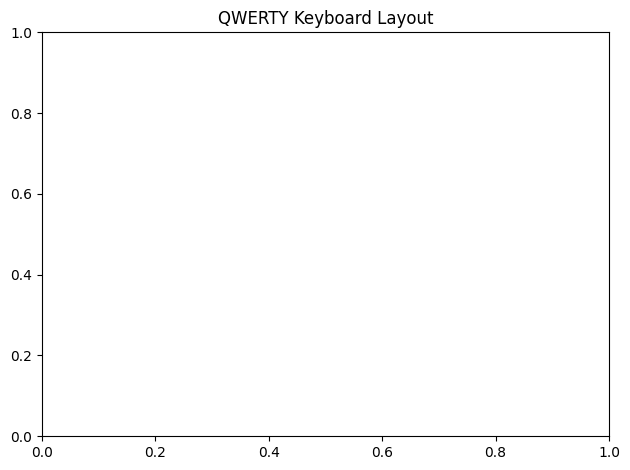

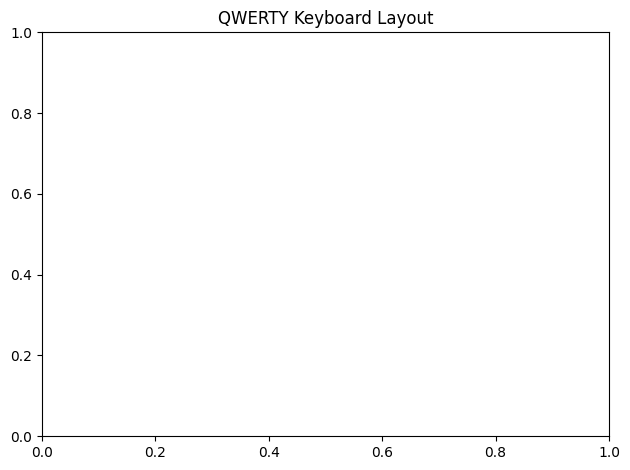

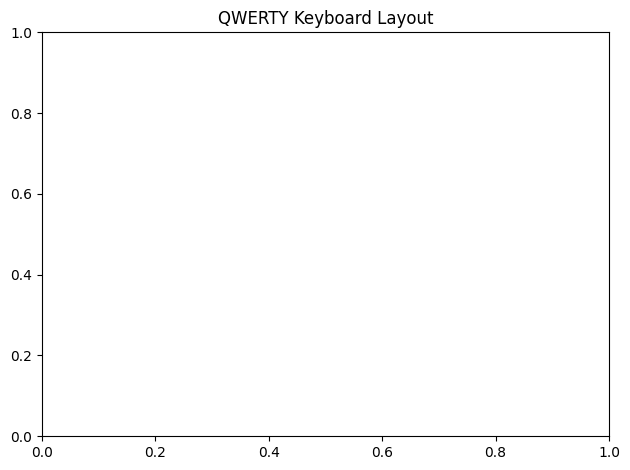

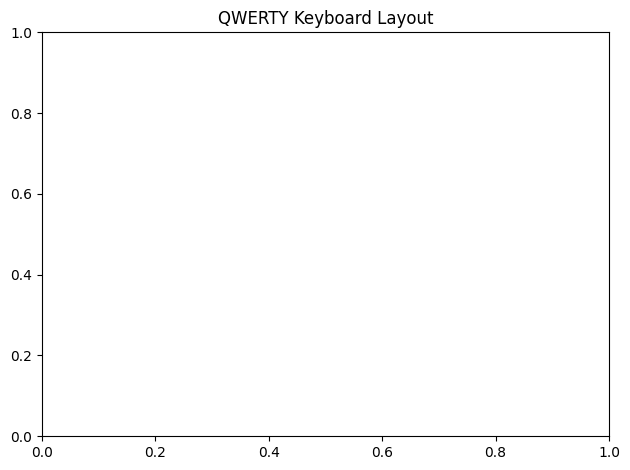

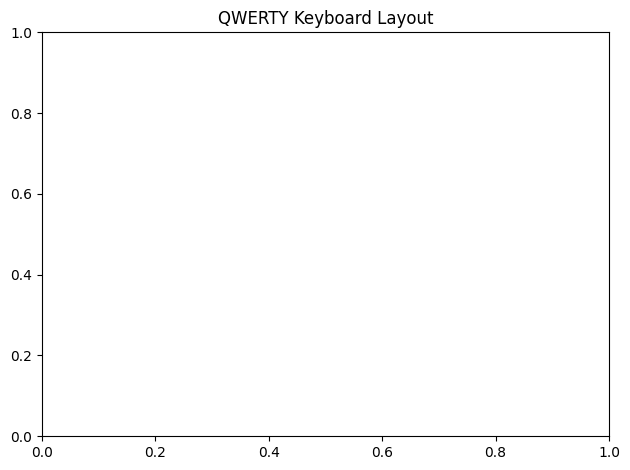

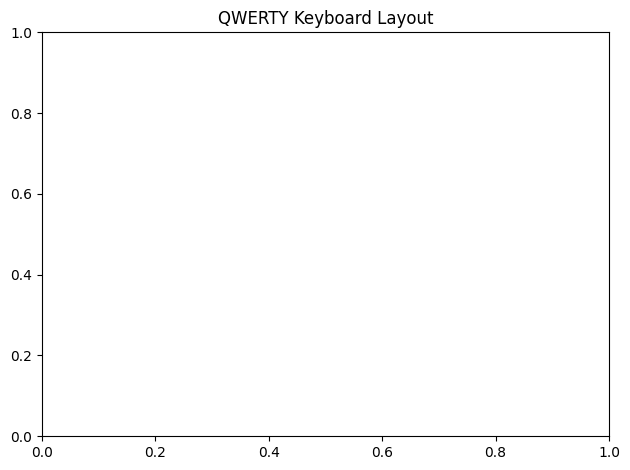

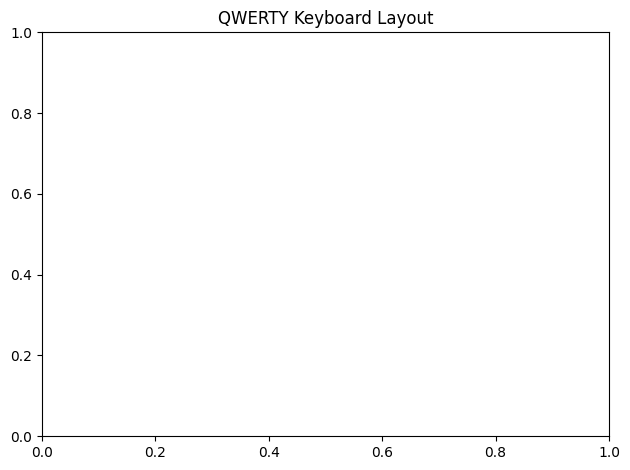

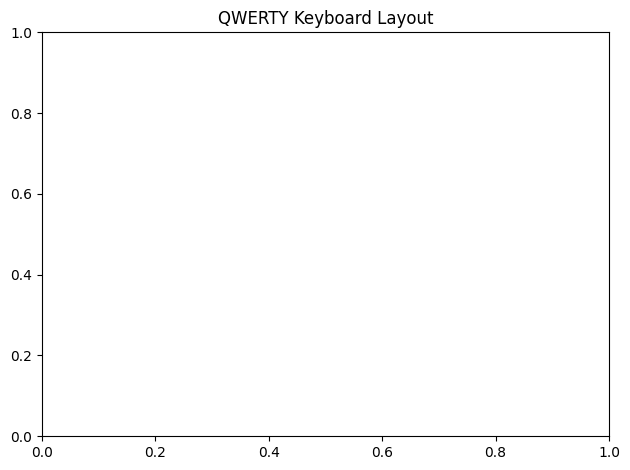

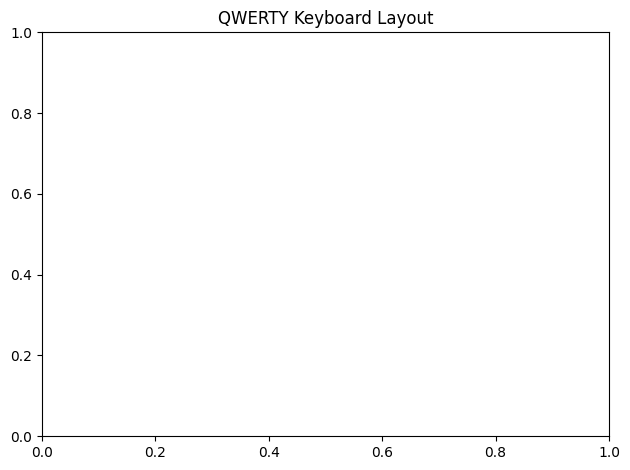

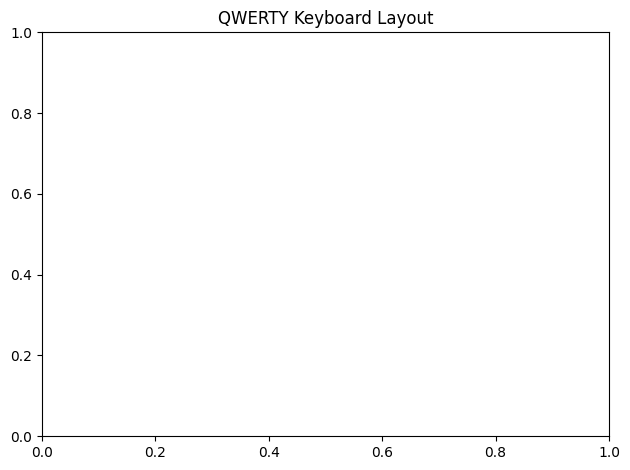

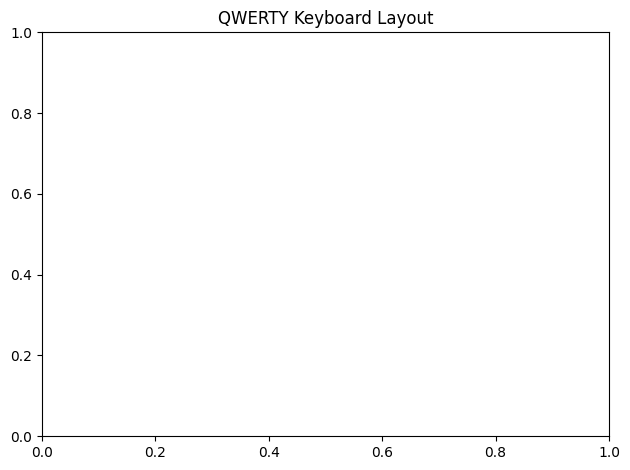

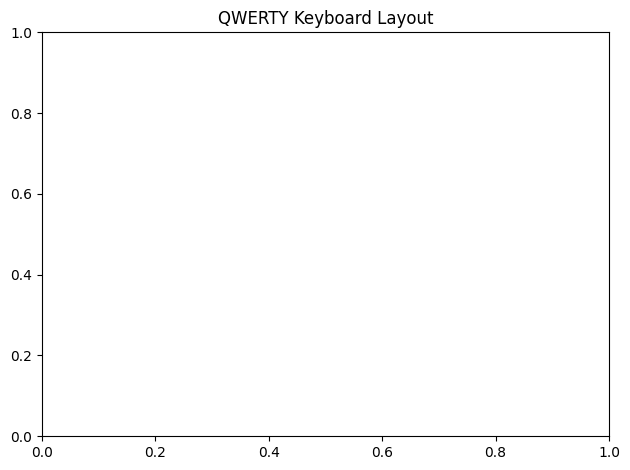

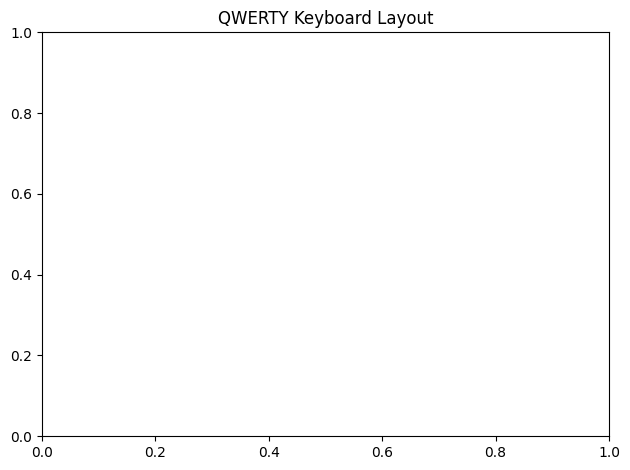

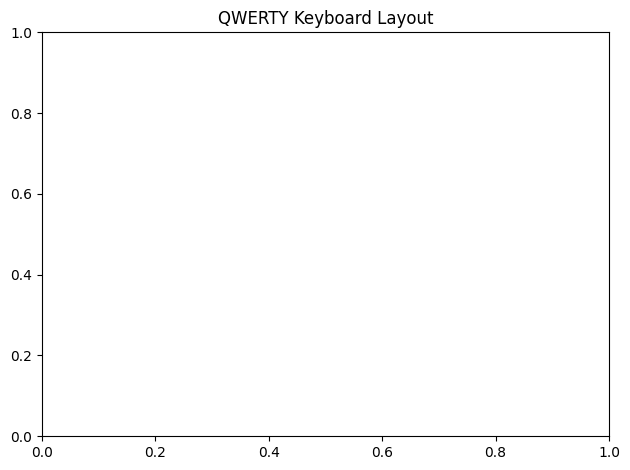

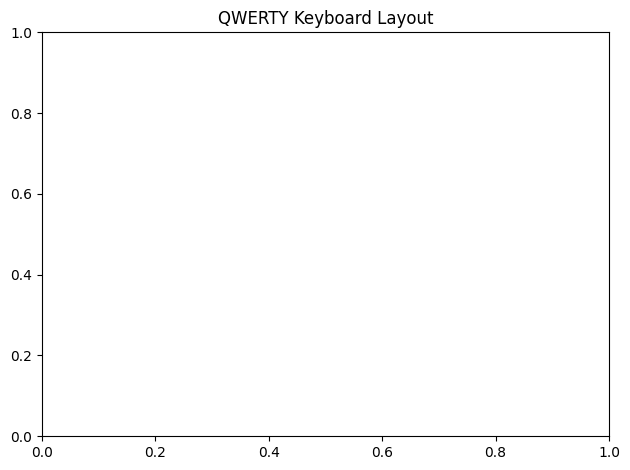

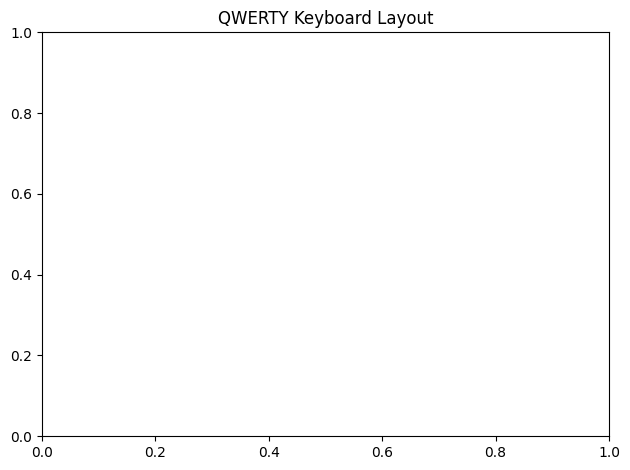

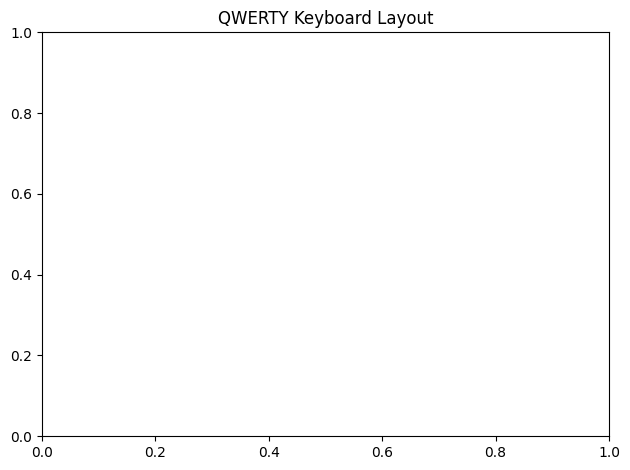

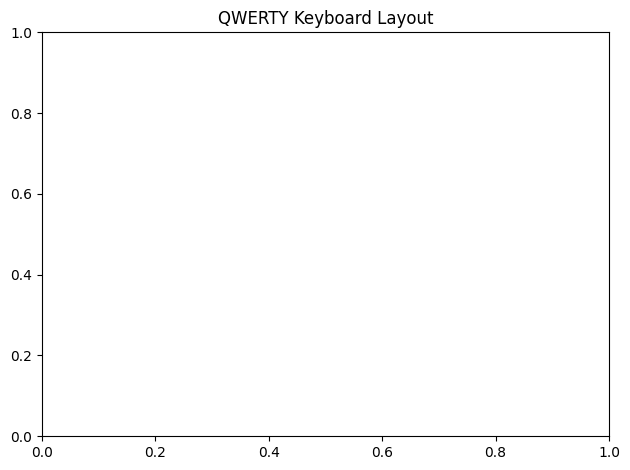

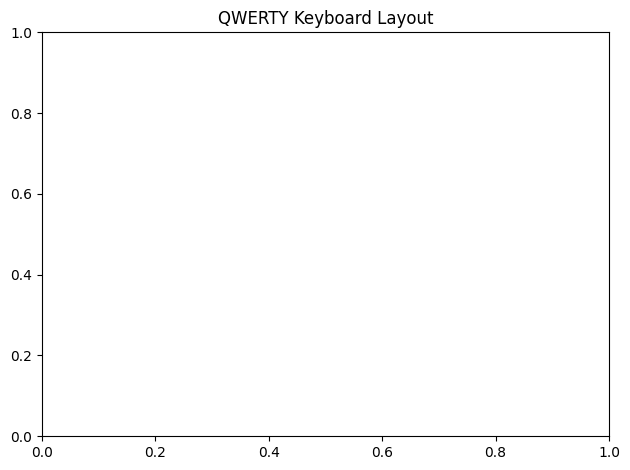

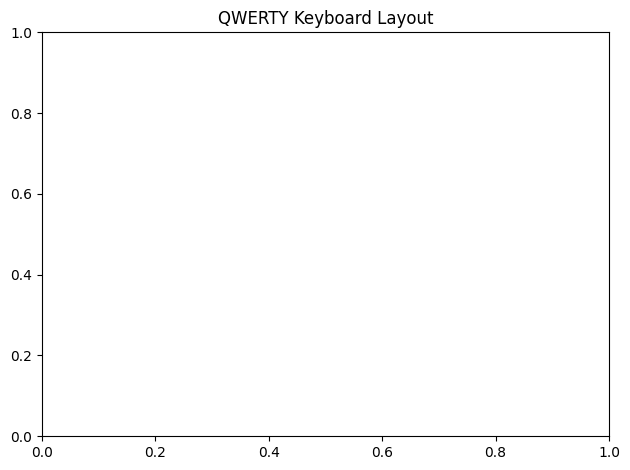

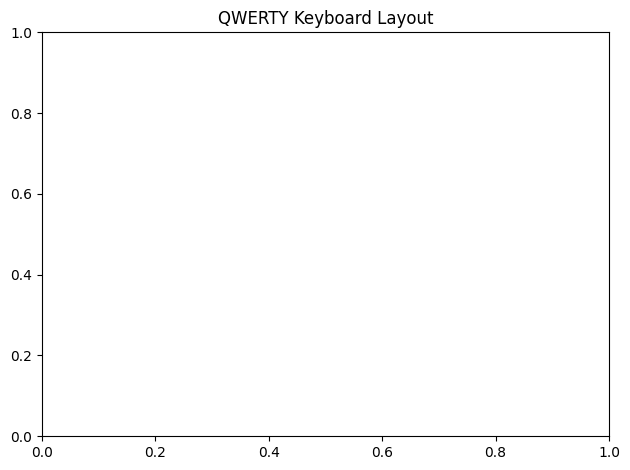

In [ ]:
# Run the animation function
anim = animate_allsimulated_annealing(
    text_input, keys, characters, initial_temp=100, cooling_rate=0.995, num_iterations=500)

# Saving the animation to a video file
anim.save('simultaneous_animation_2.mp4', writer='ffmpeg')